# IEEE 8500-node feeder — OpenDSS timing (GNN2)

**This notebook file:** `IEEE8500_OpenDSS_timing.ipynb` (in your `GNN2` project folder)

**Not** the `8500-node` **folder** — that folder only holds OpenDSS `.dss` data files.

**Goal:** find `Master.dss`, run snapshot power flow, and measure **median `Solve()` time (ms)** to compare later with GNN inference at batch size 1.

| Step | What |
|------|------|
| **1** | Point OpenDSS at `Master.dss` |
| **2** | Load circuit + time 50 snapshot solves |
| **3** | Generate load-type CSVs (`run_loadtype_dataset_8500`) |
| **4** | Build `edge_index` / `edge_attr` (`build_graph_8500`) |
| **5** | Stack node `X` / `Y` tensors (`assemble_dataset_tensors_8500`) |
| **6** | MLP sweep: 5 architectures, best saved (`train_mlp_8500`) |
| **6b** | Daily-agg MLP: P/Q + cap Q + taps → vmag pu (`train_mlp_8500_vmag_control_explore`) |

Run cells **in order** (top to bottom).


## Step 1 — Path to `Master.dss`

The feeder is a **folder of `.dss` files**. The **entry file** is **`Master.dss`**. Your copy lives in **`GNN2/8500-node`**.

**This step:** set `LOCAL_8500_DIR` if you move the folder, run the code cell, and confirm it prints **`Master.dss`**.

**Pass:** `Master.dss` exists at the printed path.


In [1]:
import pathlib
import opendssdirect

# --- edit only if you move the feeder folder ---
LOCAL_8500_DIR = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node")
LOCAL_8500_MASTER = LOCAL_8500_DIR / "Master.dss"

DSS_8500: pathlib.Path | None = None

if LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    for base in (
        pathlib.Path(opendssdirect.__file__).parent,
        pathlib.Path(r"C:\Program Files\OpenDSS"),
        pathlib.Path(r"C:\OpenDSS"),
    ):
        if not base.exists():
            continue
        try:
            for f in base.rglob("Master.dss"):
                if "8500" in str(f).lower():
                    DSS_8500 = f
                    break
        except (OSError, PermissionError):
            pass
        if DSS_8500 is not None:
            break

if DSS_8500 is None:
    print("Master.dss not found. Place the full 8500-node folder at:")
    print(" ", LOCAL_8500_DIR)
else:
    print("Using entry file:", DSS_8500.resolve())


Using entry file: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss


**Checkpoint — Step 1 done**

You have the OpenDSS entry file **`Master.dss`**.

**Next:** Step 2 loads the circuit and measures solve time.


## Step 2 — Load circuit and profile `Solve()`

**This step:** `Redirect` `Master.dss`, run one solve (convergence + bus counts), then **50** snapshot solves and report **median / mean / min / max** in **ms**.

**Note:** `from opendssdirect import dss` is required — the **package** is not callable (`import opendssdirect as dss` breaks `dss(...)`).

**Pass:** `Converged: True`, buses ~4876, node-phases ~8500+, and a stable median time.


In [2]:
# Step 2 — load + time snapshot solves
import statistics
import time

import pathlib

from opendssdirect import dss

LOCAL_8500_MASTER = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss")
_d = globals().get("DSS_8500")
if _d is not None:
    DSS_8500 = _d
elif LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    DSS_8500 = None
if DSS_8500 is None:
    raise RuntimeError("Run Step 1 or place Master.dss at GNN2/8500-node/Master.dss")

dss(f'redirect "{DSS_8500.resolve()}"')
dss.Solution.Mode(1)
dss.Solution.Solve()

converged = dss.Solution.Converged()
n_buses = len(dss.Circuit.AllBusNames())
all_nodes = dss.Circuit.AllNodeNames()
n_nodes = len([n for n in all_nodes if "." in n and n.split(".")[1] in ("1", "2", "3")])

print("Circuit:", DSS_8500)
print(f"  Converged    : {converged}")
print(f"  Buses        : {n_buses}")
print(f"  Node-phases  : {n_nodes} (phases 1/2/3)")
print(f"  Control iter : {dss.Solution.ControlIterations()}")
print(f"  PF iter      : {dss.Solution.Iterations()}")

times_ms = []
for _ in range(50):
    t0 = time.perf_counter()
    dss.Solution.Solve()
    times_ms.append((time.perf_counter() - t0) * 1000.0)

med = statistics.median(times_ms)
print()
print("Solve() time over 50 runs (ms):")
print(f"  median : {med:.3f} ms")
print(f"  mean   : {statistics.mean(times_ms):.3f} ms")
print(f"  min    : {min(times_ms):.3f} ms")
print(f"  max    : {max(times_ms):.3f} ms")
print()
print(f"→ Rough batch-1 target vs pure Solve(): beat ~{med:.1f} ms/step")


Circuit: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss
  Converged    : True
  Buses        : 4876
  Node-phases  : 8541 (phases 1/2/3)
  Control iter : 1
  PF iter      : 2

Solve() time over 50 runs (ms):
  median : 47.016 ms
  mean   : 49.884 ms
  min    : 42.119 ms
  max    : 80.902 ms

→ Rough batch-1 target vs pure Solve(): beat ~47.0 ms/step


**Checkpoint — Step 2 done**

You now have **median `Solve()` time** for this machine on the 8500-node case. Use it as an order-of-magnitude bar when comparing to a surrogate (plus PyTorch overhead, etc.).

---

## Step 3 — Generate load-type dataset (8500)

Run the **next code cell** to execute `run_loadtype_dataset_8500.py`. It writes the same style of CSVs as `run_loadtype_dataset.py`, but for **`8500-node/Master.dss`**, under **`datasets_gnn2/loadtype_8500/`**.

Edit **`n_samples`** (and seeds) in that cell if you want a smaller test first.

---

## Step 4 — Build static graph tensors (`edge_index`, `edge_attr`)

Run **after Step 3** so `gnn_edges_phase_static.csv` and `gnn_node_index_master.csv` exist. The script **`build_graph_8500.py`** writes **`graph_tensors/edge_index.pt`**, **`edge_attr.pt`**, **`graph_meta.json`**, and **`node_index_map.json`** under **`datasets_gnn2/loadtype_8500/`**.

---

## Step 5 — Stack node features / targets (`X`, `Y`)

Run **after Steps 3–4** so `gnn_node_features_and_targets.csv` exists and **`graph_meta.json`** can validate **N**. **`assemble_dataset_tensors_8500.py`** writes **`dataset_tensors/X.pt`**, **`Y.pt`**, optional **`Y_angle.pt`** (`vang_deg`), and **`tensor_manifest.json`**.

---

## Step 6 — MLP baseline (checklist *Step 5*)

Run **after Step 5** so **`X.pt`** / **`Y.pt`** exist. **`train_mlp_8500.py`** trains **five** MLP shapes on **MSE(|V|) only** (no angle), saves each under **`mlp_sweep_8500/<name>/`**, writes **`sweep_summary.json`**, and copies the **best** test MAE to **`mlp_sweep_8500/best/`**. For a **single** run use `train_mlp_baseline_8500()`. The checklist target is **test MAE under 0.005 pu** on \|V\| — expect to **increase `n_samples`** (e.g. 5k–10k) in Step 3 first.

---

## Later (outside this notebook)

- Train **`train_gnn_8500`** (checklist Step 6), then benchmark inference vs OpenDSS.


In [ ]:
# Step 3 — same pattern as GNN2 notebook: chdir to repo, run dataset script
import os

try:
    import run_loadtype_dataset_8500 as _lt8500

    os.chdir(os.path.dirname(os.path.abspath(_lt8500.__file__)))
except Exception:
    pass

# Same as: exec(open("run_loadtype_dataset_8500.py", encoding="utf-8").read())
from run_loadtype_dataset_8500 import generate_gnn_snapshot_dataset_loadtype_8500

generate_gnn_snapshot_dataset_loadtype_8500(
    n_samples=500,
    master_seed=20260322,
    sigma_load=0.12,
    sigma_pv=0.12,
)

## Step 4 — Static graph from dataset CSVs

**Pass:** `build_graph_8500.build_static_graph_8500()` prints shapes and writes files under `datasets_gnn2/loadtype_8500/graph_tensors/`.

**Next:** Step 5 — stack **`X`** / **`Y`** tensors from `gnn_node_features_and_targets.csv`.

In [ ]:
# Step 4 — edge_index / edge_attr .pt files (requires Step 3 CSVs)
import os

try:
    import build_graph_8500 as _bg
    os.chdir(os.path.dirname(os.path.abspath(_bg.__file__)))
except Exception:
    pass

from build_graph_8500 import build_static_graph_8500

build_static_graph_8500()

## Step 5 — Stacked tensors for training

**Pass:** `assemble_dataset_tensors_8500.assemble_dataset_tensors_8500()` prints shapes and writes **`dataset_tensors/X.pt`**, **`Y.pt`**, **`tensor_manifest.json`**.

Uses the same **14** load-type input columns as `run_gnn3_best7_train.LOADTYPE_FEAT`; target defaults to **`vmag_pu`**, with **`Y_angle.pt`** from **`vang_deg`** when present.

**Next:** Step 6 — five-MLP sweep (`train_mlp_architecture_sweep_8500`).

In [5]:
# Step 5 — X [S,N,F], Y [S,N] aligned with graph node order (needs Steps 3–4)
import os

try:
    import assemble_dataset_tensors_8500 as _ad
    os.chdir(os.path.dirname(os.path.abspath(_ad.__file__)))
except Exception:
    pass

from assemble_dataset_tensors_8500 import assemble_dataset_tensors_8500

assemble_dataset_tensors_8500()

[assemble_dataset_tensors_8500] Saved to C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500\dataset_tensors/
  X (500, 8541, 14)  Y (500, 8541)  target='vmag_pu'
  samples=500 (dropped incomplete samples vs N=8541)


{'dataset_dir': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500',
 'num_samples': 500,
 'num_nodes': 8541,
 'num_features': 14,
 'feature_columns': ['electrical_distance_ohm',
  'm1_p_kw',
  'm1_q_kvar',
  'm2_p_kw',
  'm2_q_kvar',
  'm4_p_kw',
  'm4_q_kvar',
  'm5_p_kw',
  'm5_q_kvar',
  'q_cap_kvar',
  'p_pv_kw',
  'q_pv_kvar',
  'p_sys_balance_kw',
  'q_sys_balance_kvar'],
 'target_column': 'vmag_pu',
 'X_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\X.pt',
 'Y_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\Y.pt',
 'X_shape': [500, 8541, 14],
 'Y_shape': [500, 8541],
 'sample_ids': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  4

## Step 6 — MLP exploration: P/Q + cap Q + taps → |V| (daily-agg CSV)

**Dataset:** `datasets_gnn2/loadtype_8500_dailyagg/` (`run_daily_aggregate_dataset_8500.py`).

**Inputs (per sample):** flattened nodal `p_load_kw`, `q_load_kvar`; post-solve `cap_*_q_post_kvar`; `reg_*_tap_pu`.

**Output:** `vmag_pu` at every node.

**Script:** `train_mlp_8500_vmag_control_explore.py` trains **five** bottleneck-style MLPs (avoids one giant `Linear(2N+G → N)`). Every **10** epochs it prints **val MAE** and **val RMSE** in **pu** on |V|.

**Saves:** `mlp_vm_control_explore_8500/<arch>/best.pt` and `summary.json`.

Run **after** the daily-aggregate dataset exists (not the `loadtype_8500` tensor Step 5 pipeline).

**Colab:** `git clone` the repo (e.g. to `/content/GNN-Sandia`), upload or mount **`datasets_gnn2/loadtype_8500_dailyagg/`** (both CSVs) under that repo, enable a **GPU** runtime if you want faster training, then run the code cell (it tries `/content/GNN-Sandia` first, then falls back to a local Windows path).

In [ ]:
# Step 6b — five MLPs: nodal P/Q + cap q_post + reg taps -> |V|_pu per node
# Runs in a subprocess (fresh import; streaming logs).
import os
import subprocess
import sys
import pathlib

# Colab: clone to /content/GNN-Sandia (or edit _REPO_PRIMARY). Local: falls back to GNN2 path.
_REPO_PRIMARY = pathlib.Path("/content/GNN-Sandia")
_REPO_FALLBACK = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")

if _REPO_PRIMARY.is_dir():
    os.chdir(_REPO_PRIMARY)
elif _REPO_FALLBACK.is_dir():
    os.chdir(_REPO_FALLBACK)
elif not os.path.isfile("train_mlp_8500_vmag_control_explore.py"):
    raise RuntimeError(
        "Put this notebook's cwd on the repo root, or clone to /content/GNN-Sandia, "
        "so train_mlp_8500_vmag_control_explore.py is found."
    )

if not os.path.isfile("train_mlp_8500_vmag_control_explore.py"):
    raise FileNotFoundError(os.path.abspath("train_mlp_8500_vmag_control_explore.py"))

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [
    sys.executable,
    "-u",
    "train_mlp_8500_vmag_control_explore.py",
    "--epochs",
    "100",
    "--report-every",
    "10",
]
print("Starting:", " ".join(_cmd), flush=True)
proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_mlp_8500_vmag_control_explore.py exited with code {ret}")

Starting (streaming logs): /usr/bin/python3 -u train_mlp_8500.py --epochs 100 --batch-size 16
[train_mlp_8500] Starting sweep (use: python -u for unbuffered logs in notebooks).
[sweep] Loading tensors from /content/GNN-Sandia/datasets_gnn2/loadtype_8500/dataset_tensors (large files — can take 1–2 min on Colab)...
[sweep] Loaded X,Y shape X=(500, 8541, 14) Y=(500, 8541)  samples=500
[h256_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=256  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.194693  val_mae_|V|_pu=0.422311  val_rmse_|V|_pu=0.441240  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029965  val_mae_|V|_pu=0.148543  val_rmse_|V|_pu=0.173104  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.025370  val_mae_|V|_pu=0.137473  val_rmse_|V|_pu=0.159281  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.024333  val_mae_|V|_pu=0.134085  val_rmse_|V|_pu=0.155992  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.024802  val_mae_|V|_pu=0.135087  val_rmse_|V|_pu=0.157487  lr=2.50e-04
  epoch  50/100  val_mse_|V|=0.025086  val_mae_|V|_pu=0.135854  val_rmse_|V|_pu=0.158387  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.025189  val_mae_|V|_pu=0.136122  val_rmse_|V|_pu=0.158711  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.025226  val_mae_|V|_pu=0.136220  val_rmse_|V|_pu=0.158828  lr=7.81e-06
  epoch  80/100  val_mse_|V|=0.025239  val_mae_|V|_pu=0.136258  val_rmse_|V|_pu=0.158868  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.025245  val_mae_|V|_pu=0.136272  val_rmse_|V|_pu=0.158886  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.025250  val_mae_|V|_pu=0.136285  val_rmse_|V|_pu=0.158902  lr=1.00e-06
[h256_l2] device=cuda  test MAE |V| (pu): 0.147260  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h256_l2/mlp_8500.pt

[h512_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.189136  val_mae_|V|_pu=0.416480  val_rmse_|V|_pu=0.434898  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029836  val_mae_|V|_pu=0.144683  val_rmse_|V|_pu=0.172730  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.024677  val_mae_|V|_pu=0.133137  val_rmse_|V|_pu=0.157089  lr=5.00e-04
  epoch  30/100  val_mse_|V|=0.024500  val_mae_|V|_pu=0.131465  val_rmse_|V|_pu=0.156524  lr=2.50e-04
  epoch  40/100  val_mse_|V|=0.024721  val_mae_|V|_pu=0.132318  val_rmse_|V|_pu=0.157229  lr=6.25e-05
  epoch  50/100  val_mse_|V|=0.024813  val_mae_|V|_pu=0.132479  val_rmse_|V|_pu=0.157522  lr=1.56e-05
  epoch  60/100  val_mse_|V|=0.024842  val_mae_|V|_pu=0.132551  val_rmse_|V|_pu=0.157613  lr=7.81e-06
  epoch  70/100  val_mse_|V|=0.024857  val_mae_|V|_pu=0.132593  val_rmse_|V|_pu=0.157660  lr=1.95e-06
  epoch  80/100  val_mse_|V|=0.024861  val_mae_|V|_pu=0.132605  val_rmse_|V|_pu=0.157672  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.024864  val_mae_|V|_pu=0.132612  val_rmse_|V|_pu=0.157684  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.024870  val_mae_|V|_pu=0.132631  val_rmse_|V|_pu=0.157702  lr=1.00e-06
[h512_l2] device=cuda  test MAE |V| (pu): 0.137678  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l2/mlp_8500.pt

[h768_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=768  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.175445  val_mae_|V|_pu=0.378352  val_rmse_|V|_pu=0.418862  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.037981  val_mae_|V|_pu=0.159999  val_rmse_|V|_pu=0.194886  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.021441  val_mae_|V|_pu=0.125213  val_rmse_|V|_pu=0.146427  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.023440  val_mae_|V|_pu=0.129736  val_rmse_|V|_pu=0.153103  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.023667  val_mae_|V|_pu=0.131003  val_rmse_|V|_pu=0.153842  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.023852  val_mae_|V|_pu=0.131601  val_rmse_|V|_pu=0.154442  lr=3.13e-05
  epoch  60/100  val_mse_|V|=0.023925  val_mae_|V|_pu=0.131761  val_rmse_|V|_pu=0.154678  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.023954  val_mae_|V|_pu=0.131834  val_rmse_|V|_pu=0.154772  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.023967  val_mae_|V|_pu=0.131880  val_rmse_|V|_pu=0.154813  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.023976  val_mae_|V|_pu=0.131898  val_rmse_|V|_pu=0.154842  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.023985  val_mae_|V|_pu=0.131919  val_rmse_|V|_pu=0.154872  lr=1.00e-06
[h768_l2] device=cuda  test MAE |V| (pu): 0.130161  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h768_l2/mlp_8500.pt

[h512_l3] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=3  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.100906  val_mae_|V|_pu=0.277017  val_rmse_|V|_pu=0.317656  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029848  val_mae_|V|_pu=0.144286  val_rmse_|V|_pu=0.172767  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.028737  val_mae_|V|_pu=0.146077  val_rmse_|V|_pu=0.169519  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.027394  val_mae_|V|_pu=0.141863  val_rmse_|V|_pu=0.165511  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.027944  val_mae_|V|_pu=0.143599  val_rmse_|V|_pu=0.167165  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.028129  val_mae_|V|_pu=0.144048  val_rmse_|V|_pu=0.167718  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.028249  val_mae_|V|_pu=0.144333  val_rmse_|V|_pu=0.168074  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.028289  val_mae_|V|_pu=0.144428  val_rmse_|V|_pu=0.168192  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.028302  val_mae_|V|_pu=0.144461  val_rmse_|V|_pu=0.168231  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.028307  val_mae_|V|_pu=0.144474  val_rmse_|V|_pu=0.168246  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028312  val_mae_|V|_pu=0.144487  val_rmse_|V|_pu=0.168262  lr=1.00e-06
[h512_l3] device=cuda  test MAE |V| (pu): 0.147883  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l3/mlp_8500.pt

[h1024_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=1024  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.151984  val_mae_|V|_pu=0.340831  val_rmse_|V|_pu=0.389851  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.041932  val_mae_|V|_pu=0.169438  val_rmse_|V|_pu=0.204774  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.030679  val_mae_|V|_pu=0.146481  val_rmse_|V|_pu=0.175154  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.026945  val_mae_|V|_pu=0.136665  val_rmse_|V|_pu=0.164150  lr=1.00e-03
  epoch  40/100  val_mse_|V|=0.027087  val_mae_|V|_pu=0.139652  val_rmse_|V|_pu=0.164580  lr=5.00e-04
  epoch  50/100  val_mse_|V|=0.027694  val_mae_|V|_pu=0.141119  val_rmse_|V|_pu=0.166415  lr=1.25e-04
  epoch  60/100  val_mse_|V|=0.027914  val_mae_|V|_pu=0.141677  val_rmse_|V|_pu=0.167076  lr=3.13e-05
  epoch  70/100  val_mse_|V|=0.028010  val_mae_|V|_pu=0.141899  val_rmse_|V|_pu=0.167362  lr=1.56e-05
  epoch  80/100  val_mse_|V|=0.028037  val_mae_|V|_pu=0.141962  val_rmse_|V|_pu=0.167441  lr=3.91e-06
  epoch  90/100  val_mse_|V|=0.028050  val_mae_|V|_pu=0.141988  val_rmse_|V|_pu=0.167481  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028053  val_mae_|V|_pu=0.141998  val_rmse_|V|_pu=0.167490  lr=1.00e-06
[h1024_l2] device=cuda  test MAE |V| (pu): 0.150931  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h1024_l2/mlp_8500.pt

============================================================
SWEEP DONE. Best architecture: h768_l2
  test MAE |V| (pu) = 0.130161
  copied to /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/best
  summary: /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/sweep_summary.json

## Step 7 — Train the GNN baseline (`train_gnn_8500.py`)

Run this after Step 5 so `dataset_tensors/X.pt`, `Y.pt`, `Y_angle.pt` exist, and after Step 4 so `graph_tensors/edge_index.pt` and `edge_attr.pt` exist.

This is a first-pass GCN-style residual model that predicts `(vmag_pu, vang_deg)` when `Y_angle.pt` is available; otherwise it trains on `vmag_pu` only.

In [ ]:
# Step 7 — GNN training (fresh subprocess to avoid stale imports)
import os
import subprocess
import sys

REPO = "/content/GNN-Sandia"  # Colab path
if os.path.isdir(REPO):
    os.chdir(REPO)

if not os.path.isfile("train_gnn_8500.py"):
    raise FileNotFoundError(os.path.abspath("train_gnn_8500.py"))

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}

_cmd = [
    sys.executable,
    "-u",
    "train_gnn_8500.py",
    "--epochs",
    "5",
    "--hidden-dim",
    "64",
    "--num-layers",
    "3",
    "--max-train-samples",
    "20",
    "--max-val-samples",
    "20",
    "--max-test-samples",
    "10",
]

print("Starting GNN training:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_gnn_8500.py exited with code {ret}")

Starting GNN training: /usr/bin/python3 -u train_gnn_8500.py --epochs 5 --hidden-dim 64 --num-layers 3 --max-train-samples 20 --max-val-samples 20 --max-test-samples 10
[train_gnn_8500] device=cuda  S=500 N=8541 F=14 angle_target=OFF
  epoch   1/5  train_loss=0.062109  val_mae_|V|=0.090193
  epoch   2/5  train_loss=0.013216  val_mae_|V|=0.063377
  epoch   3/5  train_loss=0.010626  val_mae_|V|=0.061782
  epoch   4/5  train_loss=0.007023  val_mae_|V|=0.053858
  epoch   5/5  train_loss=0.005983  val_mae_|V|=0.047271
[train_gnn_8500] done. out_dir=/content/GNN-Sandia/datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3
  test MAE |V| (pu): 0.042507

## Step 8 — Daily OpenDSS vs MLP vs GNN comparison (`compare_daily_8500_mlp_gnn.py`)

Runs a 24h (288-step) 8500-node daily simulation and compares voltage magnitude trajectories for chosen nodes.

- Inputs: **two checkpoint paths** (`gnn_8500.pt`, `mlp_8500.pt`)
- Output: per-node plots (`OpenDSS vs MLP vs GNN`) and timing summary
- This script uses the optimized inference path (pinned host buffers, 2 CUDA streams, vectorized feature build).

In [5]:
# Step 8 — run daily OpenDSS vs MLP vs GNN (streaming logs)
import os
import subprocess
import sys

# Auto-detect repo root so this cell works both locally and in Colab.
SCRIPT_NAME = "compare_daily_8500_mlp_gnn.py"
CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",  # local Windows fallback
    "/content/GNN-Sandia",                        # Colab fallback
]

repo = None
for p in CANDIDATES:
    if os.path.isfile(os.path.join(p, SCRIPT_NAME)):
        repo = p
        break

if repo is None:
    raise FileNotFoundError(
        f"Could not find {SCRIPT_NAME}. Tried: {CANDIDATES}. "
        "Set CANDIDATES or cd to repo root first."
    )

os.chdir(repo)
print("Using repo:", os.getcwd())

# TODO: set these two checkpoint paths
GNN_CKPT = "datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt"
MLP_CKPT = "datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt"

# Nodes to plot.
# IMPORTANT: 8500-node IDs are names like m1026891.1, l3216367.2, sourcebus.1, ...
# (not 34-node IDs such as 816.1 / 840.1 / 848.2).
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]

# Validate/fix node list against the 8500 node index.
import pandas as pd
_node_csv = os.path.join("datasets_gnn2", "loadtype_8500", "gnn_node_index_master.csv")
if not os.path.isfile(_node_csv):
    raise FileNotFoundError(os.path.abspath(_node_csv))
_all_nodes = set(pd.read_csv(_node_csv)["node"].astype(str).tolist())
_valid_nodes = [n for n in PLOT_NODES if n in _all_nodes]
if len(_valid_nodes) == 0:
    # Fallback to first few non-source nodes if user-provided list is invalid.
    _df_nodes = pd.read_csv(_node_csv)
    _fallback = [n for n in _df_nodes["node"].astype(str).tolist() if not n.lower().startswith("sourcebus")][:3]
    _valid_nodes = _fallback
    print("[WARN] No requested plot nodes found in 8500 index. Falling back to:", _valid_nodes)
elif len(_valid_nodes) < len(PLOT_NODES):
    _missing = [n for n in PLOT_NODES if n not in _all_nodes]
    print("[WARN] Dropping nodes not in 8500 index:", _missing)

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [
    sys.executable,
    "-u",
    SCRIPT_NAME,
    GNN_CKPT,
    MLP_CKPT,
    "--nodes",
    *_valid_nodes,
    "--output-dir",
    "gnn2_daily_compare_8500_output",
]

print("Starting daily 8500 compare:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"{SCRIPT_NAME} exited with code {ret}")

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output


C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="

results on cpu

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="cpu").long()
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_attr = torch.load(edge_attr_path, map_location="cpu").float()
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.19s so far | MLP infer=0.37s so far | GNN infer=0.53s so far
[48/288] OpenDSS apply=0.36s so far | MLP infer=0.72s so far | GNN infer=0.99s so far
[72/288] OpenDSS apply=0.53s so far | MLP infer=1.08s so far | GNN infer=1.44s so far
[96/288] OpenDSS apply=0.70s so far | MLP infer=1.44s so far | GNN infer=1.89s so far
[120/288] OpenDSS apply=0.87s so far | MLP infer=1.79s so far | GNN infer=2.32s so far
[144/288] OpenDSS apply=1.04s so far | MLP infer=2.16s so far | GNN infer=2.80s so far
[168/288] OpenDSS apply=1.21s so far | MLP infer=2.53s so far | GNN infer=3.27s so far
[192/288] OpenDSS apply=1.39s so far | MLP infer=2.89s so far | GNN infer=3.73s so far
[216/288] OpenDSS apply=1.56s so far | MLP infer=3.25s so far | GNN infer=4.18s so far
[240/288] OpenDSS apply=1.74s so far | MLP infer=3.62s so far | GNN infer=4.62s so far
[264/288] OpenDSS apply=1.90s so far | MLP infer=3.98s so far | GNN infer=5.06s so far
[288/288] OpenDSS apply=2.08s so far | MLP infer=4.34s so far | GNN infer=5.52s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cpu
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 2.0817s | mean 7.228 ms/ok-step
OpenDSS solve:             total 20.5354s | mean 71.304 ms/ok-step
OpenDSS collect PV/VMag: total 0.0221s | mean 0.077 ms/ok-step
Feature build (X_raw):    total 2.8763s | mean 9.987 ms/ok-step
MLP inference:             total 4.3379s | mean 15.062 ms/ok-step
GNN inference:            total 5.5201s | mean 19.167 ms/ok-step

Saved plots to: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output

results on GPU

Using repo: /content/GNN-Sandia
Starting daily 8500 compare: /usr/bin/python3 -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.17s so far | MLP infer=0.20s so far | GNN infer=0.20s so far
[48/288] OpenDSS apply=0.33s so far | MLP infer=0.25s so far | GNN infer=0.27s so far
[72/288] OpenDSS apply=0.49s so far | MLP infer=0.30s so far | GNN infer=0.33s so far
[96/288] OpenDSS apply=0.63s so far | MLP infer=0.35s so far | GNN infer=0.39s so far
[120/288] OpenDSS apply=0.77s so far | MLP infer=0.40s so far | GNN infer=0.45s so far
[144/288] OpenDSS apply=0.92s so far | MLP infer=0.45s so far | GNN infer=0.52s so far
[168/288] OpenDSS apply=1.07s so far | MLP infer=0.50s so far | GNN infer=0.58s so far
[192/288] OpenDSS apply=1.22s so far | MLP infer=0.54s so far | GNN infer=0.65s so far
[216/288] OpenDSS apply=1.36s so far | MLP infer=0.59s so far | GNN infer=0.71s so far
[240/288] OpenDSS apply=1.51s so far | MLP infer=0.64s so far | GNN infer=0.77s so far
[264/288] OpenDSS apply=1.65s so far | MLP infer=0.69s so far | GNN infer=0.83s so far
[288/288] OpenDSS apply=1.81s so far | MLP infer=0.74s so far | GNN infer=0.90s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cuda
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 1.8127s | mean 6.294 ms/ok-step
OpenDSS solve:             total 19.9587s | mean 69.301 ms/ok-step
OpenDSS collect PV/VMag: total 0.0262s | mean 0.091 ms/ok-step
Feature build (X_raw):    total 2.0134s | mean 6.991 ms/ok-step
MLP inference:             total 0.7412s | mean 2.573 ms/ok-step
GNN inference:            total 0.9008s | mean 3.128 ms/ok-step

Saved plots to: /content/GNN-Sandia/gnn2_daily_compare_8500_output

Using repo: c:\Users\alita\OneDrive\Desktop\GNN2
[24/288] daily solve collected
[48/288] daily solve collected
[72/288] daily solve collected
[96/288] daily solve collected
[120/288] daily solve collected
[144/288] daily solve collected
[168/288] daily solve collected
[192/288] daily solve collected
[216/288] daily solve collected
[240/288] daily solve collected
[264/288] daily solve collected
[288/288] daily solve collected


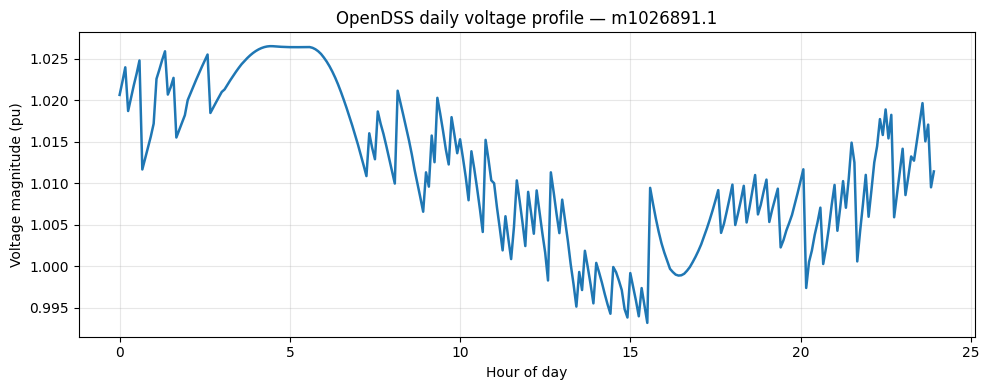

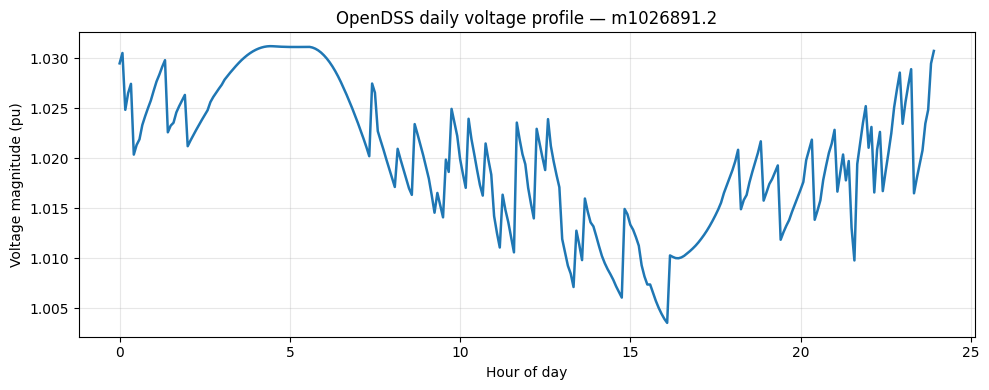

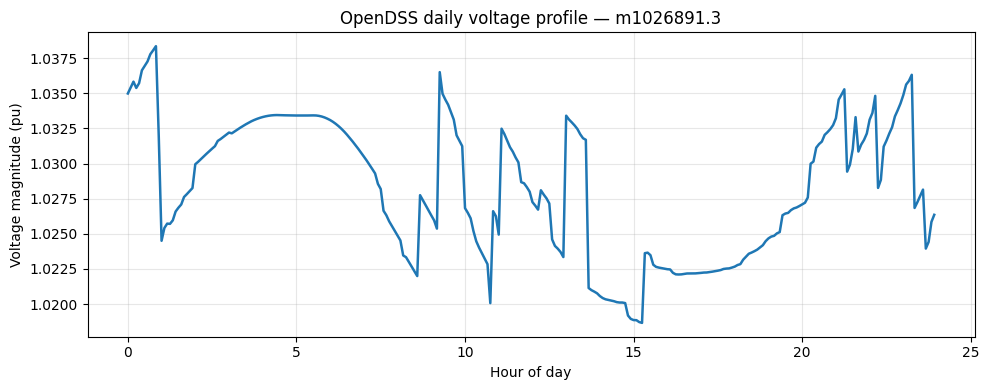

Daily solve done: nonconverged/failed steps=0, max-control-iter warnings=0


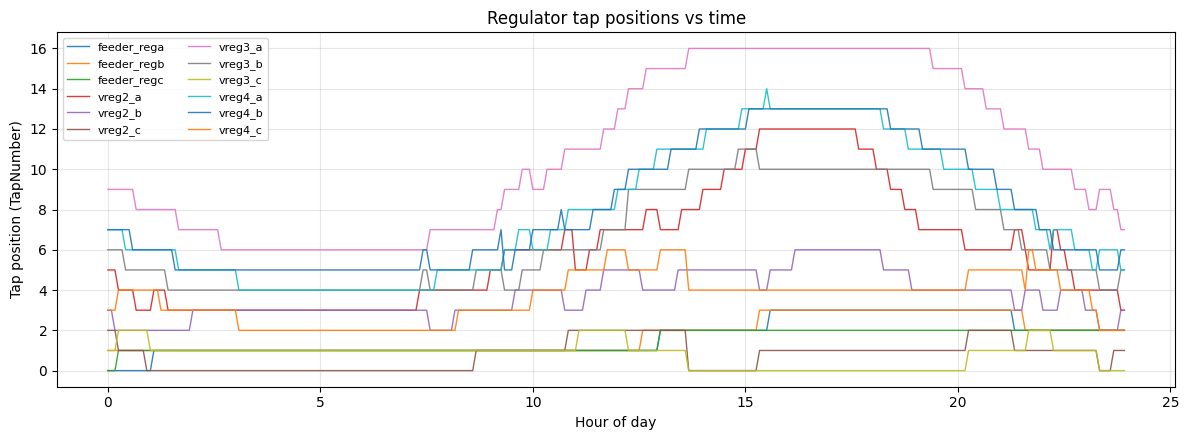

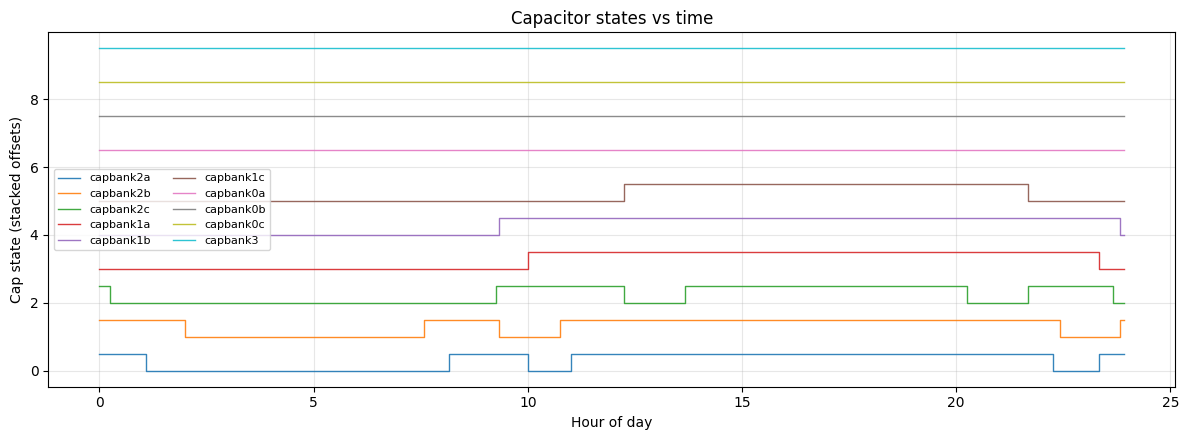


=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===
count: 2456928
min: 0.910080
p01: 0.960014
p05: 0.980945
median: 1.017059
p95: 1.041299
p99: 1.048087
max: 1.062542
mean: 1.014826
std: 0.018810
frac_below_0p95: 0.618%
frac_in_0p95_1p05: 98.904%
frac_above_1p05: 0.478%


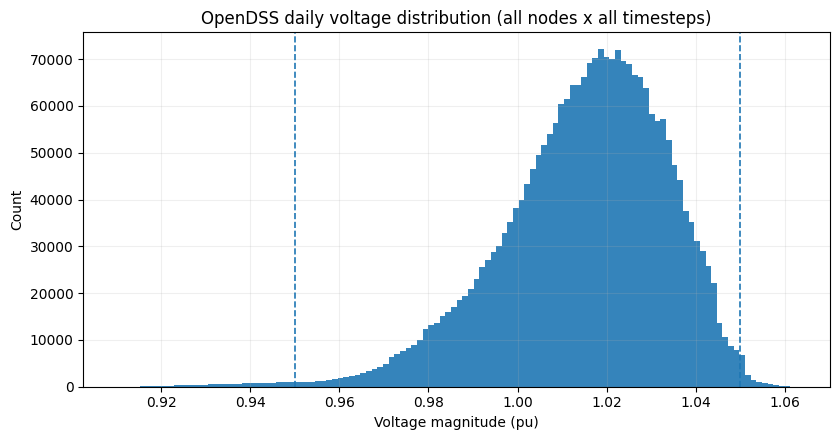


Saved:
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\opendss_daily_allnode_distribution_timeseries.csv


In [5]:
# Step 9 — OpenDSS-only daily solve (5-minute, 24h) + node plots + all-node voltage distribution
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import opendssdirect as dss
import run_injection_dataset as inj

# --- repo detection (local + Colab) ---
REPO_CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
]
repo = None
for p in REPO_CANDIDATES:
    if os.path.isfile(os.path.join(p, "8500-node", "Run_8500Node_Daily_5min.dss")):
        repo = p
        break
if repo is None:
    raise FileNotFoundError(f"Could not locate repo root. Tried: {REPO_CANDIDATES}")
os.chdir(repo)
print("Using repo:", os.getcwd())

# --- config ---
NPTS = 288
STEP_MIN = 5
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]  # edit as needed
OUT_DIR = "gnn2_daily_compare_8500_output"
os.makedirs(OUT_DIR, exist_ok=True)

RUN_DSS = os.path.join("8500-node", "Run_8500Node_Daily_5min.dss")
if not os.path.isfile(RUN_DSS):
    raise FileNotFoundError(os.path.abspath(RUN_DSS))

# --- compile/setup DSS daily entrypoint ---
# Use absolute path for robust execution.
dss.Basic.ClearAll()
dss.Text.Command(f'redirect "{os.path.abspath(RUN_DSS)}"')
# Keep daily settings explicit.
dss.Text.Command("set mode=daily")
dss.Text.Command("set stepsize=5m")
dss.Text.Command("set number=1")
# Important for 8500 daily control actions (regulators/cap controls).
dss.Text.Command("set maxiterations=30")
dss.Text.Command("set maxcontroliter=20000")

# Build node list from current compiled circuit (live DSS), not dataset CSV.
all_nodes = []
for n in dss.Circuit.AllNodeNames():
    s = str(n).strip().lower()
    if "." not in s:
        continue
    bus, phs = s.rsplit(".", 1)
    try:
        ph = int(phs)
    except Exception:
        continue
    if ph in (1, 2, 3):
        all_nodes.append(s)

# Preserve DSS order while deduplicating.
all_nodes = list(dict.fromkeys(all_nodes))
if len(all_nodes) == 0:
    raise RuntimeError("No phase nodes (1/2/3) found from dss.Circuit.AllNodeNames().")

node_to_idx = {n: i for i, n in enumerate(all_nodes)}

valid_plot_nodes = [str(n).lower() for n in PLOT_NODES if str(n).lower() in node_to_idx]
if len(valid_plot_nodes) == 0:
    valid_plot_nodes = [n for n in all_nodes if not n.startswith("sourcebus")][:3]
    print("[WARN] Requested nodes not found in live DSS nodes. Falling back to:", valid_plot_nodes)
elif len(valid_plot_nodes) < len(PLOT_NODES):
    missing = [n for n in PLOT_NODES if str(n).lower() not in node_to_idx]
    print("[WARN] Dropping missing nodes:", missing)

# --- run 24h day and collect voltages + control states ---
time_hours = np.arange(NPTS, dtype=np.float32) * (STEP_MIN / 60.0)
V_all = np.full((NPTS, len(all_nodes)), np.nan, dtype=np.float32)

# Track regulator taps and capacitor states over time.
reg_names = [n for n in dss.RegControls.AllNames() if str(n).lower() != "none"]
cap_names = [n for n in dss.Capacitors.AllNames() if str(n).lower() != "none"]

reg_taps = np.full((NPTS, len(reg_names)), np.nan, dtype=np.float32)
cap_states = np.full((NPTS, len(cap_names)), np.nan, dtype=np.float32)

n_nonconv = 0
n_ctrl_warn = 0
for t in range(NPTS):
    hr = int(t // 12)
    sec = int((t % 12) * 300)
    dss.Text.Command(f"set hour={hr} sec={sec}")
    try:
        dss.Solution.Solve()
    except Exception as e:
        # OpenDSS warning 485 can be raised as Python exception by opendssdirect.
        if "Max Control Iterations Exceeded" in str(e):
            n_ctrl_warn += 1
        n_nonconv += 1
        continue
    if not dss.Solution.Converged():
        n_nonconv += 1
        continue

    vmag, _ = inj.get_all_node_voltage_pu_and_angle_filtered(all_nodes)
    V_all[t, :] = np.asarray(vmag, dtype=np.float32)

    # Regulator tap positions
    for j, rn in enumerate(reg_names):
        try:
            dss.RegControls.Name(rn)
            reg_taps[t, j] = float(dss.RegControls.TapNumber())
        except Exception:
            reg_taps[t, j] = np.nan

    # Capacitor states: if multi-step state array exists, use 1 if any step is ON else 0
    for j, cn in enumerate(cap_names):
        try:
            dss.Capacitors.Name(cn)
            st = dss.Capacitors.States()
            if isinstance(st, (list, tuple, np.ndarray)):
                cap_states[t, j] = 1.0 if np.any(np.asarray(st, dtype=float) > 0.5) else 0.0
            else:
                cap_states[t, j] = float(st)
        except Exception:
            cap_states[t, j] = np.nan

    if (t + 1) % 24 == 0:
        print(f"[{t+1}/{NPTS}] daily solve collected", flush=True)

# --- plot selected node profiles ---
for n in valid_plot_nodes:
    i = node_to_idx[n]
    plt.figure(figsize=(10, 4))
    plt.plot(time_hours, V_all[:, i], linewidth=1.8)
    plt.xlabel("Hour of day")
    plt.ylabel("Voltage magnitude (pu)")
    plt.title(f"OpenDSS daily voltage profile — {n}")
    plt.grid(True, alpha=0.3)
    out_png = os.path.join(OUT_DIR, f"opendss_daily_profile_{n.replace('.', '_')}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

print(f"Daily solve done: nonconverged/failed steps={n_nonconv}, max-control-iter warnings={n_ctrl_warn}")

# --- control traces plots (regulators + capacitors) ---
if len(reg_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, rn in enumerate(reg_names):
        plt.plot(time_hours, reg_taps[:, j], linewidth=1.0, alpha=0.9, label=rn)
    plt.xlabel("Hour of day")
    plt.ylabel("Tap position (TapNumber)")
    plt.title("Regulator tap positions vs time")
    plt.grid(True, alpha=0.3)
    # Too many legend entries can clutter the plot.
    if len(reg_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    reg_png = os.path.join(OUT_DIR, "opendss_daily_regulator_taps.png")
    plt.tight_layout()
    plt.savefig(reg_png, dpi=170)
    plt.show()

if len(cap_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, cn in enumerate(cap_names):
        # vertical offset so state traces are distinguishable
        y = cap_states[:, j] * 0.5 + 1.0 * j
        plt.step(time_hours, y, where="post", linewidth=1.0, alpha=0.9, label=cn)
    plt.xlabel("Hour of day")
    plt.ylabel("Cap state (stacked offsets)")
    plt.title("Capacitor states vs time")
    plt.grid(True, alpha=0.3)
    if len(cap_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    cap_png = os.path.join(OUT_DIR, "opendss_daily_capacitor_states.png")
    plt.tight_layout()
    plt.savefig(cap_png, dpi=170)
    plt.show()

# --- all-node all-day distribution ---
vals = V_all[np.isfinite(V_all)]
if vals.size == 0:
    raise RuntimeError("No converged finite voltages collected for daily run.")

summary = {
    "count": int(vals.size),
    "min": float(np.min(vals)),
    "p01": float(np.percentile(vals, 1)),
    "p05": float(np.percentile(vals, 5)),
    "median": float(np.percentile(vals, 50)),
    "p95": float(np.percentile(vals, 95)),
    "p99": float(np.percentile(vals, 99)),
    "max": float(np.max(vals)),
    "mean": float(np.mean(vals)),
    "std": float(np.std(vals)),
    "frac_below_0p95": float(np.mean(vals < 0.95)),
    "frac_in_0p95_1p05": float(np.mean((vals >= 0.95) & (vals <= 1.05))),
    "frac_above_1p05": float(np.mean(vals > 1.05)),
}

print("\n=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===")
for k, v in summary.items():
    if k.startswith("frac_"):
        print(f"{k}: {100.0*v:.3f}%")
    else:
        print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

# Histogram for all node-phase voltages across full day.
plt.figure(figsize=(8.5, 4.5))
plt.hist(vals, bins=120, alpha=0.9)
plt.axvline(0.95, linestyle="--", linewidth=1.2)
plt.axvline(1.05, linestyle="--", linewidth=1.2)
plt.xlabel("Voltage magnitude (pu)")
plt.ylabel("Count")
plt.title("OpenDSS daily voltage distribution (all nodes x all timesteps)")
plt.grid(True, alpha=0.2)
hist_png = os.path.join(OUT_DIR, "opendss_daily_allnode_voltage_hist.png")
plt.tight_layout()
plt.savefig(hist_png, dpi=170)
plt.show()

# Persist per-step distribution stats as CSV.
df_step = pd.DataFrame({
    "t_index": np.arange(NPTS, dtype=int),
    "hour": time_hours,
    "n_finite": np.sum(np.isfinite(V_all), axis=1),
    "vmin": np.nanmin(V_all, axis=1),
    "vmax": np.nanmax(V_all, axis=1),
    "vmean": np.nanmean(V_all, axis=1),
    "v_p05": np.nanpercentile(V_all, 5, axis=1),
    "v_p50": np.nanpercentile(V_all, 50, axis=1),
    "v_p95": np.nanpercentile(V_all, 95, axis=1),
})
out_csv = os.path.join(OUT_DIR, "opendss_daily_allnode_distribution_timeseries.csv")
df_step.to_csv(out_csv, index=False)
print("\nSaved:")
print(" -", os.path.abspath(OUT_DIR))
print(" -", os.path.abspath(out_csv))

dataset generation

In [13]:
import os, hashlib

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    os.getcwd(),
]

script_path = None
for root in CANDIDATES:
    p = os.path.join(root, "run_daily_aggregate_dataset_8500.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        break

if script_path is None:
    raise FileNotFoundError("run_daily_aggregate_dataset_8500.py not found in candidates.")

os.chdir(os.path.dirname(script_path))
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

# Verify this is the updated script
txt = open(script_path, encoding="utf-8").read()
print("has_new_diag:", ("top_offenders" in txt and "pct_out" in txt and "n_v_below_safe_band" in txt))
print("md5:", hashlib.md5(txt.encode("utf-8")).hexdigest())

exec(txt, {"__name__": "__main__", "__file__": script_path})

CWD: c:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_daily_aggregate_dataset_8500.py
has_new_diag: True
md5: 8140fa1c268b15f99a8f754d276d9a59
[diag] safe-band eval: 8531/8531 nodes (all phase nodes, no kVBase filter — aligned with notebook Step 9)
[saved] phase-edge CSV -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_edges_phase_static.csv | rows=14238 | cols=17 | bidirectional=True
[diag] electrical_distance_ohm: min=0 max=40.8786 (|Z| sum along min-|Z| path from substation)
[diag] regcontrols=12 capacitors=10
[scenario 1/500] scale=0.788 kept_samples=20 nonconv_this_s=0 badV_this_s=0 v_outside_band_this_s=0 (below=0, above=0, pct=0.00%) N_nodes=8531 top_offenders=[none] skip_nonconv_total=0 skip_badV_total=0
[scenario 2/500] scale=1.241 kept_samples=40 nonconv_this_s=0 badV_this_s=0 v_outside_band_this_s=84 (below=84, above=0, pct=0.05%) N_nodes=8531 top_offenders=[sx2767342a.1:3, sx2767342a.2:3, sx2748780a.1:3, s

In [4]:
import os
import pandas as pd

base = r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg"

sample_csv = os.path.join(base, "gnn_sample_meta.csv")
node_csv   = os.path.join(base, "gnn_node_features_and_targets.csv")
edge_csv   = os.path.join(base, "gnn_edges_phase_static.csv")

print("=== sample meta (first 20 rows) ===")
df_s = pd.read_csv(sample_csv, nrows=0)
print(df_s)

print("\n=== node features/targets (first 20 rows) ===")
df_n = pd.read_csv(node_csv, nrows=100)
print(df_n)

print("\n=== edges (first 20 rows) ===")
df_e = pd.read_csv(edge_csv, nrows=0)
print(df_e)

=== sample meta (first 20 rows) ===
Empty DataFrame
Columns: [sample_id, scenario_id, t_index, t_minutes, scenario_total_load_scale, m_loadshape, effective_total_scale, P_load_sum_post_kw, Q_load_sum_post_kvar, P_loss_total_post_kw, Q_loss_total_post_kvar, P_grid_upstream_post_kw, Q_grid_upstream_post_kvar, sigma_device, safe_vmin_pu, safe_vmax_pu, n_v_outside_safe_band, n_v_below_safe_band, n_v_above_safe_band, reg_feeder_rega_tap_pu, reg_feeder_regb_tap_pu, reg_feeder_regc_tap_pu, reg_vreg2_a_tap_pu, reg_vreg2_b_tap_pu, reg_vreg2_c_tap_pu, reg_vreg3_a_tap_pu, reg_vreg3_b_tap_pu, reg_vreg3_c_tap_pu, reg_vreg4_a_tap_pu, reg_vreg4_b_tap_pu, reg_vreg4_c_tap_pu, cap_capbank0a_n_steps_on, cap_capbank0a_q_nominal_kvar, cap_capbank0a_q_post_kvar, cap_capbank0b_n_steps_on, cap_capbank0b_q_nominal_kvar, cap_capbank0b_q_post_kvar, cap_capbank0c_n_steps_on, cap_capbank0c_q_nominal_kvar, cap_capbank0c_q_post_kvar, cap_capbank1a_n_steps_on, cap_capbank1a_q_nominal_kvar, cap_capbank1a_q_post_kvar, 

### 8500 device-state MLP architecture search

Trains five **non-graph** MLPs on the flattened nodal vector (**p_load_kw**, **q_load_kvar** for every node) to predict **22** device-state targets in `gnn_sample_meta.csv`. No edge or static graph features are used. Checkpoints (`best.pt`) and `summary.json` are written to `gnn2_architecture_search/`. The first run streams the large node CSV once; `--node-cache` saves a tensor `.pt` for faster reruns.

**Colab:** Run your **setup cell** first (clone to `/content/GNN-Sandia` and `chdir` there), or ensure the cwd is the repo root so `train_8500_device_state_arch_search.py` is visible. The training cell also checks `/content/GNN-Sandia` and `/content/GNN2`. Optional: `os.environ["GNN_REPO"] = "/content/GNN-Sandia"`.

Then add `datasets_gnn2/loadtype_8500_dailyagg/` (upload or Google Drive).

In [ ]:
import os
import subprocess
import sys
from pathlib import Path


def _detect_repo_root() -> Path:
    """Return a directory that contains train_8500_device_state_arch_search.py (never a non-existent path)."""
    marker = "train_8500_device_state_arch_search.py"

    def _has_script(p: Path) -> bool:
        return (p / marker).is_file()

    env = (os.environ.get("GNN2_REPO") or os.environ.get("GNN_REPO") or "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if _has_script(p):
            return p
        raise FileNotFoundError(
            f"GNN2_REPO/GNN_REPO={env!r} but {marker} not found there. Fix the path or unset the env var."
        )

    # If the notebook cwd is already the repo (e.g. after os.chdir("/content/GNN-Sandia")), use it.
    cwd = Path.cwd().resolve()
    if _has_script(cwd):
        return cwd

    try:
        import google.colab  # noqa: F401

        _colab = True
    except ImportError:
        _colab = False

    if _colab:
        # Match common Colab clone targets (setup cell often uses /content/GNN-Sandia)
        for p in (
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
            Path("/content/drive/MyDrive/GNN-Sandia"),
            Path("/content/drive/MyDrive/GNN2"),
            Path("/content/drive/MyDrive/Desktop/GNN2"),
        ):
            if _has_script(p):
                return p.resolve()

    win = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
    if _has_script(win):
        return win.resolve()

    raise FileNotFoundError(
        "Cannot find the repo (missing train_8500_device_state_arch_search.py).\n"
        "On Colab run your setup cell first (clone + chdir), e.g.:\n"
        "  !git clone https://github.com/alitasavori/GNN-Sandia.git /content/GNN-Sandia\n"
        "  %cd /content/GNN-Sandia\n"
        "Or set: os.environ['GNN_REPO'] = '/content/GNN-Sandia'"
    )


repo = str(_detect_repo_root())
os.chdir(repo)
outd = os.path.join(repo, "gnn2_architecture_search")
cache = os.path.join(outd, "node_features_X.pt")
os.makedirs(outd, exist_ok=True)

cmd = [
    sys.executable,
    "-u",
    "train_8500_device_state_arch_search.py",
    "--repo-root",
    repo,
    "--epochs",
    "100",
    "--out-dir",
    outd,
    "--node-cache",
    cache,
    "--log-every",
    "10",
]
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
print("Starting (streaming logs):", " ".join(cmd), flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_8500_device_state_arch_search.py exited with code {ret}")

### 8500 device-state: 22 targets x 3 MLP architectures (softmax)

This trains **3 different MLP architectures per target** for all **22 targets** (**66 total training runs**). Each target is still an independent softmax classifier (discrete tap/step classes), but only the **best architecture per target** is saved as `best.pt`. All run metrics are reported and written to `summary.json` under `gnn2_architecture_search_softmax_22/`.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path


def _detect_repo_root() -> Path:
    marker = "train_8500_device_state_softmax_22models.py"

    def _has_script(p: Path) -> bool:
        return (p / marker).is_file()

    env = (os.environ.get("GNN_REPO") or os.environ.get("GNN2_REPO") or "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if _has_script(p):
            return p
        raise FileNotFoundError(f"Repo env points to {p}, but {marker} not found there.")

    cwd = Path.cwd().resolve()
    if _has_script(cwd):
        return cwd

    for p in (
        Path("/content/GNN-Sandia"),
        Path("/content/GNN2"),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
    ):
        if _has_script(p):
            return p.resolve()

    raise FileNotFoundError(
        "Could not find train_8500_device_state_softmax_22models.py.\n"
        "Clone/open the repo root first."
    )


repo = str(_detect_repo_root())
os.chdir(repo)
outd = os.path.join(repo, "gnn2_architecture_search_softmax_22")
cache = os.path.join(outd, "node_features_X.pt")
os.makedirs(outd, exist_ok=True)

cmd = [
    sys.executable,
    "-u",
    "train_8500_device_state_softmax_22models.py",
    "--repo-root",
    repo,
    "--epochs",
    "100",
    "--out-dir",
    outd,
    "--node-cache",
    cache,
    "--log-every",
    "10",
]
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
print("Starting (streaming logs):", " ".join(cmd), flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_8500_device_state_softmax_22models.py exited with code {ret}")

Starting (streaming logs): /usr/bin/python3 -u train_8500_device_state_softmax_22models.py --repo-root /content/GNN-Sandia --epochs 100 --out-dir /content/GNN-Sandia/gnn2_architecture_search_softmax_22 --node-cache /content/GNN-Sandia/gnn2_architecture_search_softmax_22/node_features_X.pt --log-every 10
[8500 softmax-22] repo_root=/content/GNN-Sandia
[8500 softmax-22] dataset_dir=/content/GNN-Sandia/datasets_gnn2/loadtype_8500_dailyagg
  inferring N_nodes from gnn_node_features_and_targets.csv...
  loading node tensor from cache /content/GNN-Sandia/gnn2_architecture_search_softmax_22/node_features_X.pt
  samples=9770 n_nodes=8531 flat_dim=17062 targets=22
  split train=6839 val=1465 test=1466
  device=cuda log_every=10
  architecture_search=enabled (3 architectures/target)

--- Training target 1/22: reg_feeder_rega_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.785128  train_acc=0.3103  val_ce=2.093726  val_acc=0.4451  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.311132  train_acc=0.4698  val_ce=1.520507  val_acc=0.4314  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.201159  train_acc=0.5233  val_ce=1.180545  val_acc=0.5283  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.179941  train_acc=0.5299  val_ce=1.395881  val_acc=0.5058  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.143537  train_acc=0.5337  val_ce=1.248413  val_acc=0.5010  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.068557  train_acc=0.5540  val_ce=1.197619  val_acc=0.5468  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.026291  train_acc=0.5646  val_ce=1.265716  val_acc=0.5911  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.025558  train_acc=0.5670  val_ce=1.313340  val_acc=0.5857  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=1.010194  train_acc=0.5700  val_ce=1.321608  val_acc=0.5857  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.996759  train_acc=0.5768  val_ce=1.312797  val_acc=0.5850  lr=1.56e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.003836  train_acc=0.5748  val_ce=1.305724  val_acc=0.5836  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.960953  train_acc=0.3006  val_ce=1.932253  val_acc=0.5311  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.184163  train_acc=0.4888  val_ce=1.121602  val_acc=0.5017  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.141700  train_acc=0.5284  val_ce=1.218022  val_acc=0.4997  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.123540  train_acc=0.5384  val_ce=1.189193  val_acc=0.5406  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.066635  train_acc=0.5510  val_ce=1.049067  val_acc=0.5433  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.121683  train_acc=0.5499  val_ce=1.016442  val_acc=0.5570  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.045906  train_acc=0.5681  val_ce=1.039007  val_acc=0.5775  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.972322  train_acc=0.5706  val_ce=1.014052  val_acc=0.5809  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.976394  train_acc=0.5682  val_ce=1.127213  val_acc=0.5809  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.948580  train_acc=0.5694  val_ce=1.033746  val_acc=0.5863  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.953587  train_acc=0.5793  val_ce=1.081262  val_acc=0.5836  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.204298  train_acc=0.1019  val_ce=2.390252  val_acc=0.3072  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.321440  train_acc=0.4607  val_ce=1.332625  val_acc=0.4901  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.237681  train_acc=0.4651  val_ce=1.360731  val_acc=0.4792  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.206019  train_acc=0.4862  val_ce=1.175159  val_acc=0.4976  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.273325  train_acc=0.4837  val_ce=1.186417  val_acc=0.4696  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.136436  train_acc=0.4979  val_ce=1.240652  val_acc=0.5256  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.046295  train_acc=0.5112  val_ce=1.185225  val_acc=0.5242  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.069537  train_acc=0.5194  val_ce=1.199074  val_acc=0.5358  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.023499  train_acc=0.5153  val_ce=1.150149  val_acc=0.5229  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.028631  train_acc=0.5201  val_ce=1.169092  val_acc=0.5317  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.076475  train_acc=0.5181  val_ce=1.159809  val_acc=0.5331  lr=1.56e-05
  done reg_feeder_rega_tap_pu: best_arch=a2_mid_deep val_ce=0.960882  val_acc=0.5502 n_classes=10

--- Training target 2/22: reg_feeder_regb_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=3.443107  train_acc=0.2335  val_ce=2.593592  val_acc=0.3174  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.442946  train_acc=0.4751  val_ce=1.522068  val_acc=0.4130  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.475067  train_acc=0.4982  val_ce=1.420610  val_acc=0.4567  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.106600  train_acc=0.5391  val_ce=1.148813  val_acc=0.5515  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=1.118390  train_acc=0.5495  val_ce=1.158905  val_acc=0.5352  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.096515  train_acc=0.5463  val_ce=1.045493  val_acc=0.5577  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.097504  train_acc=0.5445  val_ce=1.069627  val_acc=0.5686  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.015036  train_acc=0.5672  val_ce=1.041160  val_acc=0.5543  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.034784  train_acc=0.5548  val_ce=1.046675  val_acc=0.5488  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.024875  train_acc=0.5629  val_ce=1.067027  val_acc=0.5645  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.979793  train_acc=0.5589  val_ce=1.082639  val_acc=0.5563  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.290009  train_acc=0.2521  val_ce=2.220945  val_acc=0.3823  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.508930  train_acc=0.4524  val_ce=1.526969  val_acc=0.4642  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.305545  train_acc=0.5125  val_ce=1.269828  val_acc=0.5242  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.357094  train_acc=0.5059  val_ce=1.143978  val_acc=0.4491  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.295037  train_acc=0.5093  val_ce=1.187982  val_acc=0.4976  lr=1.00e-03
    [a2_mid_deep] epoch   50/100  train_ce=1.314754  train_acc=0.5203  val_ce=1.291568  val_acc=0.4744  lr=1.00e-03
    [a2_mid_deep] epoch   60/100  train_ce=1.184360  train_acc=0.5334  val_ce=1.084545  val_acc=0.5167  lr=1.00e-03
    [a2_mid_deep] epoch   70/100  train_ce=1.302275  train_acc=0.5350  val_ce=1.025362  val_acc=0.5188  lr=1.00e-03
    [a2_mid_deep] epoch   80/100  train_ce=1.000850  train_acc=0.5495  val_ce=0.911330  val_acc=0.5283  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=0.990973  train_acc=0.5523  val_ce=1.098895  val_acc=0.5563  lr=5.00e-04
    [a2_mid_deep] epoch  100/100  train_ce=0.964533  train_acc=0.5572  val_ce=0.881883  val_acc=0.5372  lr=2.50e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.517990  train_acc=0.0512  val_ce=2.559258  val_acc=0.1003  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.540433  train_acc=0.3698  val_ce=1.451906  val_acc=0.3672  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.392646  train_acc=0.3821  val_ce=1.253878  val_acc=0.3877  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.357510  train_acc=0.3967  val_ce=1.235270  val_acc=0.4075  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.256715  train_acc=0.4062  val_ce=1.109031  val_acc=0.4109  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.215762  train_acc=0.4068  val_ce=1.054626  val_acc=0.3898  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.193072  train_acc=0.4201  val_ce=1.032079  val_acc=0.4061  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.138338  train_acc=0.4274  val_ce=1.082019  val_acc=0.4485  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.055890  train_acc=0.4325  val_ce=1.020669  val_acc=0.4594  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.096085  train_acc=0.4362  val_ce=0.959708  val_acc=0.4635  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.114437  train_acc=0.4388  val_ce=0.949575  val_acc=0.4478  lr=3.13e-05
  done reg_feeder_regb_tap_pu: best_arch=a2_mid_deep val_ce=0.853694  val_acc=0.5509 n_classes=12

--- Training target 3/22: reg_feeder_regc_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.980528  train_acc=0.3325  val_ce=2.109731  val_acc=0.5010  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.820866  train_acc=0.5667  val_ce=0.765428  val_acc=0.5761  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.828353  train_acc=0.5666  val_ce=0.775789  val_acc=0.6137  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.704356  train_acc=0.5872  val_ce=0.604688  val_acc=0.6498  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.683436  train_acc=0.5852  val_ce=0.854221  val_acc=0.6553  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.645240  train_acc=0.5916  val_ce=0.616979  val_acc=0.6294  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.649375  train_acc=0.5928  val_ce=0.583700  val_acc=0.6164  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.638907  train_acc=0.5994  val_ce=0.581280  val_acc=0.6410  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.633085  train_acc=0.6049  val_ce=0.546892  val_acc=0.6410  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.637447  train_acc=0.6113  val_ce=0.533528  val_acc=0.6389  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.616834  train_acc=0.6075  val_ce=0.498729  val_acc=0.6266  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.376888  train_acc=0.3705  val_ce=1.203657  val_acc=0.3870  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.882876  train_acc=0.5648  val_ce=0.890855  val_acc=0.5891  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.745848  train_acc=0.5726  val_ce=0.999508  val_acc=0.6491  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.670154  train_acc=0.5906  val_ce=0.600318  val_acc=0.6246  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.674820  train_acc=0.5903  val_ce=0.606627  val_acc=0.6457  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.610172  train_acc=0.6070  val_ce=0.520240  val_acc=0.6396  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.610058  train_acc=0.5970  val_ce=0.500874  val_acc=0.6300  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.618407  train_acc=0.6083  val_ce=0.493887  val_acc=0.6396  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.609285  train_acc=0.6036  val_ce=0.493371  val_acc=0.6280  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.615898  train_acc=0.6055  val_ce=0.491645  val_acc=0.6341  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.590565  train_acc=0.6049  val_ce=0.497643  val_acc=0.6348  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.480873  train_acc=0.3189  val_ce=1.178436  val_acc=0.4744  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.902165  train_acc=0.5024  val_ce=0.847397  val_acc=0.6430  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.784326  train_acc=0.5590  val_ce=0.631226  val_acc=0.6628  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.733360  train_acc=0.5809  val_ce=0.592219  val_acc=0.6355  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.713048  train_acc=0.5803  val_ce=0.544397  val_acc=0.6382  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.758696  train_acc=0.5767  val_ce=0.591380  val_acc=0.6437  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.660032  train_acc=0.5770  val_ce=0.522912  val_acc=0.6382  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.681346  train_acc=0.5874  val_ce=0.521724  val_acc=0.6423  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.625090  train_acc=0.5913  val_ce=0.543611  val_acc=0.6396  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.636787  train_acc=0.5903  val_ce=0.505213  val_acc=0.6341  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.674618  train_acc=0.5975  val_ce=0.506462  val_acc=0.6444  lr=6.25e-05
  done reg_feeder_regc_tap_pu: best_arch=a2_mid_deep val_ce=0.491271  val_acc=0.6334 n_classes=6

--- Training target 4/22: reg_vreg2_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.852436  train_acc=0.1512  val_ce=2.364968  val_acc=0.2102  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.981566  train_acc=0.2614  val_ce=1.856023  val_acc=0.2635  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.920550  train_acc=0.2870  val_ce=1.874677  val_acc=0.2430  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.892291  train_acc=0.2797  val_ce=1.849393  val_acc=0.2785  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.901371  train_acc=0.2812  val_ce=1.897536  val_acc=0.2737  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.834037  train_acc=0.3125  val_ce=1.797937  val_acc=0.2935  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.819876  train_acc=0.3106  val_ce=1.768523  val_acc=0.3208  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.789409  train_acc=0.3258  val_ce=1.759392  val_acc=0.3195  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.788949  train_acc=0.3258  val_ce=1.762972  val_acc=0.3256  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.773418  train_acc=0.3204  val_ce=1.758553  val_acc=0.3092  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.767813  train_acc=0.3202  val_ce=1.758884  val_acc=0.3167  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.612315  train_acc=0.1165  val_ce=2.117136  val_acc=0.2294  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.956978  train_acc=0.2540  val_ce=1.834561  val_acc=0.2587  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.912346  train_acc=0.2628  val_ce=1.914074  val_acc=0.3003  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.883249  train_acc=0.2867  val_ce=1.804562  val_acc=0.3290  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.859324  train_acc=0.2913  val_ce=1.823919  val_acc=0.3474  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.839336  train_acc=0.2916  val_ce=1.792415  val_acc=0.3392  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.818499  train_acc=0.2954  val_ce=1.864542  val_acc=0.3345  lr=5.00e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.809168  train_acc=0.3022  val_ce=1.756115  val_acc=0.3078  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.802874  train_acc=0.3101  val_ce=1.751330  val_acc=0.3352  lr=2.50e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.782457  train_acc=0.3131  val_ce=1.746677  val_acc=0.3229  lr=1.25e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.771743  train_acc=0.3142  val_ce=1.741425  val_acc=0.3160  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.717541  train_acc=0.0659  val_ce=2.355420  val_acc=0.0710  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=2.005182  train_acc=0.2451  val_ce=1.871374  val_acc=0.3188  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.979275  train_acc=0.2462  val_ce=1.907893  val_acc=0.3072  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.949745  train_acc=0.2824  val_ce=1.859057  val_acc=0.3058  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.916957  train_acc=0.2739  val_ce=1.903024  val_acc=0.3147  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.868669  train_acc=0.2882  val_ce=1.779077  val_acc=0.3038  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.832366  train_acc=0.2935  val_ce=1.754323  val_acc=0.2942  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.841344  train_acc=0.2898  val_ce=1.756016  val_acc=0.2935  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.807249  train_acc=0.2965  val_ce=1.763495  val_acc=0.2956  lr=1.25e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.800530  train_acc=0.3062  val_ce=1.740816  val_acc=0.3201  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.805238  train_acc=0.3119  val_ce=1.738047  val_acc=0.3263  lr=6.25e-05
  done reg_vreg2_a_tap_pu: best_arch=a2_mid_deep val_ce=1.736592  val_acc=0.2990 n_classes=18

--- Training target 5/22: reg_vreg2_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=4.328225  train_acc=0.1538  val_ce=2.794092  val_acc=0.1413  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=2.065607  train_acc=0.2524  val_ce=1.988864  val_acc=0.2799  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=2.018243  train_acc=0.2701  val_ce=2.151392  val_acc=0.2751  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.858376  train_acc=0.3078  val_ce=2.098429  val_acc=0.3638  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.832572  train_acc=0.3081  val_ce=1.897879  val_acc=0.3420  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.819361  train_acc=0.3239  val_ce=1.742139  val_acc=0.3399  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.812760  train_acc=0.3227  val_ce=3.401402  val_acc=0.3358  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.776114  train_acc=0.3210  val_ce=1.750331  val_acc=0.3338  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.679872  train_acc=0.3438  val_ce=1.733603  val_acc=0.3263  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.689068  train_acc=0.3414  val_ce=1.717854  val_acc=0.3208  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.656735  train_acc=0.3370  val_ce=1.694439  val_acc=0.3283  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=3.038969  train_acc=0.1233  val_ce=2.518837  val_acc=0.0792  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=2.015205  train_acc=0.2405  val_ce=1.848197  val_acc=0.3017  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.904347  train_acc=0.2929  val_ce=1.903603  val_acc=0.3072  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.944949  train_acc=0.2777  val_ce=1.824089  val_acc=0.2491  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.809118  train_acc=0.3214  val_ce=1.884050  val_acc=0.3795  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.800476  train_acc=0.3265  val_ce=1.712627  val_acc=0.3413  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.849888  train_acc=0.3017  val_ce=2.048462  val_acc=0.3345  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.712145  train_acc=0.3265  val_ce=1.684630  val_acc=0.3427  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.638941  train_acc=0.3384  val_ce=1.648122  val_acc=0.3276  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.626677  train_acc=0.3308  val_ce=1.704317  val_acc=0.3201  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.579011  train_acc=0.3373  val_ce=1.685961  val_acc=0.3188  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.958426  train_acc=0.0322  val_ce=2.836592  val_acc=0.0096  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=2.138258  train_acc=0.1449  val_ce=1.970567  val_acc=0.3092  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=2.096134  train_acc=0.1986  val_ce=1.833573  val_acc=0.2007  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=2.087389  train_acc=0.2212  val_ce=2.413283  val_acc=0.2805  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.909990  train_acc=0.2821  val_ce=1.889753  val_acc=0.3208  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.802581  train_acc=0.2933  val_ce=1.847383  val_acc=0.3154  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.753046  train_acc=0.3094  val_ce=1.798178  val_acc=0.3024  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.692842  train_acc=0.3153  val_ce=1.800004  val_acc=0.3010  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.668507  train_acc=0.3258  val_ce=1.828870  val_acc=0.2997  lr=3.13e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.650897  train_acc=0.3274  val_ce=1.787772  val_acc=0.3003  lr=1.56e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.647728  train_acc=0.3262  val_ce=1.817200  val_acc=0.2962  lr=7.81e-06
  done reg_vreg2_b_tap_pu: best_arch=a2_mid_deep val_ce=1.592399  val_acc=0.3379 n_classes=18

--- Training target 6/22: reg_vreg2_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.777652  train_acc=0.2250  val_ce=3.106838  val_acc=0.1904  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.464234  train_acc=0.2445  val_ce=1.473196  val_acc=0.3147  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.462029  train_acc=0.2487  val_ce=1.491361  val_acc=0.2758  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.424047  train_acc=0.2597  val_ce=1.418414  val_acc=0.2751  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=1.428276  train_acc=0.2590  val_ce=1.428547  val_acc=0.2826  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.412674  train_acc=0.2610  val_ce=1.403563  val_acc=0.2683  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.395153  train_acc=0.2688  val_ce=1.422559  val_acc=0.2703  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.388895  train_acc=0.2740  val_ce=1.399531  val_acc=0.2724  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.396520  train_acc=0.2707  val_ce=1.392459  val_acc=0.2785  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.407835  train_acc=0.2766  val_ce=1.400029  val_acc=0.2710  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.387826  train_acc=0.2742  val_ce=1.393122  val_acc=0.2751  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.754166  train_acc=0.2731  val_ce=2.134874  val_acc=0.2983  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.468629  train_acc=0.2483  val_ce=1.454470  val_acc=0.3065  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.455575  train_acc=0.2530  val_ce=1.444639  val_acc=0.2239  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.441613  train_acc=0.2534  val_ce=1.481925  val_acc=0.2771  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.436074  train_acc=0.2502  val_ce=1.426451  val_acc=0.2744  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.429147  train_acc=0.2591  val_ce=1.443108  val_acc=0.2614  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.423044  train_acc=0.2524  val_ce=1.419561  val_acc=0.2635  lr=5.00e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.421580  train_acc=0.2509  val_ce=1.400641  val_acc=0.2915  lr=5.00e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.403336  train_acc=0.2695  val_ce=1.403081  val_acc=0.2696  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.399050  train_acc=0.2647  val_ce=1.394228  val_acc=0.2717  lr=2.50e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.405502  train_acc=0.2607  val_ce=1.391502  val_acc=0.2621  lr=1.25e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.663707  train_acc=0.2797  val_ce=1.623673  val_acc=0.1904  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.581272  train_acc=0.3410  val_ce=1.607340  val_acc=0.4696  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.581187  train_acc=0.3147  val_ce=1.609540  val_acc=0.2983  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=1.577290  train_acc=0.2990  val_ce=1.611001  val_acc=0.2983  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.576415  train_acc=0.3019  val_ce=1.611650  val_acc=0.2983  lr=6.25e-05
    [a3_narrow_deeper] epoch   50/100  train_ce=1.577647  train_acc=0.2968  val_ce=1.611821  val_acc=0.2983  lr=3.13e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=1.577043  train_acc=0.2940  val_ce=1.611887  val_acc=0.2983  lr=1.56e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=1.578586  train_acc=0.2838  val_ce=1.611891  val_acc=0.2983  lr=7.81e-06
    [a3_narrow_deeper] epoch   80/100  train_ce=1.576291  train_acc=0.2927  val_ce=1.611878  val_acc=0.2983  lr=3.91e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=1.579352  train_acc=0.2958  val_ce=1.611892  val_acc=0.2983  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=1.576220  train_acc=0.2987  val_ce=1.611899  val_acc=0.2983  lr=9.77e-07
  done reg_vreg2_c_tap_pu: best_arch=a2_mid_deep val_ce=1.385897  val_acc=0.2710 n_classes=5

--- Training target 7/22: reg_vreg3_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.574374  train_acc=0.1664  val_ce=2.172363  val_acc=0.1911  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.899372  train_acc=0.3370  val_ce=1.824104  val_acc=0.3440  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.856317  train_acc=0.3410  val_ce=1.807177  val_acc=0.3167  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.825598  train_acc=0.3460  val_ce=1.774283  val_acc=0.3242  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.791594  train_acc=0.3501  val_ce=1.765075  val_acc=0.3392  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.798600  train_acc=0.3498  val_ce=1.740756  val_acc=0.3638  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=1.784759  train_acc=0.3603  val_ce=1.744254  val_acc=0.3413  lr=1.00e-03
    [a1_wide_shallow] epoch   70/100  train_ce=1.753953  train_acc=0.3734  val_ce=1.702266  val_acc=0.3782  lr=5.00e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.744749  train_acc=0.3752  val_ce=1.699131  val_acc=0.3754  lr=5.00e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.737066  train_acc=0.3777  val_ce=1.710622  val_acc=0.3543  lr=5.00e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.724701  train_acc=0.3772  val_ce=1.694401  val_acc=0.3741  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.466337  train_acc=0.1642  val_ce=2.170825  val_acc=0.2075  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.865512  train_acc=0.3354  val_ce=1.814839  val_acc=0.3167  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.835076  train_acc=0.3451  val_ce=1.776143  val_acc=0.3352  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.808699  train_acc=0.3521  val_ce=1.762006  val_acc=0.3427  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.766147  train_acc=0.3653  val_ce=1.712380  val_acc=0.3761  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.742301  train_acc=0.3638  val_ce=1.707394  val_acc=0.3618  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.723627  train_acc=0.3724  val_ce=1.682473  val_acc=0.3768  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.731774  train_acc=0.3752  val_ce=1.684098  val_acc=0.3788  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.720492  train_acc=0.3724  val_ce=1.676726  val_acc=0.3863  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.706972  train_acc=0.3793  val_ce=1.673526  val_acc=0.3836  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.711832  train_acc=0.3812  val_ce=1.674866  val_acc=0.3816  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.757239  train_acc=0.1041  val_ce=2.324218  val_acc=0.1809  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.921853  train_acc=0.3245  val_ce=1.924404  val_acc=0.2491  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.893942  train_acc=0.3405  val_ce=1.792617  val_acc=0.3891  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.854199  train_acc=0.3455  val_ce=1.777295  val_acc=0.3741  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.839376  train_acc=0.3460  val_ce=1.809518  val_acc=0.3311  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.786310  train_acc=0.3609  val_ce=1.762571  val_acc=0.3406  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.789836  train_acc=0.3582  val_ce=1.756662  val_acc=0.3392  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.778604  train_acc=0.3616  val_ce=1.767275  val_acc=0.3365  lr=5.00e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.757695  train_acc=0.3692  val_ce=1.704322  val_acc=0.3741  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.763279  train_acc=0.3692  val_ce=1.711228  val_acc=0.3440  lr=2.50e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.744833  train_acc=0.3707  val_ce=1.695452  val_acc=0.3720  lr=1.25e-04
  done reg_vreg3_a_tap_pu: best_arch=a2_mid_deep val_ce=1.671616  val_acc=0.3857 n_classes=20

--- Training target 8/22: reg_vreg3_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.796199  train_acc=0.1149  val_ce=2.112484  val_acc=0.1761  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.743457  train_acc=0.2897  val_ce=1.725847  val_acc=0.2464  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.700063  train_acc=0.3139  val_ce=1.623089  val_acc=0.3379  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.694252  train_acc=0.3135  val_ce=1.589508  val_acc=0.3631  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.644048  train_acc=0.3223  val_ce=1.674642  val_acc=0.3072  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.578174  train_acc=0.3482  val_ce=1.570648  val_acc=0.3399  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.554313  train_acc=0.3490  val_ce=1.554994  val_acc=0.3700  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.513484  train_acc=0.3620  val_ce=1.508873  val_acc=0.3706  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.495303  train_acc=0.3578  val_ce=1.501007  val_acc=0.3679  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.499659  train_acc=0.3560  val_ce=1.503325  val_acc=0.3693  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.486734  train_acc=0.3653  val_ce=1.495040  val_acc=0.3631  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.525344  train_acc=0.1138  val_ce=2.057831  val_acc=0.2000  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.705156  train_acc=0.2916  val_ce=1.593271  val_acc=0.3666  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.613738  train_acc=0.3031  val_ce=1.589949  val_acc=0.3672  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.604429  train_acc=0.3132  val_ce=1.566949  val_acc=0.3577  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.550666  train_acc=0.3367  val_ce=1.519475  val_acc=0.3631  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.541339  train_acc=0.3335  val_ce=1.508626  val_acc=0.3631  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.511429  train_acc=0.3403  val_ce=1.493335  val_acc=0.3659  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.507287  train_acc=0.3378  val_ce=1.492561  val_acc=0.3570  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=1.492154  train_acc=0.3506  val_ce=1.492733  val_acc=0.3549  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.491310  train_acc=0.3451  val_ce=1.492979  val_acc=0.3522  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.487372  train_acc=0.3471  val_ce=1.488984  val_acc=0.3543  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.688257  train_acc=0.0727  val_ce=2.223783  val_acc=0.2075  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.807731  train_acc=0.2609  val_ce=1.693534  val_acc=0.3365  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.694475  train_acc=0.2940  val_ce=1.654808  val_acc=0.3311  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=1.651094  train_acc=0.2980  val_ce=1.579184  val_acc=0.3311  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.611122  train_acc=0.3068  val_ce=1.568226  val_acc=0.3536  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.622584  train_acc=0.3072  val_ce=1.568488  val_acc=0.3433  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.564279  train_acc=0.3305  val_ce=1.511087  val_acc=0.3570  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.567847  train_acc=0.3256  val_ce=1.512148  val_acc=0.3488  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.547154  train_acc=0.3372  val_ce=1.506800  val_acc=0.3522  lr=1.25e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.541315  train_acc=0.3359  val_ce=1.502553  val_acc=0.3495  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.532730  train_acc=0.3340  val_ce=1.505401  val_acc=0.3495  lr=6.25e-05
  done reg_vreg3_b_tap_pu: best_arch=a2_mid_deep val_ce=1.488059  val_acc=0.3556 n_classes=20

--- Training target 9/22: reg_vreg3_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.951935  train_acc=0.2785  val_ce=1.540195  val_acc=0.3652  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.358691  train_acc=0.3957  val_ce=1.305276  val_acc=0.3208  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.322436  train_acc=0.4056  val_ce=1.315957  val_acc=0.3563  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.307857  train_acc=0.4120  val_ce=1.263093  val_acc=0.3338  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.299695  train_acc=0.4159  val_ce=1.256265  val_acc=0.4294  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.293500  train_acc=0.4058  val_ce=1.245261  val_acc=0.4191  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=1.255274  train_acc=0.4172  val_ce=1.236022  val_acc=0.4157  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.230305  train_acc=0.4198  val_ce=1.215804  val_acc=0.4102  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.228872  train_acc=0.4195  val_ce=1.209355  val_acc=0.4123  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.227026  train_acc=0.4116  val_ce=1.208299  val_acc=0.4130  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.228918  train_acc=0.4137  val_ce=1.204297  val_acc=0.4294  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.769292  train_acc=0.2996  val_ce=1.442545  val_acc=0.4355  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.355905  train_acc=0.3957  val_ce=1.325881  val_acc=0.3706  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.319218  train_acc=0.4170  val_ce=1.269292  val_acc=0.4212  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.270730  train_acc=0.4101  val_ce=1.230332  val_acc=0.4164  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.262968  train_acc=0.4020  val_ce=1.238225  val_acc=0.4089  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.234170  train_acc=0.4097  val_ce=1.215872  val_acc=0.4157  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.225576  train_acc=0.4112  val_ce=1.205152  val_acc=0.4321  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.218944  train_acc=0.4237  val_ce=1.197980  val_acc=0.4369  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.207945  train_acc=0.4265  val_ce=1.197828  val_acc=0.4382  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.205562  train_acc=0.4236  val_ce=1.194610  val_acc=0.4334  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.204113  train_acc=0.4254  val_ce=1.194332  val_acc=0.4307  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.901939  train_acc=0.2094  val_ce=1.670862  val_acc=0.4389  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.373168  train_acc=0.3963  val_ce=1.299753  val_acc=0.3945  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.343930  train_acc=0.4061  val_ce=1.272238  val_acc=0.3727  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.307357  train_acc=0.4030  val_ce=1.269674  val_acc=0.3993  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.288603  train_acc=0.4131  val_ce=1.251615  val_acc=0.3863  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.263843  train_acc=0.4106  val_ce=1.230525  val_acc=0.4061  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.249230  train_acc=0.4198  val_ce=1.227530  val_acc=0.3966  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.235067  train_acc=0.4119  val_ce=1.221437  val_acc=0.4068  lr=6.25e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=1.247693  train_acc=0.4123  val_ce=1.227085  val_acc=0.3966  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.237313  train_acc=0.4037  val_ce=1.219509  val_acc=0.4048  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.239816  train_acc=0.4077  val_ce=1.219300  val_acc=0.4068  lr=1.56e-05
  done reg_vreg3_c_tap_pu: best_arch=a2_mid_deep val_ce=1.190855  val_acc=0.4321 n_classes=8

--- Training target 10/22: reg_vreg4_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.858224  train_acc=0.1358  val_ce=2.088564  val_acc=0.2225  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.842913  train_acc=0.2927  val_ce=1.774983  val_acc=0.3427  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.815933  train_acc=0.3277  val_ce=1.739839  val_acc=0.3543  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.774128  train_acc=0.3310  val_ce=1.753158  val_acc=0.3283  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.736487  train_acc=0.3432  val_ce=1.701568  val_acc=0.3809  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.702224  train_acc=0.3705  val_ce=1.669093  val_acc=0.3768  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.692945  train_acc=0.3768  val_ce=1.652743  val_acc=0.3761  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.688086  train_acc=0.3717  val_ce=1.655583  val_acc=0.3747  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.679473  train_acc=0.3780  val_ce=1.651369  val_acc=0.3829  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.675174  train_acc=0.3841  val_ce=1.649061  val_acc=0.3809  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.673973  train_acc=0.3936  val_ce=1.647987  val_acc=0.3713  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.528086  train_acc=0.1236  val_ce=2.012077  val_acc=0.2867  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.833115  train_acc=0.3078  val_ce=1.771028  val_acc=0.3468  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.795684  train_acc=0.3221  val_ce=1.744205  val_acc=0.3365  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.739987  train_acc=0.3451  val_ce=1.685817  val_acc=0.3556  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.745063  train_acc=0.3448  val_ce=1.673399  val_acc=0.3829  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.726408  train_acc=0.3512  val_ce=1.672563  val_acc=0.3863  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.726242  train_acc=0.3480  val_ce=1.674935  val_acc=0.3706  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.694671  train_acc=0.3620  val_ce=1.649008  val_acc=0.3747  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.681278  train_acc=0.3770  val_ce=1.636279  val_acc=0.3645  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.672163  train_acc=0.3816  val_ce=1.637815  val_acc=0.3720  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.668807  train_acc=0.3819  val_ce=1.641688  val_acc=0.3659  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.709051  train_acc=0.0942  val_ce=2.182357  val_acc=0.1925  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.903220  train_acc=0.2778  val_ce=1.758158  val_acc=0.3147  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.856328  train_acc=0.2882  val_ce=1.805723  val_acc=0.3672  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.831759  train_acc=0.3129  val_ce=1.742650  val_acc=0.3659  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.816405  train_acc=0.3261  val_ce=1.747479  val_acc=0.3461  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.750145  train_acc=0.3457  val_ce=1.725476  val_acc=0.3652  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.759123  train_acc=0.3400  val_ce=1.712587  val_acc=0.3754  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.723720  train_acc=0.3569  val_ce=1.659752  val_acc=0.3686  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.723087  train_acc=0.3565  val_ce=1.661235  val_acc=0.3782  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.702388  train_acc=0.3660  val_ce=1.651524  val_acc=0.3788  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.700376  train_acc=0.3705  val_ce=1.652285  val_acc=0.3713  lr=6.25e-05
  done reg_vreg4_a_tap_pu: best_arch=a2_mid_deep val_ce=1.636113  val_acc=0.3706 n_classes=19

--- Training target 11/22: reg_vreg4_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.734120  train_acc=0.1570  val_ce=1.974439  val_acc=0.2341  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.823783  train_acc=0.2566  val_ce=1.831456  val_acc=0.2819  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.761096  train_acc=0.2998  val_ce=1.766199  val_acc=0.3017  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.716647  train_acc=0.3098  val_ce=1.688084  val_acc=0.3181  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.703427  train_acc=0.3198  val_ce=1.644292  val_acc=0.3679  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.678940  train_acc=0.3344  val_ce=1.648297  val_acc=0.3386  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.631236  train_acc=0.3549  val_ce=1.640656  val_acc=0.3399  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.621820  train_acc=0.3591  val_ce=1.618426  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.618689  train_acc=0.3631  val_ce=1.616580  val_acc=0.3577  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.617433  train_acc=0.3617  val_ce=1.618268  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.605355  train_acc=0.3653  val_ce=1.613623  val_acc=0.3529  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.415985  train_acc=0.1541  val_ce=1.930884  val_acc=0.2901  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.832058  train_acc=0.2041  val_ce=1.818913  val_acc=0.2068  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.806659  train_acc=0.2142  val_ce=1.759115  val_acc=0.2177  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.785570  train_acc=0.2152  val_ce=1.768348  val_acc=0.2280  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.764039  train_acc=0.2316  val_ce=1.725300  val_acc=0.2212  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.738130  train_acc=0.2484  val_ce=1.713525  val_acc=0.2334  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.703485  train_acc=0.2578  val_ce=1.703636  val_acc=0.2403  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.699094  train_acc=0.2530  val_ce=1.698365  val_acc=0.2519  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.698971  train_acc=0.2509  val_ce=1.697641  val_acc=0.2451  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.692591  train_acc=0.2543  val_ce=1.696761  val_acc=0.2498  lr=1.25e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.695694  train_acc=0.2547  val_ce=1.698470  val_acc=0.2396  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.566845  train_acc=0.1122  val_ce=2.086907  val_acc=0.2362  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.865954  train_acc=0.2233  val_ce=1.764102  val_acc=0.2655  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.783109  train_acc=0.2565  val_ce=1.709538  val_acc=0.2867  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.777169  train_acc=0.2878  val_ce=1.700337  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.744106  train_acc=0.2885  val_ce=1.686501  val_acc=0.3085  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.754812  train_acc=0.2946  val_ce=1.673197  val_acc=0.3126  lr=1.00e-03
    [a3_narrow_deeper] epoch   60/100  train_ce=1.723264  train_acc=0.3132  val_ce=1.654680  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   70/100  train_ce=1.686827  train_acc=0.3138  val_ce=1.653093  val_acc=0.3126  lr=5.00e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.680320  train_acc=0.3145  val_ce=1.639781  val_acc=0.3399  lr=5.00e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.662673  train_acc=0.3199  val_ce=1.632826  val_acc=0.3201  lr=2.50e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.646821  train_acc=0.3272  val_ce=1.629434  val_acc=0.3242  lr=1.25e-04
  done reg_vreg4_b_tap_pu: best_arch=a1_wide_shallow val_ce=1.613550  val_acc=0.3543 n_classes=18

--- Training target 12/22: reg_vreg4_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.756340  train_acc=0.1766  val_ce=2.359284  val_acc=0.2737  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.631448  train_acc=0.3211  val_ce=1.541062  val_acc=0.3427  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.563538  train_acc=0.3503  val_ce=1.531144  val_acc=0.3447  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.481627  train_acc=0.3518  val_ce=1.424047  val_acc=0.3625  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.443730  train_acc=0.3515  val_ce=1.496067  val_acc=0.3468  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.370310  train_acc=0.3717  val_ce=1.286039  val_acc=0.3911  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.388743  train_acc=0.3713  val_ce=1.285002  val_acc=0.3863  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.285063  train_acc=0.3670  val_ce=1.372000  val_acc=0.3741  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.299710  train_acc=0.3797  val_ce=1.355250  val_acc=0.3809  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.299767  train_acc=0.3794  val_ce=1.261549  val_acc=0.3884  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.227364  train_acc=0.3834  val_ce=1.254134  val_acc=0.3850  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.261013  train_acc=0.1451  val_ce=2.237119  val_acc=0.2177  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.539308  train_acc=0.3220  val_ce=1.481560  val_acc=0.3406  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.525926  train_acc=0.3288  val_ce=1.438286  val_acc=0.3270  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.377746  train_acc=0.3626  val_ce=1.303126  val_acc=0.3816  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.329591  train_acc=0.3493  val_ce=1.363702  val_acc=0.3768  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.378940  train_acc=0.3509  val_ce=1.320947  val_acc=0.3666  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.283416  train_acc=0.3604  val_ce=1.322797  val_acc=0.3720  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.269744  train_acc=0.3660  val_ce=1.306340  val_acc=0.3747  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=1.234484  train_acc=0.3604  val_ce=1.215889  val_acc=0.3850  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.200240  train_acc=0.3676  val_ce=1.181403  val_acc=0.3904  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.211905  train_acc=0.3724  val_ce=1.166909  val_acc=0.3945  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.434237  train_acc=0.1100  val_ce=2.347415  val_acc=0.2082  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.569714  train_acc=0.2788  val_ce=1.465736  val_acc=0.2853  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.526495  train_acc=0.3158  val_ce=1.456210  val_acc=0.3263  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.581638  train_acc=0.3192  val_ce=1.413805  val_acc=0.3706  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.477484  train_acc=0.3214  val_ce=1.308538  val_acc=0.3461  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.469207  train_acc=0.3195  val_ce=1.348519  val_acc=0.3584  lr=1.00e-03
    [a3_narrow_deeper] epoch   60/100  train_ce=1.335704  train_acc=0.3297  val_ce=1.342944  val_acc=0.3652  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.314330  train_acc=0.3394  val_ce=1.367305  val_acc=0.3543  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.319678  train_acc=0.3506  val_ce=1.226756  val_acc=0.3850  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.254341  train_acc=0.3490  val_ce=1.254014  val_acc=0.3823  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.247592  train_acc=0.3442  val_ce=1.191306  val_acc=0.3782  lr=6.25e-05
  done reg_vreg4_c_tap_pu: best_arch=a2_mid_deep val_ce=1.164280  val_acc=0.3884 n_classes=13

--- Training target 13/22: cap_capbank0a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.318550  train_acc=0.8946  val_ce=0.158869  val_acc=0.9099  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.144666  train_acc=0.9193  val_ce=0.121479  val_acc=0.9229  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.128847  train_acc=0.9265  val_ce=0.134788  val_acc=0.9024  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.117471  train_acc=0.9326  val_ce=0.115302  val_acc=0.9338  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.115510  train_acc=0.9288  val_ce=0.111477  val_acc=0.9276  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.115991  train_acc=0.9313  val_ce=0.114124  val_acc=0.9229  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.110153  train_acc=0.9348  val_ce=0.115547  val_acc=0.9195  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.106016  train_acc=0.9351  val_ce=0.114192  val_acc=0.9276  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.107530  train_acc=0.9354  val_ce=0.112116  val_acc=0.9276  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.105392  train_acc=0.9362  val_ce=0.113467  val_acc=0.9276  lr=1.56e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.106403  train_acc=0.9349  val_ce=0.112641  val_acc=0.9276  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.232497  train_acc=0.8988  val_ce=0.125230  val_acc=0.9229  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.146380  train_acc=0.9060  val_ce=0.118045  val_acc=0.9276  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.139099  train_acc=0.9093  val_ce=0.172062  val_acc=0.8730  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.135584  train_acc=0.9114  val_ce=0.150812  val_acc=0.8942  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.114798  train_acc=0.9308  val_ce=0.112836  val_acc=0.9229  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.117607  train_acc=0.9314  val_ce=0.122837  val_acc=0.9113  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.108648  train_acc=0.9352  val_ce=0.113612  val_acc=0.9201  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.108232  train_acc=0.9323  val_ce=0.113340  val_acc=0.9215  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.109026  train_acc=0.9349  val_ce=0.111851  val_acc=0.9263  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.106927  train_acc=0.9323  val_ce=0.111850  val_acc=0.9256  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.106370  train_acc=0.9343  val_ce=0.111692  val_acc=0.9263  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.288454  train_acc=0.9048  val_ce=0.156080  val_acc=0.9543  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.141182  train_acc=0.9213  val_ce=0.158364  val_acc=0.8737  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.158340  train_acc=0.9133  val_ce=0.136395  val_acc=0.8969  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.129814  train_acc=0.9250  val_ce=0.115817  val_acc=0.9379  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.130780  train_acc=0.9251  val_ce=0.113928  val_acc=0.9324  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.116093  train_acc=0.9303  val_ce=0.121112  val_acc=0.9113  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.118981  train_acc=0.9301  val_ce=0.131473  val_acc=0.9051  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.109610  train_acc=0.9323  val_ce=0.111294  val_acc=0.9270  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.106785  train_acc=0.9343  val_ce=0.113589  val_acc=0.9276  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.108051  train_acc=0.9329  val_ce=0.111957  val_acc=0.9263  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.105166  train_acc=0.9355  val_ce=0.112393  val_acc=0.9276  lr=1.56e-05
  done cap_capbank0a_n_steps_on: best_arch=a2_mid_deep val_ce=0.111082  val_acc=0.9276 n_classes=2

--- Training target 14/22: cap_capbank0b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.298239  train_acc=0.9022  val_ce=0.108131  val_acc=0.9522  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.133598  train_acc=0.9240  val_ce=0.108385  val_acc=0.9386  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.126475  train_acc=0.9285  val_ce=0.103449  val_acc=0.9502  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.125002  train_acc=0.9307  val_ce=0.105206  val_acc=0.9502  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.128616  train_acc=0.9272  val_ce=0.105945  val_acc=0.9399  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=0.120979  train_acc=0.9300  val_ce=0.102560  val_acc=0.9461  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=0.120911  train_acc=0.9294  val_ce=0.103967  val_acc=0.9413  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.119517  train_acc=0.9311  val_ce=0.101474  val_acc=0.9488  lr=5.00e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.115043  train_acc=0.9267  val_ce=0.101402  val_acc=0.9379  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.112145  train_acc=0.9317  val_ce=0.100211  val_acc=0.9399  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.113806  train_acc=0.9298  val_ce=0.100221  val_acc=0.9413  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.215149  train_acc=0.9069  val_ce=0.141475  val_acc=0.9584  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.132216  train_acc=0.9272  val_ce=0.104346  val_acc=0.9468  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.125049  train_acc=0.9342  val_ce=0.103386  val_acc=0.9522  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.130692  train_acc=0.9243  val_ce=0.102233  val_acc=0.9509  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.118570  train_acc=0.9314  val_ce=0.103262  val_acc=0.9481  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.115711  train_acc=0.9317  val_ce=0.100150  val_acc=0.9440  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.114902  train_acc=0.9313  val_ce=0.100867  val_acc=0.9413  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.115567  train_acc=0.9317  val_ce=0.100956  val_acc=0.9413  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.113155  train_acc=0.9327  val_ce=0.099015  val_acc=0.9461  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.111917  train_acc=0.9339  val_ce=0.100155  val_acc=0.9468  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.111838  train_acc=0.9308  val_ce=0.099601  val_acc=0.9454  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.296298  train_acc=0.9020  val_ce=0.113882  val_acc=0.9522  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.137822  train_acc=0.9174  val_ce=0.105742  val_acc=0.9420  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.134083  train_acc=0.9319  val_ce=0.111209  val_acc=0.9283  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.127237  train_acc=0.9338  val_ce=0.102717  val_acc=0.9399  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=0.124329  train_acc=0.9279  val_ce=0.106269  val_acc=0.9413  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.118114  train_acc=0.9269  val_ce=0.104111  val_acc=0.9304  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.117566  train_acc=0.9279  val_ce=0.101830  val_acc=0.9365  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.115466  train_acc=0.9278  val_ce=0.102376  val_acc=0.9365  lr=6.25e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.116362  train_acc=0.9281  val_ce=0.101634  val_acc=0.9365  lr=3.13e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.113266  train_acc=0.9292  val_ce=0.101009  val_acc=0.9352  lr=1.56e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.112133  train_acc=0.9272  val_ce=0.101341  val_acc=0.9352  lr=7.81e-06
  done cap_capbank0b_n_steps_on: best_arch=a2_mid_deep val_ce=0.099015  val_acc=0.9461 n_classes=2

--- Training target 15/22: cap_capbank0c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.394447  train_acc=0.8741  val_ce=0.155160  val_acc=0.9031  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.153484  train_acc=0.9188  val_ce=0.160892  val_acc=0.9433  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.144328  train_acc=0.9165  val_ce=0.142709  val_acc=0.8956  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.138667  train_acc=0.9155  val_ce=0.135866  val_acc=0.9119  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.137610  train_acc=0.9186  val_ce=0.134991  val_acc=0.9229  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.136170  train_acc=0.9194  val_ce=0.136439  val_acc=0.9256  lr=6.25e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.136914  train_acc=0.9196  val_ce=0.136131  val_acc=0.9235  lr=3.13e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.135435  train_acc=0.9203  val_ce=0.134910  val_acc=0.9208  lr=1.56e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.133787  train_acc=0.9210  val_ce=0.134793  val_acc=0.9222  lr=7.81e-06
    [a1_wide_shallow] epoch   90/100  train_ce=0.133071  train_acc=0.9215  val_ce=0.135009  val_acc=0.9222  lr=3.91e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.134698  train_acc=0.9212  val_ce=0.134996  val_acc=0.9208  lr=1.95e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.256373  train_acc=0.8823  val_ce=0.172769  val_acc=0.9481  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.145947  train_acc=0.9190  val_ce=0.143213  val_acc=0.9317  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.144037  train_acc=0.9229  val_ce=0.143080  val_acc=0.9317  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.144124  train_acc=0.9184  val_ce=0.138631  val_acc=0.9154  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.141027  train_acc=0.9205  val_ce=0.135788  val_acc=0.9167  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.137501  train_acc=0.9206  val_ce=0.136778  val_acc=0.9263  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.136195  train_acc=0.9216  val_ce=0.139913  val_acc=0.9263  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.136453  train_acc=0.9206  val_ce=0.138824  val_acc=0.9242  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.135083  train_acc=0.9209  val_ce=0.136185  val_acc=0.9235  lr=1.56e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.134972  train_acc=0.9218  val_ce=0.135276  val_acc=0.9208  lr=7.81e-06
    [a2_mid_deep] epoch  100/100  train_ce=0.134882  train_acc=0.9206  val_ce=0.135257  val_acc=0.9229  lr=3.91e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.287371  train_acc=0.8934  val_ce=0.160566  val_acc=0.9481  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.154866  train_acc=0.9187  val_ce=0.145528  val_acc=0.9406  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.148652  train_acc=0.9172  val_ce=0.139504  val_acc=0.9188  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.142384  train_acc=0.9218  val_ce=0.136422  val_acc=0.9078  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.138963  train_acc=0.9247  val_ce=0.136985  val_acc=0.9229  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.139883  train_acc=0.9212  val_ce=0.138018  val_acc=0.9235  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.137008  train_acc=0.9219  val_ce=0.140022  val_acc=0.9229  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.136180  train_acc=0.9210  val_ce=0.137410  val_acc=0.9188  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.135619  train_acc=0.9219  val_ce=0.136907  val_acc=0.9201  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.136961  train_acc=0.9219  val_ce=0.136845  val_acc=0.9188  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.134171  train_acc=0.9221  val_ce=0.136782  val_acc=0.9188  lr=3.91e-06
  done cap_capbank0c_n_steps_on: best_arch=a1_wide_shallow val_ce=0.133057  val_acc=0.9235 n_classes=2

--- Training target 16/22: cap_capbank1a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.885960  train_acc=0.7932  val_ce=0.205342  val_acc=0.9003  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.213305  train_acc=0.8947  val_ce=0.198757  val_acc=0.9065  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.204694  train_acc=0.8903  val_ce=0.215619  val_acc=0.9085  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.202726  train_acc=0.8938  val_ce=0.203470  val_acc=0.9072  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.196664  train_acc=0.8949  val_ce=0.186311  val_acc=0.8997  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.194569  train_acc=0.8946  val_ce=0.187667  val_acc=0.9031  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.189985  train_acc=0.8952  val_ce=0.184466  val_acc=0.9003  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.190536  train_acc=0.8949  val_ce=0.185092  val_acc=0.8990  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.190647  train_acc=0.8950  val_ce=0.184618  val_acc=0.9010  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.189678  train_acc=0.8960  val_ce=0.184302  val_acc=0.8990  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.189039  train_acc=0.8956  val_ce=0.184151  val_acc=0.8990  lr=1.56e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.304051  train_acc=0.8475  val_ce=0.229039  val_acc=0.8997  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.203090  train_acc=0.8941  val_ce=0.205696  val_acc=0.9044  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.202860  train_acc=0.8968  val_ce=0.247721  val_acc=0.9126  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.204525  train_acc=0.8912  val_ce=0.194131  val_acc=0.9024  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.203850  train_acc=0.8906  val_ce=0.193565  val_acc=0.9038  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.198558  train_acc=0.8921  val_ce=0.190674  val_acc=0.8956  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.196815  train_acc=0.8887  val_ce=0.184354  val_acc=0.8990  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.190890  train_acc=0.8944  val_ce=0.184327  val_acc=0.9010  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.189839  train_acc=0.8921  val_ce=0.184906  val_acc=0.9010  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.188863  train_acc=0.8937  val_ce=0.184447  val_acc=0.9003  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.188785  train_acc=0.8947  val_ce=0.184798  val_acc=0.8983  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.347483  train_acc=0.7966  val_ce=0.204037  val_acc=0.9010  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.212273  train_acc=0.8959  val_ce=0.222469  val_acc=0.9072  lr=5.00e-04
    [a3_narrow_deeper] epoch   20/100  train_ce=0.205193  train_acc=0.8915  val_ce=0.189536  val_acc=0.9010  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.206168  train_acc=0.8880  val_ce=0.195533  val_acc=0.8990  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.197481  train_acc=0.8960  val_ce=0.188088  val_acc=0.9031  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.195645  train_acc=0.8911  val_ce=0.188334  val_acc=0.9003  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.194461  train_acc=0.8921  val_ce=0.189129  val_acc=0.9010  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.192448  train_acc=0.8925  val_ce=0.188708  val_acc=0.9010  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.191573  train_acc=0.8943  val_ce=0.188131  val_acc=0.9003  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.190962  train_acc=0.8938  val_ce=0.187930  val_acc=0.9010  lr=3.91e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.190462  train_acc=0.8928  val_ce=0.187872  val_acc=0.9017  lr=1.95e-06
  done cap_capbank1a_n_steps_on: best_arch=a2_mid_deep val_ce=0.183115  val_acc=0.8990 n_classes=2

--- Training target 17/22: cap_capbank1b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.390905  train_acc=0.8465  val_ce=0.224412  val_acc=0.9058  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.203142  train_acc=0.8931  val_ce=0.194806  val_acc=0.9044  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.197219  train_acc=0.8903  val_ce=0.193287  val_acc=0.9051  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.197872  train_acc=0.8966  val_ce=0.193816  val_acc=0.9072  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.191152  train_acc=0.8952  val_ce=0.190074  val_acc=0.9058  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.190184  train_acc=0.8934  val_ce=0.186802  val_acc=0.9044  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.189502  train_acc=0.8946  val_ce=0.184691  val_acc=0.9065  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.190286  train_acc=0.8956  val_ce=0.184255  val_acc=0.9072  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.186820  train_acc=0.8943  val_ce=0.183616  val_acc=0.9058  lr=6.25e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.186608  train_acc=0.8949  val_ce=0.184399  val_acc=0.9072  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.186631  train_acc=0.8963  val_ce=0.183682  val_acc=0.9058  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.326608  train_acc=0.8370  val_ce=0.198675  val_acc=0.9051  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.201890  train_acc=0.8921  val_ce=0.203186  val_acc=0.9058  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.199777  train_acc=0.8938  val_ce=0.196550  val_acc=0.9051  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.196100  train_acc=0.8933  val_ce=0.188893  val_acc=0.9072  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.192040  train_acc=0.8944  val_ce=0.191664  val_acc=0.9072  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.190678  train_acc=0.8934  val_ce=0.185571  val_acc=0.9072  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.190040  train_acc=0.8941  val_ce=0.185298  val_acc=0.9065  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.190746  train_acc=0.8947  val_ce=0.185578  val_acc=0.9072  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.188856  train_acc=0.8947  val_ce=0.185846  val_acc=0.9058  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.185979  train_acc=0.8960  val_ce=0.184857  val_acc=0.9065  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.185141  train_acc=0.8960  val_ce=0.185103  val_acc=0.9051  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.334908  train_acc=0.8066  val_ce=0.242235  val_acc=0.8997  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.210322  train_acc=0.8938  val_ce=0.226893  val_acc=0.9031  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.210763  train_acc=0.8908  val_ce=0.190053  val_acc=0.9044  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.202826  train_acc=0.8933  val_ce=0.208471  val_acc=0.9051  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.194906  train_acc=0.8897  val_ce=0.189715  val_acc=0.9044  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.190905  train_acc=0.8915  val_ce=0.185632  val_acc=0.9058  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.188406  train_acc=0.8941  val_ce=0.186954  val_acc=0.9065  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.188300  train_acc=0.8953  val_ce=0.188031  val_acc=0.9058  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.186302  train_acc=0.8933  val_ce=0.187249  val_acc=0.9065  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.185499  train_acc=0.8960  val_ce=0.187320  val_acc=0.9072  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.185348  train_acc=0.8952  val_ce=0.187297  val_acc=0.9065  lr=3.91e-06
  done cap_capbank1b_n_steps_on: best_arch=a1_wide_shallow val_ce=0.183495  val_acc=0.9051 n_classes=2

--- Training target 18/22: cap_capbank1c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.081321  train_acc=0.7773  val_ce=0.128992  val_acc=0.9433  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.139449  train_acc=0.9266  val_ce=0.135046  val_acc=0.9454  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.134720  train_acc=0.9251  val_ce=0.144821  val_acc=0.9440  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.128328  train_acc=0.9295  val_ce=0.127300  val_acc=0.9399  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.126577  train_acc=0.9285  val_ce=0.127539  val_acc=0.9311  lr=1.25e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.125551  train_acc=0.9324  val_ce=0.124872  val_acc=0.9379  lr=1.25e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.126117  train_acc=0.9316  val_ce=0.125059  val_acc=0.9358  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.124704  train_acc=0.9327  val_ce=0.122764  val_acc=0.9317  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.124882  train_acc=0.9324  val_ce=0.122611  val_acc=0.9290  lr=6.25e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.123856  train_acc=0.9311  val_ce=0.122058  val_acc=0.9317  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.123984  train_acc=0.9317  val_ce=0.122631  val_acc=0.9379  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.254688  train_acc=0.8743  val_ce=0.261508  val_acc=0.9495  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.143637  train_acc=0.9216  val_ce=0.131779  val_acc=0.9099  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.131500  train_acc=0.9272  val_ce=0.140060  val_acc=0.9440  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.128340  train_acc=0.9307  val_ce=0.127328  val_acc=0.9399  lr=2.50e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.126904  train_acc=0.9288  val_ce=0.123372  val_acc=0.9311  lr=1.25e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.125833  train_acc=0.9316  val_ce=0.122773  val_acc=0.9311  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.123602  train_acc=0.9322  val_ce=0.122860  val_acc=0.9283  lr=6.25e-05
    [a2_mid_deep] epoch   70/100  train_ce=0.124100  train_acc=0.9320  val_ce=0.123298  val_acc=0.9304  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.124907  train_acc=0.9314  val_ce=0.122445  val_acc=0.9276  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.123320  train_acc=0.9341  val_ce=0.122313  val_acc=0.9290  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.122845  train_acc=0.9317  val_ce=0.121965  val_acc=0.9317  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.292653  train_acc=0.8121  val_ce=0.134823  val_acc=0.9392  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.168125  train_acc=0.9130  val_ce=0.160930  val_acc=0.9474  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.136964  train_acc=0.9303  val_ce=0.136614  val_acc=0.9440  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.133504  train_acc=0.9304  val_ce=0.126613  val_acc=0.9386  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.128924  train_acc=0.9313  val_ce=0.125913  val_acc=0.9283  lr=1.25e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.125509  train_acc=0.9326  val_ce=0.125568  val_acc=0.9311  lr=6.25e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.125035  train_acc=0.9329  val_ce=0.125540  val_acc=0.9276  lr=3.13e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.125654  train_acc=0.9304  val_ce=0.125915  val_acc=0.9270  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.124901  train_acc=0.9319  val_ce=0.125791  val_acc=0.9317  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.123442  train_acc=0.9304  val_ce=0.126119  val_acc=0.9317  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.124000  train_acc=0.9305  val_ce=0.126130  val_acc=0.9317  lr=9.77e-07
  done cap_capbank1c_n_steps_on: best_arch=a2_mid_deep val_ce=0.121822  val_acc=0.9270 n_classes=2

--- Training target 19/22: cap_capbank2a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.463267  train_acc=0.8228  val_ce=0.276570  val_acc=0.8628  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.265111  train_acc=0.8762  val_ce=0.280728  val_acc=0.8833  lr=5.00e-04
    [a1_wide_shallow] epoch   20/100  train_ce=0.258072  train_acc=0.8830  val_ce=0.273906  val_acc=0.8805  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.252051  train_acc=0.8868  val_ce=0.269147  val_acc=0.8799  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.251210  train_acc=0.8903  val_ce=0.264835  val_acc=0.8826  lr=1.25e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.250199  train_acc=0.8887  val_ce=0.265834  val_acc=0.8805  lr=6.25e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.250092  train_acc=0.8909  val_ce=0.263465  val_acc=0.8805  lr=6.25e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.249131  train_acc=0.8897  val_ce=0.261637  val_acc=0.8812  lr=3.13e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.248325  train_acc=0.8922  val_ce=0.262307  val_acc=0.8805  lr=1.56e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.248111  train_acc=0.8930  val_ce=0.263093  val_acc=0.8792  lr=7.81e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.247983  train_acc=0.8914  val_ce=0.263151  val_acc=0.8805  lr=3.91e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.365859  train_acc=0.8216  val_ce=0.303237  val_acc=0.8778  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.266309  train_acc=0.8808  val_ce=0.295878  val_acc=0.8799  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.260662  train_acc=0.8829  val_ce=0.280905  val_acc=0.8812  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.261757  train_acc=0.8804  val_ce=0.273305  val_acc=0.8553  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.258376  train_acc=0.8795  val_ce=0.275117  val_acc=0.8792  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.252192  train_acc=0.8814  val_ce=0.263693  val_acc=0.8785  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.250574  train_acc=0.8829  val_ce=0.263274  val_acc=0.8792  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.249465  train_acc=0.8830  val_ce=0.262484  val_acc=0.8771  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.248756  train_acc=0.8835  val_ce=0.262579  val_acc=0.8792  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.248238  train_acc=0.8832  val_ce=0.263160  val_acc=0.8785  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.248163  train_acc=0.8830  val_ce=0.263481  val_acc=0.8785  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.372192  train_acc=0.8064  val_ce=0.336062  val_acc=0.8751  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.270067  train_acc=0.8794  val_ce=0.266847  val_acc=0.8785  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.269588  train_acc=0.8772  val_ce=0.274324  val_acc=0.8785  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.258481  train_acc=0.8852  val_ce=0.271417  val_acc=0.8792  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.254861  train_acc=0.8855  val_ce=0.270107  val_acc=0.8826  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.252466  train_acc=0.8877  val_ce=0.263119  val_acc=0.8826  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.251158  train_acc=0.8873  val_ce=0.263347  val_acc=0.8805  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.250672  train_acc=0.8896  val_ce=0.263791  val_acc=0.8826  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.251015  train_acc=0.8880  val_ce=0.264708  val_acc=0.8812  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.249377  train_acc=0.8896  val_ce=0.264887  val_acc=0.8805  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.250784  train_acc=0.8881  val_ce=0.265180  val_acc=0.8805  lr=1.95e-06
  done cap_capbank2a_n_steps_on: best_arch=a1_wide_shallow val_ce=0.261412  val_acc=0.8819 n_classes=2

--- Training target 20/22: cap_capbank2b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.622740  train_acc=0.7934  val_ce=0.414071  val_acc=0.8573  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.329512  train_acc=0.8690  val_ce=0.360360  val_acc=0.8628  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.318734  train_acc=0.8783  val_ce=0.341665  val_acc=0.8655  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.313226  train_acc=0.8725  val_ce=0.333551  val_acc=0.8683  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.310532  train_acc=0.8767  val_ce=0.324378  val_acc=0.8655  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.305890  train_acc=0.8786  val_ce=0.319842  val_acc=0.8662  lr=1.25e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.304002  train_acc=0.8779  val_ce=0.317512  val_acc=0.8676  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.302987  train_acc=0.8798  val_ce=0.317328  val_acc=0.8669  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.299429  train_acc=0.8795  val_ce=0.316304  val_acc=0.8683  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.300035  train_acc=0.8798  val_ce=0.317462  val_acc=0.8683  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.296930  train_acc=0.8802  val_ce=0.318114  val_acc=0.8669  lr=1.56e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.402402  train_acc=0.8172  val_ce=0.354297  val_acc=0.8648  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.330603  train_acc=0.8728  val_ce=0.351833  val_acc=0.8628  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.326396  train_acc=0.8741  val_ce=0.345124  val_acc=0.8655  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.321360  train_acc=0.8665  val_ce=0.324323  val_acc=0.8669  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.317156  train_acc=0.8726  val_ce=0.329545  val_acc=0.8628  lr=1.00e-03
    [a2_mid_deep] epoch   50/100  train_ce=0.313358  train_acc=0.8709  val_ce=0.325885  val_acc=0.8669  lr=1.00e-03
    [a2_mid_deep] epoch   60/100  train_ce=0.317073  train_acc=0.8737  val_ce=0.328256  val_acc=0.8662  lr=1.00e-03
    [a2_mid_deep] epoch   70/100  train_ce=0.307396  train_acc=0.8805  val_ce=0.318375  val_acc=0.8662  lr=5.00e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.300787  train_acc=0.8798  val_ce=0.315551  val_acc=0.8662  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=0.299073  train_acc=0.8800  val_ce=0.315411  val_acc=0.8669  lr=2.50e-04
    [a2_mid_deep] epoch  100/100  train_ce=0.298788  train_acc=0.8823  val_ce=0.317061  val_acc=0.8669  lr=2.50e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.424498  train_acc=0.7894  val_ce=0.393105  val_acc=0.8567  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.336097  train_acc=0.8715  val_ce=0.357602  val_acc=0.8669  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.329139  train_acc=0.8726  val_ce=0.350745  val_acc=0.8655  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.322997  train_acc=0.8740  val_ce=0.332678  val_acc=0.8655  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.319158  train_acc=0.8741  val_ce=0.346837  val_acc=0.8648  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.317658  train_acc=0.8751  val_ce=0.327984  val_acc=0.8628  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.320719  train_acc=0.8779  val_ce=0.326660  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.315847  train_acc=0.8745  val_ce=0.333549  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.312554  train_acc=0.8764  val_ce=0.327445  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=0.305249  train_acc=0.8792  val_ce=0.319211  val_acc=0.8669  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=0.306625  train_acc=0.8785  val_ce=0.321189  val_acc=0.8662  lr=6.25e-05
  done cap_capbank2b_n_steps_on: best_arch=a2_mid_deep val_ce=0.314852  val_acc=0.8669 n_classes=2

--- Training target 21/22: cap_capbank2c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.710502  train_acc=0.7544  val_ce=0.484766  val_acc=0.8239  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.407406  train_acc=0.8083  val_ce=0.417987  val_acc=0.8184  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.396678  train_acc=0.8130  val_ce=0.403914  val_acc=0.8191  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.390868  train_acc=0.8131  val_ce=0.397834  val_acc=0.8020  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.375882  train_acc=0.8051  val_ce=0.390486  val_acc=0.7891  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.369768  train_acc=0.8049  val_ce=0.380673  val_acc=0.8157  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.371555  train_acc=0.8060  val_ce=0.376902  val_acc=0.8075  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.372591  train_acc=0.8112  val_ce=0.378730  val_acc=0.8198  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.369715  train_acc=0.8128  val_ce=0.375609  val_acc=0.8171  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.366781  train_acc=0.8137  val_ce=0.377099  val_acc=0.8212  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.365497  train_acc=0.8152  val_ce=0.373689  val_acc=0.8205  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.514022  train_acc=0.7574  val_ce=0.450910  val_acc=0.8212  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.402043  train_acc=0.8169  val_ce=0.399247  val_acc=0.8218  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.405346  train_acc=0.8120  val_ce=0.407841  val_acc=0.8007  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.380936  train_acc=0.8163  val_ce=0.399920  val_acc=0.7966  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.370824  train_acc=0.8158  val_ce=0.379418  val_acc=0.8130  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.370639  train_acc=0.8175  val_ce=0.378292  val_acc=0.8157  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.368579  train_acc=0.8165  val_ce=0.378978  val_acc=0.8205  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.364934  train_acc=0.8163  val_ce=0.376015  val_acc=0.8205  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.364405  train_acc=0.8156  val_ce=0.373361  val_acc=0.8198  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.363479  train_acc=0.8162  val_ce=0.372875  val_acc=0.8198  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.363142  train_acc=0.8159  val_ce=0.372679  val_acc=0.8191  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.500493  train_acc=0.7475  val_ce=0.481141  val_acc=0.8225  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.422325  train_acc=0.8087  val_ce=0.421296  val_acc=0.8225  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.422378  train_acc=0.8165  val_ce=0.426893  val_acc=0.8198  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.413497  train_acc=0.8158  val_ce=0.419731  val_acc=0.8123  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.407103  train_acc=0.8156  val_ce=0.425043  val_acc=0.8205  lr=1.25e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.405644  train_acc=0.8178  val_ce=0.422559  val_acc=0.8184  lr=6.25e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.405920  train_acc=0.8190  val_ce=0.422269  val_acc=0.8184  lr=3.13e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.404158  train_acc=0.8194  val_ce=0.422203  val_acc=0.8191  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.405147  train_acc=0.8185  val_ce=0.421860  val_acc=0.8191  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.405454  train_acc=0.8190  val_ce=0.421911  val_acc=0.8198  lr=3.91e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.403361  train_acc=0.8169  val_ce=0.421803  val_acc=0.8198  lr=1.95e-06
  done cap_capbank2c_n_steps_on: best_arch=a2_mid_deep val_ce=0.372611  val_acc=0.8191 n_classes=2

--- Training target 22/22: cap_capbank3_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a1_wide_shallow] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a1_wide_shallow] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a1_wide_shallow] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a1_wide_shallow] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a2_mid_deep] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a2_mid_deep] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a2_mid_deep] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a2_mid_deep] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a2_mid_deep] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a2_mid_deep] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a2_mid_deep] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a3_narrow_deeper] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a3_narrow_deeper] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a3_narrow_deeper] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  done cap_capbank3_n_steps_on: best_arch=a1_wide_shallow val_ce=0.000000  val_acc=1.0000 n_classes=1

[8500 softmax-22] Done. mean_best_val_acc=0.6375, mean_best_val_ce=0.798440
  summary -> /content/GNN-Sandia/gnn2_architecture_search_softmax_22/summary.json

288 time step daily juxtapose 

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Checkpoint dir: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\gnn2_architecture_search_softmax_22
[24/288] DSS baseline collected
[48/288] DSS baseline collected
[72/288] DSS baseline collected
[96/288] DSS baseline collected
[120/288] DSS baseline collected
[144/288] DSS baseline collected
[168/288] DSS baseline collected
[192/288] DSS baseline collected
[216/288] DSS baseline collected
[240/288] DSS baseline collected
[264/288] DSS baseline collected
[288/288] DSS baseline collected
DSS baseline solve done: nonconverged/failed=0, max-control warnings=0


C:\Users\alita\AppData\Local\Temp\ipykernel_24872\2683479587.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck_norm = torch.load(pt_dir / c / "best.pt", map_location=

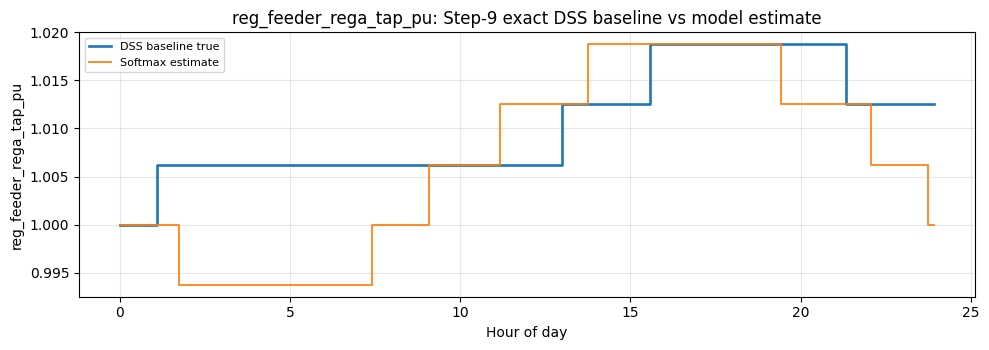

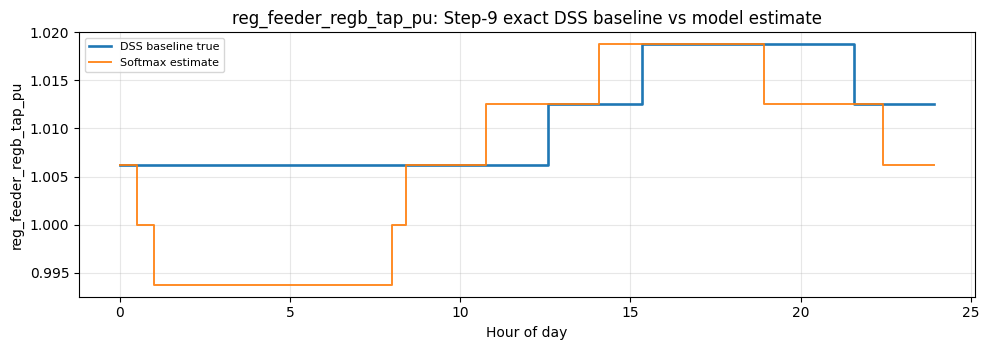

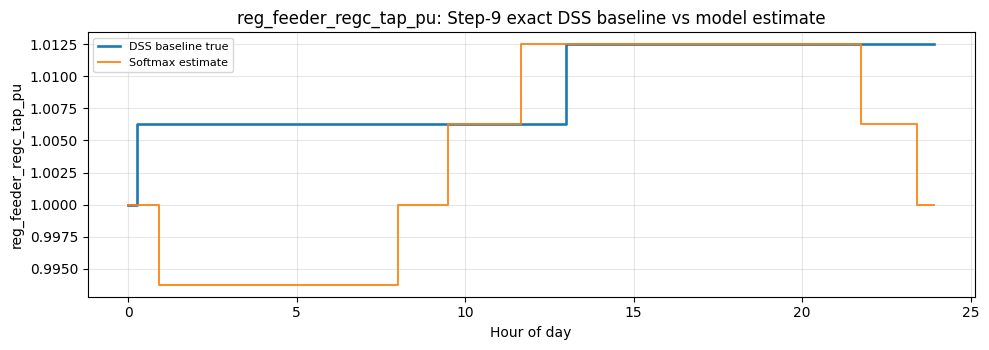

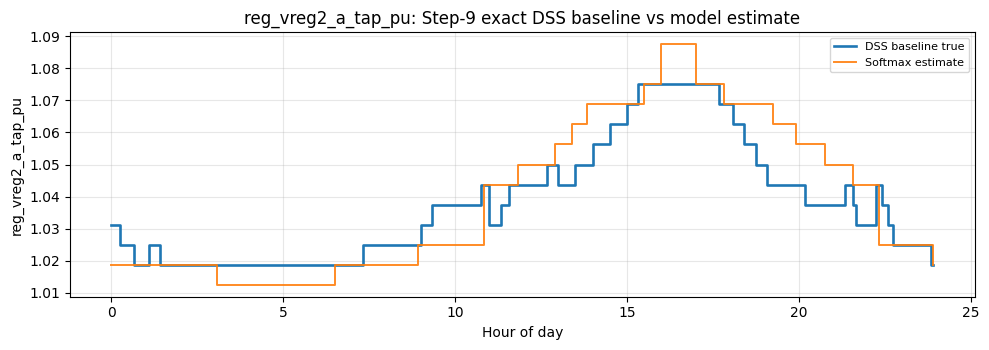

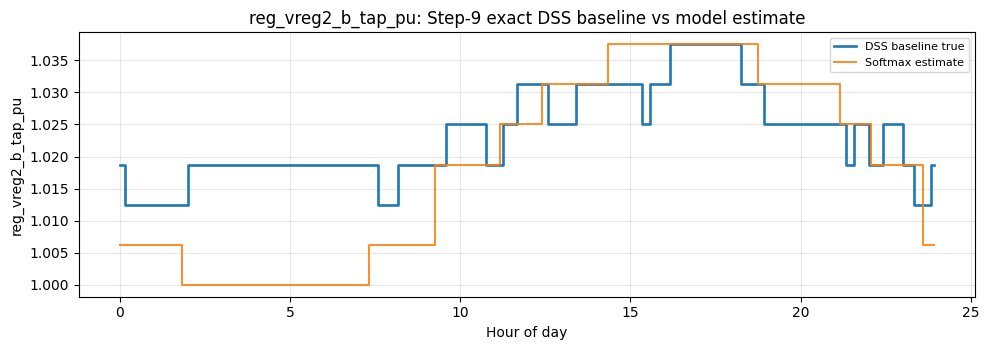

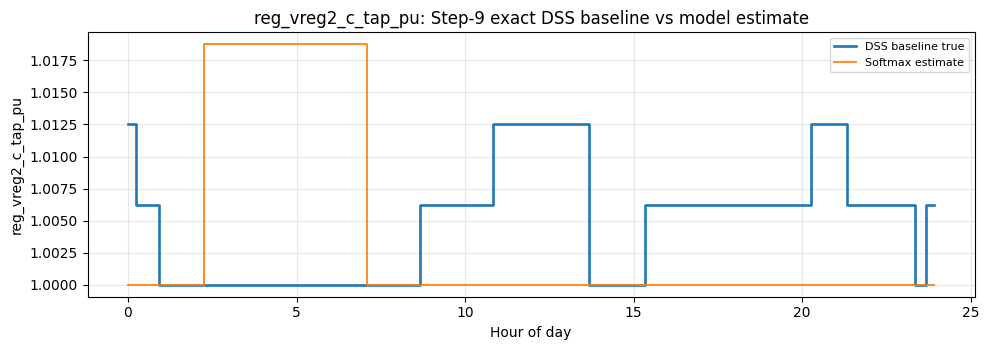

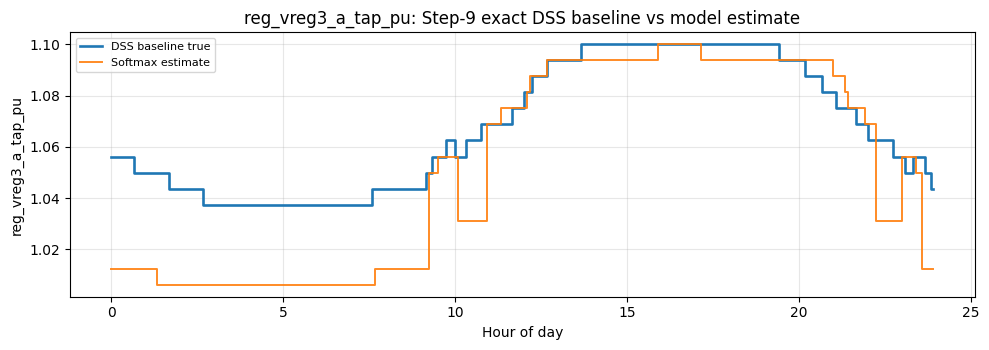

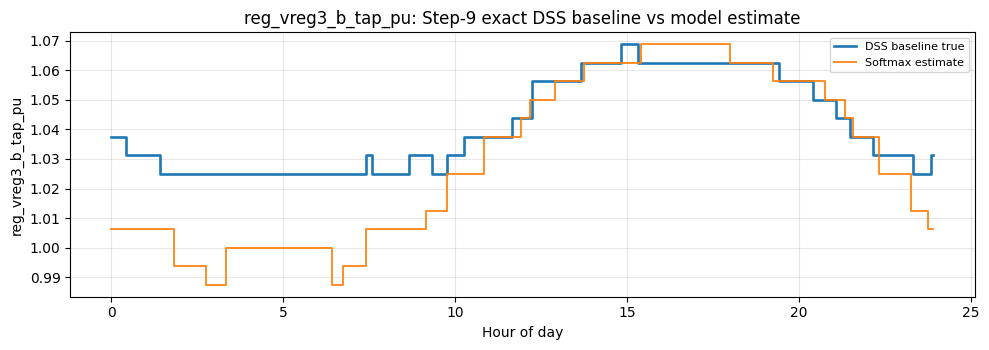

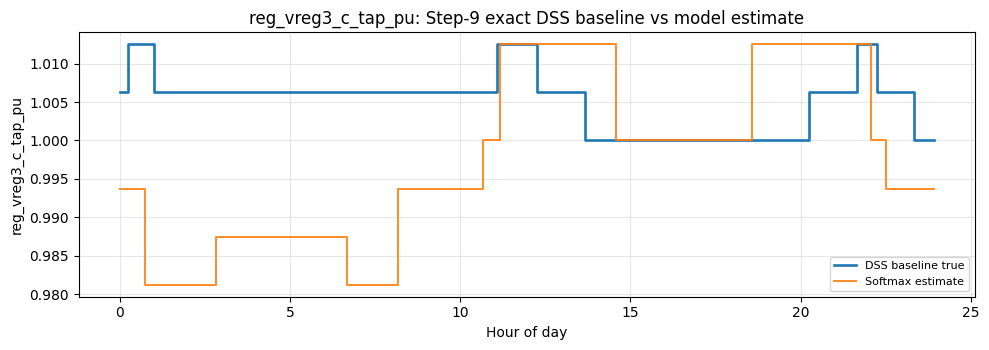

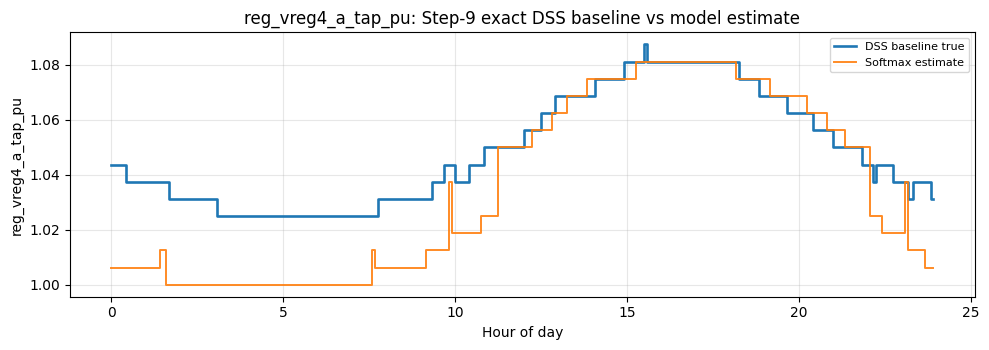

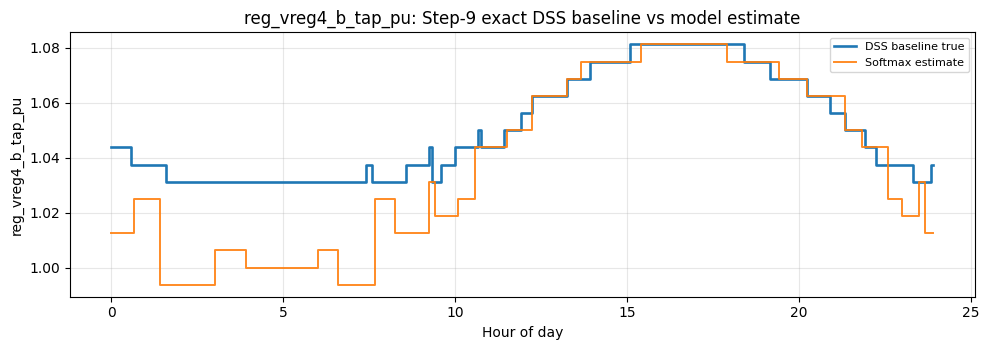

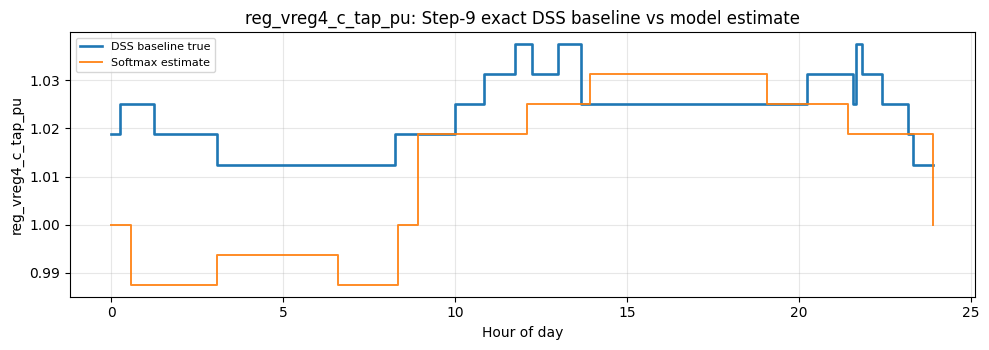

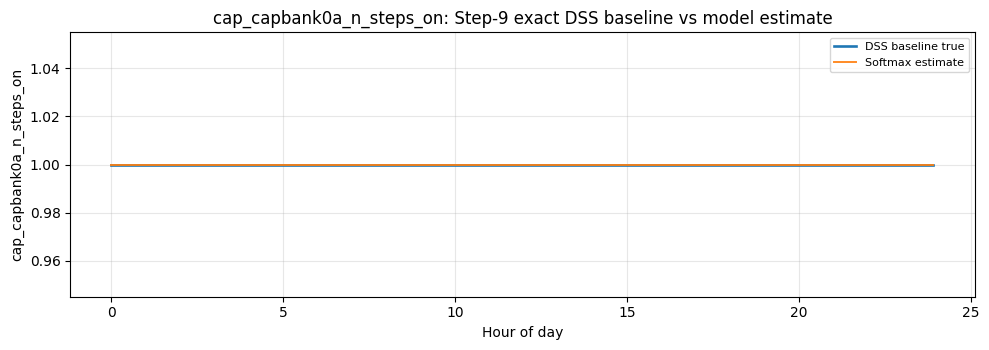

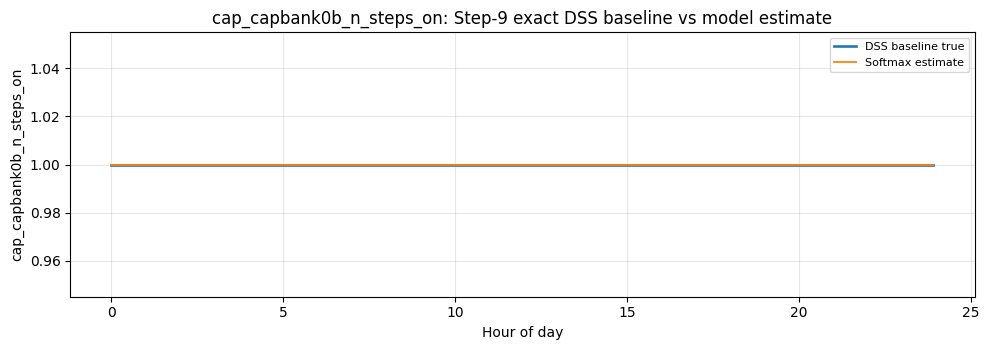

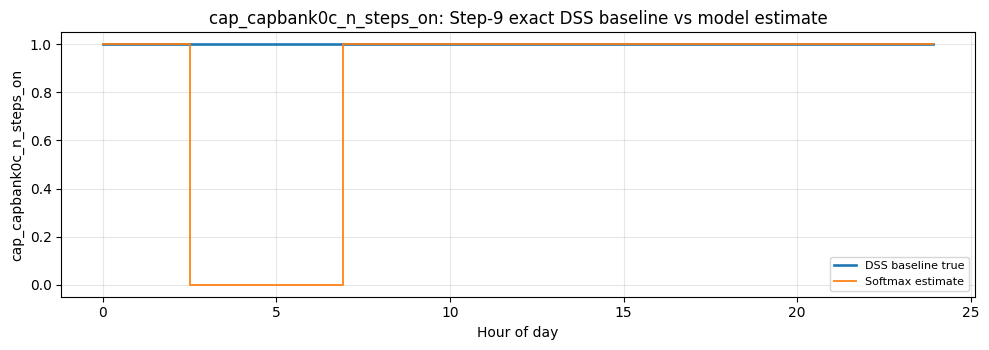

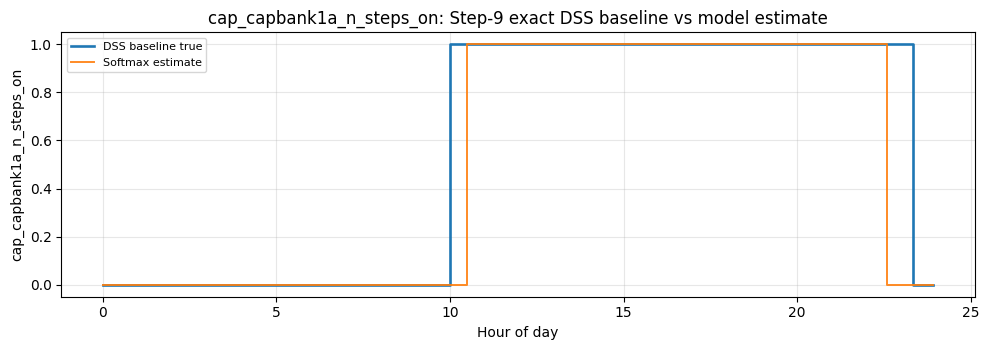

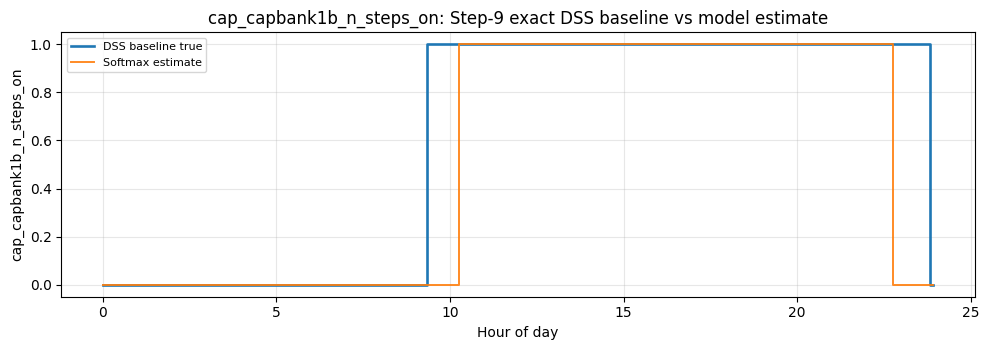

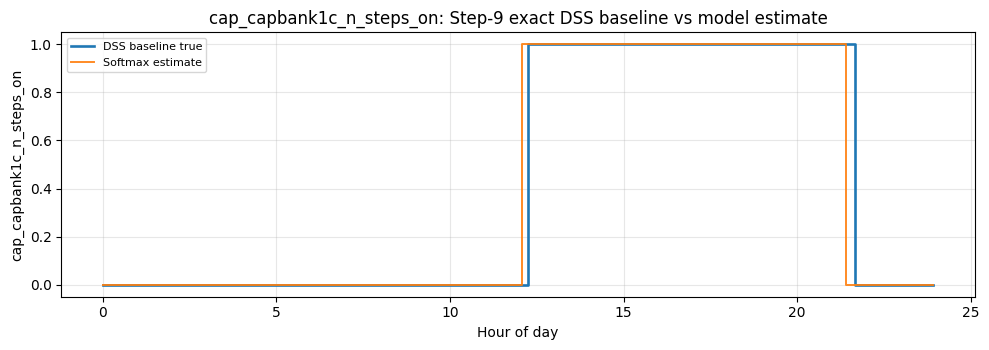

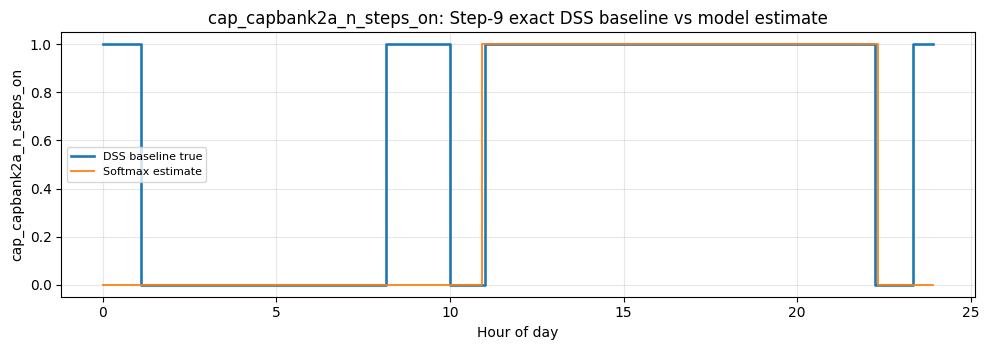

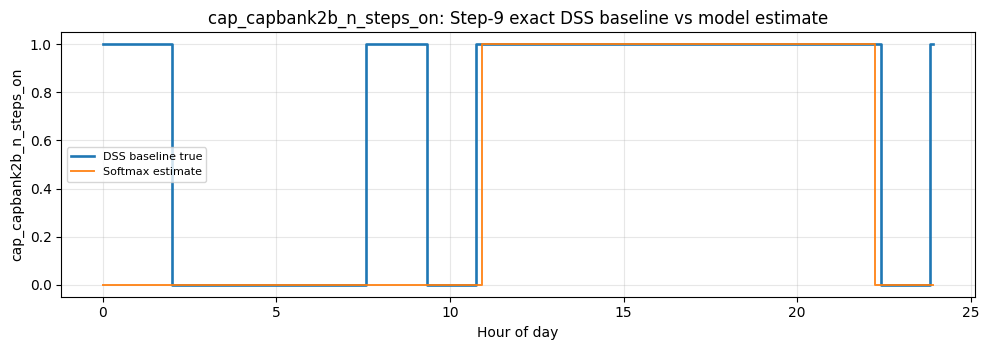

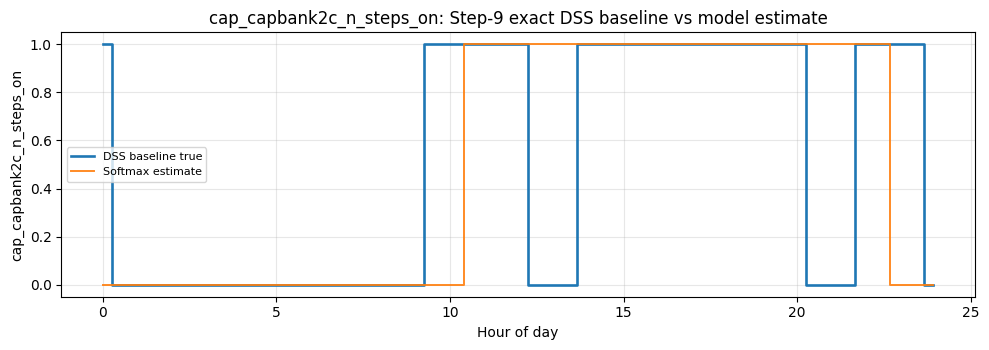

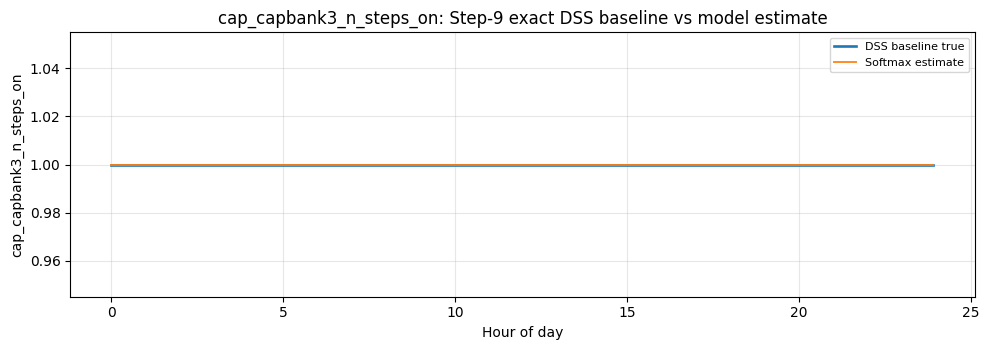

Saved per-device plots and CSV to: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\step9_exact_baseline_device_state_plots_softmax22
Timeseries CSV: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\step9_exact_baseline_device_state_plots_softmax22\step9_exact_dss_vs_softmax22_timeseries.csv


In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import opendssdirect as dss

import run_loadtype_dataset_8500 as lt8500
import run_daily_aggregate_dataset_8500 as daily8500

TARGET_COLS = [
    "reg_feeder_rega_tap_pu",
    "reg_feeder_regb_tap_pu",
    "reg_feeder_regc_tap_pu",
    "reg_vreg2_a_tap_pu",
    "reg_vreg2_b_tap_pu",
    "reg_vreg2_c_tap_pu",
    "reg_vreg3_a_tap_pu",
    "reg_vreg3_b_tap_pu",
    "reg_vreg3_c_tap_pu",
    "reg_vreg4_a_tap_pu",
    "reg_vreg4_b_tap_pu",
    "reg_vreg4_c_tap_pu",
    "cap_capbank0a_n_steps_on",
    "cap_capbank0b_n_steps_on",
    "cap_capbank0c_n_steps_on",
    "cap_capbank1a_n_steps_on",
    "cap_capbank1b_n_steps_on",
    "cap_capbank1c_n_steps_on",
    "cap_capbank2a_n_steps_on",
    "cap_capbank2b_n_steps_on",
    "cap_capbank2c_n_steps_on",
    "cap_capbank3_n_steps_on",
]
NPTS = 288
STEP_MIN = 5


class MLPClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden: int, num_layers: int, dropout: float, n_classes: int):
        super().__init__()
        layers = []
        d = in_dim
        for i in range(num_layers):
            layers.append(nn.Linear(d, hidden))
            layers.append(nn.ReLU())
            if dropout > 0 and i < num_layers - 1:
                layers.append(nn.Dropout(dropout))
            d = hidden
        layers.append(nn.Linear(d, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def detect_repo_root() -> Path:
    candidates = [
        Path(os.environ.get("GNN_REPO", "")),
        Path(os.environ.get("GNN2_REPO", "")),
        Path.cwd(),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path("/content/GNN-Sandia"),
    ]
    for p in candidates:
        if not str(p):
            continue
        if (p / "8500-node" / "Run_8500Node_Daily_5min.dss").is_file():
            return p.resolve()
    raise FileNotFoundError("Could not locate repo root with 8500-node/Run_8500Node_Daily_5min.dss")


repo = detect_repo_root()
os.chdir(repo)
print("Using repo:", repo)

pt_dir_candidates = [
    repo / "gnn2_architecture_search_softmax_22",
    repo / "gnn2_architecture_search" / "gnn2_architecture_search_softmax_22",
]
pt_dir = None
for p in pt_dir_candidates:
    if p.is_dir():
        pt_dir = p
        break
if pt_dir is None:
    raise FileNotFoundError(f"Could not find softmax checkpoint folder. Tried: {pt_dir_candidates}")
print("Checkpoint dir:", pt_dir)

# Exact Step-9 baseline solve setup
dss.Basic.ClearAll()
run_dss = repo / "8500-node" / "Run_8500Node_Daily_5min.dss"
dss.Text.Command(f'redirect "{os.path.abspath(str(run_dss))}"')
dss.Text.Command("set mode=daily")
dss.Text.Command("set stepsize=5m")
dss.Text.Command("set number=1")
dss.Text.Command("set maxiterations=30")
dss.Text.Command("set maxcontroliter=20000")

# Node order from live DSS
all_nodes = []
for n in dss.Circuit.AllNodeNames():
    s = str(n).strip().lower()
    if "." not in s:
        continue
    bus, phs = s.rsplit(".", 1)
    try:
        ph = int(phs)
    except Exception:
        continue
    if ph in (1, 2, 3):
        all_nodes.append(s)
all_nodes = list(dict.fromkeys(all_nodes))
if not all_nodes:
    raise RuntimeError("No phase nodes found from live DSS")

loads, load_to_busph = daily8500._collect_loads_and_maps()
load_names = [str(d["name"]) for d in loads]
reg_names = daily8500._discover_reg_controls()
cap_names = daily8500._discover_capacitors()

time_h = np.arange(NPTS, dtype=float) * (STEP_MIN / 60.0)
X = np.zeros((NPTS, len(all_nodes), 2), dtype=np.float32)
truth = pd.DataFrame({"t_index": np.arange(NPTS, dtype=int), "hour": time_h})

n_nonconv = 0
n_ctrl_warn = 0
for t in range(NPTS):
    hr = int(t // 12)
    sec = int((t % 12) * 300)
    dss.Text.Command(f"set hour={hr} sec={sec}")
    try:
        dss.Solution.Solve()
    except Exception as e:
        if "Max Control Iterations Exceeded" in str(e):
            n_ctrl_warn += 1
        n_nonconv += 1
        continue
    if not dss.Solution.Converged():
        n_nonconv += 1
        continue

    busphP_load = {}
    busphQ_load = {}
    for ln in load_names:
        try:
            dss.Circuit.SetActiveElement(f"Load.{ln}")
            pq = dss.CktElement.TotalPowers()
            p_set = abs(float(pq[0])) if len(pq) >= 1 else 0.0
            q_set = abs(float(pq[1])) if len(pq) >= 2 else 0.0
            fracs = load_to_busph.get(ln, lt8500._busph_fracs_load(ln))
            for (bus, ph, w) in fracs:
                busphP_load[(bus, ph)] = busphP_load.get((bus, ph), 0.0) + p_set * float(w)
                busphQ_load[(bus, ph)] = busphQ_load.get((bus, ph), 0.0) + q_set * float(w)
        except Exception:
            continue

    for i, node in enumerate(all_nodes):
        bus, phs = node.rsplit(".", 1)
        ph = int(phs)
        X[t, i, 0] = float(busphP_load.get((bus, ph), 0.0))
        X[t, i, 1] = float(busphQ_load.get((bus, ph), 0.0))

    row = {}
    row.update(daily8500._read_reg_control_state(reg_names))
    row.update(daily8500._read_capacitor_state(cap_names))
    for c in TARGET_COLS:
        truth.loc[t, c] = float(row.get(c, np.nan))

    if (t + 1) % 24 == 0:
        print(f"[{t+1}/{NPTS}] DSS baseline collected", flush=True)

print(f"DSS baseline solve done: nonconverged/failed={n_nonconv}, max-control warnings={n_ctrl_warn}")

# Prefer normalization stats saved in best checkpoints.
x_mean = None
x_std = None
for c in TARGET_COLS:
    ck_norm = torch.load(pt_dir / c / "best.pt", map_location="cpu")
    if "x_mean" in ck_norm and "x_std" in ck_norm:
        x_mean = ck_norm["x_mean"].numpy().astype(np.float32)
        x_std = ck_norm["x_std"].numpy().astype(np.float32)
        break

if x_mean is None or x_std is None:
    cache_path = pt_dir / "node_features_X.pt"
    if cache_path.is_file():
        Xcache = torch.load(cache_path, map_location="cpu")
        xf = Xcache.reshape(-1, 2)
        x_mean = xf.mean(dim=0, keepdim=True).numpy().astype(np.float32)
        x_std = xf.std(dim=0, unbiased=False, keepdim=True).numpy().astype(np.float32)
    else:
        xf = X.reshape(-1, 2)
        x_mean = xf.mean(axis=0, keepdims=True).astype(np.float32)
        x_std = xf.std(axis=0, keepdims=True).astype(np.float32)
        print("[WARN] node_features_X.pt not found; using Step-9 baseline stats for normalization")

x_std = np.clip(x_std, 1e-6, None)

Xn = (X - x_mean.reshape(1, 1, 2)) / x_std.reshape(1, 1, 2)
Xflat = torch.from_numpy(Xn.reshape(NPTS, -1)).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = pd.DataFrame({"t_index": np.arange(NPTS, dtype=int), "hour": time_h})

for c in TARGET_COLS:
    ckpt_path = pt_dir / c / "best.pt"
    if not ckpt_path.is_file():
        raise FileNotFoundError(ckpt_path)
    ck = torch.load(ckpt_path, map_location="cpu")
    class_values = np.asarray(ck["class_values"], dtype=np.float32)

    hidden = int(ck.get("hidden_dim", 128))
    num_layers = int(ck.get("num_layers", 3))
    dropout = float(ck.get("dropout", 0.1))

    model = MLPClassifier(
        in_dim=Xflat.shape[1],
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        n_classes=int(ck["n_classes"]),
    ).to(device)
    model.load_state_dict(ck["model_state_dict"])
    model.eval()

    with torch.no_grad():
        logits = model(Xflat.to(device))
        cls = logits.argmax(dim=1).cpu().numpy().astype(np.int64)
    pred[c] = class_values[cls]

out_dir = repo / "gnn2_daily_compare_8500_output" / "step9_exact_baseline_device_state_plots_softmax22"
out_dir.mkdir(parents=True, exist_ok=True)

for c in TARGET_COLS:
    y_true = truth[c].to_numpy(dtype=float)
    y_pred = pred[c].to_numpy(dtype=float)

    plt.figure(figsize=(10, 3.6))
    plt.step(time_h, y_true, where="post", linewidth=1.9, label="DSS baseline true")
    plt.step(time_h, y_pred, where="post", linewidth=1.4, alpha=0.9, label="Softmax estimate")
    plt.xlabel("Hour of day")
    plt.ylabel(c)
    plt.title(f"{c}: Step-9 exact DSS baseline vs model estimate")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    fp = out_dir / f"step9_exact_{c}.png"
    plt.savefig(fp, dpi=170)
    plt.show()

cmp = truth.merge(pred, on=["t_index", "hour"], suffixes=("_true", "_pred"))
cmp_csv = out_dir / "step9_exact_dss_vs_softmax22_timeseries.csv"
cmp.to_csv(cmp_csv, index=False)
print("Saved per-device plots and CSV to:", out_dir)
print("Timeseries CSV:", cmp_csv)

### Electrical distance (8500 daily graph) — why some nodes show unreachable

`electrical_distance.py` sums edge |Z| on the **static phase-edge CSV**, not OpenDSS's full 3-winding triplex topology.

**Why ~2815 / 8531 are unreachable:** `extract_static_phase_edges_to_csv` adds **at most two transformer bus specs per element**. Center-tapped service transformers have **three** windings (MV + two LV hots vs neutral). One LV leg can get **no** transformer edge to the MV network. The **triplex** only links `X.*.k` to `SX.*.k` for the **same** `k`; it does **not** connect `.1` to `.2`. So **`X...k` and `SX...k`** can sit in a **2-node island** with **no path** to the substation in this graph — even though physically they are connected through the transformer neutral.

Unreachable rows split **evenly** between matching **`X` and `SX`** on the same leg. This is a **graph-export limitation**, not “the feeder is disconnected” in OpenDSS.

In [9]:
import importlib.util
import os
import sys
from pathlib import Path

import pandas as pd

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
os.chdir(REPO)

for _k in list(sys.modules):
    if _k == "electrical_distance" or _k.startswith("electrical_distance."):
        del sys.modules[_k]

_ed_path = REPO / "electrical_distance.py"
_spec = importlib.util.spec_from_file_location("electrical_distance_gnn2", _ed_path)
_ed = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_ed)

CASE_PATHS = _ed.CASE_PATHS
build_8500_static_csvs = _ed.build_8500_static_csvs
compute_electrical_distances_dataframe = _ed.compute_electrical_distances_dataframe

default_results_csv_path = _ed.default_results_csv_path
save_electrical_distances_csv = _ed.save_electrical_distances_csv

CASE = "8500-daily"
rel_ni, rel_ed = CASE_PATHS[CASE]
NODE_CSV = REPO / rel_ni
EDGE_CSV = REPO / rel_ed

if not NODE_CSV.is_file() or not EDGE_CSV.is_file():
    NODE_CSV, EDGE_CSV = build_8500_static_csvs(mode="daily", out_dir=NODE_CSV.parent)

df_edist = compute_electrical_distances_dataframe(
    NODE_CSV, EDGE_CSV, unreachable="nan", infer_case=CASE
)
r, u = int(df_edist["reachable"].sum()), int((~df_edist["reachable"]).sum())
print(f"nodes={len(df_edist)}  reachable={r}  unreachable={u}")
display(df_edist.head(8))
display(df_edist.loc[~df_edist["reachable"], ["node", "bus", "phase"]].head(20))
OUT_CSV = default_results_csv_path(NODE_CSV)
saved_path = save_electrical_distances_csv(df_edist, OUT_CSV)
print(f"Saved electrical distance table -> {saved_path}")

df_edist["electrical_distance_ohm"].describe()


nodes=8531  reachable=5716  unreachable=2815


,node,bus,phase,electrical_distance_ohm,reachable
0,sourcebus.1,sourcebus,1,NaN,False
1,sourcebus.2,sourcebus,2,NaN,False
2,sourcebus.3,sourcebus,3,NaN,False
3,_hvmv_sub_lsb.1,_hvmv_sub_lsb,1,0.00000,True
4,_hvmv_sub_lsb.2,_hvmv_sub_lsb,2,0.00000,True
5,_hvmv_sub_lsb.3,_hvmv_sub_lsb,3,0.00000,True
6,hvmv_sub_48332.1,hvmv_sub_48332,1,0.00001,True
7,hvmv_sub_48332.2,hvmv_sub_48332,2,0.00001,True


,node,bus,phase
0,sourcebus.1,sourcebus,1
1,sourcebus.2,sourcebus,2
2,sourcebus.3,sourcebus,3
3824,x2804253a.2,x2804253a,2
3827,x3216339b.1,x3216339b,1
3830,x2954355a.2,x2954355a,2
3831,x2861197c.1,x2861197c,1
3832,x2861197c.2,x2861197c,2
3834,x2842379a.2,x2842379a,2
3835,x2841636b.1,x2841636b,1


Saved electrical distance table -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\electrical_distance_from_substation.csv


count    5716.000000
mean       12.675512
std         9.628075
min         0.000000
25%         6.179898
50%        10.373944
75%        14.018538
max        40.878617
Name: electrical_distance_ohm, dtype: float64

## IEEE8500_OpenDSS_timing

Parses `8500-node/LoadXfmrs.dss` and `8500-node/Triplex_Lines.DSS`. CSV columns are **OpenDSS node strings** (bus + node numbers), not bare bus names:
- `mv_node` — primary winding (e.g. `L2804253.1`)
- `lv_x_node_1`, `lv_x_node_2` — LV hot legs on the X bus (`X....1`, `X....2`) from the 3-winding center-tapped definition
- `sx_node_1`, `sx_node_2` — triplex load-side hots (`SX....1`, `SX....2`) from `Bus2` of the triplex line

Output: `8500-node/mv_x_sx_node_mapping_8500.csv`.


In [11]:
import os
import re
from pathlib import Path

import pandas as pd

REPO = Path(os.getcwd())
if not (REPO / "8500-node" / "LoadXfmrs.dss").exists():
    REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")

LOAD_XFMRS = REPO / "8500-node" / "LoadXfmrs.dss"
TRIPLEX_LINES = REPO / "8500-node" / "Triplex_Lines.DSS"
OUT_CSV = REPO / "8500-node" / "mv_x_sx_node_mapping_8500.csv"


def _bus_base(bus_spec: str) -> str:
    return bus_spec.split(".")[0]


def _lv_x_hot_nodes_from_wdg23(w2: str, w3: str) -> tuple[str, str]:
    """Center-tapped secondary: wdg2 X.bus.1.0 and wdg3 X.bus.0.2 -> hot nodes bus.1 and bus.2."""
    b2 = _bus_base(w2)
    b3 = _bus_base(w3)
    if b2.lower() != b3.lower():
        return f"{b2}.?", f"{b3}.?"
    return f"{b2}.1", f"{b2}.2"


def _sx_hot_nodes_from_triplex_bus2(bus2_full: str) -> tuple[str, str]:
    """Triplex Bus2 like SX2673305B.1.2 -> SX2673305B.1 and SX2673305B.2."""
    if not bus2_full or not bus2_full.strip():
        return "", ""
    parts = bus2_full.strip().split(".")
    if len(parts) < 3:
        return "", ""
    bus = parts[0]
    return f"{bus}.{parts[1]}", f"{bus}.{parts[2]}"


def parse_loadxfmrs(path: Path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("New Transformer."):
                continue
            w1 = re.search(r"wdg=1\s+bus=(\S+)", line)
            w2 = re.search(r"wdg=2\s+bus=(\S+)", line)
            w3 = re.search(r"wdg=3\s+bus=(\S+)", line)
            if not (w1 and w2 and w3):
                continue
            mv_node = w1.group(1)
            w2s, w3s = w2.group(1), w3.group(1)
            x1, x2 = _lv_x_hot_nodes_from_wdg23(w2s, w3s)
            rows.append(
                {
                    "mv_node": mv_node,
                    "lv_x_node_1": x1,
                    "lv_x_node_2": x2,
                    "_x_key": _bus_base(w2s).lower(),
                }
            )
    return rows


def parse_triplex_by_x_base(path: Path) -> dict:
    out = {}
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("New Line."):
                continue
            b1 = re.search(r"Bus1=(\S+)", line)
            b2 = re.search(r"Bus2=(\S+)", line)
            if not (b1 and b2):
                continue
            xb = _bus_base(b1.group(1)).lower()
            out[xb] = b2.group(1)
    return out


rows = parse_loadxfmrs(LOAD_XFMRS)
tri = parse_triplex_by_x_base(TRIPLEX_LINES)

for r in rows:
    b2 = tri.get(r["_x_key"], "")
    s1, s2 = _sx_hot_nodes_from_triplex_bus2(b2)
    r["sx_node_1"] = s1
    r["sx_node_2"] = s2
    del r["_x_key"]

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(df)} rows -> {OUT_CSV}")
print(df.head(3).to_string())
print("...")
print(f"Rows with empty SX nodes (no triplex match): {(df['sx_node_1'] == '').sum()}")


Wrote 1177 rows -> C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
      mv_node  lv_x_node_1  lv_x_node_2     sx_node_1     sx_node_2
0  L2804253.1  X2804253A.1  X2804253A.2  SX2804253A.1  SX2804253A.2
1  L3254213.2  X3254213B.1  X3254213B.2  SX3254213B.1  SX3254213B.2
2  L3216339.2  X3216339B.1  X3216339B.2  SX3216339B.1  SX3216339B.2
...
Rows with empty SX nodes (no triplex match): 6


## MV-only node dataset (aggregate)

Builds **`datasets_gnn2/loadtype_8500_dailyagg/gnn_node_features_and_targets_mv_only.csv`** from the full **`gnn_node_features_and_targets.csv`** (streamed) and **`mv_x_sx_node_mapping_8500.csv`**.

- **Rows:** one per `(sample_id, mv_node)` from the mapping (each service transformer).
- **P/Q:** sum of `p_load_kw` / `q_load_kvar` on **`sx_node_1` + `sx_node_2`** when both are set; otherwise **`lv_x_node_1` + `lv_x_node_2`**.
- **V:** `vmag_pu` / `vang_deg` (and `electrical_distance_ohm`, `node_idx`, `bus`, `phase`) from the **`mv_node`** row.

Same **10 columns** as the source node CSV. Full pass over the 8GB+ file can take tens of minutes; use `--max-samples N` for a quick test.

Matching node names are **case-insensitive** (dataset nodes are often lowercase).


In [13]:
import os
os.chdir(r"C:\Users\alita\OneDrive\Desktop\GNN2")

# Full dataset (long run)
%run aggregate_mv_node_dataset_8500.py

# Quick test: only first 3 completed samples
# %run aggregate_mv_node_dataset_8500.py --max-samples 3


[aggregate_mv_node_dataset_8500] wrote 11660539 rows -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_node_features_and_targets_mv_only.csv
  samples (power-flow cases) written: 9907
  missing_mv (no mv_node in buffer for that sample): 0
  missing load-node increments (node not in buffer): 0


## MV interest subgraph (anchors to feeder tree)

Runs `build_mv_interest_subgraph_edges.py`: unions shortest-path edges (weight = sqrt(R_full^2 + X_full^2)) from substation roots to each anchor. Anchors come from `mv_x_sx_node_mapping_8500.csv` (mv_node), `regulator_involved_nodes.csv` (both terminals), and `capacitor_involved_nodes.csv` (From node).

Writes to `datasets_gnn2/loadtype_8500_dailyagg/`:
- `mv_interest_anchor_nodes.csv`
- `gnn_edges_phase_static_mv_only.csv`


In [16]:
import os
os.chdir(r'C:\Users\alita\OneDrive\Desktop\GNN2')
%run build_mv_interest_subgraph_edges.py


  anchor Dijkstra progress 200/1212 ...
  anchor Dijkstra progress 400/1212 ...
  anchor Dijkstra progress 600/1212 ...
  anchor Dijkstra progress 800/1212 ...
  anchor Dijkstra progress 1000/1212 ...
  anchor Dijkstra progress 1200/1212 ...
[build_mv_interest_subgraph_edges] anchors=1212
  Edge model: synthetic A–B with sum(R,X,C) on min-|Z| path, skip if another anchor on path interior.
  synthetic anchor–anchor edges written: 2741
  pairs skipped (interior anchor on shortest path): 242504
  pair attempts unreachable: 488621
  wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_edges_phase_static_mv_only.csv
  wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\mv_interest_anchor_nodes.csv


### MV anchor subgraph (three anchor types)

The script `visualize_mv_anchor_subgraph.py` draws the MV-only edge graph and colors nodes by **MV** (mapping), **regulator** (terminals), and **capacitor** (from-node) lists; nodes in more than one category get a distinct blend. Output PNG is written under `datasets_gnn2/loadtype_8500_dailyagg/` by default.


Graph |V|=1212 |E|=2741
Saved C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\mv_subgraph_layout_by_type.png


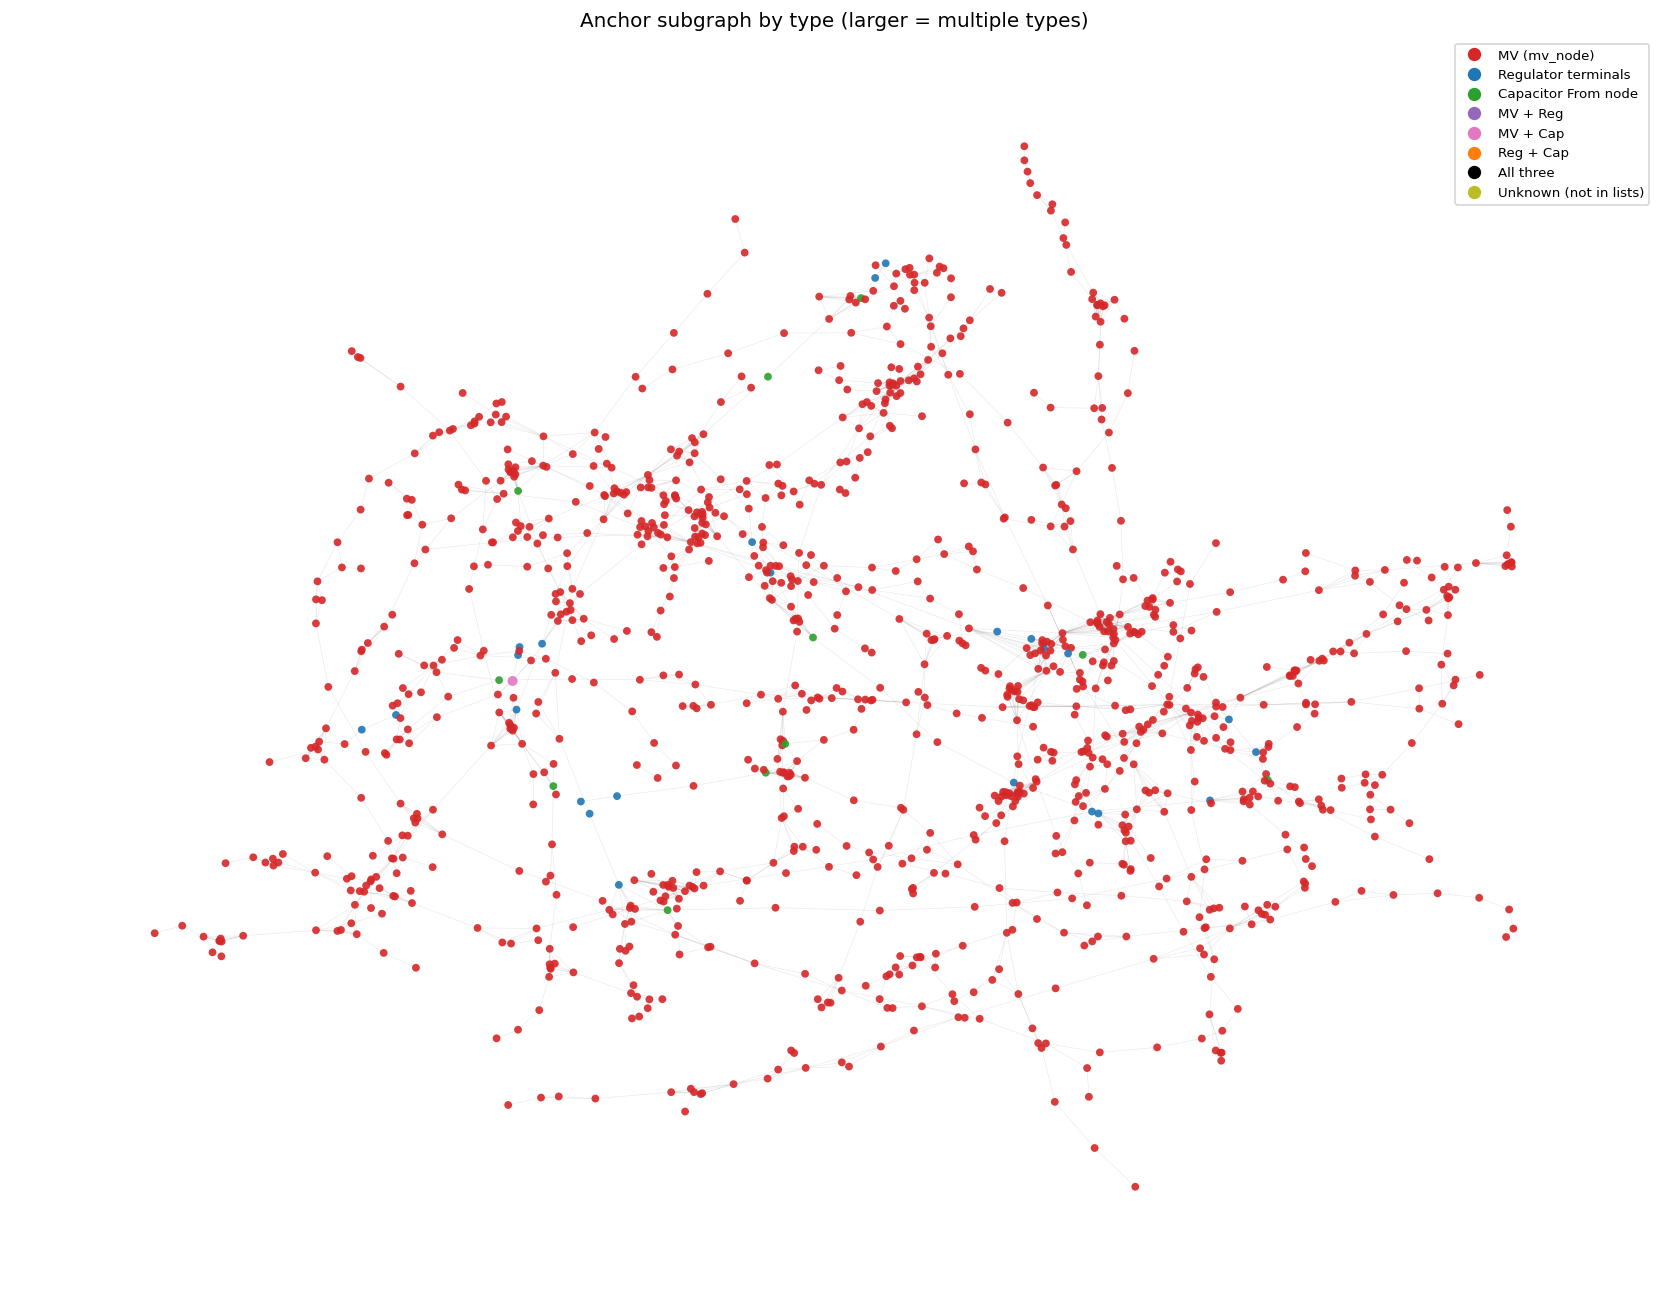

In [18]:
import os
from pathlib import Path

# Repo root (Colab: os.chdir("/content/GNN-Sandia") or your clone path)
os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run visualize_mv_anchor_subgraph.py


### Heterogeneous MV edge dataset (line vs regulator)

Runs `build_hetero_mv_edge_dataset.py` to build:

- **`hetero_mv_edge_catalog.csv`** — all edges from `gnn_edges_phase_static_mv_only.csv` with `edge_type` (`line` or `regulator`), `R_full` / `X_full`, `u_idx` / `v_idx`
- **`hetero_mv_line_edge_attr.csv`** — static `R_full`, `X_full` for line edges only
- **`hetero_mv_regulator_edge_features.csv`** — per `sample_id` × regulator edge: 12 tap columns from `gnn_sample_meta.csv`

Default data folder: `datasets_gnn2/loadtype_8500_dailyagg/`.

In [20]:
import os
from pathlib import Path

os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run build_hetero_mv_edge_dataset.py

[build_hetero_mv_edge_dataset] wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg/
  edges total=2741  line=2729  regulator=12
  samples=9907  regulator-edge feature rows=118884 (= 9907 * 12)
  hetero_mv_edge_catalog.csv
  hetero_mv_line_edge_attr.csv
  hetero_mv_regulator_edge_features.csv


### Hetero node-type CSVs (full `gnn_node_features_and_targets`)

Runs `build_hetero_mv_node_type_datasets.py`: regulator up/down from full graph; cap file = **12 fixed From nodes** only; load-transformer = nodes listed in `gnn_node_features_and_targets_mv_only.csv`, features from **full** node CSV.

In [1]:
import os
from pathlib import Path

os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run build_hetero_mv_node_type_datasets.py

[build_hetero_mv_node_type_datasets] out_dir=C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
  hetero_mv_nodes_regulator_upstream.csv: 118884 rows
  hetero_mv_nodes_regulator_downstream.csv: 118884 rows
  hetero_mv_nodes_capacitor_related.csv: 118884 rows
  hetero_mv_nodes_load_transformer.csv: 11660539 rows
  sets: regulator terminal_1=12 terminal_2=12 cap_from_fixed=12 load_xfmr(nodes_in_mv_only)=1177


### Heterogeneous MV GNN — architecture search (8500)

**Data folder:** `datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/`  
- **Nodes (4 CSVs):** regulator terminal_1 / terminal_2, 12 cap From buses, load-transformer MV buses.  
- **Edges:** MV-only graph — `line` (R,X) + `regulator` (per-sample `reg_tap_pu`).

**Model:** `HeteroConv` on node type `bus` with two relations (`line`, `reg`). **Target:** `vmag_pu` only.  
**Training:** default **1/3** of samples, early stopping; **`l2823592.1`** excluded from **training** loss (not from val).

**Script:** `search_hetero_mv_gnn_architectures.py` — tries **5** architectures and saves rankings under `gnn2_architecture_search/hetero_mv_8500/`.

In [ ]:
import os

REPO_DIR = "/content/GNN-Sandia"
os.chdir(REPO_DIR)
print("cwd:", os.getcwd())

%run search_hetero_mv_gnn_architectures.py --target-node-types load

cwd: /content/GNN-Sandia
[hetero_mv_search] reading edge catalog + line attrs...
[hetero_mv_search] scanning node CSVs for bus names (load file can take several minutes)...
[hetero_mv_search] membership scan (full pass over load CSV in chunks)...
[hetero_mv_search] building typed topology + tensors...
[hetero_mv_search] loading regulator tap table...
[hetero_mv_search] device=cuda typed_nodes={'upstream': 12, 'downstream': 12, 'capacitor': 11, 'load': 1177} relations=13
  E_line(undir pairs)~2729 E_reg~12
  samples total=9907 pool(frac)=3302 train=2642 val=660
  exclude from train loss: type=load local=997 (frozenset({'l2823592.1'}))
  exclude from train loss: 1 bus(es) in 2+ node CSVs (global_idx sample: [3450])
  vmag_pu loss restricted to storages ['load'] (1177 node positions; loss only where labels exist)
[hetero_mv_search] accumulating per-sample node features (another full load-CSV pass)...
  ... reading upstream CSV
  ... reading downstream CSV
  ... reading capacitor CSV
  ... reading load CSV
[hetero_mv_search] building GPU cache for train/val samples...

>>> Training hetero_sage_2x96 (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.055128  best_val_rmse=0.055128  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.034517  best_val_rmse=0.034517  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.029759  best_val_rmse=0.028418  no_improve_streak=1/18
    epoch   30/120  val_rmse=0.026338  best_val_rmse=0.025980  no_improve_streak=1/18
    epoch   40/120  val_rmse=0.023036  best_val_rmse=0.022772  no_improve_streak=1/18
    epoch   50/120  val_rmse=0.021722  best_val_rmse=0.021722  no_improve_streak=0/18
    epoch   60/120  val_rmse=0.020748  best_val_rmse=0.020290  no_improve_streak=1/18
    epoch   70/120  val_rmse=0.019459  best_val_rmse=0.019459  no_improve_streak=0/18
    epoch   80/120  val_rmse=0.019335  best_val_rmse=0.019075  no_improve_streak=2/18
    epoch   90/120  val_rmse=0.042375  best_val_rmse=0.019075  no_improve_streak=12/18

>>> Training hetero_sage_4x64_ln_drop (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.056965  best_val_rmse=0.056965  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.023154  best_val_rmse=0.022878  no_improve_streak=3/18
    epoch   20/120  val_rmse=0.014866  best_val_rmse=0.014866  no_improve_streak=0/18
    epoch   30/120  val_rmse=0.009533  best_val_rmse=0.009243  no_improve_streak=2/18
    epoch   40/120  val_rmse=0.007345  best_val_rmse=0.007211  no_improve_streak=5/18
    epoch   50/120  val_rmse=0.006751  best_val_rmse=0.006372  no_improve_streak=4/18
    epoch   60/120  val_rmse=0.005747  best_val_rmse=0.005747  no_improve_streak=0/18
    epoch   70/120  val_rmse=0.007185  best_val_rmse=0.005747  no_improve_streak=10/18

>>> Training hetero_gat_2L4h128 (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.072095  best_val_rmse=0.072095  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.031452  best_val_rmse=0.031452  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.024642  best_val_rmse=0.023282  no_improve_streak=7/18
    epoch   30/120  val_rmse=0.026474  best_val_rmse=0.023262  no_improve_streak=3/18
    epoch   40/120  val_rmse=0.025283  best_val_rmse=0.023262  no_improve_streak=13/18

>>> Training hetero_sage_3x112_wide (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.069060  best_val_rmse=0.069060  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.037041  best_val_rmse=0.037041  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.024723  best_val_rmse=0.023227  no_improve_streak=2/18
    epoch   30/120  val_rmse=0.026293  best_val_rmse=0.023227  no_improve_streak=12/18

>>> Training hetero_gine_3x80 (gine_edge_attr=True)
    epoch    1/120  val_rmse=0.057133  best_val_rmse=0.057133  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.010533  best_val_rmse=0.010005  no_improve_streak=1/18
    epoch   20/120  val_rmse=0.007750  best_val_rmse=0.006388  no_improve_streak=1/18
    epoch   30/120  val_rmse=0.006505  best_val_rmse=0.005912  no_improve_streak=6/18
    epoch   40/120  val_rmse=0.007944  best_val_rmse=0.005912  no_improve_streak=16/18

========================================================================
                cfg_name  best_val_rmse  val_mae  epochs_ran          sec
hetero_sage_4x64_ln_drop       0.005747 0.004432          78 11501.036531
        hetero_gine_3x80       0.005912 0.004461          42  6043.124469
        hetero_sage_2x96       0.019075 0.014658          96  6422.614147
  hetero_sage_3x112_wide       0.023227 0.017760          36  3935.435601
      hetero_gat_2L4h128       0.023262 0.017811          45  6299.583941

Wrote /content/GNN-Sandia/gnn2_architecture_search/hetero_mv_8500/search_results.csv

## 8500 Daily Comparison (OpenDSS Baseline vs Hetero Checkpoint)

Run the script below to compare one trained hetero model against the OpenDSS 24h daily solve on the 8500 feeder.

**What it does**
- Runs OpenDSS daily simulation (`5 min`, `24h`)
- Loads your hetero checkpoint (`*_best.pt`)
- Predicts node voltages from the model each timestep
- Plots selected nodes (`OpenDSS` vs `Model`)
- Saves all-node error distribution and per-node MAE CSV

**Outputs**
- Folder: `gnn2_daily_compare_8500_output`
- Files include:
  - `daily_compare_<cfg>_<node>.png`
  - `daily_error_hist_<cfg>.png`
  - `daily_mae_per_node_<cfg>.csv`

with torch compile enabled

In [5]:
import os
os.environ["GNN_TORCH_COMPILE"] = "1"  # enable torch.compile on Windows (default there is off)

from compare_hetero_mv_daily_wrappers import (
    run_sage_not_edge_aware,
    run_gine_edge_aware,
    run_homo_gine_mv,
    run_homo_gine_64_2_mv,
    run_homo_gine_64_2_emb_16_8_mv,
    run_homo_gine_64_3_mv,
    run_homo_gcn_mv,
    run_homo_gcn_64_3_mv,
    run_homo_gine_64_3_emb_16_8_mv,
)

# hetero
run_sage_not_edge_aware()
run_gine_edge_aware()

run_homo_gine_mv()                    # GINE-128-4
run_homo_gine_64_2_mv()             # GINE-64-2 (no emb)
run_homo_gine_64_2_emb_16_8_mv()    # GINE-64-2-EMB-16-8
run_homo_gine_64_3_emb_16_8_mv()    # GINE-64-3-EMB-16-8
run_homo_gine_64_3_mv()             # GINE-64-3

run_homo_gcn_mv()                   # GCN-128-4
run_homo_gcn_64_3_mv()                # GCN-64-3

[compare_hetero_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_sage_4x64_ln_drop] torch.compile enabled (Windows: Dynamo+eager backend, no MSVC; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_hetero_mv_daily] model=hetero_sage_4x64_ln_drop device=cpu
[compare_hetero_mv_daily] checkpoint meta: vmag supervised on storages ['load']
[compare_hetero_mv_daily] OpenDSS solve timing: per-step snapshot mode (not daily warm-start).
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] feature diag (first converged step): hetero load slots with |P|+|Q|>1e-3 kW/kvar: 1171/1177
[24/288] timing so far — OpenDSS apply=0.10s | reassert=0.00s solve_only=4.04s | get V=0.80s | feature build=0.15s | GNN bucket=10.37s fwd-only=10.37s
[48/288] timing so far — OpenDSS apply=0.21s | reassert=0.00s solve_only=7.84s | get V=

with torch compile disabled 

In [7]:
import os
os.environ["GNN_TORCH_COMPILE"] = "0"  # enable torch.compile on Windows (default there is off)

from compare_hetero_mv_daily_wrappers import (
    run_sage_not_edge_aware,
    run_gine_edge_aware,
    run_homo_gine_mv,
    run_homo_gine_64_2_mv,
    run_homo_gine_64_2_emb_16_8_mv,
    run_homo_gine_64_3_mv,
    run_homo_gcn_mv,
    run_homo_gcn_64_3_mv,
    run_homo_gine_64_3_emb_16_8_mv,
)

# hetero
run_sage_not_edge_aware()
run_gine_edge_aware()

run_homo_gine_mv()                    # GINE-128-4
run_homo_gine_64_2_mv()             # GINE-64-2 (no emb)
run_homo_gine_64_2_emb_16_8_mv()    # GINE-64-2-EMB-16-8
run_homo_gine_64_3_emb_16_8_mv()    # GINE-64-3-EMB-16-8
run_homo_gine_64_3_mv()             # GINE-64-3

run_homo_gcn_mv()                   # GCN-128-4
run_homo_gcn_64_3_mv()                # GCN-64-3

[compare_hetero_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_sage_4x64_ln_drop] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_hetero_mv_daily] model=hetero_sage_4x64_ln_drop device=cpu
[compare_hetero_mv_daily] checkpoint meta: vmag supervised on storages ['load']
[compare_hetero_mv_daily] OpenDSS solve timing: per-step snapshot mode (not daily warm-start).
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] feature diag (first converged step): hetero load slots with |P|+|Q|>1e-3 kW/kvar: 1171/1177
[24/288] timing so far — OpenDSS apply=0.12s | reassert=0.00s solve_only=3.80s | get V=1.12s | feature build=0.15s | GNN bucket=3.77s fwd-only=3.76s
[48/288] timing so far — OpenDSS apply=0.25s | reassert=0.00s solve_only=7.43s | get V=2.03s | feature build=0.30s | GNN bucket=7.69s fwd-only=7.68s
[72/288] timing so far — OpenDS

results on GPU

[compare_hetero_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_sage_4x64_ln_drop] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_hetero_mv_daily] model=hetero_sage_4x64_ln_drop device=cuda
[compare_hetero_mv_daily] checkpoint meta: vmag supervised on storages ['load']
[compare_hetero_mv_daily] OpenDSS solve timing: per-step snapshot mode (not daily warm-start).
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] feature diag (first converged step): hetero load slots with |P|+|Q|>1e-3 kW/kvar: 1171/1177
[24/288] timing so far — OpenDSS apply=0.12s | reassert=0.00s solve_only=3.90s | get V=1.36s | feature build=0.19s | GNN bucket=0.26s fwd-only=0.24s
[48/288] timing so far — OpenDSS apply=0.23s | reassert=0.00s solve_only=7.57s | get V=2.34s | feature build=0.38s | GNN bucket=0.51s fwd-only=0.48s
[72/288] timing so far — OpenDSS apply=0.35s | reassert=0.00s solve_only=11.32s | get V=3.32s | feature build=0.58s | GNN bucket=0.76s fwd-only=0.72s
[96/288] timing so far — OpenDSS apply=0.46s | reassert=0.01s solve_only=14.98s | get V=4.64s | feature build=0.78s | GNN bucket=1.01s fwd-only=0.95s
[120/288] timing so far — OpenDSS apply=0.58s | reassert=0.01s solve_only=18.73s | get V=5.62s | feature build=0.98s | GNN bucket=1.26s fwd-only=1.19s
[144/288] timing so far — OpenDSS apply=0.69s | reassert=0.01s solve_only=22.69s | get V=6.62s | feature build=1.18s | GNN bucket=1.52s fwd-only=1.43s
[168/288] timing so far — OpenDSS apply=0.81s | reassert=0.01s solve_only=26.59s | get V=7.95s | feature build=1.38s | GNN bucket=1.77s fwd-only=1.67s
[192/288] timing so far — OpenDSS apply=0.93s | reassert=0.01s solve_only=30.50s | get V=8.94s | feature build=1.58s | GNN bucket=2.02s fwd-only=1.91s
[216/288] timing so far — OpenDSS apply=1.04s | reassert=0.01s solve_only=34.16s | get V=9.93s | feature build=1.78s | GNN bucket=2.27s fwd-only=2.14s
[240/288] timing so far — OpenDSS apply=1.16s | reassert=0.01s solve_only=37.98s | get V=11.27s | feature build=1.99s | GNN bucket=2.53s fwd-only=2.38s
[264/288] timing so far — OpenDSS apply=1.27s | reassert=0.02s solve_only=41.91s | get V=12.26s | feature build=2.19s | GNN bucket=2.78s fwd-only=2.62s
[288/288] timing so far — OpenDSS apply=1.39s | reassert=0.02s solve_only=45.83s | get V=13.60s | feature build=2.39s | GNN bucket=3.04s fwd-only=2.87s

[compare_hetero_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (hetero MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3890s | mean 4.823 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0165s | mean 0.057 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 45.8330s | mean 159.142 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.5981s | mean 47.216 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Hetero feature build: total 2.3878s | mean 8.291 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 2.8652s | mean 9.949 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 3.0387s | mean 10.551 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     163.965 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 23.063 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.11×
Note: collect V mean 47.2 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           159.142 ms/ok-step
GNN net (feature + fwd-only):     18.240 ms/ok-step
Net speedup (DSS_net / GNN_net):  8.73×

Overall: MAE=0.030891 pu  RMSE=0.150364 pu  n_points=349056 nonconv=0

[compare_hetero_mv_daily] load node with largest GNN |V| **range** (day): 'l2917359.1'  range=0.147340 pu  std=0.056331 pu
[compare_hetero_mv_daily] top 10 load nodes by range (then std), pu:
      node   std_pu  range_pu  n_finite_pts
l2917359.1 0.056331  0.147340           288
l2936271.1 0.050799  0.138864           288
l2955074.1 0.046886  0.130033           288
l2879794.1 0.039520  0.119713           288
l2786204.3 0.042581  0.106560           288
l2990098.1 0.032683  0.104335           288
l2973791.1 0.033180  0.099636           288
l2821087.1 0.032319  0.099119           288
l3011229.1 0.030473  0.082427           288
l3235946.1 0.027720  0.081662           288

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output
                  node      mae
    regxfmr_190-8581.3 1.003321
              q16642.3 0.951004
            l2823592.3 0.947755
regxfmr_hvmv_sub_lsb.3 0.942597
              q16642.1 0.941463
              q16483.2 0.932233
              r18242.3 0.932096
              q16483.3 0.929968
              r18242.1 0.925738
regxfmr_hvmv_sub_lsb.1 0.911789
[compare_hetero_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_gine_3x80] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_hetero_mv_daily] model=hetero_gine_3x80 device=cuda
[compare_hetero_mv_daily] checkpoint meta: target_node_types=all (if meta missing, assume all storages supervised)
[compare_hetero_mv_daily] GINE: reg edge_attr from OpenDSS each step (12 RegControls)
[reg_tap_diag] catalog: 12 regulator edges; Regulator labels missing from REGULATOR_TO_TAP_COL: 0; tap_column != map: 0
[reg_tap_diag] hetero_mv_regulator_edge_features.csv: 12 regulator edge_ids; global reg_tap_pu min/max over all samples: 0.981250 / 1.100000 pu
[reg_tap_diag]   edge_id=4 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=11 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=21 training reg_tap_pu: min=0.993750 max=1.056250 n=9907
[compare_hetero_mv_daily] OpenDSS solve timing: per-step snapshot mode (not daily warm-start).
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] feature diag (first converged step): hetero load slots with |P|+|Q|>1e-3 kW/kvar: 1171/1177
  OpenDSS reg tap dict: 12 keys, 12 nonzero  (sample: ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu'])
[reg_tap_diag] OpenDSS tap_raw: 12 keys; expected 12 reg_*_tap_pu from RegControls; nonzero finite: 12/12
[reg_tap_diag] inference map to reg edge_attr: 0/12 edges resolved to ~0 (bad if all taps missing)
[reg_tap_diag]   sample: edge_id=4 Regulator='VREG4_A' -> tap_pu=1.043750 (meta col 'reg_vreg4_a_tap_pu')
[reg_tap_diag]   sample: edge_id=11 Regulator='VREG4_B' -> tap_pu=1.037500 (meta col 'reg_vreg4_b_tap_pu')
[reg_tap_diag]   sample: edge_id=21 Regulator='VREG4_C' -> tap_pu=1.025000 (meta col 'reg_vreg4_c_tap_pu')
[reg_tap_diag]   sample: edge_id=28 Regulator='VREG3_A' -> tap_pu=1.056250 (meta col 'reg_vreg3_a_tap_pu')
[reg_tap_diag]   sample: edge_id=31 Regulator='VREG3_B' -> tap_pu=1.031250 (meta col 'reg_vreg3_b_tap_pu')
[reg_tap_diag]   sample: edge_id=39 Regulator='VREG3_C' -> tap_pu=1.006250 (meta col 'reg_vreg3_c_tap_pu')
[reg_tap_diag]   sample: edge_id=50 Regulator='VREG2_A' -> tap_pu=1.037500 (meta col 'reg_vreg2_a_tap_pu')
[reg_tap_diag]   sample: edge_id=58 Regulator='VREG2_B' -> tap_pu=1.012500 (meta col 'reg_vreg2_b_tap_pu')
[24/288] timing so far — OpenDSS apply=0.12s | reassert=0.00s solve_only=4.10s | get V=0.94s | feature build=2.55s | GNN bucket=2.54s fwd-only=2.52s
[48/288] timing so far — OpenDSS apply=0.23s | reassert=0.00s solve_only=7.96s | get V=2.25s | feature build=5.09s | GNN bucket=5.07s fwd-only=5.04s
[72/288] timing so far — OpenDSS apply=0.35s | reassert=0.00s solve_only=12.02s | get V=3.20s | feature build=7.66s | GNN bucket=7.63s fwd-only=7.59s
[96/288] timing so far — OpenDSS apply=0.47s | reassert=0.01s solve_only=15.89s | get V=4.15s | feature build=10.22s | GNN bucket=10.20s fwd-only=10.14s
[120/288] timing so far — OpenDSS apply=0.59s | reassert=0.01s solve_only=19.85s | get V=5.10s | feature build=13.15s | GNN bucket=12.75s fwd-only=12.68s
[144/288] timing so far — OpenDSS apply=0.70s | reassert=0.01s solve_only=23.96s | get V=6.05s | feature build=15.70s | GNN bucket=15.30s fwd-only=15.21s
[168/288] timing so far — OpenDSS apply=0.82s | reassert=0.01s solve_only=28.05s | get V=7.35s | feature build=18.24s | GNN bucket=17.84s fwd-only=17.73s
[192/288] timing so far — OpenDSS apply=0.94s | reassert=0.01s solve_only=32.11s | get V=8.29s | feature build=20.79s | GNN bucket=20.38s fwd-only=20.27s
[216/288] timing so far — OpenDSS apply=1.05s | reassert=0.01s solve_only=35.95s | get V=9.24s | feature build=23.33s | GNN bucket=22.93s fwd-only=22.80s
[240/288] timing so far — OpenDSS apply=1.17s | reassert=0.02s solve_only=39.93s | get V=10.54s | feature build=25.88s | GNN bucket=25.48s fwd-only=25.33s
[264/288] timing so far — OpenDSS apply=1.29s | reassert=0.02s solve_only=43.99s | get V=11.49s | feature build=28.43s | GNN bucket=28.03s fwd-only=27.87s
[288/288] timing so far — OpenDSS apply=1.41s | reassert=0.02s solve_only=48.08s | get V=12.43s | feature build=30.98s | GNN bucket=30.57s fwd-only=30.39s

[compare_hetero_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (hetero MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.4072s | mean 4.886 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0180s | mean 0.063 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 48.0772s | mean 166.935 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.4319s | mean 43.166 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Hetero feature build: total 30.9767s | mean 107.558 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 30.3946s | mean 105.537 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 30.5712s | mean 106.150 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     171.821 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 217.981 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               0.79×
Note: collect V mean 43.2 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           166.935 ms/ok-step
GNN net (feature + fwd-only):     213.095 ms/ok-step
Net speedup (DSS_net / GNN_net):  0.78×

Overall: MAE=0.005070 pu  RMSE=0.006591 pu  n_points=349056 nonconv=0
[reg_tap_diag] time series: 12 regulator edges with samples; flat range <1e-9: 0; varying: 12
[reg_tap_diag]   top 5 edges by tap range (pu): [(4, '0.062500'), (28, '0.062500'), (50, '0.056250'), (11, '0.050000'), (31, '0.050000')]
[reg_tap_diag] wrote per-edge tap stats -> /content/GNN-Sandia/gnn2_daily_compare_8500_output_gine_edgeaware/daily_reg_tap_timeseries_hetero_gine_3x80.csv

[compare_hetero_mv_daily] load node with largest GNN |V| **range** (day): 'l3030203.3'  range=0.115320 pu  std=0.031818 pu
[compare_hetero_mv_daily] top 10 load nodes by range (then std), pu:
      node   std_pu  range_pu  n_finite_pts
l3030203.3 0.031818  0.115320           288
l3179673.3 0.027760  0.096924           288
l3233412.1 0.029829  0.084787           288
l3195321.1 0.030076  0.084692           288
l2859403.1 0.024176  0.083359           288
l3101782.1 0.028631  0.083071           288
l2823545.1 0.027940  0.082519           288
l2803199.1 0.028100  0.082199           288
l3254237.1 0.024827  0.081517           288
l2748781.1 0.028350  0.081101           288

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_gine_edgeaware
      node      mae
l3123509.3 0.023229
l2730108.3 0.021908
l3011293.3 0.021512
l2842384.3 0.020192
l3048966.3 0.019619
l2936268.3 0.019046
l3030203.3 0.019011
l3030205.3 0.018810
l3179673.3 0.017502
l3234149.3 0.017287

[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gine hidden=128 L=4 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.88s | get V=0.96s | homo feat=0.20s | GNN bucket=3.32s fwd-only=3.26s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.49s | get V=1.93s | homo feat=0.39s | GNN bucket=3.39s fwd-only=3.30s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.28s | get V=3.26s | homo feat=0.59s | GNN bucket=3.45s fwd-only=3.33s
[96/288] timing — apply=0.45s reassert=0.00s solve_only=14.85s | get V=4.23s | homo feat=0.79s | GNN bucket=3.51s fwd-only=3.36s
[120/288] timing — apply=0.56s reassert=0.01s solve_only=18.58s | get V=5.54s | homo feat=0.99s | GNN bucket=3.58s fwd-only=3.39s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=22.42s | get V=6.52s | homo feat=1.19s | GNN bucket=3.64s fwd-only=3.42s
[168/288] timing — apply=0.79s reassert=0.01s solve_only=26.32s | get V=7.50s | homo feat=1.39s | GNN bucket=3.70s fwd-only=3.46s
[192/288] timing — apply=0.90s reassert=0.01s solve_only=30.13s | get V=8.81s | homo feat=1.58s | GNN bucket=3.76s fwd-only=3.49s
[216/288] timing — apply=1.01s reassert=0.01s solve_only=33.77s | get V=9.79s | homo feat=1.78s | GNN bucket=3.83s fwd-only=3.52s
[240/288] timing — apply=1.13s reassert=0.01s solve_only=37.55s | get V=10.76s | homo feat=1.98s | GNN bucket=3.89s fwd-only=3.55s
[264/288] timing — apply=1.24s reassert=0.01s solve_only=41.34s | get V=12.07s | homo feat=2.18s | GNN bucket=3.96s fwd-only=3.59s
[288/288] timing — apply=1.35s reassert=0.01s solve_only=45.23s | get V=13.05s | homo feat=2.38s | GNN bucket=4.02s fwd-only=3.62s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3511s | mean 4.691 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0148s | mean 0.051 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 45.2289s | mean 157.045 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.0518s | mean 45.319 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.3798s | mean 8.263 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 3.6177s | mean 12.561 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 4.0178s | mean 13.951 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     161.736 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 25.516 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               6.34×
Note: collect V mean 45.3 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           157.045 ms/ok-step
GNN net (feature + fwd-only):     20.825 ms/ok-step
Net speedup (DSS_net / GNN_net):  7.54×

Overall: MAE=0.005045 pu  RMSE=0.006302 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l2955047.1', 'std_pu': 0.02586672396401045, 'range_pu': 0.07619869709014893, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gine
      node      mae
l3139103.1 0.016565
l2673318.3 0.015344
l3214112.2 0.015105
l3312692.1 0.014464
l2691947.1 0.014332
l3216348.1 0.013243
l3254216.1 0.012711
l3101787.1 0.012580
l3254214.2 0.012378
l3101788.1 0.012276
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gine hidden=64 L=2 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.92s | get V=1.32s | homo feat=0.20s | GNN bucket=2.14s fwd-only=2.11s
[48/288] timing — apply=0.22s reassert=0.00s solve_only=7.57s | get V=2.27s | homo feat=0.40s | GNN bucket=2.20s fwd-only=2.13s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.30s | get V=3.24s | homo feat=0.60s | GNN bucket=2.25s fwd-only=2.16s
[96/288] timing — apply=0.45s reassert=0.00s solve_only=14.87s | get V=4.55s | homo feat=0.81s | GNN bucket=2.31s fwd-only=2.18s
[120/288] timing — apply=0.56s reassert=0.01s solve_only=18.53s | get V=5.51s | homo feat=1.01s | GNN bucket=2.36s fwd-only=2.21s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=22.40s | get V=6.47s | homo feat=1.21s | GNN bucket=2.42s fwd-only=2.23s
[168/288] timing — apply=0.79s reassert=0.01s solve_only=26.23s | get V=7.79s | homo feat=1.41s | GNN bucket=2.48s fwd-only=2.25s
[192/288] timing — apply=0.90s reassert=0.01s solve_only=30.03s | get V=8.75s | homo feat=1.61s | GNN bucket=2.53s fwd-only=2.28s
[216/288] timing — apply=1.01s reassert=0.01s solve_only=33.60s | get V=10.06s | homo feat=1.81s | GNN bucket=2.59s fwd-only=2.30s
[240/288] timing — apply=1.13s reassert=0.01s solve_only=37.37s | get V=11.02s | homo feat=2.01s | GNN bucket=2.65s fwd-only=2.33s
[264/288] timing — apply=1.24s reassert=0.01s solve_only=41.20s | get V=11.98s | homo feat=2.22s | GNN bucket=2.70s fwd-only=2.35s
[288/288] timing — apply=1.35s reassert=0.01s solve_only=45.07s | get V=13.31s | homo feat=2.42s | GNN bucket=2.76s fwd-only=2.38s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3493s | mean 4.685 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0145s | mean 0.050 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 45.0744s | mean 156.508 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.3056s | mean 46.200 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.4186s | mean 8.398 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 2.3762s | mean 8.251 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 2.7587s | mean 9.579 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     161.193 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 21.334 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.56×
Note: collect V mean 46.2 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           156.508 ms/ok-step
GNN net (feature + fwd-only):     16.649 ms/ok-step
Net speedup (DSS_net / GNN_net):  9.40×

Overall: MAE=0.004760 pu  RMSE=0.005903 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l2748780.1', 'std_pu': 0.026010020812445793, 'range_pu': 0.0757409930229187, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gine_64_2
      node      mae
l3214112.2 0.014967
l2936270.1 0.014929
l3085390.2 0.013757
l3312692.1 0.012888
l2748127.1 0.012554
l3254214.2 0.012535
l3086078.1 0.012509
l3139103.1 0.012486
l2673318.3 0.012427
l2879063.2 0.011968
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gine hidden=64 L=2 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.85s | get V=0.96s | homo feat=0.20s | GNN bucket=2.37s fwd-only=2.34s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.54s | get V=2.30s | homo feat=0.41s | GNN bucket=2.43s fwd-only=2.37s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.29s | get V=3.28s | homo feat=0.61s | GNN bucket=2.49s fwd-only=2.39s
[96/288] timing — apply=0.45s reassert=0.00s solve_only=14.93s | get V=4.25s | homo feat=0.82s | GNN bucket=2.54s fwd-only=2.42s
[120/288] timing — apply=0.56s reassert=0.01s solve_only=18.64s | get V=5.60s | homo feat=1.03s | GNN bucket=2.60s fwd-only=2.44s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=22.54s | get V=6.58s | homo feat=1.23s | GNN bucket=2.66s fwd-only=2.47s
[168/288] timing — apply=0.79s reassert=0.01s solve_only=26.44s | get V=7.55s | homo feat=1.44s | GNN bucket=2.72s fwd-only=2.49s
[192/288] timing — apply=0.91s reassert=0.01s solve_only=30.28s | get V=8.91s | homo feat=1.65s | GNN bucket=2.77s fwd-only=2.52s
[216/288] timing — apply=1.02s reassert=0.01s solve_only=33.98s | get V=9.89s | homo feat=1.86s | GNN bucket=2.83s fwd-only=2.54s
[240/288] timing — apply=1.13s reassert=0.01s solve_only=37.68s | get V=10.85s | homo feat=2.06s | GNN bucket=2.89s fwd-only=2.57s
[264/288] timing — apply=1.25s reassert=0.01s solve_only=41.59s | get V=12.21s | homo feat=2.27s | GNN bucket=2.94s fwd-only=2.59s
[288/288] timing — apply=1.36s reassert=0.01s solve_only=45.48s | get V=13.19s | homo feat=2.48s | GNN bucket=3.00s fwd-only=2.62s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3585s | mean 4.717 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0148s | mean 0.051 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 45.4771s | mean 157.907 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.1928s | mean 45.808 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.4773s | mean 8.602 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 2.6201s | mean 9.098 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 3.0005s | mean 10.418 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     162.624 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 22.416 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.25×
Note: collect V mean 45.8 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           157.907 ms/ok-step
GNN net (feature + fwd-only):     17.699 ms/ok-step
Net speedup (DSS_net / GNN_net):  8.92×

Overall: MAE=0.004385 pu  RMSE=0.005368 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l3235946.1', 'std_pu': 0.02638182509375667, 'range_pu': 0.07653415203094482, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gine_64_2_emb_16_8
      node      mae
l2823592.1 0.012807
l2936270.1 0.007804
l2767340.1 0.007092
l3066804.1 0.006966
l3216339.2 0.006898
l3048201.2 0.006868
l2898457.1 0.006854
l3048200.2 0.006749
l3225319.2 0.006587
l2897764.2 0.006529
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gine hidden=64 L=3 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.96s | get V=0.96s | homo feat=0.60s | GNN bucket=1.43s fwd-only=1.40s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.67s | get V=1.93s | homo feat=0.81s | GNN bucket=1.49s fwd-only=1.42s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.50s | get V=2.89s | homo feat=1.02s | GNN bucket=1.55s fwd-only=1.45s
[96/288] timing — apply=0.46s reassert=0.00s solve_only=15.14s | get V=4.26s | homo feat=1.22s | GNN bucket=1.61s fwd-only=1.48s
[120/288] timing — apply=0.57s reassert=0.01s solve_only=18.93s | get V=5.23s | homo feat=1.43s | GNN bucket=1.67s fwd-only=1.51s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=22.84s | get V=6.19s | homo feat=1.64s | GNN bucket=1.73s fwd-only=1.54s
[168/288] timing — apply=0.80s reassert=0.01s solve_only=26.79s | get V=7.55s | homo feat=1.85s | GNN bucket=1.79s fwd-only=1.57s
[192/288] timing — apply=0.91s reassert=0.01s solve_only=30.65s | get V=8.51s | homo feat=2.05s | GNN bucket=1.85s fwd-only=1.60s
[216/288] timing — apply=1.02s reassert=0.01s solve_only=34.40s | get V=9.48s | homo feat=2.26s | GNN bucket=1.91s fwd-only=1.63s
[240/288] timing — apply=1.14s reassert=0.01s solve_only=38.21s | get V=10.84s | homo feat=2.47s | GNN bucket=1.97s fwd-only=1.65s
[264/288] timing — apply=1.25s reassert=0.01s solve_only=42.14s | get V=11.81s | homo feat=2.67s | GNN bucket=2.03s fwd-only=1.68s
[288/288] timing — apply=1.36s reassert=0.01s solve_only=46.08s | get V=12.77s | homo feat=2.88s | GNN bucket=2.10s fwd-only=1.71s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3632s | mean 4.733 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0148s | mean 0.051 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 46.0784s | mean 159.994 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.7747s | mean 44.357 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.8812s | mean 10.004 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 1.7123s | mean 5.945 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 2.0954s | mean 7.276 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     164.728 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 20.683 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.96×
Note: collect V mean 44.4 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           159.994 ms/ok-step
GNN net (feature + fwd-only):     15.949 ms/ok-step
Net speedup (DSS_net / GNN_net):  10.03×

Overall: MAE=0.004359 pu  RMSE=0.005329 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l2748780.1', 'std_pu': 0.025785542959116652, 'range_pu': 0.07643783092498779, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gine_64_3_emb_16_8
      node      mae
l2823592.1 0.016913
l2898457.1 0.006744
l3048201.2 0.006633
l2767340.1 0.006581
l2691959.2 0.006344
l3216339.2 0.006259
l2936270.1 0.006196
l3225319.2 0.006193
l3141390.2 0.006119
l3254230.1 0.006080
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gine hidden=64 L=3 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.98s | get V=0.97s | homo feat=0.21s | GNN bucket=1.73s fwd-only=1.69s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.71s | get V=1.92s | homo feat=0.42s | GNN bucket=1.79s fwd-only=1.72s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.51s | get V=3.30s | homo feat=0.63s | GNN bucket=1.85s fwd-only=1.75s
[96/288] timing — apply=0.45s reassert=0.01s solve_only=15.10s | get V=4.25s | homo feat=0.83s | GNN bucket=1.91s fwd-only=1.78s
[120/288] timing — apply=0.57s reassert=0.01s solve_only=18.82s | get V=5.21s | homo feat=1.04s | GNN bucket=1.97s fwd-only=1.81s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=22.75s | get V=6.18s | homo feat=1.68s | GNN bucket=2.03s fwd-only=1.84s
[168/288] timing — apply=0.79s reassert=0.01s solve_only=26.70s | get V=7.14s | homo feat=1.89s | GNN bucket=2.09s fwd-only=1.87s
[192/288] timing — apply=0.91s reassert=0.01s solve_only=30.61s | get V=8.11s | homo feat=2.10s | GNN bucket=2.15s fwd-only=1.89s
[216/288] timing — apply=1.02s reassert=0.01s solve_only=34.33s | get V=9.50s | homo feat=2.31s | GNN bucket=2.21s fwd-only=1.92s
[240/288] timing — apply=1.13s reassert=0.01s solve_only=38.18s | get V=10.47s | homo feat=2.52s | GNN bucket=2.28s fwd-only=1.95s
[264/288] timing — apply=1.25s reassert=0.01s solve_only=42.07s | get V=11.43s | homo feat=2.73s | GNN bucket=2.34s fwd-only=1.98s
[288/288] timing — apply=1.36s reassert=0.02s solve_only=46.05s | get V=12.83s | homo feat=2.94s | GNN bucket=2.40s fwd-only=2.01s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3604s | mean 4.723 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0153s | mean 0.053 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 46.0527s | mean 159.905 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.8297s | mean 44.547 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.9391s | mean 10.205 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 2.0079s | mean 6.972 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 2.3972s | mean 8.323 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     164.629 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 21.900 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.52×
Note: collect V mean 44.5 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           159.905 ms/ok-step
GNN net (feature + fwd-only):     17.177 ms/ok-step
Net speedup (DSS_net / GNN_net):  9.31×

Overall: MAE=0.004581 pu  RMSE=0.005665 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l3108449.1', 'std_pu': 0.026387277321944756, 'range_pu': 0.07988619804382324, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gine_64_3
      node      mae
l3086078.1 0.013696
l3214112.2 0.012027
l2748132.1 0.011927
l3216348.1 0.011741
l2841627.1 0.011542
l3091052.1 0.011494
l3254216.1 0.011264
l2936270.1 0.011131
l2823592.1 0.010552
l3254214.2 0.010316
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gcn hidden=128 L=4 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.12s reassert=0.00s solve_only=4.09s | get V=0.96s | homo feat=0.21s | GNN bucket=4.68s fwd-only=4.65s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.88s | get V=1.91s | homo feat=0.43s | GNN bucket=4.86s fwd-only=4.80s
[72/288] timing — apply=0.35s reassert=0.00s solve_only=11.81s | get V=3.37s | homo feat=0.64s | GNN bucket=5.04s fwd-only=4.95s
[96/288] timing — apply=0.46s reassert=0.01s solve_only=15.53s | get V=4.33s | homo feat=0.85s | GNN bucket=5.22s fwd-only=5.09s
[120/288] timing — apply=0.58s reassert=0.01s solve_only=19.39s | get V=5.30s | homo feat=1.07s | GNN bucket=5.40s fwd-only=5.24s
[144/288] timing — apply=0.69s reassert=0.01s solve_only=23.36s | get V=6.66s | homo feat=1.28s | GNN bucket=5.58s fwd-only=5.39s
[168/288] timing — apply=0.81s reassert=0.01s solve_only=27.41s | get V=7.63s | homo feat=1.49s | GNN bucket=5.76s fwd-only=5.54s
[192/288] timing — apply=0.92s reassert=0.01s solve_only=31.36s | get V=8.60s | homo feat=1.70s | GNN bucket=5.94s fwd-only=5.68s
[216/288] timing — apply=1.04s reassert=0.01s solve_only=35.15s | get V=9.56s | homo feat=2.31s | GNN bucket=6.11s fwd-only=5.83s
[240/288] timing — apply=1.15s reassert=0.01s solve_only=39.05s | get V=10.53s | homo feat=2.52s | GNN bucket=6.29s fwd-only=5.98s
[264/288] timing — apply=1.27s reassert=0.01s solve_only=43.02s | get V=11.50s | homo feat=2.74s | GNN bucket=6.47s fwd-only=6.13s
[288/288] timing — apply=1.38s reassert=0.02s solve_only=47.02s | get V=12.87s | homo feat=2.95s | GNN bucket=6.65s fwd-only=6.27s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3807s | mean 4.794 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0150s | mean 0.052 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 47.0250s | mean 163.281 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.8712s | mean 44.692 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.9476s | mean 10.235 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 6.2749s | mean 21.788 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 6.6531s | mean 23.101 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     168.075 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 36.817 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               4.57×
Note: collect V mean 44.7 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           163.281 ms/ok-step
GNN net (feature + fwd-only):     32.023 ms/ok-step
Net speedup (DSS_net / GNN_net):  5.10×

Overall: MAE=0.004914 pu  RMSE=0.006369 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l2823544.1', 'std_pu': 0.026073031547553006, 'range_pu': 0.07634401321411133, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gcn
      node      mae
l3217057.1 0.034466
l3086078.1 0.033588
l2823592.1 0.030792
l3217056.1 0.027738
l2936270.1 0.026373
l2823611.1 0.022753
l3030204.1 0.017907
l3178979.3 0.012505
l2673318.3 0.010294
l3011293.1 0.009787
[compare_homo_mv_daily] inference device: cuda (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] nodes_csv: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/hetero_mv_nodes_load_transformer_reg_tap_only.csv
[compare_homo_mv_daily] distance CSV: using repo copy (dataset path missing): /content/GNN-Sandia/8500-node/load_electrical_distance_to_each_regulator.csv
[compare_homo_mv_daily] torch.compile enabled (Inductor; falls back to plain eager on failure) — set GNN_TORCH_COMPILE=0 to disable
[compare_homo_mv_daily] model=gcn hidden=64 L=3 N=1177 device=cuda
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=4.05s | get V=0.96s | homo feat=0.21s | GNN bucket=1.04s fwd-only=1.01s
[48/288] timing — apply=0.23s reassert=0.00s solve_only=7.82s | get V=2.32s | homo feat=0.42s | GNN bucket=1.19s fwd-only=1.13s
[72/288] timing — apply=0.34s reassert=0.00s solve_only=11.68s | get V=3.28s | homo feat=0.63s | GNN bucket=1.35s fwd-only=1.25s
[96/288] timing — apply=0.46s reassert=0.00s solve_only=15.35s | get V=4.24s | homo feat=0.84s | GNN bucket=1.49s fwd-only=1.37s
[120/288] timing — apply=0.57s reassert=0.01s solve_only=19.16s | get V=5.62s | homo feat=1.05s | GNN bucket=1.64s fwd-only=1.48s
[144/288] timing — apply=0.68s reassert=0.01s solve_only=23.12s | get V=6.58s | homo feat=1.26s | GNN bucket=1.80s fwd-only=1.60s
[168/288] timing — apply=0.80s reassert=0.01s solve_only=27.14s | get V=7.54s | homo feat=1.47s | GNN bucket=1.95s fwd-only=1.72s
[192/288] timing — apply=0.91s reassert=0.01s solve_only=31.11s | get V=8.92s | homo feat=1.68s | GNN bucket=2.10s fwd-only=1.84s
[216/288] timing — apply=1.03s reassert=0.01s solve_only=34.84s | get V=9.88s | homo feat=1.89s | GNN bucket=2.25s fwd-only=1.96s
[240/288] timing — apply=1.14s reassert=0.01s solve_only=38.76s | get V=10.85s | homo feat=2.10s | GNN bucket=2.40s fwd-only=2.08s
[264/288] timing — apply=1.26s reassert=0.01s solve_only=42.71s | get V=11.81s | homo feat=2.31s | GNN bucket=2.55s fwd-only=2.20s
[288/288] timing — apply=1.37s reassert=0.01s solve_only=46.72s | get V=13.19s | homo feat=2.52s | GNN bucket=2.70s fwd-only=2.32s

[compare_homo_mv_daily] Wall-clock breakdown:
=== Daily Timing Summary (homo MV vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 1.3705s | mean 4.759 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0148s | mean 0.051 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 46.7229s | mean 162.232 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.1919s | mean 45.805 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
Homo feature build: total 2.5209s | mean 8.753 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 2.3181s | mean 8.049 ms/ok-step
GNN bucket (prep+norm+to_numpy+scatter): total 2.7017s | mean 9.381 ms/ok-step
Device: cuda
GNN timing note: on CUDA, ``torch.cuda.synchronize()`` runs before stopping the GNN bucket timer so async kernel time is included; on CPU there is no GPU sync.
Timesteps converged: 288/288  (nonconv=0)

=== Deployment comparison (shared apply included; collect V excluded) ===
DSS deployment cost (apply + Solve() only):     166.991 ms/ok-step
GNN deployment cost (apply + feature + fwd-only): 21.561 ms/ok-step
Speedup (DSS_deploy / GNN_deploy):               7.75×
Note: collect V mean 45.8 ms/ok-step is excluded — benchmarking only.

=== Net speedup (shared apply excluded from both sides) ===
Formula:  DSS_net = Solve() only;  GNN_net = feature build + GNN forward-only.
DSS net (Solve() only):           162.232 ms/ok-step
GNN net (feature + fwd-only):     16.802 ms/ok-step
Net speedup (DSS_net / GNN_net):  9.66×

Overall: MAE=0.006223 pu  RMSE=0.008097 pu  n_points=338976 nonconv=0

[compare_homo_mv_daily] top node by GNN |V| range: {'node': 'l3235946.1', 'std_pu': 0.02662229093885384, 'range_pu': 0.07916700839996338, 'n_finite_pts': 288}

Saved: /content/GNN-Sandia/gnn2_daily_compare_8500_output_homo_gcn_64_3
      node      mae
l2936270.1 0.037016
l3086078.1 0.036235
l2823592.1 0.032598
l2823611.1 0.025775
l3217056.1 0.025488
l3217057.1 0.024670
l3030204.1 0.021718
l3141401.1 0.018850
l3104129.1 0.016827
l2972930.1 0.014630

## Load → regulator electrical distances

Runs `compute_load_electrical_distance_to_regulators.py` on the hetero MV bundle.

**What it produces:** `edges/load_electrical_distance_to_each_regulator.csv`  
- Rows: load nodes from `hetero_mv_nodes_load_transformer.csv`  
- Columns: `node`, then one column per **Regulator** name  
- **Numeric cell:** cumulative Ω (√(R²+X²) summed along lines) from that regulator’s **downstream** terminal (`terminal_2`) to the load, **only if** downstream on the static graph  
- **Empty cell:** not downstream of that regulator  

**Inputs (defaults):**  
`hetero_mv_edge_catalog.csv`, `hetero_mv_line_edge_attr.csv`, `regulator_involved_nodes.csv`, `gnn_node_index_master.csv`, load node CSV under `nodes/`.

**Run:** set `REPO` to your clone, then execute the next cell.

In [9]:
import subprocess
import sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
DATASET = REPO / "datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset"

script = REPO / "compute_load_electrical_distance_to_regulators.py"
assert script.is_file(), script
assert (DATASET / "edges" / "hetero_mv_edge_catalog.csv").is_file(), (
    "Missing catalog; fix DATASET path."
)

cmd = [
    sys.executable,
    str(script),
    "--dataset-dir",
    str(DATASET),
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = DATASET / "edges" / "load_electrical_distance_to_each_regulator.csv"
print("Output:", out.resolve())
print("Exists:", out.is_file())

Running: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\compute_load_electrical_distance_to_regulators.py --dataset-dir C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset
Output: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\load_electrical_distance_to_each_regulator.csv
Exists: True


## Load transformer × (reg distance × tap)

Runs `merge_load_transformer_reg_dist_times_tap.py`.

**Inputs**
- `nodes/hetero_mv_nodes_load_transformer.csv` — all original columns kept  
- `edges/load_electrical_distance_to_each_regulator.csv` — Ω per load per regulator  
- `gnn_sample_meta.csv` — `reg_feeder_*_tap_pu`, `reg_vreg*_tap_pu`  

**New columns (12):**  
`FEEDER_REGA` … `VREG4_C` = `distance × tap_pu` for that row’s `node` and `sample_id`.

**Output:**  
`nodes/hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv`  

Run the next cell after `load_electrical_distance_to_each_regulator.csv` exists.

In [3]:
import subprocess, sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
ROOT = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg"

script = REPO / "merge_load_transformer_reg_dist_times_tap.py"
assert script.is_file()

cmd = [sys.executable, str(script), "--dataset-root", str(ROOT)]
print(" ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = ROOT / "Heterogenous GNN dataset" / "nodes" / "hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv"
print("Written:", out.resolve(), out.is_file())

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\merge_load_transformer_reg_dist_times_tap.py --dataset-root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
Written: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv True


In [4]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv")
df = pd.read_csv(path, nrows=20)
print(df.to_string())
# or: display(df)   # in Jupyter

    sample_id        node  node_idx  electrical_distance_ohm  p_load_kw  q_load_kvar  q_capacitor_bank   vmag_pu    vang_deg  FEEDER_REGA  FEEDER_REGB  FEEDER_REGC   VREG2_A   VREG2_B  VREG2_C   VREG3_A   VREG3_B  VREG3_C  VREG4_A   VREG4_B   VREG4_C
0           0  l2673322.2        12                13.326756   1.711504     0.458415               0.0  1.032566 -157.452714     0.000000    13.312103     0.000000  0.000000  6.317540      0.0  0.000000  8.894349      0.0      0.0  0.000000  0.000000
1           0  l2673309.3        14                 9.829356   4.369270     1.187493               0.0  1.038601   85.121515     0.000000     0.000000     9.798615  0.000000  0.000000      0.0  0.000000  0.000000      0.0      0.0  0.000000  3.301291
2           0  l2804270.2        16                 7.902460   2.723958     0.641758               0.0  1.040575 -156.650368     0.000000     7.868016     0.000000  0.000000  0.000000      0.0  0.000000  3.382211      0.0      0.0  0.000000  0.000

In [9]:
import subprocess, sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
ROOT = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg"

script = REPO / "merge_load_transformer_reg_tap_only.py"
assert script.is_file()

cmd = [sys.executable, str(script), "--dataset-root", str(ROOT)]
print(" ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = ROOT / "Heterogenous GNN dataset" / "nodes" / "hetero_mv_nodes_load_transformer_reg_tap_only.csv"
print("Written:", out.resolve(), out.is_file())

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\merge_load_transformer_reg_tap_only.py --dataset-root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
Written: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv True


In [10]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv")
df = pd.read_csv(path, nrows=20)
print(df.to_string())
# or: display(df)   # in Jupyter

    sample_id        node  node_idx  electrical_distance_ohm  p_load_kw  q_load_kvar  q_capacitor_bank   vmag_pu    vang_deg  FEEDER_REGA  FEEDER_REGB  FEEDER_REGC  VREG2_A  VREG2_B  VREG2_C  VREG3_A  VREG3_B  VREG3_C  VREG4_A  VREG4_B  VREG4_C
0           0  l2673322.2        12                13.326756   1.711504     0.458415               0.0  1.032566 -157.452714          0.0          1.0          0.0   0.0000  1.00625      0.0    0.000   1.0125      0.0      0.0  0.00000      0.0
1           0  l2673309.3        14                 9.829356   4.369270     1.187493               0.0  1.038601   85.121515          0.0          0.0          1.0   0.0000  0.00000      0.0    0.000   0.0000      0.0      0.0  0.00000      1.0
2           0  l2804270.2        16                 7.902460   2.723958     0.641758               0.0  1.040575 -156.650368          0.0          1.0          0.0   0.0000  0.00000      0.0    0.000   1.0125      0.0      0.0  0.00000      0.0
3           0  l2935

### What this run does
- Trains **one** model: **GINE** (`--model gine`).
- Default in script: **`--sample_frac 0.1`** (10% of timesteps) and **`--log_every 1`** (log every epoch). Use **`--sample_frac 1.0`** for the full dataset.
- Writes under `OUT_DIR`: best checkpoint (`homo_gine_h*_L*_best.pt`), `train_metrics.json`, and `feature_norm.pt` (unless `--no_normalize`).


In [ ]:
import os
import subprocess
import sys

REPO_DIR = "/content/GNN-Sandia"
DATA_ROOT = os.path.join(REPO_DIR, "datasets_gnn2", "loadtype_8500_dailyagg")
OUT_DIR = "/content/checkpoints_homo_gine"

assert os.path.isdir(DATA_ROOT), "Set DATA_ROOT to loadtype_8500_dailyagg"

cmd = [
    sys.executable,
    "train_homo_gine_csv.py",
    "--data_root", DATA_ROOT,
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_edge_catalog.csv",
    "--out_dir", OUT_DIR,
    "--model", "gine",
    "--hidden", "64",
    "--layers", "2",
    "--epochs", "200",
    "--batch_size", "16",
    "--sample_frac", "1.0",
    # Optional embeddings (0 = off), same spirit as architecture search n_emb / e_emb:
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
]
subprocess.run(cmd, cwd=REPO_DIR, check=True)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/timing_fixed.png'

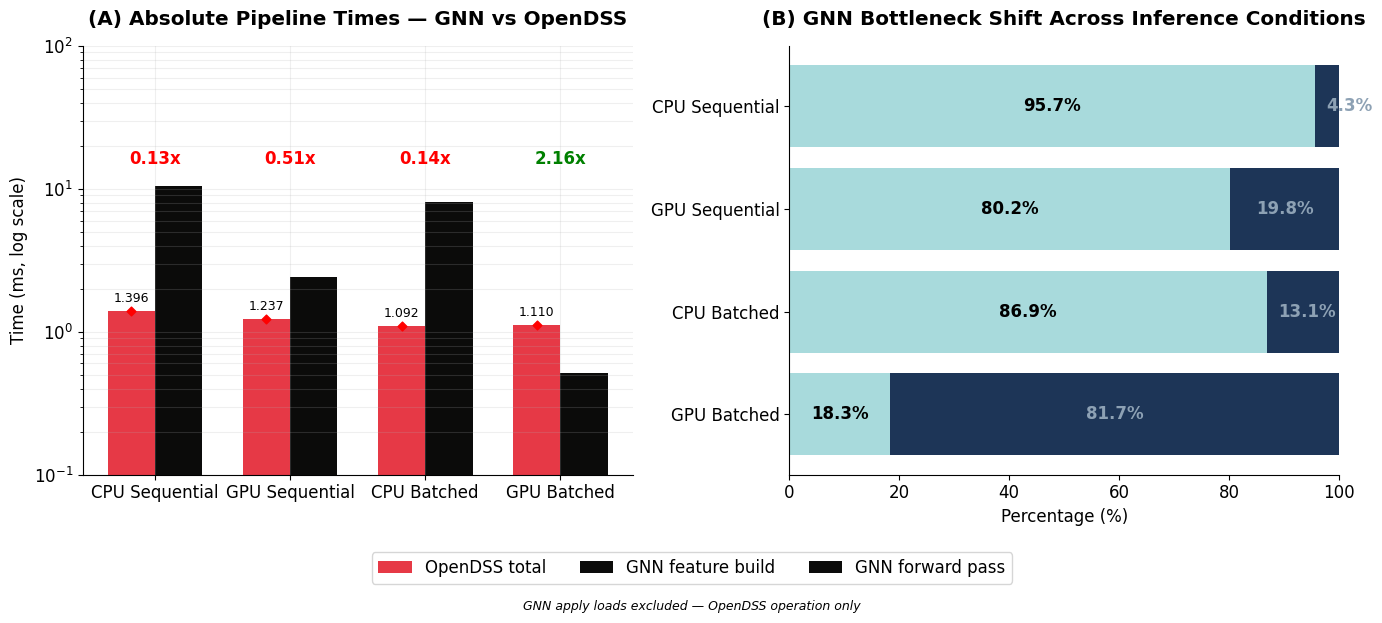

In [27]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['CPU Sequential', 'GPU Sequential', 'CPU Batched', 'GPU Batched']
conditions2 = ['GPU Batched', 'CPU Batched', 'GPU Sequential', 'CPU Sequential']

dss_total = [1.396, 1.237, 1.092, 1.110]
gnn_feat = [0.449, 0.481, 1.054, 0.420]
gnn_fwd = [9.963, 1.947, 7.005, 0.094]
speedups = ["0.13x", "0.51x", "0.14x", "2.16x"]
speedup_colors = ['red', 'red', 'red', 'green']

fwd_pct  = [18.3, 86.9, 80.2, 95.7]
feat_pct = [81.7, 13.1, 19.8,  4.3]

colors = {
    'dss':  '#e63946',
    'fwd':  '#a8dadc',
    'feat': '#1d3557',
    'black': '#0b0b0a',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
bar_width = 0.35
index = np.arange(len(conditions))

ax1.bar(index - bar_width/2, dss_total, bar_width, color=colors['dss'], label='OpenDSS total')
ax1.bar(index + bar_width/2, gnn_feat,  bar_width, color=colors['black'], label='GNN feature build')
ax1.bar(index + bar_width/2, gnn_fwd,   bar_width, bottom=gnn_feat, color=colors['black'], label='GNN forward pass')

for i, val in enumerate(dss_total):
    ax1.scatter(index[i] - bar_width/2, val, color='red', marker='D', s=20, zorder=3)
    ax1.text(index[i] - bar_width/2, val * 1.1, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

for i, (txt, col) in enumerate(zip(speedups, speedup_colors)):
    ax1.text(index[i], 15, txt, ha='center', color=col, fontweight='bold')

ax1.set_yscale('log')
ax1.set_ylim(0.1, 100)
ax1.set_xticks(index)
ax1.set_xticklabels(conditions)
ax1.set_ylabel("Time (ms, log scale)")
ax1.set_title("(A) Absolute Pipeline Times — GNN vs OpenDSS", fontweight='bold', pad=15)
ax1.grid(True, which="both", ls="-", alpha=0.2)

y_pos = np.arange(len(conditions2))
ax2.barh(y_pos, fwd_pct,  color=colors['fwd'],  label='GNN forward pass')
ax2.barh(y_pos, feat_pct, left=fwd_pct, color=colors['feat'], label='GNN feature build')

for i in range(len(conditions2)):
    ax2.text(fwd_pct[i]/2, i, f'{fwd_pct[i]}%',
             ha='center', va='center', color='black', fontweight='bold')
    x_feat = fwd_pct[i] + (feat_pct[i]/2)
    ha = 'center'
    if feat_pct[i] < 15:
        x_feat = fwd_pct[i] + 2
        ha = 'left'
    ax2.text(x_feat, i, f'{feat_pct[i]}%', color="#8DA1B4", ha=ha, va='center', fontweight='bold')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(conditions2)
ax2.set_xlabel("Percentage (%)")
ax2.set_title("(B) GNN Bottleneck Shift Across Inference Conditions", fontweight='bold', pad=15)
ax2.set_xlim(0, 100)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.figtext(0.5, -0.08, "GNN apply loads excluded — OpenDSS operation only",
            ha="center", fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/mnt/user-data/outputs/timing_fixed.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print("saved")

### VREG4_B global GNN grid (36 models)

- **Script:** `train_vreg4b_global_gnn_grid.py` (repo root)
- **Data root:** folder that contains `Heterogenous GNN dataset/` and `gnn_sample_meta.csv` (e.g. `…/loadtype_8500_dailyagg`).
- **Logs:** unbuffered Python so each epoch streams: `python -u` or `PYTHONUNBUFFERED=1`.
- **GPU:** Runtime → GPU recommended (large concat + MLP).

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
DATA_ROOT = "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg"
OUT_DIR = "/content/checkpoints_vreg4b_global_grid"
CACHE = "/content/vreg4b_grid_cache.pt"

os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_vreg4b_global_gnn_grid.py",
    "--data_root", DATA_ROOT,
    "--out_dir", OUT_DIR,
    "--cache_tensor", CACHE,
    "--epochs", "200",
    "--batch_size", "32",
    "--num_workers", "2",
    "--log_every", "1",
    "--sample_frac", "1.0",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

--- Training target 11/22: reg_vreg4_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.734120  train_acc=0.1570  val_ce=1.974439  val_acc=0.2341  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.823783  train_acc=0.2566  val_ce=1.831456  val_acc=0.2819  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.761096  train_acc=0.2998  val_ce=1.766199  val_acc=0.3017  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.716647  train_acc=0.3098  val_ce=1.688084  val_acc=0.3181  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.703427  train_acc=0.3198  val_ce=1.644292  val_acc=0.3679  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.678940  train_acc=0.3344  val_ce=1.648297  val_acc=0.3386  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.631236  train_acc=0.3549  val_ce=1.640656  val_acc=0.3399  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.621820  train_acc=0.3591  val_ce=1.618426  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.618689  train_acc=0.3631  val_ce=1.616580  val_acc=0.3577  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.617433  train_acc=0.3617  val_ce=1.618268  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.605355  train_acc=0.3653  val_ce=1.613623  val_acc=0.3529  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.415985  train_acc=0.1541  val_ce=1.930884  val_acc=0.2901  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.832058  train_acc=0.2041  val_ce=1.818913  val_acc=0.2068  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.806659  train_acc=0.2142  val_ce=1.759115  val_acc=0.2177  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.785570  train_acc=0.2152  val_ce=1.768348  val_acc=0.2280  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.764039  train_acc=0.2316  val_ce=1.725300  val_acc=0.2212  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.738130  train_acc=0.2484  val_ce=1.713525  val_acc=0.2334  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.703485  train_acc=0.2578  val_ce=1.703636  val_acc=0.2403  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.699094  train_acc=0.2530  val_ce=1.698365  val_acc=0.2519  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.698971  train_acc=0.2509  val_ce=1.697641  val_acc=0.2451  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.692591  train_acc=0.2543  val_ce=1.696761  val_acc=0.2498  lr=1.25e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.695694  train_acc=0.2547  val_ce=1.698470  val_acc=0.2396  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.566845  train_acc=0.1122  val_ce=2.086907  val_acc=0.2362  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.865954  train_acc=0.2233  val_ce=1.764102  val_acc=0.2655  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.783109  train_acc=0.2565  val_ce=1.709538  val_acc=0.2867  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.777169  train_acc=0.2878  val_ce=1.700337  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.744106  train_acc=0.2885  val_ce=1.686501  val_acc=0.3085  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.754812  train_acc=0.2946  val_ce=1.673197  val_acc=0.3126  lr=1.00e-03
    [a3_narrow_deeper] epoch   60/100  train_ce=1.723264  train_acc=0.3132  val_ce=1.654680  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   70/100  train_ce=1.686827  train_acc=0.3138  val_ce=1.653093  val_acc=0.3126  lr=5.00e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.680320  train_acc=0.3145  val_ce=1.639781  val_acc=0.3399  lr=5.00e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.662673  train_acc=0.3199  val_ce=1.632826  val_acc=0.3201  lr=2.50e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.646821  train_acc=0.3272  val_ce=1.629434  val_acc=0.3242  lr=1.25e-04
  done reg_vreg4_b_tap_pu: best_arch=a1_wide_shallow val_ce=1.613550  val_acc=0.3543 n_classes=18


with half dataset:
  summary exists: True /content/checkpoints_vreg4b_global_grid/grid_summary.json
n_runs: 36
best run: gcn_L2_dn2_hd1
best val_ce: 0.8055639211633492
best val_acc: 0.6589303733602422

Top 5:
gcn_L2_dn2_hd1 ce= 0.8055639211633492 acc= 0.6589303733602422
gcn_L3_dn2_hd3 ce= 0.8068379602206102 acc= 0.6680121089808274
gcn_L3_dn8_hd3 ce= 0.8097948798257576 acc= 0.6710393541876892
gcn_L3_dn8_hd2 ce= 0.8112037221550581 acc= 0.649848637739657
gcn_L3_dn2_hd2 ce= 0.8114611209341063 acc= 0.6639757820383451

# checkpoints: 36


with whole dataset:
summary exists: True /content/checkpoints_vreg4b_global_grid/grid_summary.json
n_runs: 36
best run: gcn_L3_dn8_hd2
best val_ce: 0.8112876178277609
best val_acc: 0.6584258324924319

Top 5:
gcn_L3_dn8_hd2 ce= 0.8112876178277609 acc= 0.6584258324924319
gcn_L3_dn4_hd3 ce= 0.8120438232190914 acc= 0.6664984863773966
gcn_L3_dn8_hd1 ce= 0.8134135898619921 acc= 0.6644803229061554
gine_L2_dn2_hd3 ce= 0.8172610977102601 acc= 0.6584258324924319
gine_L2_dn8_hd3 ce= 0.8174174000348381 acc= 0.6604439959636731

# checkpoints: 36

### Build compacted load-only line edges (sum R/X through intermediate non-load nodes)

This step creates a new edge CSV that connects only the 1177 load-type MV nodes.  
If two load nodes are connected through simple series intermediate nodes (e.g., capacitor/reg-related nodes), it collapses that path and sums `R_full` and `X_full`.

**Script:** `build_load_only_compacted_edges.py`  
**Default output:**  
`datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv`

In [2]:
import os, sys, subprocess

REPO = r"c:\Users\alita\OneDrive\Desktop\GNN2"  # <-- set explicitly for local run
cmd = [
    sys.executable, "-u", "build_load_only_compacted_edges.py",
    "--edge-catalog", r"datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_edge_catalog.csv",
    "--load-nodes-csv", r"datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--out-csv", r"datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
]

print("PY:", sys.executable)
print("REPO exists:", os.path.isdir(REPO), REPO)
print("Script exists:", os.path.isfile(os.path.join(REPO, "build_load_only_compacted_edges.py")))

for rel in cmd[4:]:
    if rel.startswith("datasets_gnn2"):
        print(rel, "=>", os.path.isfile(os.path.join(REPO, rel)))

res = subprocess.run(cmd, cwd=REPO, text=True, capture_output=True)
print("\nReturn code:", res.returncode)
print("\nSTDOUT:\n", res.stdout)
print("\nSTDERR:\n", res.stderr)

PY: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe
REPO exists: True c:\Users\alita\OneDrive\Desktop\GNN2
Script exists: True
datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_edge_catalog.csv => True
datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv => True
datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv => True

Return code: 0

STDOUT:
 [build_load_only_compacted_edges]
  load nodes: 1177
  line edges input: 2729
  candidates built: 2596
  output unique load-load edges: 2595
  skipped non-series interiors: 127
  wrote: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv


STDERR:
 


### Train load-only global GNN voltage model (P/Q-only node features)

This run trains a homogeneous GNN where:

- Nodes: load-type MV nodes (`hetero_mv_nodes_load_transformer_reg_tap_only.csv`)
- Node features: only `p_load_kw`, `q_load_kvar`
- Edges: compacted load-only line edges (`hetero_mv_line_edges_load_only_compacted.csv`)
- Edge features: `R_full`, `X_full` (+ optional edge embeddings)
- Trunk: GINE or GCN residual message passing
- Readout: global 3-layer MLP on concatenated per-node embeddings
- Output: voltage magnitude (`vmag_pu`) for all load nodes in the graph

The script prints **MAE every epoch** (`--log_every 1`).

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
DATA_ROOT = "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg"
OUT_DIR = "/content/checkpoints_homo_gine_global_pq_loadonly"
CACHE = "/content/preloaded_global_pq_loadonly.pt"

os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_pq_loadonly.py",
    "--data_root", DATA_ROOT,
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", OUT_DIR,
    "--model", "gine",              # or "gcn"
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "2",          # per-node embedding before global head
    "--epochs", "200",
    "--batch_size", "16",
    "--sample_frac", "1.0",         # set e.g. 0.2 for faster experiment
    "--log_every", "1",             # MAE printed every epoch
    "--node_emb_dim", "16",         # set 0 to disable
    "--edge_emb_dim", "8",          # set 0 to disable (ignored for gcn)
    "--cache_tensor", CACHE,
    "--num_workers", "2",
    # "--disable_dropout",          # uncomment to train with no dropout
    # "--dropout", "0.15",          # used when --disable_dropout is NOT set
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

{
  "best_val_mse_pu2": 2.5896767515446673e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 2,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.15,
  "train_frac": 0.8,
  "seed": 42
}

### Train load-only GNN with local + global residual readout

This model predicts all node voltages using:
- **Local head:** per-node prediction from node hidden embedding
- **Global head:** graph-wide correction from concatenated node embeddings
- **Final output:** `v_pred = v_local + delta_global`

Inputs:
- Node features: `p_load_kw`, `q_load_kvar`
- Edge features: `R_full`, `X_full` from compacted load-only edge CSV
- Optional node/edge embeddings (toggle via CLI)

Logs include `train_mae` and `val_mae` every epoch (`--log_every 1`).

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
DATA_ROOT = "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg"
OUT_DIR = "/content/checkpoints_homo_gine_global_localres_pq"
CACHE = "/content/preloaded_global_localres_pq.pt"

os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_loadonly.py",
    "--data_root", DATA_ROOT,
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", OUT_DIR,

    "--model", "gine",          # or "gcn"
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "2",

    "--epochs", "200",
    "--batch_size", "16",
    "--sample_frac", "1.0",     # set e.g. 0.2 for quick experiments
    "--log_every", "1",

    "--node_emb_dim", "16",     # set 0 to disable
    "--edge_emb_dim", "8",      # ignored for gcn
    "--cache_tensor", CACHE,
    "--num_workers", "2",

    # "--disable_dropout",      # uncomment to train with no dropout
    # "--dropout", "0.15",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

{
  "best_val_mse_pu2": 1.9591467000234415e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 2,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.15,
  "train_frac": 0.8,
  "seed": 42
}


without dropout

{
  "best_val_mse_pu2": 1.922471058740789e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 2,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.0,
  "train_frac": 0.8,
  "seed": 42
}

node_out_dimension_4

{
  "best_val_mse_pu2": 1.8652299840169946e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 4,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.0,
  "train_frac": 0.8,
  "seed": 42
}

### Daily compare for new local+global residual model (V, V_local, ΔV_global)

This run compares OpenDSS daily voltages against the checkpoint from:

`train_homo_gine_global_localres_pq_loadonly.py`

and saves per-node plots showing:
- OpenDSS reference voltage
- `V_pred` (final model output)
- `V_local` (local head output)
- `ΔV_global` (global correction output)

Outputs are written under an output folder with:
- `daily_metrics_global_localres.json`
- `monitoring_plots/*_v_local_delta.png`

In [5]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", r"gnn2_architecture_search/homo_mv_8500/checkpoints_homo_gine_global_localres_pq/homo_gine_global_localres_pq_h64_L3_nout2_ne16_ee8_do0.15_best.pt",
    "--dataset-dir", r"datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_8500_output_homo_gine_global_localres_pq",
    #"--plot-node", "l2917359.1",
    #"--plot-node", "l2730108.3",
    #"--plot-node", "l3067506.3",
    #"--plot-node", "l3101782.1",
    #"--plot-node", "l2786204.3",

    #one hop away from VREG2_A
    "--plot-node", "l3010568.1",
    #where CAP_1A is connected
    "--plot-node", "l2823592.1",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search/homo_mv_8500/checkpoints_homo_gine_global_localres_pq/homo_gine_global_localres_pq_h64_L3_nout2_ne16_ee8_do0.15_best.pt --dataset-dir datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset --out-dir gnn2_daily_compare_8500_output_homo_gine_global_localres_pq --plot-node l3010568.1 --plot-node l2823592.1


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_homo_mv_daily_global_localres.py', '--checkpoint', 'gnn2_architecture_search/homo_mv_8500/checkpoints_homo_gine_global_localres_pq/homo_gine_global_localres_pq_h64_L3_nout2_ne16_ee8_do0.15_best.pt', '--dataset-dir', 'datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_8500_output_homo_gine_global_localres_pq', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1'], returncode=0)

Auxiliary-task training with head dropping at inference, aka deep supervision / privileged-information training

### Train with auxiliary-task deep supervision (head dropping at inference)

This run trains the same load-only local+global residual voltage model, but adds
auxiliary regulator/capacitor heads during training to shape trunk representations.

- Main task: node voltage magnitude regression (`vmag_pu`)
- Aux tasks: regulator tap classification + capacitor state classification
- Inference: use voltage prediction only (aux heads ignored)

Loss:
`L_total = L_voltage + λ_reg * L_reg + λ_cap * L_cap`

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--out_dir", "/content/checkpoints_homo_gine_global_localres_pq_aux",
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "4",
    "--epochs", "200",
    "--batch_size", "16",
    "--sample_frac", "1.0",
    "--log_every", "1",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--cache_tensor", "/content/preloaded_global_localres_pq_aux.pt",
    "--num_workers", "2",
    "--lambda_reg", "0.02",
    "--lambda_cap", "0.01",
    "--aux_warmup_epochs", "30",
    "--aux_ramp_epochs", "20",
    "--disable_dropout",
]

print(" ".join(cmd))
# Live logs in Colab (no capture):
subprocess.run(cmd, cwd=REPO, check=True)

{
  "best_val_mse_pu2": 2.7828260684904773e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "meta_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/gnn_sample_meta.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 4,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.0,
  "train_frac": 0.8,
  "seed": 42,
  "lambda_reg": 0.2,
  "lambda_cap": 0.1,
  "aux_targets": {
    "reg": [
      {
        "name": "reg_feeder_rega_tap_pu",
        "n_classes": 9
      },
      {
        "name": "reg_feeder_regb_tap_pu",
        "n_classes": 10
      },
      {
        "name": "reg_feeder_regc_tap_pu",
        "n_classes": 7
      },
      {
        "name": "reg_vreg2_a_tap_pu",
        "n_classes": 15
      },
      {
        "name": "reg_vreg2_b_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg2_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg3_a_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg3_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg3_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg4_a_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_c_tap_pu",
        "n_classes": 11
      }
    ],
    "cap": [
      {
        "name": "cap_capbank0a_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0b_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0c_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank1a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank3_n_steps_on",
        "n_classes": 1
      }
    ]
  }
}


RETURN CODE: 0

--- STDOUT ---
 Loading tensor cache: /content/preloaded_global_localres_pq_aux.pt
Using all 9907 samples
Device=cuda train/val=7925/1982 N=1177 E=5190 model=gine hidden=64 layers=3 nout=4
aux λ: reg=0.2 cap=0.1 | dropout=0.0 | node_emb=16 edge_emb=8
Starting training...
Epoch    1 | train_mae=0.067676 train_mse=0.082202 aux_reg=1.1238 aux_cap=0.1328 | val_mae=0.054619 val_mse=0.003345 aux_reg=0.9110 aux_cap=0.0696 | best_val_mse=0.003345 | patience 0/25
Epoch    2 | train_mae=0.019767 train_mse=0.000642 aux_reg=0.8505 aux_cap=0.0656 | val_mae=0.035199 val_mse=0.001407 aux_reg=0.9634 aux_cap=0.1028 | best_val_mse=0.001407 | patience 0/25
Epoch    3 | train_mae=0.009820 train_mse=0.000181 aux_reg=0.8056 aux_cap=0.0533 | val_mae=0.008497 val_mse=0.000127 aux_reg=0.7814 aux_cap=0.0426 | best_val_mse=0.000127 | patience 0/25
Epoch    4 | train_mae=0.007802 train_mse=0.000118 aux_reg=0.7686 aux_cap=0.0468 | val_mae=0.007963 val_mse=0.000129 aux_reg=0.7982 aux_cap=0.0450 | best_val_mse=0.000127 | patience 1/25
Epoch    5 | train_mae=0.007694 train_mse=0.000117 aux_reg=0.7501 aux_cap=0.0449 | val_mae=0.005852 val_mse=0.000075 aux_reg=0.7453 aux_cap=0.0385 | best_val_mse=0.000075 | patience 0/25
Epoch    6 | train_mae=0.006544 train_mse=0.000088 aux_reg=0.7311 aux_cap=0.0398 | val_mae=0.006593 val_mse=0.000098 aux_reg=0.7259 aux_cap=0.0378 | best_val_mse=0.000075 | patience 1/25
Epoch    7 | train_mae=0.006566 train_mse=0.000086 aux_reg=0.7213 aux_cap=0.0403 | val_mae=0.005947 val_mse=0.000071 aux_reg=0.7292 aux_cap=0.0460 | best_val_mse=0.000071 | patience 0/25
Epoch    8 | train_mae=0.006735 train_mse=0.000088 aux_reg=0.7145 aux_cap=0.0381 | val_mae=0.005827 val_mse=0.000073 aux_reg=0.7199 aux_cap=0.0378 | best_val_mse=0.000071 | patience 1/25
Epoch    9 | train_mae=0.006449 train_mse=0.000080 aux_reg=0.7067 aux_cap=0.0374 | val_mae=0.008473 val_mse=0.000113 aux_reg=0.7245 aux_cap=0.0434 | best_val_mse=0.000071 | patience 2/25
Epoch   10 | train_mae=0.006489 train_mse=0.000081 aux_reg=0.7010 aux_cap=0.0369 | val_mae=0.006713 val_mse=0.000086 aux_reg=0.7191 aux_cap=0.0389 | best_val_mse=0.000071 | patience 3/25
Epoch   11 | train_mae=0.005882 train_mse=0.000067 aux_reg=0.6945 aux_cap=0.0358 | val_mae=0.005126 val_mse=0.000052 aux_reg=0.7040 aux_cap=0.0373 | best_val_mse=0.000052 | patience 0/25
Epoch   12 | train_mae=0.005980 train_mse=0.000069 aux_reg=0.6903 aux_cap=0.0360 | val_mae=0.006884 val_mse=0.000084 aux_reg=0.7110 aux_cap=0.0377 | best_val_mse=0.000052 | patience 1/25
Epoch   13 | train_mae=0.005786 train_mse=0.000064 aux_reg=0.6867 aux_cap=0.0343 | val_mae=0.005267 val_mse=0.000073 aux_reg=0.7045 aux_cap=0.0391 | best_val_mse=0.000052 | patience 2/25
Epoch   14 | train_mae=0.005314 train_mse=0.000054 aux_reg=0.6836 aux_cap=0.0343 | val_mae=0.004797 val_mse=0.000053 aux_reg=0.7095 aux_cap=0.0380 | best_val_mse=0.000052 | patience 3/25
Epoch   15 | train_mae=0.005521 train_mse=0.000057 aux_reg=0.6797 aux_cap=0.0335 | val_mae=0.007478 val_mse=0.000083 aux_reg=0.7036 aux_cap=0.0366 | best_val_mse=0.000052 | patience 4/25
Epoch   16 | train_mae=0.005522 train_mse=0.000057 aux_reg=0.6734 aux_cap=0.0326 | val_mae=0.005329 val_mse=0.000052 aux_reg=0.7032 aux_cap=0.0356 | best_val_mse=0.000052 | patience 0/25
Epoch   17 | train_mae=0.005001 train_mse=0.000046 aux_reg=0.6690 aux_cap=0.0325 | val_mae=0.004543 val_mse=0.000038 aux_reg=0.6982 aux_cap=0.0358 | best_val_mse=0.000038 | patience 0/25
Epoch   18 | train_mae=0.004889 train_mse=0.000044 aux_reg=0.6657 aux_cap=0.0323 | val_mae=0.005389 val_mse=0.000051 aux_reg=0.7045 aux_cap=0.0381 | best_val_mse=0.000038 | patience 1/25
Epoch   19 | train_mae=0.005133 train_mse=0.000048 aux_reg=0.6608 aux_cap=0.0314 | val_mae=0.005564 val_mse=0.000056 aux_reg=0.7061 aux_cap=0.0370 | best_val_mse=0.000038 | patience 2/25
Epoch   20 | train_mae=0.004927 train_mse=0.000045 aux_reg=0.6559 aux_cap=0.0305 | val_mae=0.005759 val_mse=0.000053 aux_reg=0.7040 aux_cap=0.0397 | best_val_mse=0.000038 | patience 3/25
Epoch   21 | train_mae=0.004979 train_mse=0.000046 aux_reg=0.6515 aux_cap=0.0310 | val_mae=0.004234 val_mse=0.000033 aux_reg=0.7078 aux_cap=0.0373 | best_val_mse=0.000033 | patience 0/25
Epoch   22 | train_mae=0.004639 train_mse=0.000041 aux_reg=0.6468 aux_cap=0.0292 | val_mae=0.004215 val_mse=0.000032 aux_reg=0.7176 aux_cap=0.0443 | best_val_mse=0.000032 | patience 0/25
Epoch   23 | train_mae=0.004758 train_mse=0.000042 aux_reg=0.6386 aux_cap=0.0292 | val_mae=0.004579 val_mse=0.000038 aux_reg=0.7154 aux_cap=0.0367 | best_val_mse=0.000032 | patience 1/25
Epoch   24 | train_mae=0.004667 train_mse=0.000041 aux_reg=0.6348 aux_cap=0.0292 | val_mae=0.004415 val_mse=0.000037 aux_reg=0.7074 aux_cap=0.0373 | best_val_mse=0.000032 | patience 2/25
Epoch   25 | train_mae=0.004521 train_mse=0.000037 aux_reg=0.6271 aux_cap=0.0281 | val_mae=0.005518 val_mse=0.000052 aux_reg=0.7202 aux_cap=0.0414 | best_val_mse=0.000032 | patience 3/25
Epoch   26 | train_mae=0.004712 train_mse=0.000041 aux_reg=0.6203 aux_cap=0.0275 | val_mae=0.005066 val_mse=0.000042 aux_reg=0.7262 aux_cap=0.0390 | best_val_mse=0.000032 | patience 4/25
Epoch   27 | train_mae=0.004636 train_mse=0.000041 aux_reg=0.6108 aux_cap=0.0264 | val_mae=0.004309 val_mse=0.000033 aux_reg=0.7366 aux_cap=0.0440 | best_val_mse=0.000032 | patience 5/25
Epoch   28 | train_mae=0.004701 train_mse=0.000042 aux_reg=0.6040 aux_cap=0.0274 | val_mae=0.005427 val_mse=0.000053 aux_reg=0.7505 aux_cap=0.0408 | best_val_mse=0.000032 | patience 6/25
Epoch   29 | train_mae=0.004342 train_mse=0.000035 aux_reg=0.5949 aux_cap=0.0258 | val_mae=0.004128 val_mse=0.000030 aux_reg=0.7367 aux_cap=0.0400 | best_val_mse=0.000030 | patience 0/25
Epoch   30 | train_mae=0.004485 train_mse=0.000037 aux_reg=0.5844 aux_cap=0.0254 | val_mae=0.005557 val_mse=0.000053 aux_reg=0.7494 aux_cap=0.0412 | best_val_mse=0.000030 | patience 1/25
Epoch   31 | train_mae=0.004540 train_mse=0.000039 aux_reg=0.5728 aux_cap=0.0254 | val_mae=0.004323 val_mse=0.000031 aux_reg=0.7690 aux_cap=0.0438 | best_val_mse=0.000030 | patience 2/25
Epoch   32 | train_mae=0.004320 train_mse=0.000034 aux_reg=0.5604 aux_cap=0.0231 | val_mae=0.006184 val_mse=0.000075 aux_reg=0.7849 aux_cap=0.0458 | best_val_mse=0.000030 | patience 3/25
Epoch   33 | train_mae=0.010370 train_mse=0.000684 aux_reg=0.5512 aux_cap=0.0232 | val_mae=0.004747 val_mse=0.000040 aux_reg=0.7957 aux_cap=0.0435 | best_val_mse=0.000030 | patience 4/25
Epoch   34 | train_mae=0.004478 train_mse=0.000038 aux_reg=0.5389 aux_cap=0.0224 | val_mae=0.004311 val_mse=0.000031 aux_reg=0.7969 aux_cap=0.0445 | best_val_mse=0.000030 | patience 5/25
Epoch   35 | train_mae=0.004181 train_mse=0.000031 aux_reg=0.5233 aux_cap=0.0210 | val_mae=0.004619 val_mse=0.000037 aux_reg=0.8125 aux_cap=0.0487 | best_val_mse=0.000030 | patience 6/25
Epoch   36 | train_mae=0.004235 train_mse=0.000034 aux_reg=0.5014 aux_cap=0.0202 | val_mae=0.004531 val_mse=0.000044 aux_reg=0.8734 aux_cap=0.0550 | best_val_mse=0.000030 | patience 7/25
Epoch   37 | train_mae=0.004238 train_mse=0.000032 aux_reg=0.4844 aux_cap=0.0196 | val_mae=0.004493 val_mse=0.000035 aux_reg=0.8664 aux_cap=0.0500 | best_val_mse=0.000030 | patience 8/25
Epoch   38 | train_mae=0.004697 train_mse=0.000047 aux_reg=0.4586 aux_cap=0.0186 | val_mae=0.004083 val_mse=0.000030 aux_reg=0.8888 aux_cap=0.0498 | best_val_mse=0.000030 | patience 0/25
Epoch   39 | train_mae=0.004320 train_mse=0.000033 aux_reg=0.4378 aux_cap=0.0182 | val_mae=0.004324 val_mse=0.000033 aux_reg=0.9274 aux_cap=0.0560 | best_val_mse=0.000030 | patience 1/25
Epoch   40 | train_mae=0.004146 train_mse=0.000031 aux_reg=0.4036 aux_cap=0.0171 | val_mae=0.004214 val_mse=0.000031 aux_reg=0.9990 aux_cap=0.0579 | best_val_mse=0.000030 | patience 2/25
Epoch   41 | train_mae=0.008928 train_mse=0.000471 aux_reg=0.3768 aux_cap=0.0159 | val_mae=0.011060 val_mse=0.000328 aux_reg=1.0070 aux_cap=0.0541 | best_val_mse=0.000030 | patience 3/25
Epoch   42 | train_mae=0.008071 train_mse=0.000201 aux_reg=0.3414 aux_cap=0.0145 | val_mae=0.006093 val_mse=0.000096 aux_reg=1.0922 aux_cap=0.0635 | best_val_mse=0.000030 | patience 4/25
Epoch   43 | train_mae=0.007977 train_mse=0.000210 aux_reg=0.3125 aux_cap=0.0132 | val_mae=0.007422 val_mse=0.000171 aux_reg=1.1861 aux_cap=0.0677 | best_val_mse=0.000030 | patience 5/25
Epoch   44 | train_mae=0.007397 train_mse=0.000182 aux_reg=0.2821 aux_cap=0.0130 | val_mae=0.007263 val_mse=0.000146 aux_reg=1.2208 aux_cap=0.0659 | best_val_mse=0.000030 | patience 6/25
Epoch   45 | train_mae=0.005970 train_mse=0.000093 aux_reg=0.2603 aux_cap=0.0123 | val_mae=0.004408 val_mse=0.000035 aux_reg=1.3070 aux_cap=0.0689 | best_val_mse=0.000030 | patience 7/25
Epoch   46 | train_mae=0.004369 train_mse=0.000036 aux_reg=0.2384 aux_cap=0.0119 | val_mae=0.004384 val_mse=0.000034 aux_reg=1.4270 aux_cap=0.0747 | best_val_mse=0.000030 | patience 8/25
Epoch   47 | train_mae=0.004211 train_mse=0.000033 aux_reg=0.2139 aux_cap=0.0110 | val_mae=0.004208 val_mse=0.000034 aux_reg=1.5045 aux_cap=0.0777 | best_val_mse=0.000030 | patience 9/25
Epoch   48 | train_mae=0.004390 train_mse=0.000038 aux_reg=0.1984 aux_cap=0.0097 | val_mae=0.004021 val_mse=0.000028 aux_reg=1.5865 aux_cap=0.0845 | best_val_mse=0.000028 | patience 0/25
Epoch   49 | train_mae=0.004311 train_mse=0.000034 aux_reg=0.1854 aux_cap=0.0098 | val_mae=0.004462 val_mse=0.000036 aux_reg=1.6648 aux_cap=0.0881 | best_val_mse=0.000028 | patience 1/25
Epoch   50 | train_mae=0.004474 train_mse=0.000036 aux_reg=0.1703 aux_cap=0.0097 | val_mae=0.007399 val_mse=0.000084 aux_reg=1.7678 aux_cap=0.0905 | best_val_mse=0.000028 | patience 2/25
Epoch   51 | train_mae=0.007500 train_mse=0.000447 aux_reg=0.1539 aux_cap=0.0080 | val_mae=0.039853 val_mse=0.003958 aux_reg=1.8227 aux_cap=0.0908 | best_val_mse=0.000028 | patience 3/25
Epoch   52 | train_mae=0.011109 train_mse=0.000482 aux_reg=0.1476 aux_cap=0.0080 | val_mae=0.011279 val_mse=0.000737 aux_reg=1.8593 aux_cap=0.0941 | best_val_mse=0.000028 | patience 4/25
Epoch   53 | train_mae=0.008772 train_mse=0.000247 aux_reg=0.1327 aux_cap=0.0084 | val_mae=0.008545 val_mse=0.000183 aux_reg=2.0228 aux_cap=0.1008 | best_val_mse=0.000028 | patience 5/25
Epoch   54 | train_mae=0.008395 train_mse=0.000198 aux_reg=0.1253 aux_cap=0.0072 | val_mae=0.008757 val_mse=0.000169 aux_reg=2.0054 aux_cap=0.1073 | best_val_mse=0.000028 | patience 6/25
Epoch   55 | train_mae=0.009677 train_mse=0.000295 aux_reg=0.1210 aux_cap=0.0073 | val_mae=0.007815 val_mse=0.000153 aux_reg=2.1301 aux_cap=0.1102 | best_val_mse=0.000028 | patience 7/25
Epoch   56 | train_mae=0.006892 train_mse=0.000120 aux_reg=0.1242 aux_cap=0.0090 | val_mae=0.005524 val_mse=0.000061 aux_reg=2.1036 aux_cap=0.1046 | best_val_mse=0.000028 | patience 8/25
Epoch   57 | train_mae=0.005392 train_mse=0.000060 aux_reg=0.1132 aux_cap=0.0074 | val_mae=0.005278 val_mse=0.000054 aux_reg=2.1581 aux_cap=0.1056 | best_val_mse=0.000028 | patience 9/25
Epoch   58 | train_mae=0.004786 train_mse=0.000043 aux_reg=0.1105 aux_cap=0.0065 | val_mae=0.005025 val_mse=0.000045 aux_reg=2.2593 aux_cap=0.1098 | best_val_mse=0.000028 | patience 10/25
Epoch   59 | train_mae=0.004713 train_mse=0.000041 aux_reg=0.1042 aux_cap=0.0076 | val_mae=0.004725 val_mse=0.000041 aux_reg=2.2860 aux_cap=0.1087 | best_val_mse=0.000028 | patience 11/25
Epoch   60 | train_mae=0.004332 train_mse=0.000034 aux_reg=0.0567 aux_cap=0.0039 | val_mae=0.004310 val_mse=0.000032 aux_reg=2.5269 aux_cap=0.1209 | best_val_mse=0.000028 | patience 12/25
Epoch   61 | train_mae=0.004676 train_mse=0.000040 aux_reg=0.0261 aux_cap=0.0025 | val_mae=0.004893 val_mse=0.000045 aux_reg=2.7809 aux_cap=0.1318 | best_val_mse=0.000028 | patience 13/25
Epoch   62 | train_mae=0.004922 train_mse=0.000044 aux_reg=0.0188 aux_cap=0.0017 | val_mae=0.004970 val_mse=0.000046 aux_reg=3.0047 aux_cap=0.1453 | best_val_mse=0.000028 | patience 14/25
Epoch   63 | train_mae=0.004888 train_mse=0.000043 aux_reg=0.0220 aux_cap=0.0022 | val_mae=0.005241 val_mse=0.000050 aux_reg=3.1557 aux_cap=0.1494 | best_val_mse=0.000028 | patience 15/25
Epoch   64 | train_mae=0.004848 train_mse=0.000042 aux_reg=0.0318 aux_cap=0.0025 | val_mae=0.005165 val_mse=0.000049 aux_reg=3.1027 aux_cap=0.1463 | best_val_mse=0.000028 | patience 16/25
Epoch   65 | train_mae=0.004853 train_mse=0.000044 aux_reg=0.0416 aux_cap=0.0027 | val_mae=0.005441 val_mse=0.000054 aux_reg=3.1097 aux_cap=0.1487 | best_val_mse=0.000028 | patience 17/25
Epoch   66 | train_mae=0.004548 train_mse=0.000036 aux_reg=0.0373 aux_cap=0.0025 | val_mae=0.004601 val_mse=0.000038 aux_reg=3.2117 aux_cap=0.1498 | best_val_mse=0.000028 | patience 18/25
Epoch   67 | train_mae=0.004592 train_mse=0.000037 aux_reg=0.0286 aux_cap=0.0023 | val_mae=0.005561 val_mse=0.000054 aux_reg=3.2830 aux_cap=0.1565 | best_val_mse=0.000028 | patience 19/25
Epoch   68 | train_mae=0.004679 train_mse=0.000038 aux_reg=0.0291 aux_cap=0.0024 | val_mae=0.004798 val_mse=0.000042 aux_reg=3.3643 aux_cap=0.1580 | best_val_mse=0.000028 | patience 20/25
Epoch   69 | train_mae=0.004559 train_mse=0.000037 aux_reg=0.0291 aux_cap=0.0019 | val_mae=0.004742 val_mse=0.000039 aux_reg=3.3725 aux_cap=0.1590 | best_val_mse=0.000028 | patience 21/25
Epoch   70 | train_mae=0.004726 train_mse=0.000040 aux_reg=0.0291 aux_cap=0.0031 | val_mae=0.004894 val_mse=0.000044 aux_reg=3.5212 aux_cap=0.1684 | best_val_mse=0.000028 | patience 22/25
Epoch   71 | train_mae=0.004382 train_mse=0.000034 aux_reg=0.0169 aux_cap=0.0015 | val_mae=0.004408 val_mse=0.000034 aux_reg=3.4888 aux_cap=0.1651 | best_val_mse=0.000028 | patience 23/25
Epoch   72 | train_mae=0.004351 train_mse=0.000034 aux_reg=0.0056 aux_cap=0.0006 | val_mae=0.004491 val_mse=0.000038 aux_reg=3.6446 aux_cap=0.1710 | best_val_mse=0.000028 | patience 24/25
Epoch   73 | train_mae=0.004498 train_mse=0.000037 aux_reg=0.0033 aux_cap=0.0004 | val_mae=0.004673 val_mse=0.000041 aux_reg=3.8235 aux_cap=0.1796 | best_val_mse=0.000028 | patience 25/25
Early stopping at epoch 73
Best val MSE: 2.7828260684904773e-05
Saved: /content/checkpoints_homo_gine_global_localres_pq_aux/homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt


--- STDERR ---
 


 with warmup

 {
  "best_val_mse_pu2": 1.5464555317071745e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "meta_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/gnn_sample_meta.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 4,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout": 0.0,
  "train_frac": 0.8,
  "seed": 42,
  "lambda_reg": 0.02,
  "lambda_cap": 0.01,
  "aux_warmup_epochs": 30,
  "aux_ramp_epochs": 20,
  "aux_targets": {
    "reg": [
      {
        "name": "reg_feeder_rega_tap_pu",
        "n_classes": 9
      },
      {
        "name": "reg_feeder_regb_tap_pu",
        "n_classes": 10
      },
      {
        "name": "reg_feeder_regc_tap_pu",
        "n_classes": 7
      },
      {
        "name": "reg_vreg2_a_tap_pu",
        "n_classes": 15
      },
      {
        "name": "reg_vreg2_b_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg2_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg3_a_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg3_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg3_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg4_a_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_c_tap_pu",
        "n_classes": 11
      }
    ],
    "cap": [
      {
        "name": "cap_capbank0a_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0b_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0c_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank1a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank3_n_steps_on",
        "n_classes": 1
      }
    ]
  }
}

In [7]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT_DIR = r"gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", rf"{CKPT_DIR}\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt",
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_aux_warmup",
    "--daily-profile", "5minDayShape.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_aux_warmup --daily-profile 5minDayShape.csv --plot-node l3010568.1 --plot-node l2823592.1


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_homo_mv_daily_global_localres.py', '--checkpoint', 'gnn2_architecture_search\\homo_mv_8500\\checkpoints_homo_gine_global_localres_pq_aux_warmup\\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_aux_warmup', '--daily-profile', '5minDayShape.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1'], returncode=0)

In [8]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT_DIR = r"gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", rf"{CKPT_DIR}\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt",
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_aux_warmup_shape2",
    "--daily-profile", "5minDayShape2.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_aux_warmup_shape2 --daily-profile 5minDayShape2.csv --plot-node l3010568.1 --plot-node l2823592.1


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_homo_mv_daily_global_localres.py', '--checkpoint', 'gnn2_architecture_search\\homo_mv_8500\\checkpoints_homo_gine_global_localres_pq_aux_warmup\\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_aux_warmup_shape2', '--daily-profile', '5minDayShape2.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1'], returncode=0)

## Daily compare — homo GNN (local + ΔV global) vs OpenDSS

Script: `compare_homo_mv_daily_global_localres.py`

**What it does:** Steps through one day (default 288 × 5 min) using a **daily load shape** CSV, solves OpenDSS each step, builds **P/Q** for all **1177** load-type MV nodes, runs the GNN (`V_pred = V_local + ΔV_global`), and compares to OpenDSS.

### Useful flags

| Flag | Purpose |
|------|--------|
| `--checkpoint` | Path to `*_best.pt` (aux checkpoints OK; `aux_*` layers ignored at inference) |
| `--dataset-dir` | `.../Heterogenous GNN dataset` |
| `--out-dir` | Where JSON, CSV, and figures are written |
| `--daily-profile` | e.g. `5minDayShape.csv`, `5minDayShape2.csv`, `5minDayShape3.csv` (resolved under `8500-node/`) |
| `--plot-node` | Repeat per node; saved under `monitoring_plots/` |
| `--worst-k K` | Rank nodes by time-mean \|V_pred − V_dss\|; save `daily_per_node_mae.csv` and figures under `monitoring_plots/worst_by_mae/` |
| `--save-per-node-mae-csv` | Write `daily_per_node_mae.csv` even when `--worst-k 0` |
| `--train-metrics` / `--feature-norm` | Optional; defaults to files next to the checkpoint |

### Outputs (`--out-dir`)

- `daily_metrics_global_localres.json` — global MAE/RMSE, mean MAE per node, worst-node list, profile path, timing  
- `daily_per_node_mae.csv` — all nodes, MAE/RMSE per node, sorted by MAE (when `--worst-k > 0` or `--save-per-node-mae-csv`)  
- `monitoring_plots/` — plots for `--plot-node`  
- `monitoring_plots/worst_by_mae/` — plots for top-K worst nodes  

In [1]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT_DIR = r"gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", rf"{CKPT_DIR}\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt",
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_aux_warmup_shape_report",
    "--daily-profile", "5minDayShape.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "5",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_warmup\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_aux_warmup_shape_report --daily-profile 5minDayShape.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 5


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_homo_mv_daily_global_localres.py', '--checkpoint', 'gnn2_architecture_search\\homo_mv_8500\\checkpoints_homo_gine_global_localres_pq_aux_warmup\\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_do0_best.pt', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_aux_warmup_shape_report', '--daily-profile', '5minDayShape.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1', '--worst-k', '5'], returncode=0)

## Compare Real MLP vs CVNN MLP on Complex Voltage Prediction

This run trains two models using only flattened node load features (`p_load_kw`, `q_load_kvar`) and predicts per-node complex voltage (`V_re`, `V_im`).

Outputs are saved under `mlp_cvnn_compare_8500/`:
- `real_mlp_best.pt`
- `cvnn_mlp_best.pt`
- `comparison_report.json`

In [ ]:
# 1) Move to repo and run training script
import os, sys, subprocess, json

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_compare_mlp_cvnn_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--out_dir", "/content/mlp_cvnn_compare_8500",
    "--epochs", "200",
    "--batch_size", "32",
    "--hidden_real", "1024",
    "--hidden_cvnn", "768",
    "--lr", "1e-3",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
]

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

## Daily OpenDSS vs Real-MLP vs CVNN-MLP

This cell runs daily comparison using MLP checkpoints from:

`C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\mlp_cvnn_compare_8500`

Outputs include magnitude + angle metrics, per-node MAE CSV, and plots.

In [3]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT_DIR = r"gnn2_architecture_search\mlp_cvnn_compare_8500"

cmd = [
    sys.executable, "-u", "compare_mlp_cvnn_daily.py",
    "--ckpt-dir", CKPT_DIR,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_mlp_cvnn_report_shape",
    "--daily-profile", "5minDayShape.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "5",
]

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_mlp_cvnn_daily.py --ckpt-dir gnn2_architecture_search\mlp_cvnn_compare_8500 --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_mlp_cvnn_report_shape --daily-profile 5minDayShape.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 5


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_mlp_cvnn_daily.py', '--ckpt-dir', 'gnn2_architecture_search\\mlp_cvnn_compare_8500', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_mlp_cvnn_report_shape', '--daily-profile', '5minDayShape.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1', '--worst-k', '5'], returncode=0)

In [4]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT_DIR = r"gnn2_architecture_search\mlp_cvnn_compare_8500"

cmd = [
    sys.executable, "-u", "compare_mlp_cvnn_daily.py",
    "--ckpt-dir", CKPT_DIR,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_mlp_cvnn_report_shape4",
    "--daily-profile", "5minDayShape4.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "5",
]

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_mlp_cvnn_daily.py --ckpt-dir gnn2_architecture_search\mlp_cvnn_compare_8500 --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_mlp_cvnn_report_shape4 --daily-profile 5minDayShape4.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 5


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_mlp_cvnn_daily.py', '--ckpt-dir', 'gnn2_architecture_search\\mlp_cvnn_compare_8500', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_mlp_cvnn_report_shape4', '--daily-profile', '5minDayShape4.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1', '--worst-k', '5'], returncode=0)

## Train Homo GINE + Aux with Complex Voltage Target (Re/Im)

This run keeps the same setup as before, but switches voltage supervision from `|V|` to complex `(V_re, V_im)` by setting `--voltage-target complex_ri`.

In [ ]:
import os, sys, subprocess, datetime, pathlib

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/checkpoints_homo_gine_global_localres_pq_aux_mag_angle_fresh_{tag}"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--out_dir", out_dir,
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "4",
    "--epochs", "200",
    "--batch_size", "16",
    "--sample_frac", "1.0",
    "--log_every", "1",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--num_workers", "2",
    "--lambda_reg", "0.02",
    "--lambda_cap", "0.01",
    "--aux_warmup_epochs", "30",
    "--aux_ramp_epochs", "20",
    "--disable_dropout",
    "--voltage-target", "complex_ri",
]

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)
print("Saved run bundle:", out_dir)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --out_dir /content/checkpoints_homo_gine_global_localres_pq_aux --model gine --hidden 64 --layers 3 --node_out_dim 4 --epochs 200 --batch_size 16 --sample_frac 1.0 --log_every 1 --node_emb_dim 16 --edge_emb_dim 8 --cache_tensor /content/preloaded_global_localres_pq_aux.pt --num_workers 2 --lambda_reg 0.02 --lambda_cap 0.01 --aux_warmup_epochs 30 --aux_ramp_epochs 20 --disable_dropout --voltage-target complex_ri


CalledProcessError: Command '['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'train_homo_gine_global_localres_pq_aux.py', '--data_root', '/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg', '--nodes_csv', 'Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv', '--edge_catalog_csv', 'Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv', '--meta_csv', 'gnn_sample_meta.csv', '--out_dir', '/content/checkpoints_homo_gine_global_localres_pq_aux', '--model', 'gine', '--hidden', '64', '--layers', '3', '--node_out_dim', '4', '--epochs', '200', '--batch_size', '16', '--sample_frac', '1.0', '--log_every', '1', '--node_emb_dim', '16', '--edge_emb_dim', '8', '--cache_tensor', '/content/preloaded_global_localres_pq_aux.pt', '--num_workers', '2', '--lambda_reg', '0.02', '--lambda_cap', '0.01', '--aux_warmup_epochs', '30', '--aux_ramp_epochs', '20', '--disable_dropout', '--voltage-target', 'complex_ri']' 

{
  "best_val_mse_pu2": 1.5339728883870954e-05,
  "nodes_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
  "edge_catalog_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
  "meta_csv": "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/gnn_sample_meta.csv",
  "n_samples": 9907,
  "sample_frac": 1.0,
  "max_samples": null,
  "n_nodes": 1177,
  "n_edges_directed": 5190,
  "n_features": 2,
  "model": "gine",
  "hidden": 64,
  "layers": 3,
  "node_out_dim": 4,
  "node_emb_dim": 16,
  "edge_emb_dim": 8,
  "dropout_trunk": 0.0,
  "dropout_global": 0.0,
  "dropout_aux": 0.0,
  "train_frac": 0.8,
  "val_frac": 0.1,
  "seed": 42,
  "lambda_reg": 0.02,
  "lambda_cap": 0.01,
  "aux_warmup_epochs": 30,
  "aux_ramp_epochs": 20,
  "aux_targets": {
    "reg": [
      {
        "name": "reg_feeder_rega_tap_pu",
        "n_classes": 9
      },
      {
        "name": "reg_feeder_regb_tap_pu",
        "n_classes": 10
      },
      {
        "name": "reg_feeder_regc_tap_pu",
        "n_classes": 7
      },
      {
        "name": "reg_vreg2_a_tap_pu",
        "n_classes": 15
      },
      {
        "name": "reg_vreg2_b_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg2_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg3_a_tap_pu",
        "n_classes": 16
      },
      {
        "name": "reg_vreg3_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg3_c_tap_pu",
        "n_classes": 6
      },
      {
        "name": "reg_vreg4_a_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_b_tap_pu",
        "n_classes": 17
      },
      {
        "name": "reg_vreg4_c_tap_pu",
        "n_classes": 11
      }
    ],
    "cap": [
      {
        "name": "cap_capbank0a_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0b_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank0c_n_steps_on",
        "n_classes": 1
      },
      {
        "name": "cap_capbank1a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank1c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2a_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2b_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank2c_n_steps_on",
        "n_classes": 2
      },
      {
        "name": "cap_capbank3_n_steps_on",
        "n_classes": 1
      }
    ]
  },
  "voltage_target_mode": "complex_ri",
  "skip_train": false,
  "train_seconds": 2778.823241741001,
  "split_counts": {
    "train": 7925,
    "val": 990,
    "test": 992
  },
  "val_voltage_metrics": {
    "mae_vmag_pu": 0.0037890556074005794,
    "rmse_vmag_pu": 0.00494803500538693,
    "mae_angle_deg": 0.08438469120299748,
    "rmse_angle_deg": 0.1419556131290153
  },
  "test_voltage_metrics": {
    "mae_vmag_pu": 0.00376249575721439,
    "rmse_vmag_pu": 0.004888242465637384,
    "mae_angle_deg": 0.0830555786530937,
    "rmse_angle_deg": 0.14051210479946433
  }
}


This cell runs daily comparison using the newest `*_best.pt` checkpoint from:
`gnn2_architecture_search/homo_mv_8500/checkpoints_homo_gine_global_localres_pq_aux_mag+angle`
It compares against OpenDSS for `5minDayShape4.csv`, generates plots for selected monitoring nodes, and auto-plots the worst `k` nodes by MAE.

In [6]:
# Safe inference cell (local) for homo global+localres aux model
# - picks a checkpoint
# - enforces matching train_metrics + feature_norm from SAME folder
# - fails fast on common mismatch issues
# - prints full stdout/stderr for debugging

import os, sys, subprocess, pathlib, shutil, json

REPO = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
CKPT_DIR = REPO / "gnn2_architecture_search" / "homo_mv_8500" / "checkpoints_homo_gine_global_localres_pq_aux_mag_angle_fresh"

DATASET_DIR = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg" / "Heterogenous GNN dataset"
OUT_DIR = REPO / "gnn2_daily_compare_aux_mag_angle_report_shape4_safe"

DAILY_PROFILE = "5minDayShape4.csv"
PLOT_NODES = ["l3010568.1", "l2823592.1"]

# ---------- hard checks ----------
if not REPO.is_dir():
    raise FileNotFoundError(f"REPO not found: {REPO}")
if not CKPT_DIR.is_dir():
    raise FileNotFoundError(f"Checkpoint directory not found: {CKPT_DIR}")
if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

ckpts = sorted(CKPT_DIR.glob("*_best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not ckpts:
    raise FileNotFoundError(f"No *_best.pt found in {CKPT_DIR}")
ckpt = ckpts[0]

metrics = CKPT_DIR / "train_metrics_global_localres_aux.json"   # aux training JSON
norm = CKPT_DIR / "feature_norm_pq.pt"

for p in [ckpt, metrics, norm]:
    if not p.is_file():
        raise FileNotFoundError(f"Required artifact missing: {p}")

# ---------- metadata compatibility checks ----------
meta = json.loads(metrics.read_text(encoding="utf-8"))
if str(meta.get("model", "")).lower() != "gine":
    raise RuntimeError(f"Expected model=gine in metrics, got: {meta.get('model')}")
if str(meta.get("voltage_target_mode", "")).lower() != "complex_ri":
    raise RuntimeError(f"Expected voltage_target_mode=complex_ri, got: {meta.get('voltage_target_mode')}")
if int(meta.get("node_out_dim", -1)) != 4:
    raise RuntimeError(f"Expected node_out_dim=4, got: {meta.get('node_out_dim')}")

print("Using checkpoint:", ckpt.name)
print("metrics:", metrics.name)
print("norm:", norm.name)
print("model:", meta.get("model"))
print("voltage_target_mode:", meta.get("voltage_target_mode"))
print("n_nodes:", meta.get("n_nodes"), "n_edges_directed:", meta.get("n_edges_directed"))

# clean output dir
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", str(ckpt),
    "--train-metrics", str(metrics),
    "--feature-norm", str(norm),
    "--dataset-dir", str(DATASET_DIR),
    "--out-dir", str(OUT_DIR),
    "--daily-profile", DAILY_PROFILE,
    "--worst-k", "5",
    "--ymin", "-0.1", "--ymax", "1.1",
    "--debug-features", "5",
]
for n in PLOT_NODES:
    cmd += ["--plot-node", n]

print("\nRUN CMD:\n", " ".join(cmd), "\n", sep="")

res = subprocess.run(
    cmd,
    cwd=REPO,
    text=True,
    capture_output=True,
)

print("returncode:", res.returncode)
print("\n===== STDOUT =====\n")
print(res.stdout if res.stdout else "(empty)")
print("\n===== STDERR =====\n")
print(res.stderr if res.stderr else "(empty)")

res.check_returncode()

# post-run checks
metrics_out = OUT_DIR / "daily_metrics_global_localres.json"
if not metrics_out.is_file():
    raise FileNotFoundError(f"Output metrics JSON missing: {metrics_out}")

out = json.loads(metrics_out.read_text(encoding="utf-8"))
print("\nOutput JSON:", metrics_out)
print("daily MAE:", out.get("mae_pu"), "RMSE:", out.get("rmse_pu"), "nonconv:", out.get("nonconv"))
print("voltage_target_mode(out):", out.get("voltage_target_mode"))
print("train_metrics(out):", out.get("train_metrics"))
print("feature_norm(out):", out.get("feature_norm"))

Using checkpoint: homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_dt0_dg0_da0_best.pt
metrics: train_metrics_global_localres_aux.json
norm: feature_norm_pq.pt
model: gine
voltage_target_mode: complex_ri
n_nodes: 1177 n_edges_directed: 5190

RUN CMD:
c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_mag_angle_fresh\homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_dt0_dg0_da0_best.pt --train-metrics C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_mag_angle_fresh\train_metrics_global_localres_aux.json --feature-norm C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\checkpoints_homo_gine_global_localres_pq_aux_mag_angle_fresh\feature_norm_pq.pt --dataset-dir C:\Users\alita\OneDrive\Desktop\GN

running different GNN to beat the MLP

In [ ]:
import os, sys, datetime, subprocess, shlex

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/checkpoints_homo_gine_global_localres_pq_aux_tuned_{tag}"
log_path = f"{out_dir}/train.log"
os.makedirs(out_dir, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--out_dir", out_dir,

    "--model", "gine",
    "--hidden", "256",
    "--layers", "5",
    "--node_out_dim", "16",
    "--node_emb_dim", "64",
    "--edge_emb_dim", "32",

    "--epochs", "300",
    "--patience", "60",
    "--batch_size", "8",
    "--lr", "5e-4",
    "--weight_decay", "3e-5",

    "--sample_frac", "1.0",
    "--num_workers", "4",
    "--log_every", "1",   # print every epoch
    "--seed", "42",

    "--lambda_reg", "0.008",
    "--lambda_cap", "0.004",
    "--aux_warmup_epochs", "100",
    "--aux_ramp_epochs", "60",

    "--dropout_trunk", "0.05",
    "--dropout_global", "0.10",
    "--dropout_aux", "0.05",

    "--voltage-target", "complex_ri",
]

print("Running:\n", " ".join(shlex.quote(x) for x in cmd))
print("Logging to:", log_path)

with open(log_path, "w", encoding="utf-8") as f:
    p = subprocess.Popen(
        cmd,
        cwd=REPO,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,  # line-buffered
    )
    for line in p.stdout:
        print(line, end="")   # live output in notebook
        f.write(line)         # save full log
        f.flush()
    rc = p.wait()

if rc != 0:
    raise RuntimeError(f"Training failed with exit code {rc}")

print("\nSaved run bundle:", out_dir)
print("Log file:", log_path)

Running:
 /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv 'Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv' --edge_catalog_csv 'Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv' --meta_csv gnn_sample_meta.csv --out_dir /content/checkpoints_homo_gine_global_localres_pq_aux_tuned_20260414_065526 --model gine --hidden 256 --layers 5 --node_out_dim 16 --node_emb_dim 64 --edge_emb_dim 32 --epochs 300 --patience 60 --batch_size 8 --lr 5e-4 --weight_decay 3e-5 --sample_frac 1.0 --num_workers 4 --log_every 1 --seed 42 --lambda_reg 0.008 --lambda_cap 0.004 --aux_warmup_epochs 100 --aux_ramp_epochs 60 --dropout_trunk 0.05 --dropout_global 0.10 --dropout_aux 0.05 --voltage-target complex_ri
Logging to: /content/checkpoints_homo_gine_global_localres_pq_aux_tuned_20260414_065526/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=256 layers=5 nout=16
aux λ (targets): reg=0.008 cap=0.004 | warmup_epochs=100 ramp_epochs=60 | DO trunk=0.05 global=0.1 aux=0.05 | node_emb=64 edge_emb=32
Starting training...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.226738 train_mse=2.220506 aux_reg=2.4316 aux_cap=0.4159 | val_mae=0.042606 val_mse=0.002695 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.002695 | patience 0/60
Epoch    2 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.038198 train_mse=0.002516 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.019327 val_mse=0.000531 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000531 | patience 0/60
Epoch    3 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.025048 train_mse=0.001030 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.010037 val_mse=0.000175 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000175 | patience 0/60
Epoch    4 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.021448 train_mse=0.000767 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007151 val_mse=0.000092 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000092 | patience 0/60
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.018968 train_mse=0.000598 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016812 val_mse=0.000469 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000092 | patience 1/60
Epoch    6 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017205 train_mse=0.000495 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008296 val_mse=0.000116 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000092 | patience 2/60
Epoch    7 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016237 train_mse=0.000447 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007751 val_mse=0.000119 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000092 | patience 3/60
Epoch    8 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015234 train_mse=0.000390 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006170 val_mse=0.000070 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000070 | patience 0/60
Epoch    9 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.014380 train_mse=0.000347 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005289 val_mse=0.000060 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000060 | patience 0/60
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013908 train_mse=0.000390 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005237 val_mse=0.000049 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000049 | patience 0/60
Epoch   11 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012207 train_mse=0.000253 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007711 val_mse=0.000113 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000049 | patience 1/60
Epoch   12 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017441 train_mse=0.001436 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004952 val_mse=0.000044 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000044 | patience 0/60
Epoch   13 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011050 train_mse=0.000204 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005766 val_mse=0.000060 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000044 | patience 1/60
Epoch   14 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010547 train_mse=0.000187 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005896 val_mse=0.000063 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000044 | patience 2/60
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010243 train_mse=0.000176 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005305 val_mse=0.000051 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000044 | patience 3/60
Epoch   16 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016833 train_mse=0.002423 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005936 val_mse=0.000061 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000044 | patience 4/60
Epoch   17 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009761 train_mse=0.000159 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004304 val_mse=0.000036 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 0/60
Epoch   18 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009471 train_mse=0.000150 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006216 val_mse=0.000064 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 1/60
Epoch   19 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010024 train_mse=0.000320 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005972 val_mse=0.000066 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 2/60
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009051 train_mse=0.000137 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006387 val_mse=0.000072 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 3/60
Epoch   21 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011473 train_mse=0.001627 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006153 val_mse=0.000073 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 4/60
Epoch   22 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009378 train_mse=0.000150 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004791 val_mse=0.000041 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 5/60
Epoch   23 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008871 train_mse=0.000131 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006361 val_mse=0.000066 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000036 | patience 6/60
Epoch   24 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009127 train_mse=0.000139 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004270 val_mse=0.000031 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000031 | patience 0/60
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015187 train_mse=0.001776 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004031 val_mse=0.000030 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000030 | patience 0/60
Epoch   26 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008696 train_mse=0.000126 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004704 val_mse=0.000036 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000030 | patience 1/60
Epoch   27 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009082 train_mse=0.000140 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004814 val_mse=0.000048 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000030 | patience 2/60
Epoch   28 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010590 train_mse=0.000963 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005256 val_mse=0.000060 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000030 | patience 3/60
Epoch   29 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008966 train_mse=0.000139 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006965 val_mse=0.000078 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.000030 | patience 4/60

exploration of GNN + FCLs

In [ ]:
# Colab cell: run 5 fast GNN+AUX architecture sweeps (AUX disabled), print per-epoch logs, summarize results.
import os, sys, json, datetime, subprocess, pathlib

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base_out = f"/content/gnn_aux_disabled_sweep_{tag}"
os.makedirs(base_out, exist_ok=True)

# Shared args: fast + 30% data + aux heads disabled
shared = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--voltage-target", "complex_ri",

    "--sample_frac", "0.5",      # use only 30% data (train/val/test all from this subset)
    "--epochs", "80",            # shorter runs
    "--patience", "10",          # early stopping easier/faster
    "--batch_size", "16",
    "--lr", "7e-4",
    "--weight_decay", "1e-5",
    "--num_workers", "2",
    "--log_every", "5",          # print every epoch
    "--seed", "42",

    # AUX disabled (heads still exist but no aux gradient contribution)
    "--lambda_reg", "0.0",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "9999",
    "--aux_ramp_epochs", "0",
]

# Five architecture configs (all GNN+global-FC, varied capacity/backbone)
runs = [
    {"name": "gine_p",  "extra": ["--model","gine","--hidden","64",  "--layers","3","--node_out_dim","2","--node_emb_dim","16","--edge_emb_dim","8",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},
    {"name": "gine_e",  "extra": ["--model","gine","--hidden","32",  "--layers","3","--node_out_dim","2","--node_emb_dim","8","--edge_emb_dim","4",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},
    {"name": "gine_s",  "extra": ["--model","gine","--hidden","64",  "--layers","2","--node_out_dim","4","--node_emb_dim","16","--edge_emb_dim","8",  "--dropout_trunk","0.05","--dropout_global","0.05","--dropout_aux","0.05"]},
    {"name": "gine_m",  "extra": ["--model","gine","--hidden","96",  "--layers","4","--node_out_dim","6","--node_emb_dim","24","--edge_emb_dim","12", "--dropout_trunk","0.05","--dropout_global","0.05","--dropout_aux","0.05"]},
    {"name": "gcn_m",   "extra": ["--model","gcn", "--hidden","64",  "--layers","4","--node_out_dim","6","--node_emb_dim","24","--edge_emb_dim","0",  "--dropout_trunk","0.05","--dropout_global","0.05","--dropout_aux","0.05"]},
]

summary = []

for i, r in enumerate(runs, start=1):
    run_out = f"{base_out}/{i:02d}_{r['name']}"
    os.makedirs(run_out, exist_ok=True)
    log_path = f"{run_out}/train.log"

    cmd = shared + ["--out_dir", run_out] + r["extra"]
    print("\n" + "="*100)
    print(f"[{i}/{len(runs)}] {r['name']}")
    print("CMD:", " ".join(cmd))
    print("LOG:", log_path)

    with open(log_path, "w", encoding="utf-8") as f:
        p = subprocess.Popen(
            cmd,
            cwd=REPO,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert p.stdout is not None
        for line in p.stdout:
            print(line, end="")   # live per-epoch output
            f.write(line)
            f.flush()
        rc = p.wait()

    if rc != 0:
        print(f"\nRun failed with exit code {rc}")
        summary.append({"run": r["name"], "status": f"failed({rc})", "out_dir": run_out})
        continue

    metrics_path = pathlib.Path(run_out) / "train_metrics_global_localres_aux.json"
    if metrics_path.is_file():
        m = json.loads(metrics_path.read_text(encoding="utf-8"))
        t = m.get("test_voltage_metrics", {})
        summary.append({
            "run": r["name"],
            "status": "ok",
            "best_val_mse_pu2": m.get("best_val_mse_pu2"),
            "test_mae_vmag_pu": t.get("mae_vmag_pu"),
            "test_rmse_vmag_pu": t.get("rmse_vmag_pu"),
            "test_mae_angle_deg": t.get("mae_angle_deg"),
            "test_rmse_angle_deg": t.get("rmse_angle_deg"),
            "out_dir": run_out,
        })
    else:
        summary.append({"run": r["name"], "status": "no_metrics_json", "out_dir": run_out})

# Print compact leaderboard
print("\n" + "="*100)
print("Sweep finished. Leaderboard (sorted by test_mae_vmag_pu):")
ok_rows = [x for x in summary if x.get("status") == "ok" and x.get("test_mae_vmag_pu") is not None]
ok_rows = sorted(ok_rows, key=lambda x: x["test_mae_vmag_pu"])
for k, row in enumerate(ok_rows, start=1):
    print(
        f"{k:2d}. {row['run']:8s} | "
        f"mae_v={row['test_mae_vmag_pu']:.6f} | rmse_v={row['test_rmse_vmag_pu']:.6f} | "
        f"mae_a={row['test_mae_angle_deg']:.6f} | rmse_a={row['test_rmse_angle_deg']:.6f} | "
        f"best_val_mse={row['best_val_mse_pu2']:.6f}"
    )

summary_path = f"{base_out}/sweep_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nBase out_dir:", base_out)
print("Summary JSON:", summary_path)


====================================================================================================
[1/5] gine_p
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 0.5 --epochs 80 --patience 10 --batch_size 16 --lr 7e-4 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_183152/01_gine_p --model gine --hidden 64 --layers 3 --node_out_dim 2 --node_emb_dim 16 --edge_emb_dim 8 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260414_183152/01_gine_p/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using --sample_frac=0.5 -> 4954 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=3963/495 N=1177 E=5190 model=gine hidden=64 layers=3 nout=2
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=16 edge_emb=8
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.100321 train_mse=140.344646 aux_reg=2.4165 aux_cap=0.4149 | val_mae=0.032402 val_mse=4.600654 aux_reg=2.4200 aux_cap=0.4159 | best_val_mse=4.600654 | patience 0/10
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.058022 train_mse=18.821616 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.071259 val_mse=9.646487 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=4.600654 | patience 4/10
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.031731 train_mse=4.379368 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.013932 val_mse=2.328001 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=1.024168 | patience 2/10
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.019674 train_mse=2.503891 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.024054 val_mse=0.934223 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.345304 | patience 3/10
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.023843 train_mse=2.822380 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.007381 val_mse=0.400592 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.326171 | patience 4/10
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.023331 train_mse=2.316253 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.025137 val_mse=1.550651 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.176539 | patience 2/10
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017540 train_mse=1.367810 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.011446 val_mse=1.373939 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.176539 | patience 7/10
Early stopping at epoch 33
Best val MSE (normalized target space): 0.17653877182741357
Val voltage metrics: {'mae_vmag_pu': 0.006007452732893264, 'rmse_vmag_pu': 0.007945290439236238, 'mae_angle_deg': 0.24621989990374754, 'rmse_angle_deg': 0.31469040873187876}
Test voltage metrics: {'mae_vmag_pu': 0.00608211912740158, 'rmse_vmag_pu': 0.008186825089892316, 'mae_angle_deg': 0.2416219278207446, 'rmse_angle_deg': 0.3074447611510306}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_183152/01_gine_p/homo_gine_global_localres_pq_aux_h64_L3_nout2_ne16_ee8_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_183152/01_gine_p/train_metrics_global_localres_aux.json

====================================================================================================
[2/5] gine_e
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 0.5 --epochs 80 --patience 10 --batch_size 16 --lr 7e-4 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_183152/02_gine_e --model gine --hidden 32 --layers 3 --node_out_dim 2 --node_emb_dim 8 --edge_emb_dim 4 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260414_183152/02_gine_e/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using --sample_frac=0.5 -> 4954 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=3963/495 N=1177 E=5190 model=gine hidden=32 layers=3 nout=2
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=8 edge_emb=4
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.097663 train_mse=106.990312 aux_reg=2.4149 aux_cap=0.4149 | val_mae=0.023502 val_mse=5.064215 aux_reg=2.4179 aux_cap=0.4159 | best_val_mse=5.064215 | patience 0/10
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013150 train_mse=1.199551 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.012622 val_mse=1.208860 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=1.208860 | patience 0/10
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.022149 train_mse=2.129897 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.016541 val_mse=1.000373 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.768792 | patience 2/10
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.028524 train_mse=2.817645 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.050282 val_mse=6.198089 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.411948 | patience 1/10
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.019152 train_mse=1.289221 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.017288 val_mse=1.060540 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.178967 | patience 2/10
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015201 train_mse=1.216757 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.032228 val_mse=2.210607 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.178967 | patience 7/10
Early stopping at epoch 28
Best val MSE (normalized target space): 0.17896747023168236
Val voltage metrics: {'mae_vmag_pu': 0.0056440000791949, 'rmse_vmag_pu': 0.007220788789146524, 'mae_angle_deg': 0.24827684275918166, 'rmse_angle_deg': 0.3437780479050603}
Test voltage metrics: {'mae_vmag_pu': 0.00575820392158348, 'rmse_vmag_pu': 0.007529555359786865, 'mae_angle_deg': 0.24454832786656036, 'rmse_angle_deg': 0.3338541582795683}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_183152/02_gine_e/homo_gine_global_localres_pq_aux_h32_L3_nout2_ne8_ee4_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_183152/02_gine_e/train_metrics_global_localres_aux.json

====================================================================================================
[3/5] gine_s
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 0.5 --epochs 80 --patience 10 --batch_size 16 --lr 7e-4 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_183152/03_gine_s --model gine --hidden 64 --layers 2 --node_out_dim 4 --node_emb_dim 16 --edge_emb_dim 8 --dropout_trunk 0.05 --dropout_global 0.05 --dropout_aux 0.05
LOG: /content/gnn_aux_disabled_sweep_20260414_183152/03_gine_s/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using --sample_frac=0.5 -> 4954 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=3963/495 N=1177 E=5190 model=gine hidden=64 layers=2 nout=4
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.05 global=0.05 aux=0.05 | node_emb=16 edge_emb=8
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.145133 train_mse=172.899130 aux_reg=2.4247 aux_cap=0.4156 | val_mae=0.037897 val_mse=5.441748 aux_reg=2.4211 aux_cap=0.4158 | best_val_mse=5.441748 | patience 0/10
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.039268 train_mse=5.693085 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.025413 val_mse=0.904886 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.904886 | patience 0/10
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.014847 train_mse=1.366232 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.008795 val_mse=0.264290 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.264290 | patience 0/10
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016049 train_mse=1.250904 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.008838 val_mse=0.469271 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.264290 | patience 5/10
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013417 train_mse=0.933249 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006491 val_mse=0.258642 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.201287 | patience 2/10
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011084 train_mse=0.629630 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.007501 val_mse=0.417779 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.201287 | patience 7/10
Early stopping at epoch 28
Best val MSE (normalized target space): 0.20128699065458894
Val voltage metrics: {'mae_vmag_pu': 0.007179088040407661, 'rmse_vmag_pu': 0.009940337120787523, 'mae_angle_deg': 0.4096255171993941, 'rmse_angle_deg': 0.5359899947796415}
Test voltage metrics: {'mae_vmag_pu': 0.007712238240778474, 'rmse_vmag_pu': 0.010802980944574369, 'mae_angle_deg': 0.43503669439548887, 'rmse_angle_deg': 0.573253411977311}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_183152/03_gine_s/homo_gine_global_localres_pq_aux_h64_L2_nout4_ne16_ee8_dt0.05_dg0.05_da0.05_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_183152/03_gine_s/train_metrics_global_localres_aux.json

====================================================================================================
[4/5] gine_m
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 0.5 --epochs 80 --patience 10 --batch_size 16 --lr 7e-4 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_183152/04_gine_m --model gine --hidden 96 --layers 4 --node_out_dim 6 --node_emb_dim 24 --edge_emb_dim 12 --dropout_trunk 0.05 --dropout_global 0.05 --dropout_aux 0.05
LOG: /content/gnn_aux_disabled_sweep_20260414_183152/04_gine_m/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using --sample_frac=0.5 -> 4954 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=3963/495 N=1177 E=5190 model=gine hidden=96 layers=4 nout=6
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.05 global=0.05 aux=0.05 | node_emb=24 edge_emb=12
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.206883 train_mse=534.478073 aux_reg=2.4219 aux_cap=0.4165 | val_mae=0.033425 val_mse=4.625567 aux_reg=2.4206 aux_cap=0.4159 | best_val_mse=4.625567 | patience 0/10
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.061466 train_mse=12.943414 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.047026 val_mse=8.821474 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=2.879903 | patience 2/10
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.037653 train_mse=4.039196 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.031368 val_mse=4.584275 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=1.938078 | patience 3/10
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.019010 train_mse=1.611639 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006691 val_mse=0.325815 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.313515 | patience 2/10
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013775 train_mse=0.861220 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.010029 val_mse=0.360235 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.175291 | patience 1/10
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013221 train_mse=0.781826 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.027254 val_mse=1.474418 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.175291 | patience 6/10
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.014836 train_mse=0.897279 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006873 val_mse=0.225186 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.132816 | patience 3/10
Epoch   35 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012908 train_mse=0.748726 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006816 val_mse=0.455224 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.132816 | patience 8/10
Early stopping at epoch 37
Best val MSE (normalized target space): 0.13281582473504422
Val voltage metrics: {'mae_vmag_pu': 0.0051848406019199605, 'rmse_vmag_pu': 0.0073708797402705145, 'mae_angle_deg': 0.24985065146741417, 'rmse_angle_deg': 0.36694864294664814}
Test voltage metrics: {'mae_vmag_pu': 0.005384269351255088, 'rmse_vmag_pu': 0.00781433274016393, 'mae_angle_deg': 0.253951696408995, 'rmse_angle_deg': 0.3712655112555818}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_183152/04_gine_m/homo_gine_global_localres_pq_aux_h96_L4_nout6_ne24_ee12_dt0.05_dg0.05_da0.05_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_183152/04_gine_m/train_metrics_global_localres_aux.json

====================================================================================================
[5/5] gcn_m
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 0.5 --epochs 80 --patience 10 --batch_size 16 --lr 7e-4 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_183152/05_gcn_m --model gcn --hidden 64 --layers 4 --node_out_dim 6 --node_emb_dim 24 --edge_emb_dim 0 --dropout_trunk 0.05 --dropout_global 0.05 --dropout_aux 0.05
LOG: /content/gnn_aux_disabled_sweep_20260414_183152/05_gcn_m/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using --sample_frac=0.5 -> 4954 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=3963/495 N=1177 E=5190 model=gcn hidden=64 layers=4 nout=6
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.05 global=0.05 aux=0.05 | node_emb=24 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.158658 train_mse=344.498467 aux_reg=2.4201 aux_cap=0.4156 | val_mae=0.025408 val_mse=2.443683 aux_reg=2.4202 aux_cap=0.4158 | best_val_mse=2.443683 | patience 0/10
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.038571 train_mse=6.408896 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.010978 val_mse=1.146554 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=1.146554 | patience 0/10
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015405 train_mse=1.569325 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.011287 val_mse=1.605593 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.364175 | patience 2/10
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.029509 train_mse=2.070908 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.026947 val_mse=1.030302 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.364175 | patience 7/10
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.026795 train_mse=1.873620 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.017944 val_mse=0.584828 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.294568 | patience 4/10
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015461 train_mse=1.431000 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.011996 val_mse=0.730608 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.264625 | patience 1/10
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012680 train_mse=0.956751 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.007991 val_mse=0.241903 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.241903 | patience 0/10
Epoch   35 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011563 train_mse=0.865408 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006578 val_mse=0.380395 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.166229 | patience 4/10
Epoch   40 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012321 train_mse=0.758506 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.006513 val_mse=0.209442 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.165690 | patience 3/10
Epoch   45 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010040 train_mse=0.604330 aux_reg=2.4205 aux_cap=0.4159 | val_mae=0.008555 val_mse=0.703160 aux_reg=2.4205 aux_cap=0.4159 | best_val_mse=0.165690 | patience 8/10
Early stopping at epoch 47
Best val MSE (normalized target space): 0.1656903493283975
Val voltage metrics: {'mae_vmag_pu': 0.004994275555736247, 'rmse_vmag_pu': 0.006478157604496856, 'mae_angle_deg': 0.31528818009641874, 'rmse_angle_deg': 0.5236818070364447}
Test voltage metrics: {'mae_vmag_pu': 0.005111216505559135, 'rmse_vmag_pu': 0.0066993444897669435, 'mae_angle_deg': 0.3341697086274949, 'rmse_angle_deg': 0.5433947776859837}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_183152/05_gcn_m/homo_gcn_global_localres_pq_aux_h64_L4_nout6_ne24_ee0_dt0.05_dg0.05_da0.05_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_183152/05_gcn_m/train_metrics_global_localres_aux.json

====================================================================================================
Sweep finished. Leaderboard (sorted by test_mae_vmag_pu):
 1. gcn_m    | mae_v=0.005111 | rmse_v=0.006699 | mae_a=0.334170 | rmse_a=0.543395 | best_val_mse=0.165690
 2. gine_m   | mae_v=0.005384 | rmse_v=0.007814 | mae_a=0.253952 | rmse_a=0.371266 | best_val_mse=0.132816
 3. gine_e   | mae_v=0.005758 | rmse_v=0.007530 | mae_a=0.244548 | rmse_a=0.333854 | best_val_mse=0.178967
 4. gine_p   | mae_v=0.006082 | rmse_v=0.008187 | mae_a=0.241622 | rmse_a=0.307445 | best_val_mse=0.176539
 5. gine_s   | mae_v=0.007712 | rmse_v=0.010803 | mae_a=0.435037 | rmse_a=0.573253 | best_val_mse=0.201287

Base out_dir: /content/gnn_aux_disabled_sweep_20260414_183152
Summary JSON: /content/gnn_aux_disabled_sweep_20260414_183152/sweep_summary.json

In [ ]:
    {"name": "gine_p",  "extra": ["--model","gine","--hidden","64",  "--layers","3","--node_out_dim","4","--node_emb_dim","16","--edge_emb_dim","8",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},



====================================================================================================
[1/1] gine_p
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 1 --epochs 80 --patience 15 --batch_size 16 --lr 1e-3 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_193035/01_gine_p --model gine --hidden 64 --layers 3 --node_out_dim 4 --node_emb_dim 16 --edge_emb_dim 8 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260414_193035/01_gine_p/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=4
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=16 edge_emb=8
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.095762 train_mse=104.114448 aux_reg=2.4336 aux_cap=0.4161 | val_mae=0.083652 val_mse=13.110497 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=13.110497 | patience 0/15
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.028458 train_mse=4.344318 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.013274 val_mse=0.824366 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.824366 | patience 0/15
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015591 train_mse=1.584955 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.067182 val_mse=26.627150 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.403813 | patience 2/15
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013732 train_mse=1.003522 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.023609 val_mse=1.994487 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.333157 | patience 2/15
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017505 train_mse=1.585091 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.010504 val_mse=0.765554 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.263069 | patience 3/15
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011127 train_mse=0.685331 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005837 val_mse=0.344526 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.117036 | patience 1/15
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010591 train_mse=0.663742 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004013 val_mse=0.094477 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.094477 | patience 0/15
Epoch   35 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010221 train_mse=0.620175 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.017636 val_mse=1.808800 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.094477 | patience 5/15
Epoch   40 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010952 train_mse=0.661746 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004357 val_mse=0.148150 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.094477 | patience 10/15
Epoch   45 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006638 train_mse=0.282653 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003556 val_mse=0.106118 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.083857 | patience 1/15
Epoch   50 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005043 train_mse=0.189069 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007994 val_mse=0.283614 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.083857 | patience 6/15
Epoch   55 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006763 train_mse=0.298696 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004269 val_mse=0.170849 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.083857 | patience 11/15
Early stopping at epoch 59
Best val MSE (normalized target space): 0.08385741215462636
Val voltage metrics: {'mae_vmag_pu': 0.004735997663913874, 'rmse_vmag_pu': 0.006084954803470826, 'mae_angle_deg': 0.16842566380068205, 'rmse_angle_deg': 0.21213713926179023}
Test voltage metrics: {'mae_vmag_pu': 0.004788007309382759, 'rmse_vmag_pu': 0.006135547993342605, 'mae_angle_deg': 0.167510706344589, 'rmse_angle_deg': 0.208236055312428}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_193035/01_gine_p/homo_gine_global_localres_pq_aux_h64_L3_nout4_ne16_ee8_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_193035/01_gine_p/train_metrics_global_localres_aux.json

====================================================================================================
Sweep finished. Leaderboard (sorted by test_mae_vmag_pu):
 1. gine_p   | mae_v=0.004788 | rmse_v=0.006136 | mae_a=0.167511 | rmse_a=0.208236 | best_val_mse=0.083857

Base out_dir: /content/gnn_aux_disabled_sweep_20260414_193035
Summary JSON: /content/gnn_aux_disabled_sweep_20260414_193035/sweep_summary.json

In [ ]:
    {"name": "gine_p",  "extra": ["--model","gine","--hidden","64",  "--layers","3","--node_out_dim","4","--node_emb_dim","0","--edge_emb_dim","0",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},


====================================================================================================
[1/1] gine_p
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 1 --epochs 80 --patience 15 --batch_size 4 --lr 1e-3 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260414_211943/01_gine_p --model gine --hidden 64 --layers 3 --node_out_dim 4 --node_emb_dim 0 --edge_emb_dim 0 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260414_211943/01_gine_p/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=4
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.051639 train_mse=34.377232 aux_reg=2.4319 aux_cap=0.4157 | val_mae=0.013924 val_mse=0.881737 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.881737 | patience 0/15
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016613 train_mse=1.296128 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.021438 val_mse=0.879221 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.872248 | patience 1/15
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010636 train_mse=0.622913 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006556 val_mse=0.589168 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.337487 | patience 2/15
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007888 train_mse=0.363967 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007478 val_mse=0.215892 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.215892 | patience 0/15
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006615 train_mse=0.272897 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006815 val_mse=0.238862 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.181570 | patience 3/15
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005480 train_mse=0.201797 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005064 val_mse=0.313770 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.131128 | patience 1/15
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004897 train_mse=0.170808 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004017 val_mse=0.139272 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.131128 | patience 6/15
Epoch   35 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004543 train_mse=0.150004 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003390 val_mse=0.096754 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.096754 | patience 0/15
Epoch   40 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004406 train_mse=0.136587 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004442 val_mse=0.138792 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.096754 | patience 5/15
Epoch   45 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004314 train_mse=0.129966 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004525 val_mse=0.123667 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.096754 | patience 10/15
Epoch   50 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003539 train_mse=0.096131 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003290 val_mse=0.109357 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.076633 | patience 2/15
Epoch   55 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003450 train_mse=0.089878 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003587 val_mse=0.104018 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.076633 | patience 7/15
Epoch   60 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003381 train_mse=0.088621 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003161 val_mse=0.072319 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072319 | patience 0/15
Epoch   65 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003363 train_mse=0.085535 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003074 val_mse=0.073104 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072319 | patience 5/15
Epoch   70 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003362 train_mse=0.085958 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003778 val_mse=0.099533 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072319 | patience 10/15
Epoch   75 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002913 train_mse=0.069322 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002964 val_mse=0.069390 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069390 | patience 0/15
Epoch   80 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002916 train_mse=0.068791 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002782 val_mse=0.067903 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.067903 | patience 0/15
Best val MSE (normalized target space): 0.06790292842520608
Val voltage metrics: {'mae_vmag_pu': 0.0034905881138485796, 'rmse_vmag_pu': 0.00446347622715879, 'mae_angle_deg': 0.11542553834764649, 'rmse_angle_deg': 0.1551556077604141}
Test voltage metrics: {'mae_vmag_pu': 0.00346294742090964, 'rmse_vmag_pu': 0.004411556733990532, 'mae_angle_deg': 0.11642062871497377, 'rmse_angle_deg': 0.15607928849416916}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260414_211943/01_gine_p/homo_gine_global_localres_pq_aux_h64_L3_nout4_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260414_211943/01_gine_p/train_metrics_global_localres_aux.json

====================================================================================================
Sweep finished. Leaderboard (sorted by test_mae_vmag_pu):
 1. gine_p   | mae_v=0.003463 | rmse_v=0.004412 | mae_a=0.116421 | rmse_a=0.156079 | best_val_mse=0.067903

Base out_dir: /content/gnn_aux_disabled_sweep_20260414_211943
Summary JSON: /content/gnn_aux_disabled_sweep_20260414_211943/sweep_summary.json

In [ ]:
    {"name": "gine_p",  "extra": ["--model","gine","--hidden","64",  "--layers","3","--node_out_dim","8","--node_emb_dim","0","--edge_emb_dim","0",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},


====================================================================================================
[1/1] gine_p
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 1 --epochs 80 --patience 15 --batch_size 4 --lr 1e-3 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260415_012419/01_gine_p --model gine --hidden 64 --layers 3 --node_out_dim 8 --node_emb_dim 0 --edge_emb_dim 0 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260415_012419/01_gine_p/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=8
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.053818 train_mse=43.346046 aux_reg=2.4315 aux_cap=0.4159 | val_mae=0.014967 val_mse=1.274050 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.274050 | patience 0/15
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013771 train_mse=0.827680 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011230 val_mse=1.064291 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.372413 | patience 2/15
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010330 train_mse=0.529941 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.012252 val_mse=0.786214 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.316372 | patience 2/15
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008634 train_mse=0.387314 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008267 val_mse=0.263640 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.254946 | patience 2/15
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008108 train_mse=0.338859 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.010041 val_mse=0.411137 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.232529 | patience 1/15
---------------------------------------------------------------------------
KeyboardInterrupt                         Traceback (most recent call last)
/tmp/ipykernel_3448/2080060886.py in <cell line: 0>()
     64         )
     65         assert p.stdout is not None
---> 66         for line in p.stdout:
     67             print(line, end="")   # live per-epoch output
     68             f.write(line)

KeyboardInterrupt: 


In [ ]:
    {"name": "gine_p",  "extra": ["--model","gine","--hidden","64",  "--layers","3","--node_out_dim","2","--node_emb_dim","0","--edge_emb_dim","0",  "--dropout_trunk","0","--dropout_global","0","--dropout_aux","0"]},



====================================================================================================
[1/1] gine_p
CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --sample_frac 1 --epochs 80 --patience 15 --batch_size 4 --lr 1e-3 --weight_decay 1e-5 --num_workers 2 --log_every 5 --seed 42 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --out_dir /content/gnn_aux_disabled_sweep_20260415_014958/01_gine_p --model gine --hidden 64 --layers 3 --node_out_dim 2 --node_emb_dim 0 --edge_emb_dim 0 --dropout_trunk 0 --dropout_global 0 --dropout_aux 0
LOG: /content/gnn_aux_disabled_sweep_20260415_014958/01_gine_p/train.log
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=2
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.062428 train_mse=55.414018 aux_reg=2.4315 aux_cap=0.4158 | val_mae=0.017532 val_mse=1.614905 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.614905 | patience 0/15
Epoch    5 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016181 train_mse=1.535700 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011687 val_mse=0.992208 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.431517 | patience 2/15
Epoch   10 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007654 train_mse=0.425805 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.010903 val_mse=0.439919 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.156262 | patience 3/15
Epoch   15 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006109 train_mse=0.263407 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004546 val_mse=0.150658 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.150658 | patience 0/15
Epoch   20 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005083 train_mse=0.205248 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011178 val_mse=0.311309 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.150658 | patience 5/15
Epoch   25 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004759 train_mse=0.174604 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004846 val_mse=0.214939 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.126414 | patience 3/15
Epoch   30 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004248 train_mse=0.140727 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007090 val_mse=0.165921 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.118917 | patience 1/15
Epoch   35 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004067 train_mse=0.132998 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006223 val_mse=0.149377 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.101204 | patience 3/15
Epoch   40 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003909 train_mse=0.125894 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004202 val_mse=0.159782 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.100670 | patience 3/15
Epoch   45 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003821 train_mse=0.118901 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003404 val_mse=0.100300 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.096662 | patience 1/15
Epoch   50 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003733 train_mse=0.112945 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003539 val_mse=0.136756 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.087582 | patience 4/15
Epoch   55 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003646 train_mse=0.109009 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003429 val_mse=0.117762 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.087582 | patience 9/15
Epoch   60 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003604 train_mse=0.106855 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003604 val_mse=0.092213 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080672 | patience 3/15
Epoch   65 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003568 train_mse=0.103774 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003797 val_mse=0.121155 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079201 | patience 3/15
Epoch   70 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003524 train_mse=0.104246 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003047 val_mse=0.082008 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079201 | patience 8/15
Epoch   75 | aux_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003008 train_mse=0.080465 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002867 val_mse=0.084200 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079201 | patience 13/15
Early stopping at epoch 77
Best val MSE (normalized target space): 0.0792005586503732
Val voltage metrics: {'mae_vmag_pu': 0.003862584090348045, 'rmse_vmag_pu': 0.004914439936817995, 'mae_angle_deg': 0.10493243150282278, 'rmse_angle_deg': 0.14113221434211443}
Test voltage metrics: {'mae_vmag_pu': 0.0037811876991610816, 'rmse_vmag_pu': 0.004809656722620785, 'mae_angle_deg': 0.10421076188675685, 'rmse_angle_deg': 0.13942305254921214}
Saved checkpoint: /content/gnn_aux_disabled_sweep_20260415_014958/01_gine_p/homo_gine_global_localres_pq_aux_h64_L3_nout2_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_aux_disabled_sweep_20260415_014958/01_gine_p/train_metrics_global_localres_aux.json

====================================================================================================
Sweep finished. Leaderboard (sorted by test_mae_vmag_pu):
 1. gine_p   | mae_v=0.003781 | rmse_v=0.004810 | mae_a=0.104211 | rmse_a=0.139423 | best_val_mse=0.079201

Base out_dir: /content/gnn_aux_disabled_sweep_20260415_014958
Summary JSON: /content/gnn_aux_disabled_sweep_20260415_014958/sweep_summary.json

## GNN Global-Head Stabilization Knobs

### Goal
Reduce global-head parameter explosion, keep node projection width controlled, and stabilize early training by staging global residual contribution.

### New controls
- `global_proj_dim`:
  - `0`: legacy global head (no bottleneck)
  - `>0`: `Linear(gdim, proj_dim)` before global MLP
- `global_hidden_dim`:
  - hidden width for bottlenecked global MLP (`proj -> hidden -> hidden -> out`)
- `enforce_small_node_out_without_proj` + `max_node_out_without_proj`:
  - optional guardrail against large `node_out_dim` when bottleneck is off
- `warn_node_out_threshold`:
  - warning threshold for large `node_out_dim` without bottleneck
- `global_gate_start_scale`, `global_gate_warmup_epochs`, `global_gate_ramp_epochs`:
  - apply `V_pred = V_local + scale(epoch) * DeltaV_global`
  - allows local path to learn first, then gradually enable global residual

### Backward compatibility
Defaults preserve legacy behavior:
- `global_proj_dim=0`
- `global_gate_start_scale=1.0`
- warmup/ramp = `0`

### Suggested sweep
1. Legacy baseline: `global_proj_dim=0`, gate start=1
2. Bottleneck only: `global_proj_dim=256`, gate start=1
3. Bottleneck + staged global: `global_proj_dim=256`, gate start=0, warmup=10, ramp=30
4. Repeat with `node_out_dim` in `{2, 4, 8, 16}` (only push 8/16 when bottleneck is enabled)

In [ ]:
import os, sys, subprocess, datetime, time

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

out_dir = f"/content/gnn_knob_test_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--voltage-target", "complex_ri",
    "--out_dir", out_dir,
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "8",
    "--batch_size", "16",
    "--epochs", "120",
    "--patience", "25",
    "--lr", "7e-4",
    "--weight_decay", "1e-5",
    "--seed", "42",
    "--num_workers", "0",   # important for Colab stability/logging
    "--log_every", "1",
    "--lambda_reg", "0.0",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "9999",
    "--aux_ramp_epochs", "0",
    "--global_proj_dim", "256",
    "--global_hidden_dim", "1024",
    "--enforce_small_node_out_without_proj",
    "--max_node_out_without_proj", "4",
    "--warn_node_out_threshold", "8",
    "--global_gate_start_scale", "0.0",
    "--global_gate_warmup_epochs", "10",
    "--global_gate_ramp_epochs", "30",
]

print("CMD:", " ".join(cmd), flush=True)
print("Starting...", flush=True)

p = subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert p.stdout is not None
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print(f"\nExit code: {rc}", flush=True)
print("out_dir:", out_dir, flush=True)
print("metrics_json:", f"{out_dir}/train_metrics_global_localres_aux.json", flush=True)

if rc != 0:
    raise RuntimeError(f"Training failed with exit code {rc}")

CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --out_dir /content/gnn_knob_test_20260415_032539 --model gine --hidden 64 --layers 3 --node_out_dim 8 --batch_size 16 --epochs 120 --patience 25 --lr 7e-4 --weight_decay 1e-5 --seed 42 --num_workers 0 --log_every 1 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --global_proj_dim 256 --global_hidden_dim 1024 --enforce_small_node_out_without_proj --max_node_out_without_proj 4 --warn_node_out_threshold 8 --global_gate_start_scale 0.0 --global_gate_warmup_epochs 10 --global_gate_ramp_epochs 30
Starting...
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=8
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | global_gate: start=0.0 warmup=10 ramp=30 | global_proj_dim=256 global_hidden_dim=1024 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.669828 train_mse=829.300342 aux_reg=2.4315 aux_cap=0.4156 | val_mae=0.467055 val_mse=524.406502 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=524.406502 | patience 0/25
Epoch    2 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.340050 train_mse=258.051472 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.254930 val_mse=143.844898 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=143.844898 | patience 0/25
Epoch    3 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.174126 train_mse=86.681601 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.132575 val_mse=63.026996 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=63.026996 | patience 0/25
Epoch    4 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.092176 train_mse=30.893262 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.066219 val_mse=14.835759 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=14.835759 | patience 0/25
Epoch    5 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.054754 train_mse=12.645057 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.051541 val_mse=9.998287 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=9.998287 | patience 0/25
Epoch    6 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.038414 train_mse=6.231304 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.034879 val_mse=6.490177 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=6.490177 | patience 0/25
Epoch    7 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.034028 train_mse=5.731478 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.022831 val_mse=1.754685 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.754685 | patience 0/25
Epoch    8 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.027920 train_mse=3.798217 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.022778 val_mse=1.852422 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.754685 | patience 1/25
Epoch    9 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.019401 train_mse=1.400304 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.021013 val_mse=1.894365 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.754685 | patience 2/25
Epoch   10 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.032083 train_mse=9.246962 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016837 val_mse=0.890050 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.890050 | patience 0/25
Epoch   11 | aux_scale=0.0000 global_scale=0.0333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015523 train_mse=0.888750 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.013524 val_mse=0.608521 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.608521 | patience 0/25
Epoch   12 | aux_scale=0.0000 global_scale=0.0667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.026693 train_mse=7.286104 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.022896 val_mse=1.857952 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.608521 | patience 1/25
Epoch   13 | aux_scale=0.0000 global_scale=0.1000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015798 train_mse=1.371245 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016626 val_mse=1.663934 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.608521 | patience 2/25
Epoch   14 | aux_scale=0.0000 global_scale=0.1333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011025 train_mse=0.866066 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.022509 val_mse=2.961991 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.608521 | patience 3/25
Epoch   15 | aux_scale=0.0000 global_scale=0.1667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020341 train_mse=4.422449 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008967 val_mse=0.333274 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.333274 | patience 0/25
Epoch   16 | aux_scale=0.0000 global_scale=0.2000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008869 train_mse=0.511710 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005706 val_mse=0.178410 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 0/25
Epoch   17 | aux_scale=0.0000 global_scale=0.2333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007019 train_mse=0.349055 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007665 val_mse=0.324794 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 1/25
Epoch   18 | aux_scale=0.0000 global_scale=0.2667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006669 train_mse=0.324915 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006845 val_mse=0.245066 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 2/25
Epoch   19 | aux_scale=0.0000 global_scale=0.3000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006858 train_mse=0.345294 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009992 val_mse=0.725947 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 3/25
Epoch   20 | aux_scale=0.0000 global_scale=0.3333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006790 train_mse=0.358264 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006191 val_mse=0.213539 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 4/25
Epoch   21 | aux_scale=0.0000 global_scale=0.3667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.025499 train_mse=11.486241 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.023258 val_mse=1.989408 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.178410 | patience 5/25
Epoch   22 | aux_scale=0.0000 global_scale=0.4000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008421 train_mse=0.471211 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005215 val_mse=0.174929 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 0/25
Epoch   23 | aux_scale=0.0000 global_scale=0.4333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005810 train_mse=0.248706 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004991 val_mse=0.212640 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 1/25
Epoch   24 | aux_scale=0.0000 global_scale=0.4667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005483 train_mse=0.262211 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006097 val_mse=0.220556 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 2/25
Epoch   25 | aux_scale=0.0000 global_scale=0.5000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005960 train_mse=0.274187 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006677 val_mse=0.364462 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 3/25
Epoch   26 | aux_scale=0.0000 global_scale=0.5333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005231 train_mse=0.233455 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005737 val_mse=0.196419 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 4/25
Epoch   27 | aux_scale=0.0000 global_scale=0.5667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.018336 train_mse=6.430664 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005503 val_mse=0.225757 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.174929 | patience 5/25
Epoch   28 | aux_scale=0.0000 global_scale=0.6000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005810 train_mse=0.248152 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004832 val_mse=0.134005 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.134005 | patience 0/25
Epoch   29 | aux_scale=0.0000 global_scale=0.6333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005925 train_mse=0.250397 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005712 val_mse=0.198715 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.134005 | patience 1/25
Epoch   30 | aux_scale=0.0000 global_scale=0.6667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005279 train_mse=0.254887 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004343 val_mse=0.132135 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 0/25
Epoch   31 | aux_scale=0.0000 global_scale=0.7000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005003 train_mse=0.194497 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005246 val_mse=0.176472 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 1/25
Epoch   32 | aux_scale=0.0000 global_scale=0.7333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013623 train_mse=6.745667 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.020920 val_mse=5.037774 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 2/25
Epoch   33 | aux_scale=0.0000 global_scale=0.7667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006641 train_mse=0.310282 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004442 val_mse=0.196921 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 3/25
Epoch   34 | aux_scale=0.0000 global_scale=0.8000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005335 train_mse=0.193271 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007561 val_mse=0.239198 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 4/25
Epoch   35 | aux_scale=0.0000 global_scale=0.8333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004901 train_mse=0.180732 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004718 val_mse=0.136152 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 5/25
Epoch   36 | aux_scale=0.0000 global_scale=0.8667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010600 train_mse=3.004678 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.026566 val_mse=6.872178 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 6/25
Epoch   37 | aux_scale=0.0000 global_scale=0.9000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006660 train_mse=0.368287 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004891 val_mse=0.169802 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 7/25
Epoch   38 | aux_scale=0.0000 global_scale=0.9333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005044 train_mse=0.190311 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005303 val_mse=0.246361 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 8/25
Epoch   39 | aux_scale=0.0000 global_scale=0.9667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005262 train_mse=0.188124 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007169 val_mse=0.296763 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.132135 | patience 9/25
Epoch   40 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004563 train_mse=0.172396 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003376 val_mse=0.093021 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 0/25
Epoch   41 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004612 train_mse=0.164889 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003979 val_mse=0.151494 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 1/25
Epoch   42 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007722 train_mse=2.489885 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.023666 val_mse=4.080472 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 2/25
Epoch   43 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008355 train_mse=0.874337 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003993 val_mse=0.133571 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 3/25
Epoch   44 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004768 train_mse=0.172202 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003301 val_mse=0.095717 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 4/25
Epoch   45 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004430 train_mse=0.154341 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003853 val_mse=0.135312 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 5/25
Epoch   46 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004430 train_mse=0.166868 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003898 val_mse=0.152162 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 6/25
Epoch   47 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004540 train_mse=0.170307 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004263 val_mse=0.257597 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 7/25
Epoch   48 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004263 train_mse=0.152179 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004206 val_mse=0.153675 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 8/25
Epoch   49 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012436 train_mse=3.982978 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008593 val_mse=0.380267 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 9/25
Epoch   50 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004668 train_mse=0.163274 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003362 val_mse=0.105233 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 10/25
Epoch   51 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004278 train_mse=0.149172 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003866 val_mse=0.188249 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 11/25
Epoch   52 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003648 train_mse=0.111795 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006679 val_mse=0.156081 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.093021 | patience 12/25
Epoch   53 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003480 train_mse=0.108377 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003270 val_mse=0.091445 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.091445 | patience 0/25
Epoch   54 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003707 train_mse=0.111757 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003250 val_mse=0.118027 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.091445 | patience 1/25
Epoch   55 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003595 train_mse=0.105731 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004160 val_mse=0.090957 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 0/25
Epoch   56 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003545 train_mse=0.103889 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003194 val_mse=0.097772 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 1/25
Epoch   57 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003575 train_mse=0.107609 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003257 val_mse=0.097877 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 2/25
Epoch   58 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003520 train_mse=0.108102 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003486 val_mse=0.132952 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 3/25
Epoch   59 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003397 train_mse=0.104285 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003208 val_mse=0.096700 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 4/25
Epoch   60 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004927 train_mse=0.925980 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003384 val_mse=0.105080 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 5/25
Epoch   61 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003331 train_mse=0.102713 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003057 val_mse=0.099935 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090957 | patience 6/25
Epoch   62 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003561 train_mse=0.108613 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003084 val_mse=0.090511 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090511 | patience 0/25
Epoch   63 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003501 train_mse=0.106338 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003155 val_mse=0.110688 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090511 | patience 1/25
Epoch   64 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003367 train_mse=0.098281 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003790 val_mse=0.108429 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.090511 | patience 2/25
Epoch   65 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003428 train_mse=0.100158 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003066 val_mse=0.080569 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080569 | patience 0/25
Epoch   66 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003293 train_mse=0.099755 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003032 val_mse=0.109557 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080569 | patience 1/25
Epoch   67 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003506 train_mse=0.099858 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003094 val_mse=0.092693 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080569 | patience 2/25
Epoch   68 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003402 train_mse=0.100355 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002950 val_mse=0.079325 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 0/25
Epoch   69 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003382 train_mse=0.100378 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004345 val_mse=0.095905 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 1/25
Epoch   70 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003359 train_mse=0.105032 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003158 val_mse=0.120523 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 2/25
Epoch   71 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003611 train_mse=0.105337 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004735 val_mse=1.844925 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 3/25
Epoch   72 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005794 train_mse=1.283720 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003038 val_mse=0.091272 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 4/25
Epoch   73 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003363 train_mse=0.100738 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004133 val_mse=0.133048 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 5/25
Epoch   74 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003249 train_mse=0.098504 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003457 val_mse=0.137776 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 6/25
Epoch   75 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003268 train_mse=0.102149 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003101 val_mse=0.110682 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 7/25
Epoch   76 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003457 train_mse=0.099532 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003153 val_mse=0.108895 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 8/25
Epoch   77 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003336 train_mse=0.099719 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003249 val_mse=0.097502 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 9/25
Epoch   78 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003269 train_mse=0.099115 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003165 val_mse=0.113331 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 10/25
Epoch   79 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003354 train_mse=0.101542 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004115 val_mse=0.130131 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079325 | patience 11/25
Epoch   80 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003029 train_mse=0.085279 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002753 val_mse=0.077171 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 0/25
Epoch   81 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002991 train_mse=0.084022 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003463 val_mse=0.090986 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 1/25
Epoch   82 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002992 train_mse=0.084173 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003120 val_mse=0.078249 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 2/25
Epoch   83 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002961 train_mse=0.081811 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003072 val_mse=0.086158 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 3/25
Epoch   84 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003027 train_mse=0.083048 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003043 val_mse=0.080715 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 4/25
Epoch   85 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002921 train_mse=0.082725 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003123 val_mse=0.084261 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 5/25
Epoch   86 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003041 train_mse=0.082375 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002809 val_mse=0.083521 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 6/25
Epoch   87 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003195 train_mse=0.133253 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002911 val_mse=0.077863 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 7/25
Epoch   88 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002911 train_mse=0.083636 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003432 val_mse=0.082469 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 8/25
Epoch   89 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002932 train_mse=0.084270 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003281 val_mse=0.085027 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 9/25
Epoch   90 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002950 train_mse=0.082527 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002684 val_mse=0.077363 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 10/25
Epoch   91 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002923 train_mse=0.081559 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003151 val_mse=0.095804 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.077171 | patience 11/25
Epoch   92 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002684 train_mse=0.074105 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002655 val_mse=0.073907 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 0/25
Epoch   93 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002761 train_mse=0.074732 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003289 val_mse=0.090558 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 1/25
Epoch   94 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002705 train_mse=0.074042 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002933 val_mse=0.084594 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 2/25
Epoch   95 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002731 train_mse=0.075003 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002712 val_mse=0.077520 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 3/25
Epoch   96 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002678 train_mse=0.072928 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002723 val_mse=0.085182 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 4/25
Epoch   97 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002726 train_mse=0.074562 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002622 val_mse=0.076156 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 5/25
Epoch   98 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002722 train_mse=0.073598 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002795 val_mse=0.085467 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 6/25
Epoch   99 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002695 train_mse=0.074557 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002741 val_mse=0.074306 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 7/25
Epoch  100 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002744 train_mse=0.074271 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002832 val_mse=0.086622 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 8/25
Epoch  101 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002666 train_mse=0.074238 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002741 val_mse=0.081866 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 9/25
Epoch  102 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002746 train_mse=0.074301 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002858 val_mse=0.078527 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073907 | patience 10/25
Epoch  103 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002731 train_mse=0.075022 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002652 val_mse=0.070257 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 0/25
Epoch  104 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002717 train_mse=0.073922 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002734 val_mse=0.073620 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 1/25
Epoch  105 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002717 train_mse=0.073998 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002615 val_mse=0.073496 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 2/25
Epoch  106 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002755 train_mse=0.074042 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002686 val_mse=0.085051 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 3/25
Epoch  107 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002705 train_mse=0.074373 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002873 val_mse=0.075756 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 4/25
Epoch  108 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002729 train_mse=0.073946 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002685 val_mse=0.071387 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 5/25
Epoch  109 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002740 train_mse=0.074050 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002729 val_mse=0.077816 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 6/25
Epoch  110 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002687 train_mse=0.073672 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002685 val_mse=0.080350 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 7/25
Epoch  111 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002757 train_mse=0.074717 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002764 val_mse=0.084199 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 8/25
Epoch  112 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002706 train_mse=0.074802 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002657 val_mse=0.073749 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 9/25
Epoch  113 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002722 train_mse=0.074431 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002962 val_mse=0.076512 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 10/25
Epoch  114 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002691 train_mse=0.073717 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003054 val_mse=0.077071 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 11/25
Epoch  115 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002592 train_mse=0.070214 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002667 val_mse=0.072779 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 12/25
Epoch  116 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002585 train_mse=0.069449 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002596 val_mse=0.070430 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070257 | patience 13/25
Epoch  117 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002584 train_mse=0.069990 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002663 val_mse=0.068903 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.068903 | patience 0/25
Epoch  118 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002571 train_mse=0.068987 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002533 val_mse=0.070644 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.068903 | patience 1/25
Epoch  119 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002568 train_mse=0.069497 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002766 val_mse=0.080686 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.068903 | patience 2/25
Epoch  120 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002577 train_mse=0.069755 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002515 val_mse=0.070690 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.068903 | patience 3/25
Best val MSE (normalized target space): 0.06890283500907397
Val voltage metrics: {'mae_vmag_pu': 0.003548574522519369, 'rmse_vmag_pu': 0.004478047921043299, 'mae_angle_deg': 0.09487398039761329, 'rmse_angle_deg': 0.12320944133216018}
Test voltage metrics: {'mae_vmag_pu': 0.0034664979052765155, 'rmse_vmag_pu': 0.004353118765851086, 'mae_angle_deg': 0.09265568299047434, 'rmse_angle_deg': 0.1206178886780309}
Saved checkpoint: /content/gnn_knob_test_20260415_032539/homo_gine_global_localres_pq_aux_h64_L3_nout8_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_knob_test_20260415_032539/train_metrics_global_localres_aux.json

Exit code: 0
out_dir: /content/gnn_knob_test_20260415_032539
metrics_json: /content/gnn_knob_test_20260415_032539/train_metrics_global_localres_aux.json

In [ ]:
import os, sys, subprocess, datetime

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

out_dir = f"/content/gnn_knob_learnable_gate_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--voltage-target", "complex_ri",
    "--out_dir", out_dir,

    # core training
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "16",
    "--batch_size", "16",
    "--epochs", "200",
    "--patience", "30",
    "--lr", "7e-4",
    "--weight_decay", "1e-5",
    "--seed", "42",
    "--num_workers", "0",
    "--log_every", "1",

    # voltage-only objective
    "--lambda_reg", "0.0",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "9999",
    "--aux_ramp_epochs", "0",

    # bottleneck/global-head controls
    "--global_proj_dim", "512",
    "--global_hidden_dim", "1024",

    # optional safety policy
    "--enforce_small_node_out_without_proj",
    "--max_node_out_without_proj", "4",
    "--warn_node_out_threshold", "8",

    # scheduled gate
    "--global_gate_start_scale", "0.0",
    "--global_gate_warmup_epochs", "10",
    "--global_gate_ramp_epochs", "30",

    # NEW: learnable gate
    "--global_gate_learnable",
    "--global_gate_init_scale", "0.3",
]

print("CMD:", " ".join(cmd), flush=True)
p = subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert p.stdout is not None
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc, flush=True)
print("out_dir:", out_dir, flush=True)
print("metrics_json:", f"{out_dir}/train_metrics_global_localres_aux.json", flush=True)
if rc != 0:
    raise RuntimeError(f"Training failed with exit code {rc}")

CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --out_dir /content/gnn_knob_learnable_gate_20260415_034839 --model gine --hidden 64 --layers 3 --node_out_dim 16 --batch_size 16 --epochs 200 --patience 30 --lr 7e-4 --weight_decay 1e-5 --seed 42 --num_workers 0 --log_every 1 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --global_proj_dim 512 --global_hidden_dim 1024 --enforce_small_node_out_without_proj --max_node_out_without_proj 4 --warn_node_out_threshold 8 --global_gate_start_scale 0.0 --global_gate_warmup_epochs 10 --global_gate_ramp_epochs 30 --global_gate_learnable --global_gate_init_scale 0.3
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=16
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | global_gate: start=0.0 warmup=10 ramp=30 learnable=True init=0.3 | global_proj_dim=512 global_hidden_dim=1024 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0
Starting training...
Epoch    1 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.3000 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.695028 train_mse=862.042633 aux_reg=2.4319 aux_cap=0.4164 | val_mae=0.493153 val_mse=445.153028 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=445.153028 | patience 0/30
Epoch    2 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.3695 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.373286 train_mse=290.642900 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.252311 val_mse=157.321120 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=157.321120 | patience 0/30
Epoch    3 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.4263 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.203212 train_mse=112.843457 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.156445 val_mse=63.900155 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=63.900155 | patience 0/30
Epoch    4 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.4657 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.113412 train_mse=41.849428 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.079088 val_mse=18.045596 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=18.045596 | patience 0/30
Epoch    5 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.4877 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.066828 train_mse=16.783322 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.051230 val_mse=9.473126 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=9.473126 | patience 0/30
Epoch    6 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.4968 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.047582 train_mse=9.480946 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.042245 val_mse=6.299017 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=6.299017 | patience 0/30
Epoch    7 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.4995 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.034488 train_mse=4.887448 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.023792 val_mse=1.569028 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.569028 | patience 0/30
Epoch    8 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.5000 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.029580 train_mse=5.263564 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.035958 val_mse=4.504290 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.569028 | patience 1/30
Epoch    9 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.5000 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.034391 train_mse=7.113621 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.021738 val_mse=1.385886 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.385886 | patience 0/30
Epoch   10 | aux_scale=0.0000 global_scale=0.0000 learned_gate=0.5000 eff_global=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.024690 train_mse=4.200907 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.022266 val_mse=1.478430 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.385886 | patience 1/30
Epoch   11 | aux_scale=0.0000 global_scale=0.0333 learned_gate=0.5000 eff_global=0.0167 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017585 train_mse=1.076603 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016293 val_mse=0.695558 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.695558 | patience 0/30
Epoch   12 | aux_scale=0.0000 global_scale=0.0667 learned_gate=0.6437 eff_global=0.0429 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.027651 train_mse=6.537084 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.012336 val_mse=0.404973 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.404973 | patience 0/30
Epoch   13 | aux_scale=0.0000 global_scale=0.1000 learned_gate=0.7364 eff_global=0.0736 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016208 train_mse=2.997120 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.050243 val_mse=24.295487 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.404973 | patience 1/30
Epoch   14 | aux_scale=0.0000 global_scale=0.1333 learned_gate=0.7328 eff_global=0.0977 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012404 train_mse=1.451477 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008545 val_mse=0.399323 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.399323 | patience 0/30
Epoch   15 | aux_scale=0.0000 global_scale=0.1667 learned_gate=0.7311 eff_global=0.1218 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007964 train_mse=0.440687 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009491 val_mse=0.670675 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.399323 | patience 1/30
Epoch   16 | aux_scale=0.0000 global_scale=0.2000 learned_gate=0.7304 eff_global=0.1461 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012961 train_mse=5.477063 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.093475 val_mse=45.721423 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.399323 | patience 2/30
Epoch   17 | aux_scale=0.0000 global_scale=0.2333 learned_gate=0.7294 eff_global=0.1702 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017633 train_mse=3.913583 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005850 val_mse=0.240865 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.240865 | patience 0/30
Epoch   18 | aux_scale=0.0000 global_scale=0.2667 learned_gate=0.7262 eff_global=0.1936 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006865 train_mse=0.301328 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008807 val_mse=0.644351 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.240865 | patience 1/30
Epoch   19 | aux_scale=0.0000 global_scale=0.3000 learned_gate=0.7250 eff_global=0.2175 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006152 train_mse=0.270002 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005183 val_mse=0.170621 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 0/30
Epoch   20 | aux_scale=0.0000 global_scale=0.3333 learned_gate=0.7239 eff_global=0.2413 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.019345 train_mse=8.301913 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011190 val_mse=0.484083 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 1/30
Epoch   21 | aux_scale=0.0000 global_scale=0.3667 learned_gate=0.7219 eff_global=0.2647 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006838 train_mse=0.306743 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005152 val_mse=0.172994 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 2/30
Epoch   22 | aux_scale=0.0000 global_scale=0.4000 learned_gate=0.7213 eff_global=0.2885 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006090 train_mse=0.283731 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006452 val_mse=0.183627 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 3/30
Epoch   23 | aux_scale=0.0000 global_scale=0.4333 learned_gate=0.7208 eff_global=0.3123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005787 train_mse=0.246233 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006224 val_mse=0.262752 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 4/30
Epoch   24 | aux_scale=0.0000 global_scale=0.4667 learned_gate=0.7201 eff_global=0.3360 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020543 train_mse=9.297992 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.027333 val_mse=3.131170 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 5/30
Epoch   25 | aux_scale=0.0000 global_scale=0.5000 learned_gate=0.7181 eff_global=0.3591 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008880 train_mse=0.530539 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.012443 val_mse=0.377568 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.170621 | patience 6/30
Epoch   26 | aux_scale=0.0000 global_scale=0.5333 learned_gate=0.7170 eff_global=0.3824 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005670 train_mse=0.243571 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004398 val_mse=0.152879 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.152879 | patience 0/30
Epoch   27 | aux_scale=0.0000 global_scale=0.5667 learned_gate=0.7170 eff_global=0.4063 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005537 train_mse=0.225480 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007119 val_mse=0.199954 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.152879 | patience 1/30
Epoch   28 | aux_scale=0.0000 global_scale=0.6000 learned_gate=0.7167 eff_global=0.4300 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013914 train_mse=4.387468 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.017202 val_mse=1.189374 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.152879 | patience 2/30
Epoch   29 | aux_scale=0.0000 global_scale=0.6333 learned_gate=0.7168 eff_global=0.4539 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007902 train_mse=0.344600 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006582 val_mse=0.508113 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.152879 | patience 3/30
Epoch   30 | aux_scale=0.0000 global_scale=0.6667 learned_gate=0.7156 eff_global=0.4771 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005422 train_mse=0.227795 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004534 val_mse=0.126951 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.126951 | patience 0/30
Epoch   31 | aux_scale=0.0000 global_scale=0.7000 learned_gate=0.7155 eff_global=0.5008 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005333 train_mse=0.212903 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003808 val_mse=0.106229 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 0/30
Epoch   32 | aux_scale=0.0000 global_scale=0.7333 learned_gate=0.7152 eff_global=0.5245 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005076 train_mse=0.203625 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004506 val_mse=0.129244 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 1/30
Epoch   33 | aux_scale=0.0000 global_scale=0.7667 learned_gate=0.7150 eff_global=0.5482 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005663 train_mse=0.221234 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004165 val_mse=0.173613 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 2/30
Epoch   34 | aux_scale=0.0000 global_scale=0.8000 learned_gate=0.7145 eff_global=0.5716 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013300 train_mse=4.263117 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004046 val_mse=0.123768 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 3/30
Epoch   35 | aux_scale=0.0000 global_scale=0.8333 learned_gate=0.7144 eff_global=0.5953 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005369 train_mse=0.196972 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006115 val_mse=0.324340 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 4/30
Epoch   36 | aux_scale=0.0000 global_scale=0.8667 learned_gate=0.7141 eff_global=0.6189 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004949 train_mse=0.182909 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007873 val_mse=0.414054 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 5/30
Epoch   37 | aux_scale=0.0000 global_scale=0.9000 learned_gate=0.7139 eff_global=0.6425 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004627 train_mse=0.170500 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004723 val_mse=0.190260 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 6/30
Epoch   38 | aux_scale=0.0000 global_scale=0.9333 learned_gate=0.7137 eff_global=0.6662 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004867 train_mse=0.175994 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003958 val_mse=0.191916 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 7/30
Epoch   39 | aux_scale=0.0000 global_scale=0.9667 learned_gate=0.7134 eff_global=0.6897 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016212 train_mse=7.046039 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005581 val_mse=0.279099 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 8/30
Epoch   40 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005592 train_mse=0.193808 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004690 val_mse=0.209285 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 9/30
Epoch   41 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005035 train_mse=0.174076 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005183 val_mse=0.140408 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 10/30
Epoch   42 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005228 train_mse=0.178210 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004424 val_mse=0.133601 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106229 | patience 11/30
Epoch   43 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003734 train_mse=0.115660 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003449 val_mse=0.098070 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.098070 | patience 0/30
Epoch   44 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004032 train_mse=0.116901 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005638 val_mse=0.136508 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.098070 | patience 1/30
Epoch   45 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006151 train_mse=0.814767 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003655 val_mse=0.110589 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.098070 | patience 2/30
Epoch   46 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003967 train_mse=0.119820 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003206 val_mse=0.092922 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.092922 | patience 0/30
Epoch   47 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003702 train_mse=0.112877 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004640 val_mse=0.131405 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.092922 | patience 1/30
Epoch   48 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003891 train_mse=0.110696 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003446 val_mse=0.114236 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.092922 | patience 2/30
Epoch   49 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003796 train_mse=0.108145 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004419 val_mse=0.098729 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.092922 | patience 3/30
Epoch   50 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003998 train_mse=0.120783 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003531 val_mse=0.110435 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.092922 | patience 4/30
Epoch   51 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003734 train_mse=0.107880 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003437 val_mse=0.086397 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.086397 | patience 0/30
Epoch   52 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003815 train_mse=0.108822 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003017 val_mse=0.078940 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 0/30
Epoch   53 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003797 train_mse=0.107153 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004090 val_mse=0.106630 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 1/30
Epoch   54 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005891 train_mse=1.433965 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003222 val_mse=0.091874 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 2/30
Epoch   55 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7126 eff_global=0.7126 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003703 train_mse=0.107385 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003477 val_mse=0.097559 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 3/30
Epoch   56 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003716 train_mse=0.106798 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003991 val_mse=0.154636 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 4/30
Epoch   57 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003601 train_mse=0.106334 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003178 val_mse=0.091222 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 5/30
Epoch   58 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003918 train_mse=0.106107 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004619 val_mse=0.101125 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 6/30
Epoch   59 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003697 train_mse=0.104034 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004691 val_mse=0.112028 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 7/30
Epoch   60 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003731 train_mse=0.105103 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004337 val_mse=0.143867 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 8/30
Epoch   61 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003685 train_mse=0.109465 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003487 val_mse=0.105840 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 9/30
Epoch   62 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003562 train_mse=0.103242 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003860 val_mse=0.104389 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 10/30
Epoch   63 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006443 train_mse=1.965364 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003109 val_mse=0.095752 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 11/30
Epoch   64 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003200 train_mse=0.088489 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003430 val_mse=0.116577 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078940 | patience 12/30
Epoch   65 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003231 train_mse=0.087452 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003174 val_mse=0.078136 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.078136 | patience 0/30
Epoch   66 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003209 train_mse=0.085905 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002940 val_mse=0.075298 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075298 | patience 0/30
Epoch   67 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003197 train_mse=0.086291 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003023 val_mse=0.081701 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075298 | patience 1/30
Epoch   68 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003197 train_mse=0.085707 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003050 val_mse=0.097528 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075298 | patience 2/30
Epoch   69 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003176 train_mse=0.085489 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002950 val_mse=0.074466 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 0/30
Epoch   70 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003190 train_mse=0.086607 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003149 val_mse=0.093434 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 1/30
Epoch   71 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003281 train_mse=0.086279 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003549 val_mse=0.110332 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 2/30
Epoch   72 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003117 train_mse=0.085248 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003324 val_mse=0.092294 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 3/30
Epoch   73 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003630 train_mse=0.150417 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003217 val_mse=0.082517 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 4/30
Epoch   74 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003127 train_mse=0.084615 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002852 val_mse=0.076718 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 5/30
Epoch   75 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003156 train_mse=0.084221 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003330 val_mse=0.094581 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 6/30
Epoch   76 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003126 train_mse=0.084546 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003002 val_mse=0.101712 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 7/30
Epoch   77 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003130 train_mse=0.084878 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003280 val_mse=0.088006 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 8/30
Epoch   78 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003164 train_mse=0.084376 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003525 val_mse=0.081700 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 9/30
Epoch   79 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003146 train_mse=0.085014 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003212 val_mse=0.076663 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 10/30
Epoch   80 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003186 train_mse=0.085890 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002879 val_mse=0.078638 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 11/30
Epoch   81 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002874 train_mse=0.075521 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003157 val_mse=0.085186 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 12/30
Epoch   82 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002853 train_mse=0.075492 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002809 val_mse=0.077427 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 13/30
Epoch   83 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002906 train_mse=0.076581 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003089 val_mse=0.086316 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 14/30
Epoch   84 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002935 train_mse=0.075998 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002925 val_mse=0.079251 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 15/30
Epoch   85 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002869 train_mse=0.074278 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003137 val_mse=0.074777 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 16/30
Epoch   86 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002907 train_mse=0.074966 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003053 val_mse=0.080120 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 17/30
Epoch   87 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002896 train_mse=0.076132 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003139 val_mse=0.078357 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 18/30
Epoch   88 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003043 train_mse=0.086857 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003255 val_mse=0.085914 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.074466 | patience 19/30
Epoch   89 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002839 train_mse=0.074627 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002830 val_mse=0.073705 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.073705 | patience 0/30
Epoch   90 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002784 train_mse=0.072878 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002744 val_mse=0.069694 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069694 | patience 0/30
Epoch   91 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002810 train_mse=0.072794 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003064 val_mse=0.087229 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069694 | patience 1/30
Epoch   92 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002760 train_mse=0.072194 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002675 val_mse=0.070356 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069694 | patience 2/30
Epoch   93 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002825 train_mse=0.073406 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002950 val_mse=0.074928 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069694 | patience 3/30
Epoch   94 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002802 train_mse=0.073312 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002630 val_mse=0.069441 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 0/30
Epoch   95 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002786 train_mse=0.072769 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002821 val_mse=0.080235 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 1/30
Epoch   96 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7123 eff_global=0.7123 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002818 train_mse=0.073233 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002801 val_mse=0.076006 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 2/30
Epoch   97 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002949 train_mse=0.077102 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002937 val_mse=0.073704 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 3/30
Epoch   98 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002780 train_mse=0.070760 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002811 val_mse=0.072078 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 4/30
Epoch   99 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002796 train_mse=0.071936 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003077 val_mse=0.071067 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 5/30
Epoch  100 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002782 train_mse=0.071189 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002713 val_mse=0.071885 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 6/30
Epoch  101 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002843 train_mse=0.074866 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002847 val_mse=0.072986 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 7/30
Epoch  102 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002839 train_mse=0.073624 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002862 val_mse=0.077374 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 8/30
Epoch  103 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002770 train_mse=0.072319 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002824 val_mse=0.079405 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 9/30
Epoch  104 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002812 train_mse=0.072167 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002946 val_mse=0.073535 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 10/30
Epoch  105 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002772 train_mse=0.072325 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002708 val_mse=0.073412 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 11/30
Epoch  106 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002640 train_mse=0.067326 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002672 val_mse=0.069684 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 12/30
Epoch  107 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002640 train_mse=0.067096 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002753 val_mse=0.070341 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 13/30
Epoch  108 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002637 train_mse=0.066920 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002669 val_mse=0.071253 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 14/30
Epoch  109 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002632 train_mse=0.066972 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002693 val_mse=0.071439 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 15/30
Epoch  110 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002638 train_mse=0.066306 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002638 val_mse=0.071404 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.069441 | patience 16/30
Epoch  111 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002644 train_mse=0.066868 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002662 val_mse=0.066470 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066470 | patience 0/30
Epoch  112 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002644 train_mse=0.067436 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002657 val_mse=0.067445 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066470 | patience 1/30
Epoch  113 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002662 train_mse=0.066919 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002678 val_mse=0.066232 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066232 | patience 0/30
Epoch  114 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002635 train_mse=0.066817 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002676 val_mse=0.066358 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066232 | patience 1/30
Epoch  115 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002657 train_mse=0.067041 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002616 val_mse=0.066764 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066232 | patience 2/30
Epoch  116 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002616 train_mse=0.066794 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002686 val_mse=0.067603 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066232 | patience 3/30
Epoch  117 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002627 train_mse=0.066624 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002658 val_mse=0.068294 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066232 | patience 4/30
Epoch  118 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002643 train_mse=0.066593 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002594 val_mse=0.065706 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 0/30
Epoch  119 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002680 train_mse=0.066991 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002836 val_mse=0.072692 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 1/30
Epoch  120 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002657 train_mse=0.066839 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002675 val_mse=0.070360 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 2/30
Epoch  121 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002635 train_mse=0.066617 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002803 val_mse=0.068598 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 3/30
Epoch  122 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002625 train_mse=0.065962 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002739 val_mse=0.074717 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 4/30
Epoch  123 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002628 train_mse=0.066063 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002765 val_mse=0.068222 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065706 | patience 5/30
Epoch  124 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002642 train_mse=0.067186 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002554 val_mse=0.064041 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 0/30
Epoch  125 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002634 train_mse=0.066391 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002839 val_mse=0.066999 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 1/30
Epoch  126 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002630 train_mse=0.066425 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002670 val_mse=0.069022 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 2/30
Epoch  127 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002647 train_mse=0.066698 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002669 val_mse=0.068091 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 3/30
Epoch  128 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002660 train_mse=0.066622 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002858 val_mse=0.066483 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 4/30
Epoch  129 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002643 train_mse=0.067174 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002762 val_mse=0.080142 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 5/30
Epoch  130 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002634 train_mse=0.066484 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002597 val_mse=0.065353 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 6/30
Epoch  131 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002635 train_mse=0.066077 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002791 val_mse=0.067553 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 7/30
Epoch  132 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002620 train_mse=0.065814 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002612 val_mse=0.068597 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 8/30
Epoch  133 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002606 train_mse=0.065738 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003081 val_mse=0.072106 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 9/30
Epoch  134 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002636 train_mse=0.066525 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002559 val_mse=0.068144 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 10/30
Epoch  135 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002615 train_mse=0.066067 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002591 val_mse=0.066267 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064041 | patience 11/30
Epoch  136 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002540 train_mse=0.063596 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002587 val_mse=0.063976 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063976 | patience 0/30
Epoch  137 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002539 train_mse=0.063653 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002544 val_mse=0.063560 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 0/30
Epoch  138 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002543 train_mse=0.063711 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002571 val_mse=0.064326 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 1/30
Epoch  139 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002526 train_mse=0.063571 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002529 val_mse=0.064106 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 2/30
Epoch  140 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7124 eff_global=0.7124 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002547 train_mse=0.063768 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002550 val_mse=0.066005 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 3/30
Epoch  141 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002556 train_mse=0.063908 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002535 val_mse=0.066418 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 4/30
Epoch  142 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002542 train_mse=0.063432 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002577 val_mse=0.064397 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 5/30
Epoch  143 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002535 train_mse=0.063418 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002560 val_mse=0.065838 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 6/30
Epoch  144 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002536 train_mse=0.063593 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002570 val_mse=0.064139 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 7/30
Epoch  145 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002536 train_mse=0.063492 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002547 val_mse=0.064646 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 8/30
Epoch  146 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002534 train_mse=0.063432 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002560 val_mse=0.066171 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 9/30
Epoch  147 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002528 train_mse=0.063408 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002539 val_mse=0.064571 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 10/30
Epoch  148 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002528 train_mse=0.063252 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002580 val_mse=0.063932 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063560 | patience 11/30
Epoch  149 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002494 train_mse=0.062164 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002532 val_mse=0.063293 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063293 | patience 0/30
Epoch  150 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002495 train_mse=0.062371 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002533 val_mse=0.062969 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062969 | patience 0/30
Epoch  151 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002491 train_mse=0.061939 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002539 val_mse=0.064147 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062969 | patience 1/30
Epoch  152 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002490 train_mse=0.062122 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002522 val_mse=0.063269 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062969 | patience 2/30
Epoch  153 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002496 train_mse=0.062227 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002517 val_mse=0.063122 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062969 | patience 3/30
Epoch  154 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002488 train_mse=0.061991 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002497 val_mse=0.063448 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062969 | patience 4/30
Epoch  155 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002491 train_mse=0.062021 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002504 val_mse=0.062695 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 0/30
Epoch  156 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002485 train_mse=0.062133 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002530 val_mse=0.063011 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 1/30
Epoch  157 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002486 train_mse=0.062110 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002548 val_mse=0.063508 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 2/30
Epoch  158 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002489 train_mse=0.062031 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002542 val_mse=0.063873 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 3/30
Epoch  159 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002483 train_mse=0.062097 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002546 val_mse=0.064584 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 4/30
Epoch  160 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002490 train_mse=0.062049 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002526 val_mse=0.063149 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 5/30
Epoch  161 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002489 train_mse=0.061990 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002555 val_mse=0.065322 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 6/30
Epoch  162 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002486 train_mse=0.061943 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002538 val_mse=0.064004 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062695 | patience 7/30
Epoch  163 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002490 train_mse=0.061915 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002528 val_mse=0.062410 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 0/30
Epoch  164 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002491 train_mse=0.061941 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002549 val_mse=0.063662 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 1/30
Epoch  165 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002489 train_mse=0.062095 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002547 val_mse=0.063909 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 2/30
Epoch  166 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002485 train_mse=0.061866 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002540 val_mse=0.063177 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 3/30
Epoch  167 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002492 train_mse=0.062082 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002502 val_mse=0.062764 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 4/30
Epoch  168 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002494 train_mse=0.062130 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002513 val_mse=0.062963 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 5/30
Epoch  169 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002485 train_mse=0.062016 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002518 val_mse=0.064172 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 6/30
Epoch  170 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002485 train_mse=0.061978 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002579 val_mse=0.066461 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 7/30
Epoch  171 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002495 train_mse=0.061901 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002513 val_mse=0.062595 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 8/30
Epoch  172 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002481 train_mse=0.061764 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002524 val_mse=0.062874 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 9/30
Epoch  173 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002491 train_mse=0.061981 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002535 val_mse=0.062528 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 10/30
Epoch  174 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002488 train_mse=0.061871 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002500 val_mse=0.063072 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 11/30
Epoch  175 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002464 train_mse=0.061243 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002495 val_mse=0.062550 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062410 | patience 12/30
Epoch  176 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002461 train_mse=0.061165 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002492 val_mse=0.062270 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062270 | patience 0/30
Epoch  177 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002463 train_mse=0.061197 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002483 val_mse=0.062147 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062147 | patience 0/30
Epoch  178 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002462 train_mse=0.061244 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002494 val_mse=0.062569 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062147 | patience 1/30
Epoch  179 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002464 train_mse=0.061280 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002503 val_mse=0.062289 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062147 | patience 2/30
Epoch  180 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002464 train_mse=0.061215 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002491 val_mse=0.062673 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062147 | patience 3/30
Epoch  181 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002466 train_mse=0.061322 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002486 val_mse=0.062525 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.062147 | patience 4/30
Epoch  182 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002461 train_mse=0.061175 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002479 val_mse=0.061989 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 0/30
Epoch  183 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002459 train_mse=0.061285 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002498 val_mse=0.062653 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 1/30
Epoch  184 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002465 train_mse=0.061146 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002505 val_mse=0.063677 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 2/30
Epoch  185 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002463 train_mse=0.061381 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002493 val_mse=0.062170 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 3/30
Epoch  186 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002461 train_mse=0.061212 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002489 val_mse=0.062442 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 4/30
Epoch  187 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002464 train_mse=0.061227 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002485 val_mse=0.062354 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 5/30
Epoch  188 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002463 train_mse=0.061195 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002493 val_mse=0.062679 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 6/30
Epoch  189 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002461 train_mse=0.061199 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002505 val_mse=0.063626 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 7/30
Epoch  190 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002462 train_mse=0.061185 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002488 val_mse=0.062529 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 8/30
Epoch  191 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002463 train_mse=0.061208 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002496 val_mse=0.063911 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 9/30
Epoch  192 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002457 train_mse=0.061197 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002493 val_mse=0.063035 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 10/30
Epoch  193 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002462 train_mse=0.061162 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002497 val_mse=0.062402 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 11/30
Epoch  194 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002451 train_mse=0.060783 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002477 val_mse=0.062036 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 12/30
Epoch  195 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002451 train_mse=0.060810 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002484 val_mse=0.062451 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 13/30
Epoch  196 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002450 train_mse=0.060857 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002479 val_mse=0.062239 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 14/30
Epoch  197 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002450 train_mse=0.060769 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002483 val_mse=0.062565 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061989 | patience 15/30
Epoch  198 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002450 train_mse=0.060772 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002477 val_mse=0.061981 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061981 | patience 0/30
Epoch  199 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002449 train_mse=0.060772 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002490 val_mse=0.062113 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061981 | patience 1/30
Epoch  200 | aux_scale=0.0000 global_scale=1.0000 learned_gate=0.7125 eff_global=0.7125 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002450 train_mse=0.060782 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002479 val_mse=0.061923 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061923 | patience 0/30
Best val MSE (normalized target space): 0.06192304241386327
Val voltage metrics: {'mae_vmag_pu': 0.0034216342549312456, 'rmse_vmag_pu': 0.004377637718454319, 'mae_angle_deg': 0.07249338497977263, 'rmse_angle_deg': 0.10231883501956639}
Test voltage metrics: {'mae_vmag_pu': 0.0033634776273470173, 'rmse_vmag_pu': 0.004278229220976519, 'mae_angle_deg': 0.0702343841752633, 'rmse_angle_deg': 0.09806288062280709}
Saved checkpoint: /content/gnn_knob_learnable_gate_20260415_034839/homo_gine_global_localres_pq_aux_h64_L3_nout16_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_knob_learnable_gate_20260415_034839/train_metrics_global_localres_aux.json

Exit code: 0
out_dir: /content/gnn_knob_learnable_gate_20260415_034839
metrics_json: /content/gnn_knob_learnable_gate_20260415_034839/train_metrics_global_localres_aux.json

In [ ]:
import os, sys, subprocess, datetime, time

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

out_dir = f"/content/gnn_knob_test_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--voltage-target", "complex_ri",
    "--out_dir", out_dir,
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "8",
    "--batch_size", "16",
    "--epochs", "200",
    "--patience", "30",
    "--lr", "7e-4",
    "--weight_decay", "1e-5",
    "--lr_plateau_factor", "0.8",
    "--lr_plateau_patience", "15",
    "--lr_min", "1e-6",
    "--seed", "42",
    "--num_workers", "0",   # important for Colab stability/logging
    "--log_every", "1",
    "--lambda_reg", "0.0",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "9999",
    "--aux_ramp_epochs", "0",
    "--global_proj_dim", "256",
    "--global_hidden_dim", "1024",
    "--enforce_small_node_out_without_proj",
    "--max_node_out_without_proj", "4",
    "--warn_node_out_threshold", "8",
    "--global_gate_start_scale", "0.0",
    "--global_gate_warmup_epochs", "10",
    "--global_gate_ramp_epochs", "30",
]

print("CMD:", " ".join(cmd), flush=True)
print("Starting...", flush=True)

p = subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert p.stdout is not None
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print(f"\nExit code: {rc}", flush=True)
print("out_dir:", out_dir, flush=True)
print("metrics_json:", f"{out_dir}/train_metrics_global_localres_aux.json", flush=True)

if rc != 0:
    raise RuntimeError(f"Training failed with exit code {rc}")

CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --out_dir /content/gnn_knob_test_20260415_043812 --model gine --hidden 64 --layers 3 --node_out_dim 8 --batch_size 16 --epochs 200 --patience 30 --lr 7e-4 --weight_decay 1e-5 --lr_plateau_factor 0.8 --lr_plateau_patience 15 --lr_min 1e-6 --seed 42 --num_workers 0 --log_every 1 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --global_proj_dim 256 --global_hidden_dim 1024 --enforce_small_node_out_without_proj --max_node_out_without_proj 4 --warn_node_out_threshold 8 --global_gate_start_scale 0.0 --global_gate_warmup_epochs 10 --global_gate_ramp_epochs 30
Starting...
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=8
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | global_gate: start=0.0 warmup=10 ramp=30 learnable=False init=1.0 | global_proj_dim=256 global_hidden_dim=1024 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0 | lr_plateau: factor=0.8 patience=15 min=1e-06
Starting training...
Epoch    1 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.673176 train_mse=834.408282 aux_reg=2.4315 aux_cap=0.4156 | val_mae=0.450119 val_mse=437.703095 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=437.703095 | patience 0/30
Epoch    2 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.348901 train_mse=265.480789 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.259544 val_mse=165.250635 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=165.250635 | patience 0/30
Epoch    3 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.179402 train_mse=92.497087 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.135277 val_mse=61.545412 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=61.545412 | patience 0/30
Epoch    4 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.091143 train_mse=30.020336 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.056494 val_mse=11.243841 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=11.243841 | patience 0/30
Epoch    5 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.050754 train_mse=10.529447 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.038746 val_mse=5.235723 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=5.235723 | patience 0/30
Epoch    6 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.037894 train_mse=7.542564 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.026357 val_mse=2.314128 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=2.314128 | patience 0/30
Epoch    7 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.034751 train_mse=7.278050 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.034999 val_mse=21.915295 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=2.314128 | patience 1/30
Epoch    8 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.024141 train_mse=2.760165 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.021861 val_mse=1.821485 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.821485 | patience 0/30
Epoch    9 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020454 train_mse=2.821150 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.038026 val_mse=25.520595 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.821485 | patience 1/30
Epoch   10 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.027575 train_mse=6.338134 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016194 val_mse=0.848421 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.848421 | patience 0/30
Epoch   11 | aux_scale=0.0000 global_scale=0.0333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020364 train_mse=4.606119 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.033521 val_mse=7.759564 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.848421 | patience 1/30
Epoch   12 | aux_scale=0.0000 global_scale=0.0667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.021192 train_mse=3.361181 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011756 val_mse=0.842304 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.842304 | patience 0/30
Epoch   13 | aux_scale=0.0000 global_scale=0.1000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011276 train_mse=0.726945 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.010206 val_mse=0.471793 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.471793 | patience 0/30
Epoch   14 | aux_scale=0.0000 global_scale=0.1333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009634 train_mse=0.512278 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008214 val_mse=0.355380 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.355380 | patience 0/30
Epoch   15 | aux_scale=0.0000 global_scale=0.1667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008305 train_mse=0.415861 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.012731 val_mse=0.826678 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.355380 | patience 1/30
Epoch   16 | aux_scale=0.0000 global_scale=0.2000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.023139 train_mse=8.534126 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006146 val_mse=0.223952 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.223952 | patience 0/30
Epoch   17 | aux_scale=0.0000 global_scale=0.2333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007150 train_mse=0.383306 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009607 val_mse=0.631828 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.223952 | patience 1/30
Epoch   18 | aux_scale=0.0000 global_scale=0.2667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006239 train_mse=0.279029 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007293 val_mse=0.330135 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.223952 | patience 2/30
Epoch   19 | aux_scale=0.0000 global_scale=0.3000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006286 train_mse=0.336797 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004559 val_mse=0.145695 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145695 | patience 0/30
Epoch   20 | aux_scale=0.0000 global_scale=0.3333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020459 train_mse=7.427951 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.013334 val_mse=1.041682 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145695 | patience 1/30
Epoch   21 | aux_scale=0.0000 global_scale=0.3667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006324 train_mse=0.328749 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005433 val_mse=0.263643 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145695 | patience 2/30
Epoch   22 | aux_scale=0.0000 global_scale=0.4000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005533 train_mse=0.241358 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005451 val_mse=0.315229 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145695 | patience 3/30
Epoch   23 | aux_scale=0.0000 global_scale=0.4333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005661 train_mse=0.273870 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004630 val_mse=0.145229 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 0/30
Epoch   24 | aux_scale=0.0000 global_scale=0.4667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004913 train_mse=0.201267 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004387 val_mse=0.147365 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 1/30
Epoch   25 | aux_scale=0.0000 global_scale=0.5000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005264 train_mse=0.236158 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004255 val_mse=0.146453 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 2/30
Epoch   26 | aux_scale=0.0000 global_scale=0.5333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011045 train_mse=6.223291 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.059561 val_mse=30.756671 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 3/30
Epoch   27 | aux_scale=0.0000 global_scale=0.5667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015560 train_mse=3.017619 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005130 val_mse=0.186314 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 4/30
Epoch   28 | aux_scale=0.0000 global_scale=0.6000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004993 train_mse=0.214443 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005661 val_mse=0.440702 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 5/30
Epoch   29 | aux_scale=0.0000 global_scale=0.6333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005150 train_mse=0.208683 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004924 val_mse=0.303514 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 6/30
Epoch   30 | aux_scale=0.0000 global_scale=0.6667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004871 train_mse=0.199030 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004436 val_mse=0.202144 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.145229 | patience 7/30
Epoch   31 | aux_scale=0.0000 global_scale=0.7000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004819 train_mse=0.181039 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003678 val_mse=0.106745 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 0/30
Epoch   32 | aux_scale=0.0000 global_scale=0.7333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004820 train_mse=0.192169 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005468 val_mse=0.268309 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 1/30
Epoch   33 | aux_scale=0.0000 global_scale=0.7667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015859 train_mse=5.502370 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004226 val_mse=0.145430 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 2/30
Epoch   34 | aux_scale=0.0000 global_scale=0.8000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004845 train_mse=0.194722 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004972 val_mse=0.205771 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 3/30
Epoch   35 | aux_scale=0.0000 global_scale=0.8333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004673 train_mse=0.181171 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003623 val_mse=0.129308 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 4/30
Epoch   36 | aux_scale=0.0000 global_scale=0.8667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004958 train_mse=0.188053 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003894 val_mse=0.170068 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 5/30
Epoch   37 | aux_scale=0.0000 global_scale=0.9000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010005 train_mse=2.333729 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005013 val_mse=0.156282 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 6/30
Epoch   38 | aux_scale=0.0000 global_scale=0.9333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004878 train_mse=0.170938 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004694 val_mse=0.334593 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 7/30
Epoch   39 | aux_scale=0.0000 global_scale=0.9667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004309 train_mse=0.165821 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005296 val_mse=0.134259 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 8/30
Epoch   40 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004839 train_mse=0.165723 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004188 val_mse=0.116742 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 9/30
Epoch   41 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004240 train_mse=0.155882 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005071 val_mse=0.162305 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 10/30
Epoch   42 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009458 train_mse=2.453256 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005655 val_mse=0.180331 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 11/30
Epoch   43 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004424 train_mse=0.155054 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004479 val_mse=0.115050 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 12/30
Epoch   44 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004367 train_mse=0.152831 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004957 val_mse=0.151334 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 13/30
Epoch   45 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004264 train_mse=0.158456 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005364 val_mse=0.316417 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 14/30
Epoch   46 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.010508 train_mse=1.930342 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009259 val_mse=0.626249 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 15/30
Epoch   47 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004947 train_mse=0.234905 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006397 val_mse=0.228377 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 16/30
Epoch   48 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003980 train_mse=0.136116 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004504 val_mse=0.146053 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 17/30
Epoch   49 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003933 train_mse=0.126034 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003775 val_mse=0.166747 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.106745 | patience 18/30
Epoch   50 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003893 train_mse=0.122031 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003004 val_mse=0.085464 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.085464 | patience 0/30
Epoch   51 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003844 train_mse=0.121796 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004424 val_mse=0.136756 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.085464 | patience 1/30
Epoch   52 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004231 train_mse=0.131010 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003595 val_mse=0.114392 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.085464 | patience 2/30
Epoch   53 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003868 train_mse=0.125130 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003926 val_mse=0.131471 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.085464 | patience 3/30
Epoch   54 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006679 train_mse=1.177980 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005187 val_mse=0.146299 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.085464 | patience 4/30
Epoch   55 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003746 train_mse=0.122201 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002986 val_mse=0.080198 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 0/30
Epoch   56 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003629 train_mse=0.114984 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003489 val_mse=0.115830 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 1/30
Epoch   57 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003984 train_mse=0.128277 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003075 val_mse=0.108597 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 2/30
Epoch   58 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004137 train_mse=0.130868 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003297 val_mse=0.135269 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 3/30
Epoch   59 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006970 train_mse=1.633710 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003439 val_mse=0.125527 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 4/30
Epoch   60 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003866 train_mse=0.124377 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004608 val_mse=0.142981 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 5/30
Epoch   61 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003753 train_mse=0.116230 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004673 val_mse=0.121656 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 6/30
Epoch   62 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003645 train_mse=0.114392 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007647 val_mse=0.301456 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 7/30
Epoch   63 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003651 train_mse=0.113609 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003058 val_mse=0.080206 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 8/30
Epoch   64 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003781 train_mse=0.114642 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004030 val_mse=0.118700 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 9/30
Epoch   65 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003554 train_mse=0.113647 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003273 val_mse=0.098418 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080198 | patience 10/30
Epoch   66 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003838 train_mse=0.120387 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003521 val_mse=0.072766 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 0/30
Epoch   67 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008242 train_mse=3.114075 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005016 val_mse=0.164681 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 1/30
Epoch   68 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003784 train_mse=0.168430 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003513 val_mse=0.166028 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 2/30
Epoch   69 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003489 train_mse=0.106433 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003225 val_mse=0.088885 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 3/30
Epoch   70 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003548 train_mse=0.105002 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003344 val_mse=0.127373 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 4/30
Epoch   71 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005023 train_mse=0.628995 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005259 val_mse=0.274350 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 5/30
Epoch   72 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004254 train_mse=0.196035 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004566 val_mse=0.140394 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 6/30
Epoch   73 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003614 train_mse=0.111775 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002982 val_mse=0.085035 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 7/30
Epoch   74 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003487 train_mse=0.107800 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008331 val_mse=0.185807 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 8/30
Epoch   75 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003758 train_mse=0.112101 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003298 val_mse=0.101934 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 9/30
Epoch   76 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003563 train_mse=0.104267 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004234 val_mse=0.173943 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 10/30
Epoch   77 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003632 train_mse=0.104373 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003066 val_mse=0.101516 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 11/30
Epoch   78 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003516 train_mse=0.108125 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003905 val_mse=0.144560 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 12/30
Epoch   79 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007148 train_mse=1.857665 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003726 val_mse=0.117271 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 13/30
Epoch   80 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003525 train_mse=0.106421 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003575 val_mse=0.147742 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 14/30
Epoch   81 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003642 train_mse=0.104752 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003269 val_mse=0.109957 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 15/30
Epoch   82 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003462 train_mse=0.105717 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003654 val_mse=0.143903 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 16/30
Epoch   83 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003494 train_mse=0.101444 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004809 val_mse=0.101466 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 17/30
Epoch   84 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003391 train_mse=0.097235 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003226 val_mse=0.076888 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 18/30
Epoch   85 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003305 train_mse=0.095465 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003064 val_mse=0.094334 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 19/30
Epoch   86 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005125 train_mse=1.251624 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003277 val_mse=0.089782 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 20/30
Epoch   87 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003429 train_mse=0.106354 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004131 val_mse=0.127821 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 21/30
Epoch   88 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003285 train_mse=0.095895 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003090 val_mse=0.083859 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 22/30
Epoch   89 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003314 train_mse=0.095383 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003379 val_mse=0.079436 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 23/30
Epoch   90 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003160 train_mse=0.093522 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002855 val_mse=0.083566 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 24/30
Epoch   91 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003275 train_mse=0.089935 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002984 val_mse=0.076070 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 25/30
Epoch   92 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003246 train_mse=0.091308 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003038 val_mse=0.087097 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 26/30
Epoch   93 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003445 train_mse=0.102083 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003076 val_mse=0.107346 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 27/30
Epoch   94 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005039 train_mse=1.152235 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003614 val_mse=0.110155 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 28/30
Epoch   95 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003267 train_mse=0.096311 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002971 val_mse=0.087038 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 29/30
Epoch   96 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003084 train_mse=0.089664 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002786 val_mse=0.074340 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.072766 | patience 30/30
Early stopping at epoch 96
Best val MSE (normalized target space): 0.0727655372234306
Val voltage metrics: {'mae_vmag_pu': 0.004123012509037496, 'rmse_vmag_pu': 0.005238760057053632, 'mae_angle_deg': 0.17172117231885015, 'rmse_angle_deg': 0.2105894688170215}
Test voltage metrics: {'mae_vmag_pu': 0.004039477840677326, 'rmse_vmag_pu': 0.0051264915107498, 'mae_angle_deg': 0.17116746278566736, 'rmse_angle_deg': 0.20844409399582958}
Saved checkpoint: /content/gnn_knob_test_20260415_043812/homo_gine_global_localres_pq_aux_h64_L3_nout8_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_knob_test_20260415_043812/train_metrics_global_localres_aux.json

Exit code: 0
out_dir: /content/gnn_knob_test_20260415_043812
metrics_json: /content/gnn_knob_test_20260415_043812/train_metrics_global_localres_aux.json

In [ ]:
import os, sys, subprocess, datetime, time

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

out_dir = f"/content/gnn_knob_test_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

cmd = [
    sys.executable, "-u", "train_homo_gine_global_localres_pq_aux.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--voltage-target", "complex_ri",
    "--out_dir", out_dir,
    "--model", "gine",
    "--hidden", "64",
    "--layers", "3",
    "--node_out_dim", "8",
    "--batch_size", "16",


    "--epochs", "400",
    "--patience", "400",
    "--lr", "7e-4",
    "--weight_decay", "1e-5",
    "--lr_plateau_factor", "0.85",
    "--lr_plateau_patience", "20",
    "--lr_min", "1e-6",
    
    "--seed", "42",
    "--num_workers", "0",   # important for Colab stability/logging
    "--log_every", "1",
    "--lambda_reg", "0.0",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "9999",
    "--aux_ramp_epochs", "0",
    "--global_proj_dim", "256",
    "--global_hidden_dim", "1024",
    "--enforce_small_node_out_without_proj",
    "--max_node_out_without_proj", "4",
    "--warn_node_out_threshold", "8",
    "--global_gate_start_scale", "0.0",
    "--global_gate_warmup_epochs", "10",
    "--global_gate_ramp_epochs", "30",
]

print("CMD:", " ".join(cmd), flush=True)
print("Starting...", flush=True)

p = subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert p.stdout is not None
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print(f"\nExit code: {rc}", flush=True)
print("out_dir:", out_dir, flush=True)
print("metrics_json:", f"{out_dir}/train_metrics_global_localres_aux.json", flush=True)

if rc != 0:
    raise RuntimeError(f"Training failed with exit code {rc}")

CMD: /usr/bin/python3 -u train_homo_gine_global_localres_pq_aux.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --voltage-target complex_ri --out_dir /content/gnn_knob_test_20260415_050718 --model gine --hidden 64 --layers 3 --node_out_dim 8 --batch_size 16 --epochs 400 --patience 400 --lr 7e-4 --weight_decay 1e-5 --lr_plateau_factor 0.85 --lr_plateau_patience 20 --lr_min 1e-6 --seed 42 --num_workers 0 --log_every 1 --lambda_reg 0.0 --lambda_cap 0.0 --aux_warmup_epochs 9999 --aux_ramp_epochs 0 --global_proj_dim 256 --global_hidden_dim 1024 --enforce_small_node_out_without_proj --max_node_out_without_proj 4 --warn_node_out_threshold 8 --global_gate_start_scale 0.0 --global_gate_warmup_epochs 10 --global_gate_ramp_epochs 30
Starting...
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Using all 9907 samples
Voltage target mode: complex_ri (training on V_re,V_im)
Device=cuda train/val=7925/990 N=1177 E=5190 model=gine hidden=64 layers=3 nout=8
aux λ (targets): reg=0.0 cap=0.0 | warmup_epochs=9999 ramp_epochs=0 | global_gate: start=0.0 warmup=10 ramp=30 learnable=False init=1.0 | global_proj_dim=256 global_hidden_dim=1024 | DO trunk=0.0 global=0.0 aux=0.0 | node_emb=0 edge_emb=0 | lr_plateau: factor=0.85 patience=20 min=1e-06
Starting training...
Epoch    1 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.670457 train_mse=831.558105 aux_reg=2.4315 aux_cap=0.4156 | val_mae=0.452845 val_mse=393.853409 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=393.853409 | patience 0/400
Epoch    2 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.331148 train_mse=247.311805 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.219072 val_mse=161.259686 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=161.259686 | patience 0/400
Epoch    3 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.175634 train_mse=91.503445 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.123870 val_mse=43.427368 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=43.427368 | patience 0/400
Epoch    4 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.097414 train_mse=34.769173 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.067750 val_mse=18.653123 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=18.653123 | patience 0/400
Epoch    5 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.057500 train_mse=14.468549 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.043590 val_mse=6.543926 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=6.543926 | patience 0/400
Epoch    6 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.038020 train_mse=6.292581 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.032346 val_mse=3.309479 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=3.309479 | patience 0/400
Epoch    7 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.033467 train_mse=6.118179 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.029114 val_mse=2.932800 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=2.932800 | patience 0/400
Epoch    8 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.026946 train_mse=4.116738 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.061537 val_mse=18.320933 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=2.932800 | patience 1/400
Epoch    9 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.031249 train_mse=7.003185 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.019097 val_mse=1.216392 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=1.216392 | patience 0/400
Epoch   10 | aux_scale=0.0000 global_scale=0.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017563 train_mse=1.152230 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.015566 val_mse=0.862823 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.862823 | patience 0/400
Epoch   11 | aux_scale=0.0000 global_scale=0.0333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.020644 train_mse=4.087821 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.042712 val_mse=14.125625 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.862823 | patience 1/400
Epoch   12 | aux_scale=0.0000 global_scale=0.0667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.024622 train_mse=4.273566 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.016061 val_mse=1.489945 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.862823 | patience 2/400
Epoch   13 | aux_scale=0.0000 global_scale=0.1000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012519 train_mse=0.774384 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.011302 val_mse=0.503344 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.503344 | patience 0/400
Epoch   14 | aux_scale=0.0000 global_scale=0.1333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.017669 train_mse=4.295451 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.026461 val_mse=3.935619 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.503344 | patience 1/400
Epoch   15 | aux_scale=0.0000 global_scale=0.1667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012648 train_mse=1.558142 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009676 val_mse=0.800978 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.503344 | patience 2/400
Epoch   16 | aux_scale=0.0000 global_scale=0.2000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007136 train_mse=0.387663 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005571 val_mse=0.233493 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.233493 | patience 0/400
Epoch   17 | aux_scale=0.0000 global_scale=0.2333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006224 train_mse=0.333781 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005896 val_mse=0.264598 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.233493 | patience 1/400
Epoch   18 | aux_scale=0.0000 global_scale=0.2667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006597 train_mse=0.348632 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004475 val_mse=0.139157 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.139157 | patience 0/400
Epoch   19 | aux_scale=0.0000 global_scale=0.3000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.015585 train_mse=6.401671 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.057156 val_mse=69.490054 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.139157 | patience 1/400
Epoch   20 | aux_scale=0.0000 global_scale=0.3333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.011951 train_mse=2.016357 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006112 val_mse=0.358819 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.139157 | patience 2/400
Epoch   21 | aux_scale=0.0000 global_scale=0.3667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005388 train_mse=0.242614 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004590 val_mse=0.149477 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.139157 | patience 3/400
Epoch   22 | aux_scale=0.0000 global_scale=0.4000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005641 train_mse=0.289201 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009439 val_mse=0.693982 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.139157 | patience 4/400
Epoch   23 | aux_scale=0.0000 global_scale=0.4333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005148 train_mse=0.220400 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004168 val_mse=0.125374 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 0/400
Epoch   24 | aux_scale=0.0000 global_scale=0.4667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005356 train_mse=0.244215 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004851 val_mse=0.191540 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 1/400
Epoch   25 | aux_scale=0.0000 global_scale=0.5000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.018821 train_mse=8.505761 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004587 val_mse=0.167387 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 2/400
Epoch   26 | aux_scale=0.0000 global_scale=0.5333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004936 train_mse=0.204965 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004715 val_mse=0.164737 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 3/400
Epoch   27 | aux_scale=0.0000 global_scale=0.5667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005153 train_mse=0.242848 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005321 val_mse=0.214528 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 4/400
Epoch   28 | aux_scale=0.0000 global_scale=0.6000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005131 train_mse=0.226240 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004467 val_mse=0.156802 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 5/400
Epoch   29 | aux_scale=0.0000 global_scale=0.6333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.016478 train_mse=6.007876 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005666 val_mse=0.208870 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 6/400
Epoch   30 | aux_scale=0.0000 global_scale=0.6667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005324 train_mse=0.210682 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004322 val_mse=0.150564 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 7/400
Epoch   31 | aux_scale=0.0000 global_scale=0.7000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004982 train_mse=0.184286 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006175 val_mse=0.207910 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.125374 | patience 8/400
Epoch   32 | aux_scale=0.0000 global_scale=0.7333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004836 train_mse=0.200726 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004029 val_mse=0.122875 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122875 | patience 0/400
Epoch   33 | aux_scale=0.0000 global_scale=0.7667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004591 train_mse=0.186891 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005404 val_mse=0.209213 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122875 | patience 1/400
Epoch   34 | aux_scale=0.0000 global_scale=0.8000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.013283 train_mse=5.052051 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.032455 val_mse=22.455793 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122875 | patience 2/400
Epoch   35 | aux_scale=0.0000 global_scale=0.8333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006490 train_mse=0.376008 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006247 val_mse=0.430931 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122875 | patience 3/400
Epoch   36 | aux_scale=0.0000 global_scale=0.8667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004648 train_mse=0.197128 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004593 val_mse=0.139073 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122875 | patience 4/400
Epoch   37 | aux_scale=0.0000 global_scale=0.9000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004455 train_mse=0.168804 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003486 val_mse=0.122544 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122544 | patience 0/400
Epoch   38 | aux_scale=0.0000 global_scale=0.9333 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004777 train_mse=0.168945 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005204 val_mse=0.273317 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122544 | patience 1/400
Epoch   39 | aux_scale=0.0000 global_scale=0.9667 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004600 train_mse=0.165405 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006622 val_mse=0.188610 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122544 | patience 2/400
Epoch   40 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.014147 train_mse=5.372813 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.009276 val_mse=0.341834 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122544 | patience 3/400
Epoch   41 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005090 train_mse=0.182107 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003658 val_mse=0.128078 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.122544 | patience 4/400
Epoch   42 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004186 train_mse=0.156631 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003279 val_mse=0.099210 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 0/400
Epoch   43 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004192 train_mse=0.149515 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003743 val_mse=0.117669 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 1/400
Epoch   44 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.009802 train_mse=2.691575 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003694 val_mse=0.110715 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 2/400
Epoch   45 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004453 train_mse=0.156385 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003527 val_mse=0.136847 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 3/400
Epoch   46 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004287 train_mse=0.141026 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004119 val_mse=0.120342 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 4/400
Epoch   47 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008393 train_mse=1.458485 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005093 val_mse=0.165857 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 5/400
Epoch   48 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004348 train_mse=0.149446 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004330 val_mse=0.154472 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 6/400
Epoch   49 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004127 train_mse=0.143556 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003791 val_mse=0.111220 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.099210 | patience 7/400
Epoch   50 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004093 train_mse=0.135970 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003249 val_mse=0.095610 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 0/400
Epoch   51 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003999 train_mse=0.144713 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003737 val_mse=0.124846 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 1/400
Epoch   52 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004501 train_mse=0.147514 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006238 val_mse=0.154102 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 2/400
Epoch   53 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003826 train_mse=0.128785 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003517 val_mse=0.101044 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 3/400
Epoch   54 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.012646 train_mse=6.372801 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004326 val_mse=0.134975 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 4/400
Epoch   55 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004018 train_mse=0.134774 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005869 val_mse=0.136699 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 5/400
Epoch   56 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004351 train_mse=0.144330 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003871 val_mse=0.133998 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 6/400
Epoch   57 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003959 train_mse=0.128874 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003793 val_mse=0.116804 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 7/400
Epoch   58 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004286 train_mse=0.138527 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.017864 val_mse=0.946792 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 8/400
Epoch   59 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007214 train_mse=2.610043 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.026109 val_mse=3.238054 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 9/400
Epoch   60 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006611 train_mse=0.797618 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003518 val_mse=0.118306 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 10/400
Epoch   61 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003985 train_mse=0.128977 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003890 val_mse=0.134765 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 11/400
Epoch   62 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003826 train_mse=0.125199 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004062 val_mse=0.132639 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.095610 | patience 12/400
Epoch   63 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003848 train_mse=0.124640 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003067 val_mse=0.088406 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 0/400
Epoch   64 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004419 train_mse=0.141902 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005414 val_mse=0.196300 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 1/400
Epoch   65 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003840 train_mse=0.122454 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003119 val_mse=0.090179 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 2/400
Epoch   66 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003671 train_mse=0.123203 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003331 val_mse=0.102458 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 3/400
Epoch   67 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.008866 train_mse=2.550525 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004664 val_mse=0.165163 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 4/400
Epoch   68 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003797 train_mse=0.130689 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003579 val_mse=0.149189 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 5/400
Epoch   69 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005981 train_mse=0.769907 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006601 val_mse=0.264450 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 6/400
Epoch   70 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004592 train_mse=0.223856 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004248 val_mse=0.189213 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 7/400
Epoch   71 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003869 train_mse=0.121426 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.005170 val_mse=0.133846 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 8/400
Epoch   72 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003736 train_mse=0.121456 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003959 val_mse=0.143240 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 9/400
Epoch   73 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003806 train_mse=0.121247 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003793 val_mse=0.118449 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 10/400
Epoch   74 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003754 train_mse=0.112671 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003465 val_mse=0.098638 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 11/400
Epoch   75 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007425 train_mse=1.912741 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003727 val_mse=0.132702 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 12/400
Epoch   76 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003952 train_mse=0.128596 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003691 val_mse=0.142947 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 13/400
Epoch   77 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004626 train_mse=0.383761 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.007237 val_mse=0.366145 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 14/400
Epoch   78 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003953 train_mse=0.156564 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003552 val_mse=0.155726 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 15/400
Epoch   79 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004573 train_mse=0.143608 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003741 val_mse=0.097911 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.088406 | patience 16/400
Epoch   80 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003784 train_mse=0.126738 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002936 val_mse=0.080447 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 0/400
Epoch   81 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003701 train_mse=0.118949 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004909 val_mse=0.133163 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 1/400
Epoch   82 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003598 train_mse=0.117220 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003547 val_mse=0.099718 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 2/400
Epoch   83 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003660 train_mse=0.115390 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004867 val_mse=0.112052 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 3/400
Epoch   84 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.007038 train_mse=1.616403 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003305 val_mse=0.113329 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 4/400
Epoch   85 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004176 train_mse=0.166788 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004193 val_mse=0.166570 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.080447 | patience 5/400
Epoch   86 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003537 train_mse=0.112967 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002939 val_mse=0.079724 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 0/400
Epoch   87 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003950 train_mse=0.119154 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003778 val_mse=0.146601 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 1/400
Epoch   88 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003945 train_mse=0.118532 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003367 val_mse=0.085704 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 2/400
Epoch   89 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003478 train_mse=0.108211 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002982 val_mse=0.098043 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 3/400
Epoch   90 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.006662 train_mse=1.734888 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003209 val_mse=0.108646 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 4/400
Epoch   91 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003625 train_mse=0.114024 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003494 val_mse=0.102176 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 5/400
Epoch   92 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003642 train_mse=0.111325 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004015 val_mse=0.194159 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 6/400
Epoch   93 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003758 train_mse=0.110754 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003200 val_mse=0.098543 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 7/400
Epoch   94 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003781 train_mse=0.110539 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003156 val_mse=0.110201 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 8/400
Epoch   95 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003476 train_mse=0.111473 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003160 val_mse=0.095691 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 9/400
Epoch   96 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005978 train_mse=2.315486 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.008578 val_mse=2.271756 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 10/400
Epoch   97 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004347 train_mse=0.284175 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003909 val_mse=0.133070 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 11/400
Epoch   98 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003507 train_mse=0.106927 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004635 val_mse=0.097415 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 12/400
Epoch   99 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003692 train_mse=0.108691 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003349 val_mse=0.127506 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 13/400
Epoch  100 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003850 train_mse=0.114806 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003848 val_mse=0.102046 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 14/400
Epoch  101 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003616 train_mse=0.109018 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003465 val_mse=0.102765 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 15/400
Epoch  102 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005658 train_mse=1.730179 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003192 val_mse=0.082700 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 16/400
Epoch  103 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003637 train_mse=0.113275 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003042 val_mse=0.088919 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 17/400
Epoch  104 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003535 train_mse=0.102444 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003469 val_mse=0.104620 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 18/400
Epoch  105 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003858 train_mse=0.121340 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003516 val_mse=0.091417 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.079724 | patience 19/400
Epoch  106 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003711 train_mse=0.104016 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002917 val_mse=0.075948 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 0/400
Epoch  107 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005513 train_mse=1.768525 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004215 val_mse=0.182287 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 1/400
Epoch  108 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003560 train_mse=0.107904 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003013 val_mse=0.085441 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 2/400
Epoch  109 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003814 train_mse=0.161865 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004004 val_mse=0.125240 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 3/400
Epoch  110 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003966 train_mse=0.117129 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003003 val_mse=0.078237 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 4/400
Epoch  111 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003597 train_mse=0.105711 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003824 val_mse=0.128195 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 5/400
Epoch  112 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003622 train_mse=0.106507 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002817 val_mse=0.077075 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 6/400
Epoch  113 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005091 train_mse=1.518902 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003603 val_mse=0.089967 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 7/400
Epoch  114 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003499 train_mse=0.101140 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003185 val_mse=0.086902 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 8/400
Epoch  115 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003644 train_mse=0.106145 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003389 val_mse=0.086659 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 9/400
Epoch  116 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003731 train_mse=0.106141 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002755 val_mse=0.076908 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 10/400
Epoch  117 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.005144 train_mse=1.126846 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006829 val_mse=0.198613 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.075948 | patience 11/400
Epoch  118 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003543 train_mse=0.146897 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002906 val_mse=0.071688 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 0/400
Epoch  119 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003530 train_mse=0.105308 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003550 val_mse=0.101362 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 1/400
Epoch  120 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003834 train_mse=0.105520 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003498 val_mse=0.085089 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 2/400
Epoch  121 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003501 train_mse=0.102197 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003087 val_mse=0.092795 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 3/400
Epoch  122 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003421 train_mse=0.102076 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003185 val_mse=0.084991 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 4/400
Epoch  123 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003576 train_mse=0.105761 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003621 val_mse=0.118042 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 5/400
Epoch  124 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004990 train_mse=0.925398 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002925 val_mse=0.086583 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 6/400
Epoch  125 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003445 train_mse=0.103794 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003290 val_mse=0.098084 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 7/400
Epoch  126 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003410 train_mse=0.101552 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003584 val_mse=0.127523 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 8/400
Epoch  127 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004401 train_mse=0.371611 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003773 val_mse=0.126399 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 9/400
Epoch  128 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003306 train_mse=0.099083 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003116 val_mse=0.096353 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 10/400
Epoch  129 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003462 train_mse=0.101559 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002827 val_mse=0.093599 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 11/400
Epoch  130 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004353 train_mse=0.722230 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004837 val_mse=0.206368 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 12/400
Epoch  131 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003949 train_mse=0.177651 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003227 val_mse=0.104857 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 13/400
Epoch  132 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003371 train_mse=0.100564 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003318 val_mse=0.097354 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 14/400
Epoch  133 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003425 train_mse=0.097292 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003004 val_mse=0.096405 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 15/400
Epoch  134 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004581 train_mse=0.482729 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004406 val_mse=0.228121 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 16/400
Epoch  135 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003533 train_mse=0.108168 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003385 val_mse=0.121449 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 17/400
Epoch  136 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004006 train_mse=0.312768 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003620 val_mse=0.159648 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 18/400
Epoch  137 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003724 train_mse=0.105901 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002856 val_mse=0.072680 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.071688 | patience 19/400
Epoch  138 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003497 train_mse=0.152228 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002802 val_mse=0.070083 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 0/400
Epoch  139 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003508 train_mse=0.100281 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004112 val_mse=0.178350 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 1/400
Epoch  140 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003377 train_mse=0.094982 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004043 val_mse=0.082848 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 2/400
Epoch  141 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003945 train_mse=0.108441 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003243 val_mse=0.095514 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 3/400
Epoch  142 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004220 train_mse=0.603802 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003416 val_mse=0.111794 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 4/400
Epoch  143 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003419 train_mse=0.097157 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004874 val_mse=0.161483 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 5/400
Epoch  144 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003417 train_mse=0.099021 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003057 val_mse=0.094249 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 6/400
Epoch  145 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003619 train_mse=0.105589 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004278 val_mse=0.123354 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 7/400
Epoch  146 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004103 train_mse=0.123479 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002998 val_mse=0.093298 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 8/400
Epoch  147 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004646 train_mse=2.582110 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003189 val_mse=0.115552 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 9/400
Epoch  148 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003366 train_mse=0.094988 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003946 val_mse=0.124116 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 10/400
Epoch  149 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003298 train_mse=0.094675 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003190 val_mse=0.096695 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 11/400
Epoch  150 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003986 train_mse=0.116788 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003557 val_mse=0.091572 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 12/400
Epoch  151 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004422 train_mse=0.524050 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006296 val_mse=1.224224 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 13/400
Epoch  152 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003764 train_mse=0.160904 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003334 val_mse=0.097771 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 14/400
Epoch  153 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003551 train_mse=0.218658 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006000 val_mse=11.375269 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 15/400
Epoch  154 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004037 train_mse=0.216221 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003111 val_mse=0.083222 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 16/400
Epoch  155 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003406 train_mse=0.096640 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003442 val_mse=0.093887 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 17/400
Epoch  156 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003311 train_mse=0.093386 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002991 val_mse=0.081193 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 18/400
Epoch  157 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003429 train_mse=0.095118 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002784 val_mse=0.085242 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 19/400
Epoch  158 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004461 train_mse=0.530989 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002959 val_mse=0.084109 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 20/400
Epoch  159 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003461 train_mse=0.095806 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004366 val_mse=0.087186 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 21/400
Epoch  160 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003110 train_mse=0.089321 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003484 val_mse=0.089556 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 22/400
Epoch  161 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003537 train_mse=0.096061 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002819 val_mse=0.072622 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 23/400
Epoch  162 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003274 train_mse=0.089056 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003414 val_mse=0.082279 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 24/400
Epoch  163 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003905 train_mse=0.532005 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003702 val_mse=0.245022 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 25/400
Epoch  164 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003530 train_mse=0.095586 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004775 val_mse=0.105168 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 26/400
Epoch  165 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003492 train_mse=0.094565 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003516 val_mse=0.105390 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 27/400
Epoch  166 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003303 train_mse=0.088830 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002866 val_mse=0.079426 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 28/400
Epoch  167 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003783 train_mse=0.264733 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003655 val_mse=0.119135 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 29/400
Epoch  168 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003326 train_mse=0.091631 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003141 val_mse=0.075375 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 30/400
Epoch  169 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003153 train_mse=0.092105 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006740 val_mse=0.135457 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 31/400
Epoch  170 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003653 train_mse=0.105612 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004097 val_mse=1.245366 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 32/400
Epoch  171 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003879 train_mse=0.361108 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002846 val_mse=0.076145 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 33/400
Epoch  172 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003308 train_mse=0.092159 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003791 val_mse=0.116842 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 34/400
Epoch  173 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003275 train_mse=0.089564 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003366 val_mse=0.084241 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 35/400
Epoch  174 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003293 train_mse=0.087838 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003752 val_mse=0.092944 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 36/400
Epoch  175 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003229 train_mse=0.085659 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002833 val_mse=0.073286 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 37/400
Epoch  176 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003170 train_mse=0.090973 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003346 val_mse=0.099430 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 38/400
Epoch  177 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.004331 train_mse=0.670573 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002901 val_mse=0.089395 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 39/400
Epoch  178 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003165 train_mse=0.090127 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003755 val_mse=0.093040 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 40/400
Epoch  179 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003255 train_mse=0.088871 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002808 val_mse=0.076324 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 41/400
Epoch  180 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003437 train_mse=0.094256 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003091 val_mse=0.092046 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 42/400
Epoch  181 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003323 train_mse=0.085084 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002918 val_mse=0.082386 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.070083 | patience 43/400
Epoch  182 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003125 train_mse=0.084630 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003027 val_mse=0.067359 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.067359 | patience 0/400
Epoch  183 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003217 train_mse=0.084441 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002667 val_mse=0.066917 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 0/400
Epoch  184 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003787 train_mse=0.628273 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004024 val_mse=0.162739 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 1/400
Epoch  185 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003209 train_mse=0.105535 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002697 val_mse=0.076401 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 2/400
Epoch  186 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003048 train_mse=0.084604 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004950 val_mse=0.121572 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 3/400
Epoch  187 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003220 train_mse=0.084814 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003978 val_mse=0.095973 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 4/400
Epoch  188 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003146 train_mse=0.083399 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002831 val_mse=0.070653 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 5/400
Epoch  189 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003245 train_mse=0.083141 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003197 val_mse=0.092887 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 6/400
Epoch  190 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003118 train_mse=0.083654 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002794 val_mse=0.075275 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 7/400
Epoch  191 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003690 train_mse=0.339517 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003173 val_mse=0.112013 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 8/400
Epoch  192 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003166 train_mse=0.085734 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002938 val_mse=0.078783 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 9/400
Epoch  193 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003368 train_mse=0.088955 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003098 val_mse=0.073828 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 10/400
Epoch  194 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003115 train_mse=0.083030 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002687 val_mse=0.079656 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 11/400
Epoch  195 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003210 train_mse=0.291561 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003167 val_mse=0.102128 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 12/400
Epoch  196 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003120 train_mse=0.109015 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003554 val_mse=0.083740 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 13/400
Epoch  197 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003337 train_mse=0.087283 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002939 val_mse=0.075801 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 14/400
Epoch  198 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003184 train_mse=0.112789 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003582 val_mse=0.253838 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 15/400
Epoch  199 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003242 train_mse=0.169460 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004133 val_mse=0.087057 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 16/400
Epoch  200 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003156 train_mse=0.082645 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003068 val_mse=0.086373 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 17/400
Epoch  201 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003191 train_mse=0.082324 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003010 val_mse=0.073669 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 18/400
Epoch  202 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003178 train_mse=0.083892 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002838 val_mse=0.078577 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 19/400
Epoch  203 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003679 train_mse=0.375078 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003050 val_mse=0.116303 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 20/400
Epoch  204 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003065 train_mse=0.082345 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002878 val_mse=0.090924 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 21/400
Epoch  205 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003089 train_mse=0.081511 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002622 val_mse=0.075009 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 22/400
Epoch  206 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003059 train_mse=0.079875 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002597 val_mse=0.070208 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 23/400
Epoch  207 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003384 train_mse=0.146952 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003230 val_mse=0.149697 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 24/400
Epoch  208 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003199 train_mse=0.113646 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003176 val_mse=0.088778 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 25/400
Epoch  209 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003026 train_mse=0.078789 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002667 val_mse=0.069317 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 26/400
Epoch  210 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003066 train_mse=0.080386 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003277 val_mse=0.082045 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 27/400
Epoch  211 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003114 train_mse=0.082143 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003680 val_mse=0.118213 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 28/400
Epoch  212 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003186 train_mse=0.081045 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002776 val_mse=0.068770 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 29/400
Epoch  213 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003047 train_mse=0.077691 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003201 val_mse=0.080220 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 30/400
Epoch  214 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003007 train_mse=0.076502 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002923 val_mse=0.091238 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 31/400
Epoch  215 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003165 train_mse=0.081703 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003182 val_mse=0.098542 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 32/400
Epoch  216 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003022 train_mse=0.078328 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003146 val_mse=0.076371 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 33/400
Epoch  217 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003270 train_mse=0.164436 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.006646 val_mse=3.416297 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 34/400
Epoch  218 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003235 train_mse=0.187161 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002894 val_mse=0.077640 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 35/400
Epoch  219 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003079 train_mse=0.080433 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003183 val_mse=0.084604 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 36/400
Epoch  220 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003167 train_mse=0.081902 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002905 val_mse=0.071844 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 37/400
Epoch  221 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002983 train_mse=0.076262 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002992 val_mse=0.069915 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 38/400
Epoch  222 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002996 train_mse=0.077955 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003534 val_mse=0.083148 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 39/400
Epoch  223 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003325 train_mse=0.412303 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003143 val_mse=0.083479 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 40/400
Epoch  224 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003012 train_mse=0.078121 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002833 val_mse=0.068177 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 41/400
Epoch  225 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002966 train_mse=0.077393 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002901 val_mse=0.079798 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 42/400
Epoch  226 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003033 train_mse=0.076556 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003090 val_mse=0.070387 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 43/400
Epoch  227 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003166 train_mse=0.078572 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004112 val_mse=0.113006 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 44/400
Epoch  228 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003016 train_mse=0.076549 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003956 val_mse=0.088420 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 45/400
Epoch  229 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003014 train_mse=0.076562 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002870 val_mse=0.069626 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 46/400
Epoch  230 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002970 train_mse=0.076192 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003455 val_mse=0.075735 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 47/400
Epoch  231 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002955 train_mse=0.076952 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002814 val_mse=0.080637 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 48/400
Epoch  232 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003187 train_mse=0.191599 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003992 val_mse=0.234790 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 49/400
Epoch  233 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003193 train_mse=0.108717 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002921 val_mse=0.072530 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 50/400
Epoch  234 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002887 train_mse=0.074615 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003486 val_mse=0.089477 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 51/400
Epoch  235 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002959 train_mse=0.076088 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002731 val_mse=0.069225 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 52/400
Epoch  236 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002965 train_mse=0.075880 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003144 val_mse=0.084894 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 53/400
Epoch  237 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003023 train_mse=0.077065 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002840 val_mse=0.069232 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 54/400
Epoch  238 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003071 train_mse=0.139276 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002659 val_mse=0.067736 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 55/400
Epoch  239 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003053 train_mse=0.114490 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002772 val_mse=0.084306 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.066917 | patience 56/400
Epoch  240 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002957 train_mse=0.076145 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002582 val_mse=0.065742 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 0/400
Epoch  241 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002930 train_mse=0.076287 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002855 val_mse=0.069767 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 1/400
Epoch  242 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003009 train_mse=0.077631 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002652 val_mse=0.072499 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 2/400
Epoch  243 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003010 train_mse=0.076490 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002824 val_mse=0.076713 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 3/400
Epoch  244 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002925 train_mse=0.075147 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003191 val_mse=0.075812 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 4/400
Epoch  245 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003029 train_mse=0.076162 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002918 val_mse=0.075153 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 5/400
Epoch  246 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003070 train_mse=0.077013 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003916 val_mse=0.089962 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 6/400
Epoch  247 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003017 train_mse=0.076354 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002724 val_mse=0.069490 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 7/400
Epoch  248 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002999 train_mse=0.076225 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003127 val_mse=0.075806 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 8/400
Epoch  249 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003045 train_mse=0.271941 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003243 val_mse=0.077653 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 9/400
Epoch  250 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002967 train_mse=0.075885 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003608 val_mse=0.087116 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 10/400
Epoch  251 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002996 train_mse=0.077346 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002787 val_mse=0.073632 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 11/400
Epoch  252 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002880 train_mse=0.074308 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003296 val_mse=0.075670 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 12/400
Epoch  253 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003041 train_mse=0.077477 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003706 val_mse=0.088761 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 13/400
Epoch  254 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002947 train_mse=0.076899 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003395 val_mse=0.086538 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 14/400
Epoch  255 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002910 train_mse=0.075001 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002877 val_mse=0.087979 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 15/400
Epoch  256 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003096 train_mse=0.077384 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003579 val_mse=0.074655 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 16/400
Epoch  257 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003107 train_mse=0.077600 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002789 val_mse=0.068836 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 17/400
Epoch  258 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003072 train_mse=0.337500 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003060 val_mse=0.273022 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 18/400
Epoch  259 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002919 train_mse=0.081665 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003264 val_mse=0.084292 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 19/400
Epoch  260 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002948 train_mse=0.076322 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003333 val_mse=0.105023 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 20/400
Epoch  261 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003116 train_mse=0.078778 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003217 val_mse=0.075120 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 21/400
Epoch  262 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002942 train_mse=0.074864 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002880 val_mse=0.068549 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 22/400
Epoch  263 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003015 train_mse=0.075153 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002753 val_mse=0.068707 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 23/400
Epoch  264 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002881 train_mse=0.072863 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002987 val_mse=0.071449 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 24/400
Epoch  265 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002980 train_mse=0.075496 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002598 val_mse=0.073944 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 25/400
Epoch  266 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002788 train_mse=0.071744 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003925 val_mse=0.095981 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 26/400
Epoch  267 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002965 train_mse=0.074103 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003063 val_mse=0.074747 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 27/400
Epoch  268 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002940 train_mse=0.073692 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003690 val_mse=0.075355 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 28/400
Epoch  269 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003182 train_mse=0.180895 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002716 val_mse=0.069771 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 29/400
Epoch  270 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002762 train_mse=0.072749 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003009 val_mse=0.081833 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 30/400
Epoch  271 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002903 train_mse=0.073389 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002806 val_mse=0.073130 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 31/400
Epoch  272 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002891 train_mse=0.071953 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002982 val_mse=0.070825 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 32/400
Epoch  273 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002775 train_mse=0.112195 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003361 val_mse=0.315377 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 33/400
Epoch  274 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002960 train_mse=0.219739 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002632 val_mse=0.076753 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 34/400
Epoch  275 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002886 train_mse=0.074063 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002817 val_mse=0.066919 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 35/400
Epoch  276 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002833 train_mse=0.072780 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002658 val_mse=0.074905 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 36/400
Epoch  277 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002818 train_mse=0.072914 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002823 val_mse=0.066894 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 37/400
Epoch  278 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002972 train_mse=0.073485 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002844 val_mse=0.082127 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 38/400
Epoch  279 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002935 train_mse=0.073046 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003331 val_mse=0.089152 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 39/400
Epoch  280 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002850 train_mse=0.071497 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002819 val_mse=0.070732 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 40/400
Epoch  281 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.003008 train_mse=0.153864 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003450 val_mse=0.100804 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 41/400
Epoch  282 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002868 train_mse=0.072723 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003655 val_mse=0.084904 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 42/400
Epoch  283 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002727 train_mse=0.069761 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002805 val_mse=0.070864 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 43/400
Epoch  284 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002830 train_mse=0.071293 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002603 val_mse=0.079999 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 44/400
Epoch  285 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002804 train_mse=0.070178 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002827 val_mse=0.069558 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 45/400
Epoch  286 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002766 train_mse=0.069635 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002513 val_mse=0.068096 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 46/400
Epoch  287 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002800 train_mse=0.068346 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002884 val_mse=0.066420 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 47/400
Epoch  288 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002843 train_mse=0.069381 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003282 val_mse=0.075031 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 48/400
Epoch  289 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002920 train_mse=0.120101 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002884 val_mse=0.078421 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 49/400
Epoch  290 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002794 train_mse=0.073967 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003050 val_mse=0.066944 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 50/400
Epoch  291 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002764 train_mse=0.068756 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002789 val_mse=0.073446 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.065742 | patience 51/400
Epoch  292 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002829 train_mse=0.072343 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002576 val_mse=0.064159 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 0/400
Epoch  293 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002873 train_mse=0.069937 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002570 val_mse=0.066585 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 1/400
Epoch  294 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002815 train_mse=0.070201 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003034 val_mse=0.072740 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 2/400
Epoch  295 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002806 train_mse=0.069170 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002540 val_mse=0.065512 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 3/400
Epoch  296 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002843 train_mse=0.104312 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002916 val_mse=0.091494 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 4/400
Epoch  297 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002800 train_mse=0.069919 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002708 val_mse=0.067540 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 5/400
Epoch  298 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002711 train_mse=0.067165 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002906 val_mse=0.069470 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 6/400
Epoch  299 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002706 train_mse=0.067421 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002654 val_mse=0.077235 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 7/400
Epoch  300 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002908 train_mse=0.070212 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002564 val_mse=0.064259 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 8/400
Epoch  301 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002796 train_mse=0.069137 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002758 val_mse=0.067455 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 9/400
Epoch  302 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002877 train_mse=0.069868 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002920 val_mse=0.066193 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 10/400
Epoch  303 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002865 train_mse=0.173213 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002526 val_mse=0.067535 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 11/400
Epoch  304 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002777 train_mse=0.069190 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002940 val_mse=0.066886 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 12/400
Epoch  305 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002781 train_mse=0.068675 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003331 val_mse=0.073127 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 13/400
Epoch  306 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002720 train_mse=0.067209 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002796 val_mse=0.070643 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 14/400
Epoch  307 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002734 train_mse=0.067663 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002719 val_mse=0.073031 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 15/400
Epoch  308 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002752 train_mse=0.067279 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002617 val_mse=0.068420 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 16/400
Epoch  309 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002889 train_mse=0.070444 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004227 val_mse=0.088932 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 17/400
Epoch  310 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002860 train_mse=0.069277 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002747 val_mse=0.068753 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 18/400
Epoch  311 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002879 train_mse=0.146969 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002591 val_mse=0.066884 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.064159 | patience 19/400
Epoch  312 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002747 train_mse=0.067767 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002592 val_mse=0.063091 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 0/400
Epoch  313 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002668 train_mse=0.067601 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002517 val_mse=0.066992 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 1/400
Epoch  314 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002673 train_mse=0.067694 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002718 val_mse=0.069957 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 2/400
Epoch  315 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002783 train_mse=0.068485 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002984 val_mse=0.073346 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 3/400
Epoch  316 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002788 train_mse=0.068251 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003088 val_mse=0.068987 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 4/400
Epoch  317 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002795 train_mse=0.066791 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002671 val_mse=0.071766 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.063091 | patience 5/400
Epoch  318 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002718 train_mse=0.066652 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002467 val_mse=0.061169 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 0/400
Epoch  319 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002870 train_mse=0.180910 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003392 val_mse=0.206195 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 1/400
Epoch  320 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002840 train_mse=0.079664 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002434 val_mse=0.062935 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 2/400
Epoch  321 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002779 train_mse=0.068251 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002483 val_mse=0.062667 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 3/400
Epoch  322 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002733 train_mse=0.090532 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002829 val_mse=0.079445 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 4/400
Epoch  323 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002764 train_mse=0.068132 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002891 val_mse=0.079041 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 5/400
Epoch  324 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002755 train_mse=0.067785 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002616 val_mse=0.067757 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 6/400
Epoch  325 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002721 train_mse=0.065665 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002651 val_mse=0.065631 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 7/400
Epoch  326 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002719 train_mse=0.067366 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002489 val_mse=0.064839 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 8/400
Epoch  327 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002782 train_mse=0.066482 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002495 val_mse=0.062516 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 9/400
Epoch  328 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002712 train_mse=0.066186 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002610 val_mse=0.080543 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 10/400
Epoch  329 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002830 train_mse=0.066758 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002585 val_mse=0.067365 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 11/400
Epoch  330 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002823 train_mse=0.067621 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.004182 val_mse=0.078526 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 12/400
Epoch  331 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002835 train_mse=0.173096 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002977 val_mse=0.071815 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 13/400
Epoch  332 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002751 train_mse=0.067802 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003183 val_mse=0.072788 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 14/400
Epoch  333 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002700 train_mse=0.065854 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002803 val_mse=0.075127 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 15/400
Epoch  334 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002651 train_mse=0.065961 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002959 val_mse=0.067256 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 16/400
Epoch  335 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002748 train_mse=0.066511 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003252 val_mse=0.081165 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 17/400
Epoch  336 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002701 train_mse=0.065434 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002707 val_mse=0.074091 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 18/400
Epoch  337 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002969 train_mse=0.071032 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003151 val_mse=0.078255 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 19/400
Epoch  338 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002712 train_mse=0.066796 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003125 val_mse=0.079953 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 20/400
Epoch  339 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002687 train_mse=0.066149 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002852 val_mse=0.076985 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 21/400
Epoch  340 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002687 train_mse=0.064790 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002780 val_mse=0.067895 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 22/400
Epoch  341 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002823 train_mse=0.099816 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002696 val_mse=0.063952 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 23/400
Epoch  342 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002623 train_mse=0.065404 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002642 val_mse=0.083685 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 24/400
Epoch  343 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002750 train_mse=0.064884 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002493 val_mse=0.062734 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 25/400
Epoch  344 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002633 train_mse=0.064364 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002580 val_mse=0.065435 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 26/400
Epoch  345 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002681 train_mse=0.064731 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002595 val_mse=0.068539 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 27/400
Epoch  346 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002658 train_mse=0.064292 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002869 val_mse=0.066274 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 28/400
Epoch  347 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002625 train_mse=0.062524 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002669 val_mse=0.068196 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 29/400
Epoch  348 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002709 train_mse=0.064680 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002669 val_mse=0.068329 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 30/400
Epoch  349 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002694 train_mse=0.140483 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002533 val_mse=0.063839 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 31/400
Epoch  350 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002698 train_mse=0.065547 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002544 val_mse=0.066956 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 32/400
Epoch  351 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002681 train_mse=0.064917 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002768 val_mse=0.067718 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 33/400
Epoch  352 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002745 train_mse=0.065447 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002877 val_mse=0.066995 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 34/400
Epoch  353 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002644 train_mse=0.063823 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002917 val_mse=0.067230 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 35/400
Epoch  354 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002624 train_mse=0.062801 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002564 val_mse=0.067181 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 36/400
Epoch  355 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002743 train_mse=0.065078 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002582 val_mse=0.063322 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 37/400
Epoch  356 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002693 train_mse=0.090791 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003299 val_mse=0.075815 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 38/400
Epoch  357 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002682 train_mse=0.064612 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003050 val_mse=0.068452 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 39/400
Epoch  358 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002681 train_mse=0.064477 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003185 val_mse=0.083216 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 40/400
Epoch  359 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002658 train_mse=0.063994 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003367 val_mse=0.075973 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 41/400
Epoch  360 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002689 train_mse=0.064343 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002837 val_mse=0.064329 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 42/400
Epoch  361 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002610 train_mse=0.062876 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002770 val_mse=0.068375 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 43/400
Epoch  362 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002657 train_mse=0.063471 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003081 val_mse=0.066325 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 44/400
Epoch  363 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002638 train_mse=0.062196 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002819 val_mse=0.070523 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 45/400
Epoch  364 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002646 train_mse=0.062382 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002556 val_mse=0.067615 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 46/400
Epoch  365 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002586 train_mse=0.062637 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002600 val_mse=0.069169 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 47/400
Epoch  366 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002628 train_mse=0.082890 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002605 val_mse=0.066965 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.061169 | patience 48/400
Epoch  367 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002592 train_mse=0.062975 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002490 val_mse=0.060576 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 0/400
Epoch  368 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002623 train_mse=0.062535 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002572 val_mse=0.063824 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 1/400
Epoch  369 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002559 train_mse=0.061438 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002613 val_mse=0.062922 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 2/400
Epoch  370 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002640 train_mse=0.063527 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002498 val_mse=0.061751 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 3/400
Epoch  371 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002745 train_mse=0.065067 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002494 val_mse=0.064408 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 4/400
Epoch  372 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002558 train_mse=0.062326 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002476 val_mse=0.062248 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 5/400
Epoch  373 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002602 train_mse=0.061484 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002903 val_mse=0.067456 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 6/400
Epoch  374 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002624 train_mse=0.068000 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003016 val_mse=0.066245 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 7/400
Epoch  375 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002621 train_mse=0.061559 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002978 val_mse=0.097688 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 8/400
Epoch  376 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002564 train_mse=0.061125 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002943 val_mse=0.074523 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 9/400
Epoch  377 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002649 train_mse=0.061891 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002880 val_mse=0.068867 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 10/400
Epoch  378 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002667 train_mse=0.062356 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002607 val_mse=0.064246 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 11/400
Epoch  379 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002589 train_mse=0.062222 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002802 val_mse=0.074329 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 12/400
Epoch  380 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002617 train_mse=0.075475 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002547 val_mse=0.063229 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 13/400
Epoch  381 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002594 train_mse=0.062006 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003186 val_mse=0.080397 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 14/400
Epoch  382 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002638 train_mse=0.063416 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002817 val_mse=0.068679 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 15/400
Epoch  383 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002623 train_mse=0.061881 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002767 val_mse=0.067728 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 16/400
Epoch  384 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002670 train_mse=0.062057 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002459 val_mse=0.061346 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 17/400
Epoch  385 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002527 train_mse=0.060480 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002527 val_mse=0.066923 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 18/400
Epoch  386 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002588 train_mse=0.061379 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002648 val_mse=0.068715 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 19/400
Epoch  387 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002627 train_mse=0.061204 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002655 val_mse=0.067948 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 20/400
Epoch  388 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002676 train_mse=0.123294 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002646 val_mse=0.066396 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 21/400
Epoch  389 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002560 train_mse=0.061265 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002901 val_mse=0.065173 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 22/400
Epoch  390 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002563 train_mse=0.061368 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002627 val_mse=0.066488 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 23/400
Epoch  391 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002535 train_mse=0.060826 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002820 val_mse=0.063936 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 24/400
Epoch  392 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002587 train_mse=0.060688 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.003020 val_mse=0.067427 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 25/400
Epoch  393 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002567 train_mse=0.060223 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002590 val_mse=0.061640 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 26/400
Epoch  394 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002559 train_mse=0.060647 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002715 val_mse=0.069637 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 27/400
Epoch  395 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002598 train_mse=0.060375 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002684 val_mse=0.067052 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 28/400
Epoch  396 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002544 train_mse=0.060806 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002767 val_mse=0.067979 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 29/400
Epoch  397 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002542 train_mse=0.060615 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002735 val_mse=0.066572 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 30/400
Epoch  398 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002576 train_mse=0.061098 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002599 val_mse=0.066545 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 31/400
Epoch  399 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002544 train_mse=0.059713 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002567 val_mse=0.064219 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 32/400
Epoch  400 | aux_scale=0.0000 global_scale=1.0000 eff_λ_reg=0.000000 eff_λ_cap=0.000000 | train_mae=0.002659 train_mse=0.079644 aux_reg=2.4317 aux_cap=0.4159 | val_mae=0.002499 val_mse=0.063288 aux_reg=2.4317 aux_cap=0.4159 | best_val_mse=0.060576 | patience 33/400
Best val MSE (normalized target space): 0.060576086581656426
Val voltage metrics: {'mae_vmag_pu': 0.0033135498856937127, 'rmse_vmag_pu': 0.004295524515780864, 'mae_angle_deg': 0.08690769158268379, 'rmse_angle_deg': 0.12176498668077436}
Test voltage metrics: {'mae_vmag_pu': 0.0032602812978767665, 'rmse_vmag_pu': 0.004199348816001113, 'mae_angle_deg': 0.08373335627310861, 'rmse_angle_deg': 0.11648982928323176}
Saved checkpoint: /content/gnn_knob_test_20260415_050718/homo_gine_global_localres_pq_aux_h64_L3_nout8_ne0_ee0_dt0_dg0_da0_best.pt
Saved metrics JSON: /content/gnn_knob_test_20260415_050718/train_metrics_global_localres_aux.json

Exit code: 0
out_dir: /content/gnn_knob_test_20260415_050718
metrics_json: /content/gnn_knob_test_20260415_050718/train_metrics_global_localres_aux.json

train a GINE+MLP TO COMPARE WITH ONLY MLP

In [ ]:
# 3) Run training with live logs every epoch
import os, sys, subprocess

REPO = "/content/GNN-Sandia"   # <-- define it here
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_gine_plus_mlp_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", "/content/gine_plus_mlp_complex_8500",
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "2",
    "--hidden_mlp", "1024",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_plus_mlp.pt",
    "--num_workers", "2",
    "--disable_dropout",
]

print(" ".join(cmd))

with subprocess.Popen(
    cmd,
    cwd=REPO,  # now valid
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

/usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/gine_plus_mlp_complex_8500 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --sample_frac 1.0 --cache_tensor /content/preloaded_gine_plus_mlp.pt --num_workers 2 --disable_dropout
Loading cache: /content/preloaded_gine_plus_mlp.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Split train/val/test = 7925/990/992
[gine+mlp] epoch    1/200 val_mse_norm=0.086527 best=0.086527
[gine+mlp] epoch   10/200 val_mse_norm=0.057952 best=0.057952
[gine+mlp] epoch   20/200 val_mse_norm=0.055673 best=0.054691
[gine+mlp] epoch   30/200 val_mse_norm=0.054153 best=0.053944
[gine+mlp] epoch   40/200 val_mse_norm=0.053871 best=0.052530
[gine+mlp] epoch   50/200 val_mse_norm=0.051748 best=0.051654
[gine+mlp] epoch   60/200 val_mse_norm=0.051785 best=0.051598
[gine+mlp] epoch   70/200 val_mse_norm=0.052591 best=0.051598
[gine+mlp] epoch   80/200 val_mse_norm=0.053539 best=0.051598
[gine+mlp] early stopping at epoch 89

=== Training complete ===
Report: /content/gine_plus_mlp_complex_8500/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002988 pu, angle MAE=0.070565 deg, time=701.2s

## Sample Efficiency: MLP-only vs GINE+MLP

This experiment compares how much training data each model needs to reach the same voltage prediction accuracy.

### Models
- `MLP-only`: flattened PQ -> RealMLP -> complex voltage
- `GINE+MLP`: node PQ + graph edges -> GINE -> 2D state per node -> RealMLP -> complex voltage

### Protocol
- Train with fractions of the training budget: 5%, 10%, 25%, 50%, 100%
- Repeat over multiple random seeds
- Evaluate on test-set voltage magnitude metrics:
  - `|V| MAE (pu)`
  - `|V| RMSE (pu)`

### Claim being tested
If the `GINE+MLP` curve is below the `MLP-only` curve, then the graph-based model is more sample-efficient and needs fewer samples to achieve the same accuracy.

In [ ]:
# SAMPLE EFFICIENCY: MLP-only vs GINE+MLP

import os, sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

DATA_ROOT = "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg"
NODES_CSV = "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv"
EDGES_CSV = "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv"

fractions = [0.05, 0.10, 0.25, 0.50, 1.00]
seeds = [42, 43, 44]

BASE_TRAIN_FRAC = 0.8
VAL_FRAC = 0.1

sweep_root = Path("/content/sample_efficiency_mlp_only_vs_gine_mlp")
sweep_root.mkdir(parents=True, exist_ok=True)

rows = []

def run_and_stream(cmd, cwd):
    print("\n" + "=" * 120)
    print("RUN:", " ".join(cmd))
    print("=" * 120)
    with subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        universal_newlines=True,
    ) as p:
        for line in p.stdout:
            print(line, end="")
        rc = p.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd)

for frac in fractions:
    train_frac = BASE_TRAIN_FRAC * frac
    if train_frac + VAL_FRAC >= 1.0:
        raise ValueError(f"Invalid split for frac={frac}")

    for seed in seeds:
        frac_tag = str(frac).replace(".", "p")

        # MLP-only
        out_dir_mlp = sweep_root / f"mlp_only_frac_{frac_tag}_seed_{seed}"
        cmd_mlp = [
            sys.executable, "-u", "train_real_mlp_complex_voltage_only.py",
            "--data_root", DATA_ROOT,
            "--nodes_csv", NODES_CSV,
            "--out_dir", str(out_dir_mlp),
            "--epochs", "200",
            "--batch_size", "32",
            "--hidden_real", "1024",
            "--lr", "1e-3",
            "--weight_decay", "1e-5",
            "--patience", "30",
            "--seed", str(seed),
            "--train_frac", str(train_frac),
            "--val_frac", str(VAL_FRAC),
        ]
        run_and_stream(cmd_mlp, REPO)
        with open(out_dir_mlp / "comparison_report.json", "r", encoding="utf-8") as f:
            j = json.load(f)
        rows.append({
            "model": "mlp",
            "fraction": frac,
            "seed": seed,
            "train_count": j["split"]["train"],
            "test_mae_vmag": j["real_mlp"]["test_mae_vmag"],
            "test_rmse_vmag": j["real_mlp"]["test_rmse_vmag"],
            "test_mae_angle_deg": j["real_mlp"]["test_mae_angle_deg"],
            "train_seconds": j["real_mlp"]["train_seconds"],
        })

        # GINE+MLP
        out_dir_gnn = sweep_root / f"gine_mlp_frac_{frac_tag}_seed_{seed}"
        cmd_gnn = [
            sys.executable, "-u", "train_gine_plus_mlp_complex_voltage.py",
            "--data_root", DATA_ROOT,
            "--nodes_csv", NODES_CSV,
            "--edge_catalog_csv", EDGES_CSV,
            "--out_dir", str(out_dir_gnn),
            "--epochs", "200",
            "--batch_size", "16",
            "--hidden_gnn", "64",
            "--layers", "3",
            "--state_dim", "2",
            "--hidden_mlp", "1024",
            "--node_emb_dim", "16",
            "--edge_emb_dim", "8",
            "--lr", "1e-3",
            "--weight_decay", "1e-5",
            "--patience", "30",
            "--seed", str(seed),
            "--train_frac", str(train_frac),
            "--val_frac", str(VAL_FRAC),
            "--num_workers", "2",
            "--disable_dropout",
        ]
        run_and_stream(cmd_gnn, REPO)
        with open(out_dir_gnn / "gine_plus_mlp_report.json", "r", encoding="utf-8") as f:
            j = json.load(f)
        rows.append({
            "model": "gine_plus_mlp",
            "fraction": frac,
            "seed": seed,
            "train_count": j["split"]["train"],
            "test_mae_vmag": j["result"]["test_mae_vmag"],
            "test_rmse_vmag": j["result"]["test_rmse_vmag"],
            "test_mae_angle_deg": j["result"]["test_mae_angle_deg"],
            "train_seconds": j["result"]["train_seconds"],
        })

df = pd.DataFrame(rows)
summary = (
    df.groupby(["model", "fraction"], as_index=False)
      .agg(
          train_count_mean=("train_count", "mean"),
          test_mae_vmag_mean=("test_mae_vmag", "mean"),
          test_mae_vmag_std=("test_mae_vmag", "std"),
          test_rmse_vmag_mean=("test_rmse_vmag", "mean"),
          test_rmse_vmag_std=("test_rmse_vmag", "std"),
      )
      .sort_values(["model", "fraction"])
      .reset_index(drop=True)
)

display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for model, color in [("mlp", "tab:blue"), ("gine_plus_mlp", "tab:orange")]:
    sub = summary[summary["model"] == model].sort_values("fraction")
    x = sub["fraction"].to_numpy()
    y = sub["test_mae_vmag_mean"].to_numpy()
    s = np.nan_to_num(sub["test_mae_vmag_std"].to_numpy(), nan=0.0)
    ax[0].plot(x, y, marker="o", linewidth=2, label=model, color=color)
    ax[0].fill_between(x, y - s, y + s, alpha=0.2, color=color)

ax[0].set_title("|V| MAE vs Training Fraction")
ax[0].set_xlabel("Training fraction")
ax[0].set_ylabel("|V| MAE (pu)")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for model, color in [("mlp", "tab:blue"), ("gine_plus_mlp", "tab:orange")]:
    sub = summary[summary["model"] == model].sort_values("fraction")
    x = sub["fraction"].to_numpy()
    y = sub["test_rmse_vmag_mean"].to_numpy()
    s = np.nan_to_num(sub["test_rmse_vmag_std"].to_numpy(), nan=0.0)
    ax[1].plot(x, y, marker="o", linewidth=2, label=model, color=color)
    ax[1].fill_between(x, y - s, y + s, alpha=0.2, color=color)

ax[1].set_title("|V| RMSE vs Training Fraction")
ax[1].set_xlabel("Training fraction")
ax[1].set_ylabel("|V| RMSE (pu)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

target_mae = 0.0034
print(f"\nTarget |V| MAE threshold: {target_mae:.6f} pu")
for model in ["mlp", "gine_plus_mlp"]:
    sub = summary[summary["model"] == model].sort_values("fraction")
    meets = sub[sub["test_mae_vmag_mean"] <= target_mae]
    if len(meets) == 0:
        print(f"{model}: did not reach target")
    else:
        row = meets.iloc[0]
        print(
            f"{model}: reaches target at fraction={row['fraction']:.2f} "
            f"(mean train_count={row['train_count_mean']:.0f}, "
            f"mean |V| MAE={row['test_mae_vmag_mean']:.6f})"
        )


========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_42 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.04000000000000001 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 396/990/8521
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.211167 best=0.211167
[mlp-only] epoch   10/200 val_mse_norm=0.135519 best=0.135368
[mlp-only] epoch   20/200 val_mse_norm=0.124248 best=0.124248
[mlp-only] epoch   30/200 val_mse_norm=0.185615 best=0.121459
[mlp-only] epoch   40/200 val_mse_norm=0.117707 best=0.117707
[mlp-only] epoch   50/200 val_mse_norm=0.118938 best=0.113558
[mlp-only] epoch   60/200 val_mse_norm=0.114532 best=0.110777
[mlp-only] epoch   70/200 val_mse_norm=0.114554 best=0.109273
[mlp-only] epoch   80/200 val_mse_norm=0.107414 best=0.106937
[mlp-only] epoch   90/200 val_mse_norm=0.111130 best=0.105732
[mlp-only] epoch  100/200 val_mse_norm=0.109277 best=0.103979
[mlp-only] epoch  110/200 val_mse_norm=0.105352 best=0.102885
[mlp-only] epoch  120/200 val_mse_norm=0.107837 best=0.102677
[mlp-only] epoch  130/200 val_mse_norm=0.101405 best=0.100738
[mlp-only] epoch  140/200 val_mse_norm=0.100419 best=0.100419
[mlp-only] epoch  150/200 val_mse_norm=0.102818 best=0.100139
[mlp-only] epoch  160/200 val_mse_norm=0.102257 best=0.099606
[mlp-only] epoch  170/200 val_mse_norm=0.101214 best=0.098525
[mlp-only] epoch  180/200 val_mse_norm=0.099211 best=0.098525
[mlp-only] epoch  190/200 val_mse_norm=0.099074 best=0.098525
[mlp-only] early stopping at epoch 196

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_42/comparison_report.json
Real MLP: |V| MAE=0.004347 pu, angle MAE=0.086987 deg, time=14.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_42 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.04000000000000001 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 396/990/8521
[gine+mlp] epoch    1/200 val_mse_norm=0.267643 best=0.267643
[gine+mlp] epoch   10/200 val_mse_norm=0.178258 best=0.097529
[gine+mlp] epoch   20/200 val_mse_norm=0.083648 best=0.083648
[gine+mlp] epoch   30/200 val_mse_norm=0.082581 best=0.082581
[gine+mlp] epoch   40/200 val_mse_norm=0.078498 best=0.072240
[gine+mlp] epoch   50/200 val_mse_norm=0.082067 best=0.071061
[gine+mlp] epoch   60/200 val_mse_norm=0.071915 best=0.067551
[gine+mlp] epoch   70/200 val_mse_norm=0.066408 best=0.065810
[gine+mlp] epoch   80/200 val_mse_norm=0.070940 best=0.065577
[gine+mlp] epoch   90/200 val_mse_norm=0.065223 best=0.065223
[gine+mlp] epoch  100/200 val_mse_norm=0.066246 best=0.064921
[gine+mlp] epoch  110/200 val_mse_norm=0.064889 best=0.064889
[gine+mlp] epoch  120/200 val_mse_norm=0.064932 best=0.064726
[gine+mlp] epoch  130/200 val_mse_norm=0.064942 best=0.064616
[gine+mlp] epoch  140/200 val_mse_norm=0.064748 best=0.064616
[gine+mlp] epoch  150/200 val_mse_norm=0.064626 best=0.064616
[gine+mlp] epoch  160/200 val_mse_norm=0.064605 best=0.064605
[gine+mlp] epoch  170/200 val_mse_norm=0.064624 best=0.064562
[gine+mlp] epoch  180/200 val_mse_norm=0.064594 best=0.064562
[gine+mlp] epoch  190/200 val_mse_norm=0.064593 best=0.064562
[gine+mlp] early stopping at epoch 199

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_42/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.003151 pu, angle MAE=0.057772 deg, time=231.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_43 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.04000000000000001 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 396/990/8521
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.183947 best=0.183947
[mlp-only] epoch   10/200 val_mse_norm=0.129849 best=0.129849
[mlp-only] epoch   20/200 val_mse_norm=0.120078 best=0.120078
[mlp-only] epoch   30/200 val_mse_norm=0.124094 best=0.119644
[mlp-only] epoch   40/200 val_mse_norm=0.108259 best=0.108259
[mlp-only] epoch   50/200 val_mse_norm=0.107470 best=0.107392
[mlp-only] epoch   60/200 val_mse_norm=0.108956 best=0.101520
[mlp-only] epoch   70/200 val_mse_norm=0.101638 best=0.100934
[mlp-only] epoch   80/200 val_mse_norm=0.101697 best=0.099801
[mlp-only] epoch   90/200 val_mse_norm=0.099113 best=0.099113
[mlp-only] epoch  100/200 val_mse_norm=0.097588 best=0.097588
[mlp-only] epoch  110/200 val_mse_norm=0.094385 best=0.094385
[mlp-only] epoch  120/200 val_mse_norm=0.095569 best=0.094197
[mlp-only] epoch  130/200 val_mse_norm=0.097959 best=0.092259
[mlp-only] epoch  140/200 val_mse_norm=0.096548 best=0.092037
[mlp-only] epoch  150/200 val_mse_norm=0.092041 best=0.090657
[mlp-only] epoch  160/200 val_mse_norm=0.089397 best=0.089397
[mlp-only] epoch  170/200 val_mse_norm=0.092869 best=0.088385
[mlp-only] epoch  180/200 val_mse_norm=0.089419 best=0.088139
[mlp-only] epoch  190/200 val_mse_norm=0.090544 best=0.088139
[mlp-only] epoch  200/200 val_mse_norm=0.089815 best=0.088139

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_43/comparison_report.json
Real MLP: |V| MAE=0.004082 pu, angle MAE=0.074757 deg, time=15.1s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_43 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.04000000000000001 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 396/990/8521
[gine+mlp] epoch    1/200 val_mse_norm=0.169484 best=0.169484
[gine+mlp] epoch   10/200 val_mse_norm=0.190092 best=0.097540
[gine+mlp] epoch   20/200 val_mse_norm=0.073450 best=0.073450
[gine+mlp] epoch   30/200 val_mse_norm=0.074849 best=0.068902
[gine+mlp] epoch   40/200 val_mse_norm=0.077126 best=0.066832
[gine+mlp] epoch   50/200 val_mse_norm=0.068637 best=0.064204
[gine+mlp] epoch   60/200 val_mse_norm=0.064068 best=0.062797
[gine+mlp] epoch   70/200 val_mse_norm=0.061880 best=0.061177
[gine+mlp] epoch   80/200 val_mse_norm=0.060492 best=0.060239
[gine+mlp] epoch   90/200 val_mse_norm=0.059819 best=0.059819
[gine+mlp] epoch  100/200 val_mse_norm=0.059475 best=0.059475
[gine+mlp] epoch  110/200 val_mse_norm=0.059925 best=0.059475
[gine+mlp] epoch  120/200 val_mse_norm=0.059812 best=0.059039
[gine+mlp] epoch  130/200 val_mse_norm=0.058987 best=0.058937
[gine+mlp] epoch  140/200 val_mse_norm=0.059244 best=0.058779
[gine+mlp] epoch  150/200 val_mse_norm=0.059159 best=0.058631
[gine+mlp] epoch  160/200 val_mse_norm=0.058747 best=0.058618
[gine+mlp] epoch  170/200 val_mse_norm=0.058595 best=0.058595
[gine+mlp] epoch  180/200 val_mse_norm=0.058671 best=0.058595
[gine+mlp] epoch  190/200 val_mse_norm=0.058767 best=0.058568
[gine+mlp] epoch  200/200 val_mse_norm=0.058658 best=0.058568

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_43/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.003088 pu, angle MAE=0.056815 deg, time=229.0s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_44 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.04000000000000001 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 396/990/8521
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.191156 best=0.191156
[mlp-only] epoch   10/200 val_mse_norm=0.115604 best=0.115604
[mlp-only] epoch   20/200 val_mse_norm=0.112101 best=0.112101
[mlp-only] epoch   30/200 val_mse_norm=0.111470 best=0.109626
[mlp-only] epoch   40/200 val_mse_norm=0.122602 best=0.106631
[mlp-only] epoch   50/200 val_mse_norm=0.102558 best=0.102558
[mlp-only] epoch   60/200 val_mse_norm=0.098846 best=0.098078
[mlp-only] epoch   70/200 val_mse_norm=0.094873 best=0.094873
[mlp-only] epoch   80/200 val_mse_norm=0.093305 best=0.093305
[mlp-only] epoch   90/200 val_mse_norm=0.090389 best=0.090389
[mlp-only] epoch  100/200 val_mse_norm=0.089205 best=0.089205
[mlp-only] epoch  110/200 val_mse_norm=0.089020 best=0.089020
[mlp-only] epoch  120/200 val_mse_norm=0.088249 best=0.087087
[mlp-only] epoch  130/200 val_mse_norm=0.086389 best=0.086389
[mlp-only] epoch  140/200 val_mse_norm=0.088529 best=0.086006
[mlp-only] epoch  150/200 val_mse_norm=0.086084 best=0.085637
[mlp-only] epoch  160/200 val_mse_norm=0.086528 best=0.085160
[mlp-only] epoch  170/200 val_mse_norm=0.087750 best=0.084935
[mlp-only] epoch  180/200 val_mse_norm=0.084794 best=0.084283
[mlp-only] epoch  190/200 val_mse_norm=0.086637 best=0.084139
[mlp-only] epoch  200/200 val_mse_norm=0.084613 best=0.083891

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p05_seed_44/comparison_report.json
Real MLP: |V| MAE=0.004196 pu, angle MAE=0.075715 deg, time=14.9s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_44 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.04000000000000001 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 396/990/8521
[gine+mlp] epoch    1/200 val_mse_norm=0.254884 best=0.254884
[gine+mlp] epoch   10/200 val_mse_norm=0.089937 best=0.089937
[gine+mlp] epoch   20/200 val_mse_norm=0.076210 best=0.072970
[gine+mlp] epoch   30/200 val_mse_norm=0.087563 best=0.070507
[gine+mlp] epoch   40/200 val_mse_norm=0.063685 best=0.063685
[gine+mlp] epoch   50/200 val_mse_norm=0.062636 best=0.061873
[gine+mlp] epoch   60/200 val_mse_norm=0.066057 best=0.061044
[gine+mlp] epoch   70/200 val_mse_norm=0.059970 best=0.059441
[gine+mlp] epoch   80/200 val_mse_norm=0.059432 best=0.059432
[gine+mlp] epoch   90/200 val_mse_norm=0.062060 best=0.058882
[gine+mlp] epoch  100/200 val_mse_norm=0.062255 best=0.058764
[gine+mlp] epoch  110/200 val_mse_norm=0.058802 best=0.058527
[gine+mlp] epoch  120/200 val_mse_norm=0.058491 best=0.058491
[gine+mlp] epoch  130/200 val_mse_norm=0.058457 best=0.058273
[gine+mlp] epoch  140/200 val_mse_norm=0.058354 best=0.058232
[gine+mlp] epoch  150/200 val_mse_norm=0.058321 best=0.058232
[gine+mlp] epoch  160/200 val_mse_norm=0.058285 best=0.058232
[gine+mlp] early stopping at epoch 164

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p05_seed_44/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.003085 pu, angle MAE=0.057959 deg, time=189.4s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_42 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.08000000000000002 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 792/990/8125
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.175186 best=0.175186
[mlp-only] epoch   10/200 val_mse_norm=0.128628 best=0.125996
[mlp-only] epoch   20/200 val_mse_norm=0.132734 best=0.115495
[mlp-only] epoch   30/200 val_mse_norm=0.107600 best=0.104768
[mlp-only] epoch   40/200 val_mse_norm=0.101565 best=0.099656
[mlp-only] epoch   50/200 val_mse_norm=0.101660 best=0.098226
[mlp-only] epoch   60/200 val_mse_norm=0.096876 best=0.096543
[mlp-only] epoch   70/200 val_mse_norm=0.090482 best=0.090482
[mlp-only] epoch   80/200 val_mse_norm=0.094780 best=0.088144
[mlp-only] epoch   90/200 val_mse_norm=0.088634 best=0.085491
[mlp-only] epoch  100/200 val_mse_norm=0.088316 best=0.085167
[mlp-only] epoch  110/200 val_mse_norm=0.086660 best=0.083354
[mlp-only] epoch  120/200 val_mse_norm=0.092032 best=0.083116
[mlp-only] epoch  130/200 val_mse_norm=0.088513 best=0.081967
[mlp-only] epoch  140/200 val_mse_norm=0.087570 best=0.081877
[mlp-only] epoch  150/200 val_mse_norm=0.085294 best=0.081827
[mlp-only] epoch  160/200 val_mse_norm=0.082232 best=0.081793
[mlp-only] epoch  170/200 val_mse_norm=0.082788 best=0.081793
[mlp-only] epoch  180/200 val_mse_norm=0.082229 best=0.081793
[mlp-only] early stopping at epoch 183

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_42/comparison_report.json
Real MLP: |V| MAE=0.003656 pu, angle MAE=0.077161 deg, time=20.1s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_42 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.08000000000000002 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 792/990/8125
[gine+mlp] epoch    1/200 val_mse_norm=0.152654 best=0.152654
[gine+mlp] epoch   10/200 val_mse_norm=0.107489 best=0.087570
[gine+mlp] epoch   20/200 val_mse_norm=0.078203 best=0.077055
[gine+mlp] epoch   30/200 val_mse_norm=0.066629 best=0.064121
[gine+mlp] epoch   40/200 val_mse_norm=0.063741 best=0.062219
[gine+mlp] epoch   50/200 val_mse_norm=0.066060 best=0.061032
[gine+mlp] epoch   60/200 val_mse_norm=0.062120 best=0.060209
[gine+mlp] epoch   70/200 val_mse_norm=0.060224 best=0.060050
[gine+mlp] epoch   80/200 val_mse_norm=0.060014 best=0.059545
[gine+mlp] epoch   90/200 val_mse_norm=0.059937 best=0.059408
[gine+mlp] epoch  100/200 val_mse_norm=0.059530 best=0.059255
[gine+mlp] epoch  110/200 val_mse_norm=0.059999 best=0.059173
[gine+mlp] epoch  120/200 val_mse_norm=0.059162 best=0.059162
[gine+mlp] epoch  130/200 val_mse_norm=0.059180 best=0.059162
[gine+mlp] epoch  140/200 val_mse_norm=0.059282 best=0.059138
[gine+mlp] epoch  150/200 val_mse_norm=0.059235 best=0.059138
[gine+mlp] epoch  160/200 val_mse_norm=0.059275 best=0.059138
[gine+mlp] early stopping at epoch 167

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_42/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.003058 pu, angle MAE=0.055084 deg, time=251.8s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_43 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.08000000000000002 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 792/990/8125
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.148840 best=0.148840
[mlp-only] epoch   10/200 val_mse_norm=0.133420 best=0.122575
[mlp-only] epoch   20/200 val_mse_norm=0.117610 best=0.114537
[mlp-only] epoch   30/200 val_mse_norm=0.111932 best=0.109248
[mlp-only] epoch   40/200 val_mse_norm=0.097392 best=0.096469
[mlp-only] epoch   50/200 val_mse_norm=0.098713 best=0.093247
[mlp-only] epoch   60/200 val_mse_norm=0.090711 best=0.089482
[mlp-only] epoch   70/200 val_mse_norm=0.089162 best=0.086644
[mlp-only] epoch   80/200 val_mse_norm=0.088319 best=0.082089
[mlp-only] epoch   90/200 val_mse_norm=0.082518 best=0.080089
[mlp-only] epoch  100/200 val_mse_norm=0.080976 best=0.078325
[mlp-only] epoch  110/200 val_mse_norm=0.077990 best=0.077990
[mlp-only] epoch  120/200 val_mse_norm=0.078814 best=0.077579
[mlp-only] epoch  130/200 val_mse_norm=0.077720 best=0.077579
[mlp-only] epoch  140/200 val_mse_norm=0.077516 best=0.077245
[mlp-only] epoch  150/200 val_mse_norm=0.077269 best=0.077245
[mlp-only] epoch  160/200 val_mse_norm=0.077948 best=0.077245
[mlp-only] early stopping at epoch 168

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_43/comparison_report.json
Real MLP: |V| MAE=0.003661 pu, angle MAE=0.071765 deg, time=18.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_43 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.08000000000000002 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 792/990/8125
[gine+mlp] epoch    1/200 val_mse_norm=0.264987 best=0.264987
[gine+mlp] epoch   10/200 val_mse_norm=0.104079 best=0.078908
[gine+mlp] epoch   20/200 val_mse_norm=0.071354 best=0.065753
[gine+mlp] epoch   30/200 val_mse_norm=0.073593 best=0.060638
[gine+mlp] epoch   40/200 val_mse_norm=0.059432 best=0.058803
[gine+mlp] epoch   50/200 val_mse_norm=0.059079 best=0.057784
[gine+mlp] epoch   60/200 val_mse_norm=0.061176 best=0.057517
[gine+mlp] epoch   70/200 val_mse_norm=0.057140 best=0.056688
[gine+mlp] epoch   80/200 val_mse_norm=0.058269 best=0.056533
[gine+mlp] epoch   90/200 val_mse_norm=0.057021 best=0.055816
[gine+mlp] epoch  100/200 val_mse_norm=0.056343 best=0.055374
[gine+mlp] epoch  110/200 val_mse_norm=0.055436 best=0.055374
[gine+mlp] epoch  120/200 val_mse_norm=0.055339 best=0.055339
[gine+mlp] epoch  130/200 val_mse_norm=0.055905 best=0.055325
[gine+mlp] epoch  140/200 val_mse_norm=0.055489 best=0.055325
[gine+mlp] epoch  150/200 val_mse_norm=0.055487 best=0.055325
[gine+mlp] early stopping at epoch 153

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_43/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002992 pu, angle MAE=0.055526 deg, time=234.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_44 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.08000000000000002 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 792/990/8125
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.131403 best=0.131403
[mlp-only] epoch   10/200 val_mse_norm=0.116554 best=0.116554
[mlp-only] epoch   20/200 val_mse_norm=0.122808 best=0.112009
[mlp-only] epoch   30/200 val_mse_norm=0.106088 best=0.105436
[mlp-only] epoch   40/200 val_mse_norm=0.101114 best=0.099425
[mlp-only] epoch   50/200 val_mse_norm=0.097863 best=0.096176
[mlp-only] epoch   60/200 val_mse_norm=0.094461 best=0.094461
[mlp-only] epoch   70/200 val_mse_norm=0.096647 best=0.094009
[mlp-only] epoch   80/200 val_mse_norm=0.092860 best=0.090535
[mlp-only] epoch   90/200 val_mse_norm=0.089958 best=0.088810
[mlp-only] epoch  100/200 val_mse_norm=0.091219 best=0.087287
[mlp-only] epoch  110/200 val_mse_norm=0.086322 best=0.086126
[mlp-only] epoch  120/200 val_mse_norm=0.084629 best=0.084629
[mlp-only] epoch  130/200 val_mse_norm=0.084407 best=0.084407
[mlp-only] epoch  140/200 val_mse_norm=0.085115 best=0.084407
[mlp-only] epoch  150/200 val_mse_norm=0.084481 best=0.084017
[mlp-only] epoch  160/200 val_mse_norm=0.084671 best=0.084017
[mlp-only] epoch  170/200 val_mse_norm=0.084536 best=0.084017
[mlp-only] early stopping at epoch 179

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p1_seed_44/comparison_report.json
Real MLP: |V| MAE=0.003944 pu, angle MAE=0.067619 deg, time=19.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_44 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.08000000000000002 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 792/990/8125
[gine+mlp] epoch    1/200 val_mse_norm=0.132620 best=0.132620
[gine+mlp] epoch   10/200 val_mse_norm=0.076919 best=0.076919
[gine+mlp] epoch   20/200 val_mse_norm=0.082114 best=0.069949
[gine+mlp] epoch   30/200 val_mse_norm=0.066656 best=0.066656
[gine+mlp] epoch   40/200 val_mse_norm=0.072331 best=0.066102
[gine+mlp] epoch   50/200 val_mse_norm=0.086695 best=0.064389
[gine+mlp] epoch   60/200 val_mse_norm=0.069419 best=0.062585
[gine+mlp] epoch   70/200 val_mse_norm=0.064569 best=0.060449
[gine+mlp] epoch   80/200 val_mse_norm=0.062058 best=0.060252
[gine+mlp] epoch   90/200 val_mse_norm=0.059729 best=0.058482
[gine+mlp] epoch  100/200 val_mse_norm=0.058242 best=0.057929
[gine+mlp] epoch  110/200 val_mse_norm=0.057880 best=0.057576
[gine+mlp] epoch  120/200 val_mse_norm=0.057840 best=0.057475
[gine+mlp] epoch  130/200 val_mse_norm=0.059250 best=0.057169
[gine+mlp] epoch  140/200 val_mse_norm=0.057483 best=0.057169
[gine+mlp] epoch  150/200 val_mse_norm=0.057619 best=0.057169
[gine+mlp] epoch  160/200 val_mse_norm=0.057328 best=0.057062
[gine+mlp] epoch  170/200 val_mse_norm=0.057251 best=0.057062
[gine+mlp] epoch  180/200 val_mse_norm=0.057185 best=0.057062
[gine+mlp] early stopping at epoch 188

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p1_seed_44/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002993 pu, angle MAE=0.055506 deg, time=283.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_42 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.2 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 1981/990/6936
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.130039 best=0.130039
[mlp-only] epoch   10/200 val_mse_norm=0.105143 best=0.105143
[mlp-only] epoch   20/200 val_mse_norm=0.095304 best=0.094551
[mlp-only] epoch   30/200 val_mse_norm=0.086783 best=0.086716
[mlp-only] epoch   40/200 val_mse_norm=0.079656 best=0.078745
[mlp-only] epoch   50/200 val_mse_norm=0.074453 best=0.074453
[mlp-only] epoch   60/200 val_mse_norm=0.087686 best=0.074017
[mlp-only] epoch   70/200 val_mse_norm=0.085666 best=0.071171
[mlp-only] epoch   80/200 val_mse_norm=0.073404 best=0.070149
[mlp-only] epoch   90/200 val_mse_norm=0.071242 best=0.069598
[mlp-only] epoch  100/200 val_mse_norm=0.070200 best=0.069122
[mlp-only] epoch  110/200 val_mse_norm=0.070213 best=0.068992
[mlp-only] epoch  120/200 val_mse_norm=0.068749 best=0.068350
[mlp-only] epoch  130/200 val_mse_norm=0.069713 best=0.068350
[mlp-only] epoch  140/200 val_mse_norm=0.068216 best=0.068216
[mlp-only] epoch  150/200 val_mse_norm=0.068925 best=0.068216
[mlp-only] epoch  160/200 val_mse_norm=0.068502 best=0.068216
[mlp-only] epoch  170/200 val_mse_norm=0.068604 best=0.068216
[mlp-only] early stopping at epoch 170

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_42/comparison_report.json
Real MLP: |V| MAE=0.003500 pu, angle MAE=0.075143 deg, time=37.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_42 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.2 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 1981/990/6936
[gine+mlp] epoch    1/200 val_mse_norm=0.126345 best=0.126345
[gine+mlp] epoch   10/200 val_mse_norm=0.074905 best=0.068069
[gine+mlp] epoch   20/200 val_mse_norm=0.064784 best=0.060537
[gine+mlp] epoch   30/200 val_mse_norm=0.081720 best=0.058153
[gine+mlp] epoch   40/200 val_mse_norm=0.055867 best=0.055651
[gine+mlp] epoch   50/200 val_mse_norm=0.054685 best=0.054685
[gine+mlp] epoch   60/200 val_mse_norm=0.055923 best=0.054366
[gine+mlp] epoch   70/200 val_mse_norm=0.054080 best=0.054080
[gine+mlp] epoch   80/200 val_mse_norm=0.053676 best=0.053676
[gine+mlp] epoch   90/200 val_mse_norm=0.053643 best=0.053643
[gine+mlp] epoch  100/200 val_mse_norm=0.053665 best=0.053574
[gine+mlp] epoch  110/200 val_mse_norm=0.053805 best=0.053574
[gine+mlp] epoch  120/200 val_mse_norm=0.053558 best=0.053518
[gine+mlp] epoch  130/200 val_mse_norm=0.053566 best=0.053518
[gine+mlp] epoch  140/200 val_mse_norm=0.053625 best=0.053518
[gine+mlp] early stopping at epoch 148

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_42/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002959 pu, angle MAE=0.055043 deg, time=374.4s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_43 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.2 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 1981/990/6936
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.123334 best=0.123334
[mlp-only] epoch   10/200 val_mse_norm=0.103594 best=0.103594
[mlp-only] epoch   20/200 val_mse_norm=0.098418 best=0.090556
[mlp-only] epoch   30/200 val_mse_norm=0.089813 best=0.084020
[mlp-only] epoch   40/200 val_mse_norm=0.080186 best=0.079964
[mlp-only] epoch   50/200 val_mse_norm=0.076616 best=0.076122
[mlp-only] epoch   60/200 val_mse_norm=0.074074 best=0.073350
[mlp-only] epoch   70/200 val_mse_norm=0.074102 best=0.072963
[mlp-only] epoch   80/200 val_mse_norm=0.073054 best=0.072963
[mlp-only] epoch   90/200 val_mse_norm=0.073224 best=0.072936
[mlp-only] epoch  100/200 val_mse_norm=0.073650 best=0.072936
[mlp-only] epoch  110/200 val_mse_norm=0.073357 best=0.072936
[mlp-only] early stopping at epoch 115

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_43/comparison_report.json
Real MLP: |V| MAE=0.003499 pu, angle MAE=0.066749 deg, time=25.0s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_43 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.2 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 1981/990/6936
[gine+mlp] epoch    1/200 val_mse_norm=0.099363 best=0.099363
[gine+mlp] epoch   10/200 val_mse_norm=0.064494 best=0.063294
[gine+mlp] epoch   20/200 val_mse_norm=0.059892 best=0.059892
[gine+mlp] epoch   30/200 val_mse_norm=0.059412 best=0.059412
[gine+mlp] epoch   40/200 val_mse_norm=0.058969 best=0.058202
[gine+mlp] epoch   50/200 val_mse_norm=0.059412 best=0.056046
[gine+mlp] epoch   60/200 val_mse_norm=0.055009 best=0.054774
[gine+mlp] epoch   70/200 val_mse_norm=0.056878 best=0.054469
[gine+mlp] epoch   80/200 val_mse_norm=0.054749 best=0.053922
[gine+mlp] epoch   90/200 val_mse_norm=0.054012 best=0.053922
[gine+mlp] epoch  100/200 val_mse_norm=0.054030 best=0.053922
[gine+mlp] early stopping at epoch 106

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_43/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002977 pu, angle MAE=0.063117 deg, time=268.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_44 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.2 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 1981/990/6936
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.138133 best=0.138133
[mlp-only] epoch   10/200 val_mse_norm=0.125259 best=0.119828
[mlp-only] epoch   20/200 val_mse_norm=0.108112 best=0.101507
[mlp-only] epoch   30/200 val_mse_norm=0.093437 best=0.092586
[mlp-only] epoch   40/200 val_mse_norm=0.085693 best=0.085131
[mlp-only] epoch   50/200 val_mse_norm=0.083535 best=0.081663
[mlp-only] epoch   60/200 val_mse_norm=0.082866 best=0.078290
[mlp-only] epoch   70/200 val_mse_norm=0.086453 best=0.078129
[mlp-only] epoch   80/200 val_mse_norm=0.081109 best=0.077714
[mlp-only] epoch   90/200 val_mse_norm=0.078022 best=0.076338
[mlp-only] epoch  100/200 val_mse_norm=0.074509 best=0.074458
[mlp-only] epoch  110/200 val_mse_norm=0.074632 best=0.073378
[mlp-only] epoch  120/200 val_mse_norm=0.073377 best=0.073377
[mlp-only] epoch  130/200 val_mse_norm=0.073425 best=0.073377
[mlp-only] epoch  140/200 val_mse_norm=0.074920 best=0.073377
[mlp-only] epoch  150/200 val_mse_norm=0.073601 best=0.073377
[mlp-only] early stopping at epoch 150

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p25_seed_44/comparison_report.json
Real MLP: |V| MAE=0.003480 pu, angle MAE=0.069785 deg, time=33.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_44 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.2 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 1981/990/6936
[gine+mlp] epoch    1/200 val_mse_norm=0.108708 best=0.108708
[gine+mlp] epoch   10/200 val_mse_norm=0.075653 best=0.075653
[gine+mlp] epoch   20/200 val_mse_norm=0.065509 best=0.065509
[gine+mlp] epoch   30/200 val_mse_norm=0.062679 best=0.062374
[gine+mlp] epoch   40/200 val_mse_norm=0.062465 best=0.060839
[gine+mlp] epoch   50/200 val_mse_norm=0.061240 best=0.059617
[gine+mlp] epoch   60/200 val_mse_norm=0.062499 best=0.058413
[gine+mlp] epoch   70/200 val_mse_norm=0.060776 best=0.057929
[gine+mlp] epoch   80/200 val_mse_norm=0.057817 best=0.057307
[gine+mlp] epoch   90/200 val_mse_norm=0.057929 best=0.056718
[gine+mlp] epoch  100/200 val_mse_norm=0.057403 best=0.055916
[gine+mlp] epoch  110/200 val_mse_norm=0.056498 best=0.055713
[gine+mlp] epoch  120/200 val_mse_norm=0.055834 best=0.055535
[gine+mlp] epoch  130/200 val_mse_norm=0.055711 best=0.055535
[gine+mlp] epoch  140/200 val_mse_norm=0.055646 best=0.055535
[gine+mlp] early stopping at epoch 146

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p25_seed_44/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002948 pu, angle MAE=0.057762 deg, time=372.0s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_42 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.4 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 3962/990/4955
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.118917 best=0.118917
[mlp-only] epoch   10/200 val_mse_norm=0.096308 best=0.093380
[mlp-only] epoch   20/200 val_mse_norm=0.083680 best=0.080272
[mlp-only] epoch   30/200 val_mse_norm=0.082419 best=0.072365
[mlp-only] epoch   40/200 val_mse_norm=0.069733 best=0.069733
[mlp-only] epoch   50/200 val_mse_norm=0.069307 best=0.069157
[mlp-only] epoch   60/200 val_mse_norm=0.068788 best=0.068211
[mlp-only] epoch   70/200 val_mse_norm=0.068814 best=0.067573
[mlp-only] epoch   80/200 val_mse_norm=0.068182 best=0.067354
[mlp-only] epoch   90/200 val_mse_norm=0.067315 best=0.066812
[mlp-only] epoch  100/200 val_mse_norm=0.067033 best=0.066812
[mlp-only] epoch  110/200 val_mse_norm=0.066862 best=0.066812
[mlp-only] early stopping at epoch 117

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_42/comparison_report.json
Real MLP: |V| MAE=0.003434 pu, angle MAE=0.063528 deg, time=47.1s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_42 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.4 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 3962/990/4955
[gine+mlp] epoch    1/200 val_mse_norm=0.130707 best=0.130707
[gine+mlp] epoch   10/200 val_mse_norm=0.067253 best=0.064036
[gine+mlp] epoch   20/200 val_mse_norm=0.058467 best=0.056663
[gine+mlp] epoch   30/200 val_mse_norm=0.055288 best=0.055288
[gine+mlp] epoch   40/200 val_mse_norm=0.056830 best=0.054762
[gine+mlp] epoch   50/200 val_mse_norm=0.055492 best=0.054585
[gine+mlp] epoch   60/200 val_mse_norm=0.054892 best=0.054321
[gine+mlp] epoch   70/200 val_mse_norm=0.053838 best=0.052536
[gine+mlp] epoch   80/200 val_mse_norm=0.053563 best=0.052536
[gine+mlp] epoch   90/200 val_mse_norm=0.053428 best=0.052536
[gine+mlp] early stopping at epoch 99

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_42/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002947 pu, angle MAE=0.063883 deg, time=426.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_43 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.4 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 3962/990/4955
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.122693 best=0.122693
[mlp-only] epoch   10/200 val_mse_norm=0.095725 best=0.095725
[mlp-only] epoch   20/200 val_mse_norm=0.082765 best=0.081328
[mlp-only] epoch   30/200 val_mse_norm=0.080969 best=0.077646
[mlp-only] epoch   40/200 val_mse_norm=0.076578 best=0.074513
[mlp-only] epoch   50/200 val_mse_norm=0.071803 best=0.071803
[mlp-only] epoch   60/200 val_mse_norm=0.074863 best=0.071440
[mlp-only] epoch   70/200 val_mse_norm=0.070727 best=0.069825
[mlp-only] epoch   80/200 val_mse_norm=0.069801 best=0.069801
[mlp-only] epoch   90/200 val_mse_norm=0.076134 best=0.069166
[mlp-only] epoch  100/200 val_mse_norm=0.071353 best=0.068825
[mlp-only] epoch  110/200 val_mse_norm=0.069844 best=0.068282
[mlp-only] epoch  120/200 val_mse_norm=0.068504 best=0.068282
[mlp-only] epoch  130/200 val_mse_norm=0.068686 best=0.068282
[mlp-only] early stopping at epoch 135

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_43/comparison_report.json
Real MLP: |V| MAE=0.003371 pu, angle MAE=0.059528 deg, time=54.0s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_43 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.4 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 3962/990/4955
[gine+mlp] epoch    1/200 val_mse_norm=0.091479 best=0.091479
[gine+mlp] epoch   10/200 val_mse_norm=0.061119 best=0.061119
[gine+mlp] epoch   20/200 val_mse_norm=0.060827 best=0.058921
[gine+mlp] epoch   30/200 val_mse_norm=0.061450 best=0.056404
[gine+mlp] epoch   40/200 val_mse_norm=0.054853 best=0.054853
[gine+mlp] epoch   50/200 val_mse_norm=0.054650 best=0.054650
[gine+mlp] epoch   60/200 val_mse_norm=0.053931 best=0.053888
[gine+mlp] epoch   70/200 val_mse_norm=0.053701 best=0.053701
[gine+mlp] epoch   80/200 val_mse_norm=0.054391 best=0.053670
[gine+mlp] epoch   90/200 val_mse_norm=0.053710 best=0.053427
[gine+mlp] epoch  100/200 val_mse_norm=0.053496 best=0.053427
[gine+mlp] epoch  110/200 val_mse_norm=0.053744 best=0.053427
[gine+mlp] early stopping at epoch 116

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_43/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002900 pu, angle MAE=0.057372 deg, time=500.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_44 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.4 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 3962/990/4955
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.119580 best=0.119580
[mlp-only] epoch   10/200 val_mse_norm=0.091283 best=0.091283
[mlp-only] epoch   20/200 val_mse_norm=0.082972 best=0.078494
[mlp-only] epoch   30/200 val_mse_norm=0.085942 best=0.074470
[mlp-only] epoch   40/200 val_mse_norm=0.109277 best=0.072239
[mlp-only] epoch   50/200 val_mse_norm=0.073320 best=0.072239
[mlp-only] epoch   60/200 val_mse_norm=0.071591 best=0.071190
[mlp-only] epoch   70/200 val_mse_norm=0.072194 best=0.070107
[mlp-only] epoch   80/200 val_mse_norm=0.071364 best=0.070107
[mlp-only] epoch   90/200 val_mse_norm=0.070436 best=0.070107
[mlp-only] early stopping at epoch 94

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_0p5_seed_44/comparison_report.json
Real MLP: |V| MAE=0.003494 pu, angle MAE=0.069115 deg, time=37.8s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_44 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.4 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 3962/990/4955
[gine+mlp] epoch    1/200 val_mse_norm=0.095173 best=0.095173
[gine+mlp] epoch   10/200 val_mse_norm=0.077038 best=0.067479
[gine+mlp] epoch   20/200 val_mse_norm=0.059658 best=0.058430
[gine+mlp] epoch   30/200 val_mse_norm=0.057584 best=0.057584
[gine+mlp] epoch   40/200 val_mse_norm=0.057538 best=0.057430
[gine+mlp] epoch   50/200 val_mse_norm=0.056237 best=0.055790
[gine+mlp] epoch   60/200 val_mse_norm=0.056286 best=0.055142
[gine+mlp] epoch   70/200 val_mse_norm=0.054854 best=0.054854
[gine+mlp] epoch   80/200 val_mse_norm=0.054727 best=0.054727
[gine+mlp] epoch   90/200 val_mse_norm=0.055386 best=0.054385
[gine+mlp] epoch  100/200 val_mse_norm=0.054858 best=0.054385
[gine+mlp] epoch  110/200 val_mse_norm=0.055040 best=0.054347
[gine+mlp] epoch  120/200 val_mse_norm=0.054817 best=0.054347
[gine+mlp] epoch  130/200 val_mse_norm=0.055041 best=0.054347
[gine+mlp] early stopping at epoch 131

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_0p5_seed_44/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002901 pu, angle MAE=0.063362 deg, time=552.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_42 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 7925/990/992
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.121574 best=0.121574
[mlp-only] epoch   10/200 val_mse_norm=0.075922 best=0.075922
[mlp-only] epoch   20/200 val_mse_norm=0.073742 best=0.068023
[mlp-only] epoch   30/200 val_mse_norm=0.067167 best=0.067167
[mlp-only] epoch   40/200 val_mse_norm=0.066882 best=0.066491
[mlp-only] epoch   50/200 val_mse_norm=0.066522 best=0.065882
[mlp-only] epoch   60/200 val_mse_norm=0.065865 best=0.065865
[mlp-only] epoch   70/200 val_mse_norm=0.065740 best=0.065671
[mlp-only] epoch   80/200 val_mse_norm=0.065558 best=0.065529
[mlp-only] epoch   90/200 val_mse_norm=0.065138 best=0.065078
[mlp-only] epoch  100/200 val_mse_norm=0.065540 best=0.065078
[mlp-only] epoch  110/200 val_mse_norm=0.065486 best=0.065078
[mlp-only] early stopping at epoch 117

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_42/comparison_report.json
Real MLP: |V| MAE=0.003387 pu, angle MAE=0.062056 deg, time=89.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_42 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 7925/990/992
[gine+mlp] epoch    1/200 val_mse_norm=0.099862 best=0.099862
[gine+mlp] epoch   10/200 val_mse_norm=0.057357 best=0.057357
[gine+mlp] epoch   20/200 val_mse_norm=0.056188 best=0.055473
[gine+mlp] epoch   30/200 val_mse_norm=0.053944 best=0.053944
[gine+mlp] epoch   40/200 val_mse_norm=0.054866 best=0.053036
[gine+mlp] epoch   50/200 val_mse_norm=0.052024 best=0.052024
[gine+mlp] epoch   60/200 val_mse_norm=0.052598 best=0.051985
[gine+mlp] epoch   70/200 val_mse_norm=0.052329 best=0.051672
[gine+mlp] epoch   80/200 val_mse_norm=0.052390 best=0.051672
[gine+mlp] epoch   90/200 val_mse_norm=0.053499 best=0.051672
[gine+mlp] early stopping at epoch 97

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_42/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002998 pu, angle MAE=0.067900 deg, time=736.9s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_43 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.8 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 7925/990/992
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.117893 best=0.117893
[mlp-only] epoch   10/200 val_mse_norm=0.078084 best=0.078084
[mlp-only] epoch   20/200 val_mse_norm=0.069207 best=0.069207
[mlp-only] epoch   30/200 val_mse_norm=0.068393 best=0.068393
[mlp-only] epoch   40/200 val_mse_norm=0.068569 best=0.068393
[mlp-only] epoch   50/200 val_mse_norm=0.068890 best=0.066902
[mlp-only] epoch   60/200 val_mse_norm=0.067305 best=0.066700
[mlp-only] epoch   70/200 val_mse_norm=0.067011 best=0.066700
[mlp-only] epoch   80/200 val_mse_norm=0.066580 best=0.066214
[mlp-only] epoch   90/200 val_mse_norm=0.066408 best=0.066126
[mlp-only] epoch  100/200 val_mse_norm=0.066454 best=0.066010
[mlp-only] epoch  110/200 val_mse_norm=0.066636 best=0.065989
[mlp-only] epoch  120/200 val_mse_norm=0.065878 best=0.065809
[mlp-only] epoch  130/200 val_mse_norm=0.065863 best=0.065779
[mlp-only] epoch  140/200 val_mse_norm=0.065850 best=0.065779
[mlp-only] epoch  150/200 val_mse_norm=0.065862 best=0.065779
[mlp-only] early stopping at epoch 157

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_43/comparison_report.json
Real MLP: |V| MAE=0.003272 pu, angle MAE=0.060279 deg, time=119.8s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_43 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 43 --train_frac 0.8 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 7925/990/992
[gine+mlp] epoch    1/200 val_mse_norm=0.080501 best=0.080501
[gine+mlp] epoch   10/200 val_mse_norm=0.057759 best=0.057339
[gine+mlp] epoch   20/200 val_mse_norm=0.055501 best=0.054392
[gine+mlp] epoch   30/200 val_mse_norm=0.053961 best=0.053728
[gine+mlp] epoch   40/200 val_mse_norm=0.054858 best=0.052883
[gine+mlp] epoch   50/200 val_mse_norm=0.053935 best=0.052816
[gine+mlp] epoch   60/200 val_mse_norm=0.054528 best=0.051889
[gine+mlp] epoch   70/200 val_mse_norm=0.060255 best=0.051889
[gine+mlp] epoch   80/200 val_mse_norm=0.065196 best=0.051889
[gine+mlp] early stopping at epoch 81

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_43/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002888 pu, angle MAE=0.062049 deg, time=613.6s

========================================================================================================================
RUN: /usr/bin/python3 -u train_real_mlp_complex_voltage_only.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_44 --epochs 200 --batch_size 32 --hidden_real 1024 --lr 1e-3 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.8 --val_frac 0.1
========================================================================================================================
Loading node CSV: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
Loaded samples=9907, nodes=1177, input_dim=2354, output_dim=2354
Split train/val/test = 7925/990/992
Device: cuda
[mlp-only] epoch    1/200 val_mse_norm=0.112803 best=0.112803
[mlp-only] epoch   10/200 val_mse_norm=0.086774 best=0.082826
[mlp-only] epoch   20/200 val_mse_norm=0.069678 best=0.069678
[mlp-only] epoch   30/200 val_mse_norm=0.068496 best=0.068496
[mlp-only] epoch   40/200 val_mse_norm=0.067524 best=0.066088
[mlp-only] epoch   50/200 val_mse_norm=0.066279 best=0.065777
[mlp-only] epoch   60/200 val_mse_norm=0.065896 best=0.065679
[mlp-only] epoch   70/200 val_mse_norm=0.065915 best=0.065568
[mlp-only] epoch   80/200 val_mse_norm=0.065657 best=0.065568
[mlp-only] epoch   90/200 val_mse_norm=0.065186 best=0.065168
[mlp-only] epoch  100/200 val_mse_norm=0.064887 best=0.064736
[mlp-only] epoch  110/200 val_mse_norm=0.064541 best=0.064541
[mlp-only] epoch  120/200 val_mse_norm=0.064588 best=0.064541
[mlp-only] epoch  130/200 val_mse_norm=0.064342 best=0.064299
[mlp-only] epoch  140/200 val_mse_norm=0.064326 best=0.064250
[mlp-only] epoch  150/200 val_mse_norm=0.064215 best=0.064215
[mlp-only] epoch  160/200 val_mse_norm=0.064232 best=0.064215
[mlp-only] epoch  170/200 val_mse_norm=0.064228 best=0.064134
[mlp-only] epoch  180/200 val_mse_norm=0.064244 best=0.064134
[mlp-only] epoch  190/200 val_mse_norm=0.064242 best=0.064134
[mlp-only] early stopping at epoch 193

=== MLP-only training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/mlp_only_frac_1p0_seed_44/comparison_report.json
Real MLP: |V| MAE=0.003286 pu, angle MAE=0.054674 deg, time=148.2s

========================================================================================================================
RUN: /usr/bin/python3 -u train_gine_plus_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_44 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 44 --train_frac 0.8 --val_frac 0.1 --num_workers 2 --disable_dropout
========================================================================================================================
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Split train/val/test = 7925/990/992
[gine+mlp] epoch    1/200 val_mse_norm=0.093420 best=0.093420
[gine+mlp] epoch   10/200 val_mse_norm=0.057162 best=0.057162
[gine+mlp] epoch   20/200 val_mse_norm=0.058618 best=0.056924
[gine+mlp] epoch   30/200 val_mse_norm=0.054316 best=0.053331
[gine+mlp] epoch   40/200 val_mse_norm=0.053458 best=0.052964
[gine+mlp] epoch   50/200 val_mse_norm=0.053254 best=0.052828
[gine+mlp] epoch   60/200 val_mse_norm=0.052962 best=0.052432
[gine+mlp] epoch   70/200 val_mse_norm=0.052000 best=0.052000
[gine+mlp] epoch   80/200 val_mse_norm=0.052342 best=0.051991
[gine+mlp] epoch   90/200 val_mse_norm=0.052516 best=0.051991
[gine+mlp] epoch  100/200 val_mse_norm=0.051941 best=0.051625
[gine+mlp] epoch  110/200 val_mse_norm=0.052200 best=0.051625
[gine+mlp] epoch  120/200 val_mse_norm=0.052126 best=0.051625
[gine+mlp] early stopping at epoch 122

=== Training complete ===
Report: /content/sample_efficiency_mlp_only_vs_gine_mlp/gine_mlp_frac_1p0_seed_44/gine_plus_mlp_report.json
GINE+MLP: |V| MAE=0.002839 pu, angle MAE=0.056912 deg, time=934.7s
model	fraction	train_count_mean	test_mae_vmag_mean	test_mae_vmag_std	test_rmse_vmag_mean	test_rmse_vmag_std
0	gine_plus_mlp	0.05	396.0	0.003108	0.000038	0.004006	0.000034
1	gine_plus_mlp	0.10	792.0	0.003014	0.000038	0.003893	0.000038
2	gine_plus_mlp	0.25	1981.0	0.002961	0.000015	0.003831	0.000014
3	gine_plus_mlp	0.50	3962.0	0.002916	0.000026	0.003791	0.000026
4	gine_plus_mlp	1.00	7925.0	0.002908	0.000081	0.003805	0.000106
5	mlp	0.05	396.0	0.004209	0.000133	0.006265	0.000249
6	mlp	0.10	792.0	0.003754	0.000165	0.005025	0.000490
7	mlp	0.25	1981.0	0.003493	0.000011	0.004451	0.000006
8	mlp	0.50	3962.0	0.003433	0.000062	0.004366	0.000099
9	mlp	1.00	7925.0	0.003315	0.000063	0.004201	0.000090




Target |V| MAE threshold: 0.003400 pu
mlp: reaches target at fraction=1.00 (mean train_count=7925, mean |V| MAE=0.003315)
gine_plus_mlp: reaches target at fraction=0.05 (mean train_count=396, mean |V| MAE=0.003108)

## GINE + MLP With Local And Global Paths

This experiment keeps the successful `GINE + MLP` baseline but changes the final readout into two branches:

- a local per-node voltage path
- a global correction path using the same RealMLP head as before

Final prediction:

`V_pred = V_local + DeltaV_global`

### Why this may help
- The local path can capture node-wise structure directly from graph embeddings.
- The global path can model feeder-wide coordinated corrections and long-range coupling.
- This decomposition may be easier to optimize than one global head doing everything.

### What stays the same
- same node inputs: `p_load_kw`, `q_load_kvar`
- same graph edges and edge features
- same GINE trunk
- same `state_dim = 2`
- same RealMLP architecture for the global branch
- same target: complex voltage `[V_re, V_im]`
- same voltage metrics

### What to compare
Compare `gine_plus_mlp_report.json` and `gine_plus_mlp_global_local_report.json` on:

- `test_mae_vmag`
- `test_rmse_vmag`
- `test_mae_angle_deg`
- `test_rmse_angle_deg`

The question is whether adding the local branch improves the already strong `GINE + MLP` baseline.

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_gine_plus_mlp_global_local_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", "/content/gine_plus_mlp_global_local_complex_8500",
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "2",
    "--hidden_mlp", "1024",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_plus_mlp_global_local.pt",
    "--num_workers", "2",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

/usr/bin/python3 -u train_gine_plus_mlp_global_local_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/gine_plus_mlp_global_local_complex_8500 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gine_plus_mlp_global_local.pt --num_workers 2 --disable_dropout
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Wrote cache: /content/preloaded_gine_plus_mlp_global_local.pt
Split train/val/test = 7925/990/992
[gine+mlp+local-global] epoch    1/200 val_mse_norm=0.078452 best=0.078452
[gine+mlp+local-global] epoch   10/200 val_mse_norm=0.059378 best=0.059378
[gine+mlp+local-global] epoch   20/200 val_mse_norm=0.059332 best=0.056419
[gine+mlp+local-global] epoch   30/200 val_mse_norm=0.055188 best=0.054567
[gine+mlp+local-global] epoch   40/200 val_mse_norm=0.055721 best=0.053596
[gine+mlp+local-global] epoch   50/200 val_mse_norm=0.053049 best=0.052315
[gine+mlp+local-global] epoch   60/200 val_mse_norm=0.052399 best=0.052098
[gine+mlp+local-global] epoch   70/200 val_mse_norm=0.052957 best=0.052098
[gine+mlp+local-global] epoch   80/200 val_mse_norm=0.053642 best=0.052098
[gine+mlp+local-global] early stopping at epoch 88

=== Training complete ===
Report: /content/gine_plus_mlp_global_local_complex_8500/gine_plus_mlp_global_local_report.json
GINE+MLP(global+local): |V| MAE=0.003001 pu, angle MAE=0.070428 deg, time=1013.8s

## GNN-Only Message Passing Comparison

This experiment compares three GNN-only models for complex voltage prediction:

- GINE
- GraphSAGE
- GCN

### Setup
- Input per node: `p_load_kw`, `q_load_kvar`
- Output per node: `[V_re, V_im]`
- Same data split, normalization, optimizer, and hyperparameters
- Only message passing operator changes

### Goal
Measure whether performance differences are due to message passing choice rather than global MLP readout.

### Metrics
- `test_mae_vmag`
- `test_rmse_vmag`
- `test_mae_angle_deg`
- `test_rmse_angle_deg`

### Artifacts
- Per-model checkpoints
- Unified JSON report: `gnn_only_compare_report.json`

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_gnn_only_compare_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", "/content/gnn_only_compare_complex_8500",
    "--models", "gine,sage,gcn",
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden", "64",
    "--layers", "3",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gnn_only_compare.pt",
    "--num_workers", "2",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

/usr/bin/python3 -u train_gnn_only_compare_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/gnn_only_compare_complex_8500 --models gine,sage,gcn --epochs 200 --batch_size 16 --hidden 64 --layers 3 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gnn_only_compare.pt --num_workers 2 --disable_dropout
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Wrote cache: /content/preloaded_gnn_only_compare.pt
Split train/val/test = 7925/990/992
Device=cuda n_nodes=1177 n_edges=5190 models=['gine', 'sage', 'gcn']

=== Training GINE (GNN-only) ===
[gine] epoch    1/200 val_mse_norm=0.127232 best=0.127232
[gine] epoch   10/200 val_mse_norm=0.085279 best=0.075283
[gine] epoch   20/200 val_mse_norm=0.073409 best=0.073409
[gine] epoch   30/200 val_mse_norm=0.089910 best=0.071587
[gine] epoch   40/200 val_mse_norm=0.067781 best=0.066755
[gine] epoch   50/200 val_mse_norm=0.066778 best=0.066117
[gine] epoch   60/200 val_mse_norm=0.066278 best=0.065581
[gine] epoch   70/200 val_mse_norm=0.068705 best=0.065574
[gine] epoch   80/200 val_mse_norm=0.063331 best=0.063167
[gine] epoch   90/200 val_mse_norm=0.063894 best=0.062452
[gine] epoch  100/200 val_mse_norm=0.064459 best=0.062339
[gine] epoch  110/200 val_mse_norm=0.061997 best=0.061997
[gine] epoch  120/200 val_mse_norm=0.062813 best=0.061832
[gine] epoch  130/200 val_mse_norm=0.061340 best=0.061286
[gine] epoch  140/200 val_mse_norm=0.061131 best=0.061082
[gine] epoch  150/200 val_mse_norm=0.061346 best=0.060879
[gine] epoch  160/200 val_mse_norm=0.060928 best=0.060755
[gine] epoch  170/200 val_mse_norm=0.060726 best=0.060606
[gine] epoch  180/200 val_mse_norm=0.060790 best=0.060579
[gine] epoch  190/200 val_mse_norm=0.060595 best=0.060568
[gine] epoch  200/200 val_mse_norm=0.060708 best=0.060534
[gine] test |V| MAE=0.003329 pu, angle MAE=0.100715 deg, time=2075.3s

=== Training SAGE (GNN-only) ===
[sage] epoch    1/200 val_mse_norm=0.143189 best=0.143189
[sage] epoch   10/200 val_mse_norm=0.085572 best=0.085572
[sage] epoch   20/200 val_mse_norm=0.085407 best=0.077598
[sage] epoch   30/200 val_mse_norm=0.075873 best=0.075028
[sage] epoch   40/200 val_mse_norm=0.071757 best=0.071757
[sage] epoch   50/200 val_mse_norm=0.071933 best=0.071478
[sage] epoch   60/200 val_mse_norm=0.071606 best=0.070387
[sage] epoch   70/200 val_mse_norm=0.072359 best=0.070093
[sage] epoch   80/200 val_mse_norm=0.070194 best=0.069837
[sage] epoch   90/200 val_mse_norm=0.068902 best=0.068764
[sage] epoch  100/200 val_mse_norm=0.068445 best=0.068308
[sage] epoch  110/200 val_mse_norm=0.068002 best=0.067927
[sage] epoch  120/200 val_mse_norm=0.067759 best=0.067759
[sage] epoch  130/200 val_mse_norm=0.068036 best=0.067759
[sage] epoch  140/200 val_mse_norm=0.067654 best=0.067642
[sage] epoch  150/200 val_mse_norm=0.067761 best=0.067557
[sage] epoch  160/200 val_mse_norm=0.067543 best=0.067455
[sage] epoch  170/200 val_mse_norm=0.067491 best=0.067436
[sage] epoch  180/200 val_mse_norm=0.067482 best=0.067436
[sage] epoch  190/200 val_mse_norm=0.067469 best=0.067432
[sage] epoch  200/200 val_mse_norm=0.067456 best=0.067432
[sage] test |V| MAE=0.003517 pu, angle MAE=0.109030 deg, time=1879.3s

=== Training GCN (GNN-only) ===
[gcn] epoch    1/200 val_mse_norm=0.160027 best=0.160027
[gcn] epoch   10/200 val_mse_norm=0.083573 best=0.083573
[gcn] epoch   20/200 val_mse_norm=0.079282 best=0.078978
[gcn] epoch   30/200 val_mse_norm=0.076432 best=0.074133
[gcn] epoch   40/200 val_mse_norm=0.076586 best=0.073213
[gcn] epoch   50/200 val_mse_norm=0.073708 best=0.071813
[gcn] epoch   60/200 val_mse_norm=0.071636 best=0.071275
[gcn] epoch   70/200 val_mse_norm=0.073767 best=0.071094
[gcn] epoch   80/200 val_mse_norm=0.070732 best=0.070732
[gcn] epoch   90/200 val_mse_norm=0.071205 best=0.070531
[gcn] epoch  100/200 val_mse_norm=0.072874 best=0.070207
[gcn] epoch  110/200 val_mse_norm=0.071233 best=0.070029
[gcn] epoch  120/200 val_mse_norm=0.070052 best=0.070029
[gcn] epoch  130/200 val_mse_norm=0.070092 best=0.069755
[gcn] epoch  140/200 val_mse_norm=0.069681 best=0.069648
[gcn] epoch  150/200 val_mse_norm=0.069515 best=0.069081
[gcn] epoch  160/200 val_mse_norm=0.069288 best=0.068955
[gcn] epoch  170/200 val_mse_norm=0.068953 best=0.068911
[gcn] epoch  180/200 val_mse_norm=0.068910 best=0.068897
[gcn] epoch  190/200 val_mse_norm=0.068935 best=0.068875
[gcn] epoch  200/200 val_mse_norm=0.068865 best=0.068865
[gcn] test |V| MAE=0.003586 pu, angle MAE=0.122213 deg, time=2125.2s

Saved report: /content/gnn_only_compare_complex_8500/gnn_only_compare_report.json

gnn+mlp for three different GNNs

In [ ]:
import os, sys, subprocess

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable, "-u", "train_gnn_plus_mlp_compare_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", "/content/gnn_plus_mlp_compare_complex_8500",
    "--models", "gine,sage,gcn",
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--hidden_mlp", "1024",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gnn_plus_mlp_compare.pt",
    "--num_workers", "2",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

/usr/bin/python3 -u train_gnn_plus_mlp_compare_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/gnn_plus_mlp_compare_complex_8500 --models gine,sage,gcn --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --hidden_mlp 1024 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gnn_plus_mlp_compare.pt --num_workers 2 --disable_dropout
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Wrote cache: /content/preloaded_gnn_plus_mlp_compare.pt
Split train/val/test = 7925/990/992
Device=cuda n_nodes=1177 n_edges=5190 models=['gine', 'sage', 'gcn']

=== Training GINE (GNN+MLP no local/global split) ===
[gine] epoch    1/200 val_mse_norm=0.090298 best=0.090298
[gine] epoch   10/200 val_mse_norm=0.057026 best=0.057026
[gine] epoch   20/200 val_mse_norm=0.055839 best=0.055038
[gine] epoch   30/200 val_mse_norm=0.054220 best=0.054220
[gine] epoch   40/200 val_mse_norm=0.053977 best=0.053087
[gine] epoch   50/200 val_mse_norm=0.051790 best=0.051790
[gine] epoch   60/200 val_mse_norm=0.051854 best=0.051790
[gine] epoch   70/200 val_mse_norm=0.052900 best=0.051790
[gine] epoch   80/200 val_mse_norm=0.054559 best=0.051790
[gine] early stopping at epoch 80
[gine] test |V| MAE=0.002985 pu, angle MAE=0.064176 deg, time=610.7s

=== Training SAGE (GNN+MLP no local/global split) ===
[sage] epoch    1/200 val_mse_norm=0.073356 best=0.073356
[sage] epoch   10/200 val_mse_norm=0.062719 best=0.057864
[sage] epoch   20/200 val_mse_norm=0.055906 best=0.055043
[sage] epoch   30/200 val_mse_norm=0.054128 best=0.054128
[sage] epoch   40/200 val_mse_norm=0.052613 best=0.052545
[sage] epoch   50/200 val_mse_norm=0.057536 best=0.052545
[sage] epoch   60/200 val_mse_norm=0.071941 best=0.052545
[sage] early stopping at epoch 69
[sage] test |V| MAE=0.003069 pu, angle MAE=0.072496 deg, time=474.8s

=== Training GCN (GNN+MLP no local/global split) ===
[gcn] epoch    1/200 val_mse_norm=0.078492 best=0.078492
[gcn] epoch   10/200 val_mse_norm=0.057218 best=0.057218
[gcn] epoch   20/200 val_mse_norm=0.054727 best=0.054727
[gcn] epoch   30/200 val_mse_norm=0.052788 best=0.052788
[gcn] epoch   40/200 val_mse_norm=0.052788 best=0.052558
[gcn] epoch   50/200 val_mse_norm=0.052230 best=0.051358
[gcn] epoch   60/200 val_mse_norm=0.051572 best=0.051358
[gcn] epoch   70/200 val_mse_norm=0.053325 best=0.051358
[gcn] early stopping at epoch 79
[gcn] test |V| MAE=0.002985 pu, angle MAE=0.062291 deg, time=619.8s

Saved report: /content/gnn_plus_mlp_compare_complex_8500/gnn_plus_mlp_compare_report.json

gine+  mlp (no local gloab) + aux task

In [ ]:
import os, sys, subprocess, datetime

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/gine_plus_mlp_aux_complex_fresh_{tag}"

cmd = [
    sys.executable, "-u", "train_gine_plus_mlp_aux_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--out_dir", out_dir,
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "2",
    "--hidden_mlp", "1024",
    "--aux_hidden", "512",
    "--aux_head_depth", "2",
    "--aux_head_dropout", "0.15",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_plus_mlp_aux.pt",
    "--num_workers", "2",
    "--lambda_reg", "0.02",
    "--lambda_cap", "0.01",
    "--aux_warmup_epochs", "30",
    "--aux_ramp_epochs", "20",
    "--early_stop_on", "voltage",
    "--log_every", "1",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()
if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)
print("Saved run bundle:", out_dir)

/usr/bin/python3 -u train_gine_plus_mlp_aux_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --out_dir /content/gine_plus_mlp_aux_complex_fresh_20260416_220952 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --aux_hidden 512 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gine_plus_mlp_aux.pt --num_workers 2 --lambda_reg 0.02 --lambda_cap 0.01 --aux_warmup_epochs 30 --aux_ramp_epochs 20 --log_every 1 --disable_dropout
Loading cache: /content/preloaded_gine_plus_mlp_aux.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Split train/val/test = 7925/990/992
[gine+mlp+aux] epoch    1/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.078379 best=0.078379
[gine+mlp+aux] epoch    2/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.086662 best=0.078379
[gine+mlp+aux] epoch    3/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.069944 best=0.069944
[gine+mlp+aux] epoch    4/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.062670 best=0.062670
[gine+mlp+aux] epoch    5/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.067804 best=0.062670
[gine+mlp+aux] epoch    6/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.064680 best=0.062670
[gine+mlp+aux] epoch    7/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.061168 best=0.061168
[gine+mlp+aux] epoch    8/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.062373 best=0.061168
[gine+mlp+aux] epoch    9/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.057763 best=0.057763
[gine+mlp+aux] epoch   10/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.058869 best=0.057763
[gine+mlp+aux] epoch   11/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.058287 best=0.057763
[gine+mlp+aux] epoch   12/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.064287 best=0.057763
[gine+mlp+aux] epoch   13/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.057894 best=0.057763
[gine+mlp+aux] epoch   14/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.058884 best=0.057763
[gine+mlp+aux] epoch   15/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.062089 best=0.057763
[gine+mlp+aux] epoch   16/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.057496 best=0.057496
[gine+mlp+aux] epoch   17/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.055051 best=0.055051
[gine+mlp+aux] epoch   18/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.055021 best=0.055021
[gine+mlp+aux] epoch   19/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.055971 best=0.055021
[gine+mlp+aux] epoch   20/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.054994 best=0.054994
[gine+mlp+aux] epoch   21/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.055427 best=0.054994
[gine+mlp+aux] epoch   22/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.061324 best=0.054994
[gine+mlp+aux] epoch   23/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.054005 best=0.054005
[gine+mlp+aux] epoch   24/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.058732 best=0.054005
[gine+mlp+aux] epoch   25/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.054565 best=0.054005
[gine+mlp+aux] epoch   26/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.054682 best=0.054005
[gine+mlp+aux] epoch   27/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.056136 best=0.054005
[gine+mlp+aux] epoch   28/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.055550 best=0.054005
[gine+mlp+aux] epoch   29/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.054775 best=0.054005
[gine+mlp+aux] epoch   30/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_obj=0.053694 best=0.053694
[gine+mlp+aux] epoch   31/200 aux_scale=0.0500 eff_lambda_reg=0.00100 eff_lambda_cap=0.00050 val_obj=0.057748 best=0.053694
[gine+mlp+aux] epoch   32/200 aux_scale=0.1000 eff_lambda_reg=0.00200 eff_lambda_cap=0.00100 val_obj=0.057130 best=0.053694
[gine+mlp+aux] epoch   33/200 aux_scale=0.1500 eff_lambda_reg=0.00300 eff_lambda_cap=0.00150 val_obj=0.061243 best=0.053694
[gine+mlp+aux] epoch   34/200 aux_scale=0.2000 eff_lambda_reg=0.00400 eff_lambda_cap=0.00200 val_obj=0.057277 best=0.053694
[gine+mlp+aux] epoch   35/200 aux_scale=0.2500 eff_lambda_reg=0.00500 eff_lambda_cap=0.00250 val_obj=0.057424 best=0.053694
[gine+mlp+aux] epoch   36/200 aux_scale=0.3000 eff_lambda_reg=0.00600 eff_lambda_cap=0.00300 val_obj=0.059601 best=0.053694
[gine+mlp+aux] epoch   37/200 aux_scale=0.3500 eff_lambda_reg=0.00700 eff_lambda_cap=0.00350 val_obj=0.058955 best=0.053694
[gine+mlp+aux] epoch   38/200 aux_scale=0.4000 eff_lambda_reg=0.00800 eff_lambda_cap=0.00400 val_obj=0.059813 best=0.053694
[gine+mlp+aux] epoch   39/200 aux_scale=0.4500 eff_lambda_reg=0.00900 eff_lambda_cap=0.00450 val_obj=0.062840 best=0.053694
[gine+mlp+aux] epoch   40/200 aux_scale=0.5000 eff_lambda_reg=0.01000 eff_lambda_cap=0.00500 val_obj=0.059883 best=0.053694
[gine+mlp+aux] epoch   41/200 aux_scale=0.5500 eff_lambda_reg=0.01100 eff_lambda_cap=0.00550 val_obj=0.060805 best=0.053694
[gine+mlp+aux] epoch   42/200 aux_scale=0.6000 eff_lambda_reg=0.01200 eff_lambda_cap=0.00600 val_obj=0.061354 best=0.053694
[gine+mlp+aux] epoch   43/200 aux_scale=0.6500 eff_lambda_reg=0.01300 eff_lambda_cap=0.00650 val_obj=0.061253 best=0.053694
[gine+mlp+aux] epoch   44/200 aux_scale=0.7000 eff_lambda_reg=0.01400 eff_lambda_cap=0.00700 val_obj=0.062603 best=0.053694
[gine+mlp+aux] epoch   45/200 aux_scale=0.7500 eff_lambda_reg=0.01500 eff_lambda_cap=0.00750 val_obj=0.063588 best=0.053694
[gine+mlp+aux] epoch   46/200 aux_scale=0.8000 eff_lambda_reg=0.01600 eff_lambda_cap=0.00800 val_obj=0.064034 best=0.053694
[gine+mlp+aux] epoch   47/200 aux_scale=0.8500 eff_lambda_reg=0.01700 eff_lambda_cap=0.00850 val_obj=0.065055 best=0.053694
[gine+mlp+aux] epoch   48/200 aux_scale=0.9000 eff_lambda_reg=0.01800 eff_lambda_cap=0.00900 val_obj=0.065049 best=0.053694
[gine+mlp+aux] epoch   49/200 aux_scale=0.9500 eff_lambda_reg=0.01900 eff_lambda_cap=0.00950 val_obj=0.065079 best=0.053694
[gine+mlp+aux] epoch   50/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065520 best=0.053694
[gine+mlp+aux] epoch   51/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.066197 best=0.053694
[gine+mlp+aux] epoch   52/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.066645 best=0.053694
[gine+mlp+aux] epoch   53/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065915 best=0.053694
[gine+mlp+aux] epoch   54/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.066337 best=0.053694
[gine+mlp+aux] epoch   55/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065747 best=0.053694
[gine+mlp+aux] epoch   56/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.066244 best=0.053694
[gine+mlp+aux] epoch   57/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065973 best=0.053694
[gine+mlp+aux] epoch   58/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065914 best=0.053694
[gine+mlp+aux] epoch   59/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065456 best=0.053694
[gine+mlp+aux] epoch   60/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_obj=0.065541 best=0.053694
[gine+mlp+aux] early stopping at epoch 60

=== Training complete ===
Report: /content/gine_plus_mlp_aux_complex_fresh_20260416_220952/gine_plus_mlp_aux_report.json
GINE+MLP+aux: |V| MAE=0.003091 pu, angle MAE=0.068334 deg, reg_acc=0.1356, cap_acc=0.5919, time=746.0s
Saved run bundle: /content/gine_plus_mlp_aux_complex_fresh_20260416_220952

/usr/bin/python3 -u train_gine_plus_mlp_aux_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --meta_csv gnn_sample_meta.csv --out_dir /content/gine_plus_mlp_aux_complex_fresh_20260416_232735 --epochs 200 --batch_size 16 --hidden_gnn 64 --layers 3 --state_dim 2 --hidden_mlp 1024 --aux_hidden 512 --aux_head_depth 2 --aux_head_dropout 0.15 --node_emb_dim 16 --edge_emb_dim 8 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gine_plus_mlp_aux.pt --num_workers 2 --lambda_reg 0.02 --lambda_cap 0.01 --aux_warmup_epochs 30 --aux_ramp_epochs 20 --early_stop_on voltage --log_every 1 --disable_dropout
Loading cache: /content/preloaded_gine_plus_mlp_aux.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Split train/val/test = 7925/990/992
[gine+mlp+aux] epoch    1/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.103298 val_obj=0.103298 best_val_voltage=0.103298
[gine+mlp+aux] epoch    2/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.076686 val_obj=0.076686 best_val_voltage=0.076686
[gine+mlp+aux] epoch    3/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.085120 val_obj=0.085120 best_val_voltage=0.076686
[gine+mlp+aux] epoch    4/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.082867 val_obj=0.082867 best_val_voltage=0.076686
[gine+mlp+aux] epoch    5/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.072052 val_obj=0.072052 best_val_voltage=0.072052
[gine+mlp+aux] epoch    6/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.071355 val_obj=0.071355 best_val_voltage=0.071355
[gine+mlp+aux] epoch    7/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.059152 val_obj=0.059152 best_val_voltage=0.059152
[gine+mlp+aux] epoch    8/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.060943 val_obj=0.060943 best_val_voltage=0.059152
[gine+mlp+aux] epoch    9/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058718 val_obj=0.058718 best_val_voltage=0.058718
[gine+mlp+aux] epoch   10/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.071771 val_obj=0.071771 best_val_voltage=0.058718
[gine+mlp+aux] epoch   11/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058435 val_obj=0.058435 best_val_voltage=0.058435
[gine+mlp+aux] epoch   12/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058052 val_obj=0.058052 best_val_voltage=0.058052
[gine+mlp+aux] epoch   13/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.059940 val_obj=0.059940 best_val_voltage=0.058052
[gine+mlp+aux] epoch   14/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058176 val_obj=0.058176 best_val_voltage=0.058052
[gine+mlp+aux] epoch   15/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.056455 val_obj=0.056455 best_val_voltage=0.056455
[gine+mlp+aux] epoch   16/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.057587 val_obj=0.057587 best_val_voltage=0.056455
[gine+mlp+aux] epoch   17/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058963 val_obj=0.058963 best_val_voltage=0.056455
[gine+mlp+aux] epoch   18/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.057481 val_obj=0.057481 best_val_voltage=0.056455
[gine+mlp+aux] epoch   19/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.056588 val_obj=0.056588 best_val_voltage=0.056455
[gine+mlp+aux] epoch   20/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.055274 val_obj=0.055274 best_val_voltage=0.055274
[gine+mlp+aux] epoch   21/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.055609 val_obj=0.055609 best_val_voltage=0.055274
[gine+mlp+aux] epoch   22/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.054986 val_obj=0.054986 best_val_voltage=0.054986
[gine+mlp+aux] epoch   23/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.054006 val_obj=0.054006 best_val_voltage=0.054006
[gine+mlp+aux] epoch   24/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058478 val_obj=0.058478 best_val_voltage=0.054006
[gine+mlp+aux] epoch   25/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.055264 val_obj=0.055264 best_val_voltage=0.054006
[gine+mlp+aux] epoch   26/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.055385 val_obj=0.055385 best_val_voltage=0.054006
[gine+mlp+aux] epoch   27/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.054045 val_obj=0.054045 best_val_voltage=0.054006
[gine+mlp+aux] epoch   28/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.054585 val_obj=0.054585 best_val_voltage=0.054006
[gine+mlp+aux] epoch   29/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.054114 val_obj=0.054114 best_val_voltage=0.054006
[gine+mlp+aux] epoch   30/200 aux_scale=0.0000 eff_lambda_reg=0.00000 eff_lambda_cap=0.00000 val_v_mse=0.058281 val_obj=0.058281 best_val_voltage=0.054006
[gine+mlp+aux] epoch   31/200 aux_scale=0.0500 eff_lambda_reg=0.00100 eff_lambda_cap=0.00050 val_v_mse=0.054007 val_obj=0.054835 best_val_voltage=0.054006
[gine+mlp+aux] epoch   32/200 aux_scale=0.1000 eff_lambda_reg=0.00200 eff_lambda_cap=0.00100 val_v_mse=0.053530 val_obj=0.055101 best_val_voltage=0.053530
[gine+mlp+aux] epoch   33/200 aux_scale=0.1500 eff_lambda_reg=0.00300 eff_lambda_cap=0.00150 val_v_mse=0.053901 val_obj=0.056259 best_val_voltage=0.053530
[gine+mlp+aux] epoch   34/200 aux_scale=0.2000 eff_lambda_reg=0.00400 eff_lambda_cap=0.00200 val_v_mse=0.053670 val_obj=0.056749 best_val_voltage=0.053530
[gine+mlp+aux] epoch   35/200 aux_scale=0.2500 eff_lambda_reg=0.00500 eff_lambda_cap=0.00250 val_v_mse=0.053987 val_obj=0.057763 best_val_voltage=0.053530
[gine+mlp+aux] epoch   36/200 aux_scale=0.3000 eff_lambda_reg=0.00600 eff_lambda_cap=0.00300 val_v_mse=0.054689 val_obj=0.059326 best_val_voltage=0.053530
[gine+mlp+aux] epoch   37/200 aux_scale=0.3500 eff_lambda_reg=0.00700 eff_lambda_cap=0.00350 val_v_mse=0.054362 val_obj=0.059713 best_val_voltage=0.053530
[gine+mlp+aux] epoch   38/200 aux_scale=0.4000 eff_lambda_reg=0.00800 eff_lambda_cap=0.00400 val_v_mse=0.055568 val_obj=0.061868 best_val_voltage=0.053530
[gine+mlp+aux] epoch   39/200 aux_scale=0.4500 eff_lambda_reg=0.00900 eff_lambda_cap=0.00450 val_v_mse=0.056745 val_obj=0.063773 best_val_voltage=0.053530
[gine+mlp+aux] epoch   40/200 aux_scale=0.5000 eff_lambda_reg=0.01000 eff_lambda_cap=0.00500 val_v_mse=0.054912 val_obj=0.062532 best_val_voltage=0.053530
[gine+mlp+aux] epoch   41/200 aux_scale=0.5500 eff_lambda_reg=0.01100 eff_lambda_cap=0.00550 val_v_mse=0.054431 val_obj=0.062849 best_val_voltage=0.053530
[gine+mlp+aux] epoch   42/200 aux_scale=0.6000 eff_lambda_reg=0.01200 eff_lambda_cap=0.00600 val_v_mse=0.052520 val_obj=0.061119 best_val_voltage=0.052520
[gine+mlp+aux] epoch   43/200 aux_scale=0.6500 eff_lambda_reg=0.01300 eff_lambda_cap=0.00650 val_v_mse=0.053752 val_obj=0.063162 best_val_voltage=0.052520
[gine+mlp+aux] epoch   44/200 aux_scale=0.7000 eff_lambda_reg=0.01400 eff_lambda_cap=0.00700 val_v_mse=0.052492 val_obj=0.062488 best_val_voltage=0.052492
[gine+mlp+aux] epoch   45/200 aux_scale=0.7500 eff_lambda_reg=0.01500 eff_lambda_cap=0.00750 val_v_mse=0.052850 val_obj=0.063649 best_val_voltage=0.052492
[gine+mlp+aux] epoch   46/200 aux_scale=0.8000 eff_lambda_reg=0.01600 eff_lambda_cap=0.00800 val_v_mse=0.053335 val_obj=0.064825 best_val_voltage=0.052492
[gine+mlp+aux] epoch   47/200 aux_scale=0.8500 eff_lambda_reg=0.01700 eff_lambda_cap=0.00850 val_v_mse=0.052949 val_obj=0.065211 best_val_voltage=0.052492
[gine+mlp+aux] epoch   48/200 aux_scale=0.9000 eff_lambda_reg=0.01800 eff_lambda_cap=0.00900 val_v_mse=0.052385 val_obj=0.065225 best_val_voltage=0.052385
[gine+mlp+aux] epoch   49/200 aux_scale=0.9500 eff_lambda_reg=0.01900 eff_lambda_cap=0.00950 val_v_mse=0.053018 val_obj=0.066432 best_val_voltage=0.052385
[gine+mlp+aux] epoch   50/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052701 val_obj=0.067786 best_val_voltage=0.052385
[gine+mlp+aux] epoch   51/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052826 val_obj=0.067040 best_val_voltage=0.052385
[gine+mlp+aux] epoch   52/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052843 val_obj=0.067089 best_val_voltage=0.052385
[gine+mlp+aux] epoch   53/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053276 val_obj=0.067477 best_val_voltage=0.052385
[gine+mlp+aux] epoch   54/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053349 val_obj=0.067500 best_val_voltage=0.052385
[gine+mlp+aux] epoch   55/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053506 val_obj=0.067886 best_val_voltage=0.052385
[gine+mlp+aux] epoch   56/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052735 val_obj=0.067215 best_val_voltage=0.052385
[gine+mlp+aux] epoch   57/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052262 val_obj=0.066299 best_val_voltage=0.052262
[gine+mlp+aux] epoch   58/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054375 val_obj=0.069224 best_val_voltage=0.052262
[gine+mlp+aux] epoch   59/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053949 val_obj=0.068326 best_val_voltage=0.052262
[gine+mlp+aux] epoch   60/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052590 val_obj=0.066889 best_val_voltage=0.052262
[gine+mlp+aux] epoch   61/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052705 val_obj=0.067161 best_val_voltage=0.052262
[gine+mlp+aux] epoch   62/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053554 val_obj=0.068074 best_val_voltage=0.052262
[gine+mlp+aux] epoch   63/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052877 val_obj=0.067172 best_val_voltage=0.052262
[gine+mlp+aux] epoch   64/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053520 val_obj=0.068161 best_val_voltage=0.052262
[gine+mlp+aux] epoch   65/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052816 val_obj=0.067094 best_val_voltage=0.052262
[gine+mlp+aux] epoch   66/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053298 val_obj=0.067579 best_val_voltage=0.052262
[gine+mlp+aux] epoch   67/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.052977 val_obj=0.067243 best_val_voltage=0.052262
[gine+mlp+aux] epoch   68/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053561 val_obj=0.068018 best_val_voltage=0.052262
[gine+mlp+aux] epoch   69/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.053916 val_obj=0.068449 best_val_voltage=0.052262
[gine+mlp+aux] epoch   70/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054554 val_obj=0.069091 best_val_voltage=0.052262
[gine+mlp+aux] epoch   71/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054605 val_obj=0.069355 best_val_voltage=0.052262
[gine+mlp+aux] epoch   72/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054732 val_obj=0.069466 best_val_voltage=0.052262
[gine+mlp+aux] epoch   73/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054419 val_obj=0.069351 best_val_voltage=0.052262
[gine+mlp+aux] epoch   74/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.054999 val_obj=0.069885 best_val_voltage=0.052262
[gine+mlp+aux] epoch   75/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.055666 val_obj=0.070726 best_val_voltage=0.052262
[gine+mlp+aux] epoch   76/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.055118 val_obj=0.070196 best_val_voltage=0.052262
[gine+mlp+aux] epoch   77/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.055742 val_obj=0.071059 best_val_voltage=0.052262
[gine+mlp+aux] epoch   78/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.056111 val_obj=0.071493 best_val_voltage=0.052262
[gine+mlp+aux] epoch   79/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.056215 val_obj=0.071686 best_val_voltage=0.052262
[gine+mlp+aux] epoch   80/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.056173 val_obj=0.071774 best_val_voltage=0.052262
[gine+mlp+aux] epoch   81/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.056695 val_obj=0.072511 best_val_voltage=0.052262
[gine+mlp+aux] epoch   82/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.056731 val_obj=0.072618 best_val_voltage=0.052262
[gine+mlp+aux] epoch   83/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.057417 val_obj=0.073526 best_val_voltage=0.052262
[gine+mlp+aux] epoch   84/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.057400 val_obj=0.073489 best_val_voltage=0.052262
[gine+mlp+aux] epoch   85/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.057451 val_obj=0.073635 best_val_voltage=0.052262
[gine+mlp+aux] epoch   86/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.057426 val_obj=0.073739 best_val_voltage=0.052262
[gine+mlp+aux] epoch   87/200 aux_scale=1.0000 eff_lambda_reg=0.02000 eff_lambda_cap=0.01000 val_v_mse=0.057792 val_obj=0.074194 best_val_voltage=0.052262
[gine+mlp+aux] early stopping at epoch 87

=== Training complete ===
Report: /content/gine_plus_mlp_aux_complex_fresh_20260416_232735/gine_plus_mlp_aux_report.json
GINE+MLP+aux: |V| MAE=0.003002 pu, angle MAE=0.081177 deg, reg_acc=0.6967, cap_acc=0.9861, time=1663.8s
Saved run bundle: /content/gine_plus_mlp_aux_complex_fresh_20260416_232735

## GINE+MLP with trunk-attached auxiliary heads

This run tests whether auxiliary supervision helps voltage prediction when attached to the **GNN trunk representation** instead of the post-MLP voltage output.

- Shared trunk: `GINE encoder`
- Voltage path: `state_flat -> RealMLP -> v_pred_n`
- Aux path: `state_flat -> per-task MLP heads (reg/cap)`

This is the "plausible next architecture test" for reducing objective conflict between aux classification and voltage regression.

In [ ]:
import os, sys, subprocess, datetime

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/gine_plus_mlp_aux_trunk_{tag}"

cmd = [
    sys.executable, "-u", "train_gine_plus_mlp_aux_trunk_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--out_dir", out_dir,
    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "2",
    "--hidden_mlp", "1024",
    "--aux_hidden", "256",         # moderate head width
    "--aux_head_depth", "1",       # moderate head depth
    "--aux_head_dropout", "0.15",
    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_plus_mlp_aux.pt",
    "--num_workers", "2",
    "--lambda_reg", "0.005",
    "--lambda_cap", "0.0",
    "--aux_warmup_epochs", "60",
    "--aux_ramp_epochs", "10",
    "--early_stop_on", "voltage",
    "--log_every", "1",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()
if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("Saved run bundle:", out_dir)

the aux did not improve. we got around 0.0029

Dataset generation for OOD

In [ ]:
import os, subprocess

REPO = "/content/GNN-Sandia"
os.chdir(REPO)

cmd = [
    os.path.basename(os.environ.get("_", "/usr/bin/python3")),  # optional; or hardcode sys.executable
    "-u", "generate_ood_daily_aggregate_dataset_8500.py",
    "--out-subdir", "datasets_gnn2/loadtype_8500_dailyagg_ood_stress",
    "--sync-static-from", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--n-scenarios", "120",
    "--k-snapshots-per-scenario", "25",
    "--total-load-scale-lo", "0.45",
    "--total-load-scale-hi", "1.55",
    "--sigma-device", "0.10",
    "--master-seed", "424242",
    "--daily-profile", "5minDayShape2.csv",
]

import sys
cmd[0] = sys.executable  # use same interpreter as the notebook

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

/usr/bin/python3 -u generate_ood_daily_aggregate_dataset_8500.py --out-subdir datasets_gnn2/loadtype_8500_dailyagg_ood_stress --sync-static-from /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --n-scenarios 120 --k-snapshots-per-scenario 25 --total-load-scale-lo 0.45 --total-load-scale-hi 1.55 --sigma-device 0.10 --master-seed 424242 --daily-profile 5minDayShape2.csv
CompletedProcess(args=['/usr/bin/python3', '-u', 'generate_ood_daily_aggregate_dataset_8500.py', '--out-subdir', 'datasets_gnn2/loadtype_8500_dailyagg_ood_stress', '--sync-static-from', '/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg', '--n-scenarios', '120', '--k-snapshots-per-scenario', '25', '--total-load-scale-lo', '0.45', '--total-load-scale-hi', '1.55', '--sigma-device', '0.10', '--master-seed', '424242', '--daily-profile', '5minDayShape2.csv'], returncode=0)

## OOD bundle: disjoint load-scale bands (“exclude the middle”)

**Goal:** Stress the feeder only in **light** and **heavy** total-load regions so PQ/voltage regimes differ more from ID (roughly 0.7–1.3×), making GNN vs GINE+MLP gaps easier to see.

**Mechanism:** Each OpenDSS scenario picks **one** band uniformly from  
`0.2–0.5` **or** `2–3` (total multiplicative scale on baseline loads), then draws a scale **uniformly inside that band**. Nothing is drawn from **(0.5, 2)**.

**CLI:** `--total-load-scale-disjoint "0.2-0.5;2-3"`  
(More bands: `"0.2-0.4;0.5-0.7;2-2.5"`)

**Output:** `datasets_gnn2/loadtype_8500_dailyagg_ood_extreme_disjoint/` with `gnn_*.csv`, then build hetero CSVs from that root for eval.

**Caveat:** Many solves may fail at 2–3×; check `skipped_nonconv` / `skipped_badV` in the log and increase scenario count if needed.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
OUT_SUBDIR = "datasets_gnn2/loadtype_8500_dailyagg_ood_extreme_disjoint"
SYNC_FROM = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg"

cmd = [
    sys.executable,
    "-u",
    str(REPO / "generate_ood_daily_aggregate_dataset_8500.py"),
    "--out-subdir",
    OUT_SUBDIR,
    "--sync-static-from",
    str(SYNC_FROM),
    "--n-scenarios",
    "120",
    "--k-snapshots-per-scenario",
    "25",
    "--total-load-scale-disjoint",
    "0.2-0.5;2-3",
    "--sigma-device",
    "0.12",
    "--master-seed",
    "424243",
    "--daily-profile",
    "5minDayShape2.csv",
]

os.chdir(REPO)
print("cwd:", os.getcwd())
print("run:\n ", " \\\n  ".join(cmd), "\n", sep="")

proc = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True)
print(proc.stdout)
if proc.stderr:
    print("--- stderr ---")
    print(proc.stderr)
print("returncode:", proc.returncode)
if proc.returncode != 0:
    raise RuntimeError("generate_ood_daily_aggregate_dataset_8500.py failed; see stdout/stderr above.")

cwd: c:\Users\alita\OneDrive\Desktop\GNN2
run:
 c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe \
  -u \
  C:\Users\alita\OneDrive\Desktop\GNN2\generate_ood_daily_aggregate_dataset_8500.py \
  --out-subdir \
  datasets_gnn2/loadtype_8500_dailyagg_ood_extreme_disjoint \
  --sync-static-from \
  C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg \
  --n-scenarios \
  120 \
  --k-snapshots-per-scenario \
  25 \
  --total-load-scale-disjoint \
  0.2-0.5;2-3 \
  --sigma-device \
  0.12 \
  --master-seed \
  424243 \
  --daily-profile \
  5minDayShape2.csv

=== OOD daily-aggregate generation ===
repo: C:\Users\alita\OneDrive\Desktop\GNN2
out_root: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg_ood_extreme_disjoint
regime: total_load_scale DISJOINT [(0.2, 0.5), (2.0, 3.0)] sigma_device=0.12 master_seed=424243 profile='5minDayShape2.csv'
[diag] total_load_scale: DISJOINT uniform ranges [(0.2, 0.5), (2.0, 3.0)] (envelope [0.2, 

## OOD evaluation: GNN-only vs GINE+MLP

Runs `eval_ood_complex_voltage_checkpoints.py` on your **OOD stress** bundle and **frozen checkpoints**. Uses each checkpoint’s **training** `x_mean`/`y_mean` normalization (not recomputed on OOD).

**Prerequisite (common failure):** under `OOD_ROOT` you must have **`Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv`** built from **OOD** OpenDSS outputs (PQ + voltages for OOD `sample_id`s). If you only ran `generate_ood_daily_aggregate_dataset_8500.py` without the printed follow-up steps, that file is missing → `FileNotFoundError`. Fix: run `aggregate_mv_node_dataset_8500.py` → `build_hetero_mv_node_type_datasets.py` → `merge_load_transformer_reg_tap_only.py --dataset-root "<OOD_ROOT>"` on the OOD folder (see the OOD generator’s footer). The script can still pick up **line edges** from the sibling `loadtype_8500_dailyagg` folder if OOD lacks the compacted edge CSV.

**Outputs:** console metrics, JSON report, optional PNGs (`--plot_dir`). Distance CSV: `8500-node/load_electrical_distance_to_each_regulator.csv` or a copy under OOD hetero.

In [ ]:
import os
import sys
import subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

OOD_ROOT = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress")
OOD_NODE_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets.csv")
OOD_MV_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets_mv_only.csv")
MAPPING_CSV = os.path.join(OOD_ROOT, "mv_x_sx_node_mapping_8500.csv")

EDGES_CSV = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv")
DIST_CSV = os.path.join(REPO, r"8500-node\load_electrical_distance_to_each_regulator.csv")
GNN_ONLY_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500")
GINE_MLP_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only")
OUT_JSON = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval.json")
PLOT_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_eval_plots")

def run(cmd):
    print("\n$ " + " ".join(cmd))
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    print(r.stdout, end="")
    if r.stderr:
        print(r.stderr, end="", file=sys.stderr)
    if r.returncode != 0:
        raise subprocess.CalledProcessError(r.returncode, cmd, output=r.stdout, stderr=r.stderr)

# 1) Regenerate OOD base bundle if node CSV is missing
if not os.path.isfile(OOD_NODE_CSV):
    run([
        sys.executable, "-u", "generate_ood_daily_aggregate_dataset_8500.py",
        "--out-subdir", r"datasets_gnn2/loadtype_8500_dailyagg/loadtype_8500_dailyagg_ood_stress",
        "--sync-static-from", r"datasets_gnn2/loadtype_8500_dailyagg",
        "--n-scenarios", "120",
        "--k-snapshots-per-scenario", "25",
        "--total-load-scale-lo", "0.45",
        "--total-load-scale-hi", "1.55",
        "--sigma-device", "0.10",
        "--master-seed", "424242",
        "--daily-profile", "5minDayShape2.csv",
    ])

# 2) Build OOD MV-only CSV if missing
if not os.path.isfile(OOD_MV_CSV):
    if not os.path.isfile(MAPPING_CSV):
        raise FileNotFoundError(f"Missing OOD mapping CSV: {MAPPING_CSV}")
    run([
        sys.executable, "-u", "aggregate_mv_node_dataset_8500.py",
        "--node-csv", OOD_NODE_CSV,
        "--output-csv", OOD_MV_CSV,
        "--mapping-csv", MAPPING_CSV,
    ])

# 3) Evaluate checkpoints on OOD MV-only nodes
run([
    sys.executable, "-u", "eval_ood_complex_voltage_checkpoints.py",
    "--ood_data_root", OOD_ROOT,
    "--nodes_csv", OOD_MV_CSV,
    "--edge_catalog_csv", EDGES_CSV,
    "--electrical_distance_csv", DIST_CSV,
    "--eval_dirs", GNN_ONLY_DIR, GINE_MLP_DIR,
    "--batch_size", "8",
    "--out_json", OUT_JSON,
    "--plot_dir", PLOT_DIR,
])

print("\nReport:", OUT_JSON)
print("Plots: ", PLOT_DIR)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500 C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only --batch_size 8 --out_json C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval.json --plot_dir C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_eval_plots


CalledProcessError: Command '['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'eval_ood_complex_voltage_checkpoints.py', '--ood_data_root', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500_dailyagg\\loadtype_8500_dailyagg_ood_stress', '--electrical_distance_csv', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\8500-node\\load_electrical_distance_to_each_regulator.csv', '--eval_dirs', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\gnn2_architecture_search\\homo_mv_8500\\comparison\\gnn_only_compare_complex_8500', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\gnn2_architecture_search\\homo_mv_8500\\comparison\\gine_plus_mlp_to_overcome_mlp_only', '--batch_size', '8', '--out_json', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\gnn2_architecture_search\\homo_mv_8500\\comparison\\ood_complex_voltage_eval.json', '--plot_dir', 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\gnn2_architecture_search\\homo_mv_8500\\comparison\\ood_eval_plots']' return


$ c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u aggregate_mv_node_dataset_8500.py --node-csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets.csv --output-csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv --mapping-csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\mv_x_sx_node_mapping_8500.csv
[aggregate_mv_node_dataset_8500] wrote 3512168 rows -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv
  samples (power-flow cases) written: 2984
  missing_mv (no mv_node in buffer for that sample): 0
  missing load-node increments (node not in buffer): 0

$ c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress --nodes_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv --edge_catalog_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500 C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only --batch_size 8 --out_json C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval.json --plot_dir C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_eval_plots
OOD root: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress
Nodes:    C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv
Edges:    C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv
Dist CSV: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv
Loading nodes: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv
  stacked 1000/2984 samples...
  stacked 2000/2984 samples...
Loading compacted edges: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Device=cpu OOD samples=2984 n_nodes=1177

--- gcn_gnn_only_best.pt (gnn_only_compare_complex_8500) ---
  gnn_only:gcn: MAE|V|=0.005051 RMSE|V|=0.008221 MAEang=0.3757  P99|err|=0.029356  max=0.127744
  Spearman(|err|, d_reg)=0.0287  MAE near(q25)/far(q75)=0.004615 / 0.005083

--- gine_gnn_only_best.pt (gnn_only_compare_complex_8500) ---
  gnn_only:gine: MAE|V|=0.004825 RMSE|V|=0.007615 MAEang=0.3509  P99|err|=0.026841  max=0.184950
...
Wrote C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval.json

Report: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval.json
Plots:  C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_eval_plots
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

ood run for the gnn+mlp+aux

In [3]:
import os
import sys
import subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

OOD_ROOT = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress")
OOD_MV_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets_mv_only.csv")

EDGES_CSV = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv")
DIST_CSV = os.path.join(REPO, r"8500-node\load_electrical_distance_to_each_regulator.csv")

AUX_DIR = os.path.join(
    REPO,
    r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_aux_complex_fresh_20260416_232735"
)

OUT_JSON_AUX = os.path.join(
    REPO,
    r"gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval_aux.json"
)
PLOT_DIR_AUX = os.path.join(
    REPO,
    r"gnn2_architecture_search\homo_mv_8500\comparison\ood_eval_plots_aux"
)

cmd = [
    sys.executable, "-u", "eval_ood_complex_voltage_checkpoints.py",
    "--ood_data_root", OOD_ROOT,
    "--nodes_csv", OOD_MV_CSV,
    "--edge_catalog_csv", EDGES_CSV,
    "--electrical_distance_csv", DIST_CSV,
    "--eval_dirs", AUX_DIR,
    "--batch_size", "8",
    "--out_json", OUT_JSON_AUX,
    "--plot_dir", PLOT_DIR_AUX,
]

print(" ".join(cmd))
r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
print(r.stdout, end="")
if r.stderr:
    print(r.stderr, end="", file=sys.stderr)
if r.returncode != 0:
    raise subprocess.CalledProcessError(r.returncode, cmd, output=r.stdout, stderr=r.stderr)

print("Report:", OUT_JSON_AUX)
print("Plots: ", PLOT_DIR_AUX)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress --nodes_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_stress\gnn_node_features_and_targets_mv_only.csv --edge_catalog_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_aux_complex_fresh_20260416_232735 --batch_size 8 --out_json C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\ood_complex_voltage_eval_aux.json --plot_dir C:\Users\alit

EXTREME DISJOINT

In [3]:
import os
import sys
import subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

OOD_ROOT = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint")
OOD_NODE_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets.csv")
OOD_MV_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets_mv_only.csv")
MAPPING_CSV = os.path.join(OOD_ROOT, "mv_x_sx_node_mapping_8500.csv")

EDGES_CSV = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv")
DIST_CSV = os.path.join(REPO, r"8500-node\load_electrical_distance_to_each_regulator.csv")
GNN_ONLY_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500")
GINE_MLP_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only")
OUT_JSON = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_extreme_complex_voltage_eval.json")
PLOT_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_extreme_eval_plots")

def run(cmd):
    print("\n$ " + " ".join(cmd))
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    print(r.stdout, end="")
    if r.stderr:
        print(r.stderr, end="", file=sys.stderr)
    if r.returncode != 0:
        raise subprocess.CalledProcessError(r.returncode, cmd, output=r.stdout, stderr=r.stderr)

# 1) Regenerate OOD base bundle if node CSV is missing
if not os.path.isfile(OOD_NODE_CSV):
    run([
        sys.executable, "-u", "generate_ood_daily_aggregate_dataset_8500.py",
        "--out-subdir", r"datasets_gnn2/loadtype_8500_dailyagg/loadtype_8500_dailyagg_ood_stress",
        "--sync-static-from", r"datasets_gnn2/loadtype_8500_dailyagg",
        "--n-scenarios", "120",
        "--k-snapshots-per-scenario", "25",
        "--total-load-scale-lo", "0.45",
        "--total-load-scale-hi", "1.55",
        "--sigma-device", "0.10",
        "--master-seed", "424242",
        "--daily-profile", "5minDayShape2.csv",
    ])

# 2) Build OOD MV-only CSV if missing
if not os.path.isfile(OOD_MV_CSV):
    if not os.path.isfile(MAPPING_CSV):
        raise FileNotFoundError(f"Missing OOD mapping CSV: {MAPPING_CSV}")
    run([
        sys.executable, "-u", "aggregate_mv_node_dataset_8500.py",
        "--node-csv", OOD_NODE_CSV,
        "--output-csv", OOD_MV_CSV,
        "--mapping-csv", MAPPING_CSV,
    ])

# 3) Evaluate checkpoints on OOD MV-only nodes
run([
    sys.executable, "-u", "eval_ood_complex_voltage_checkpoints.py",
    "--ood_data_root", OOD_ROOT,
    "--nodes_csv", OOD_MV_CSV,
    "--edge_catalog_csv", EDGES_CSV,
    "--electrical_distance_csv", DIST_CSV,
    "--eval_dirs", GNN_ONLY_DIR, GINE_MLP_DIR,
    "--batch_size", "8",
    "--out_json", OUT_JSON,
    "--plot_dir", PLOT_DIR,
])

print("\nReport:", OUT_JSON)
print("Plots: ", PLOT_DIR)


$ c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint --nodes_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint\gnn_node_features_and_targets_mv_only.csv --edge_catalog_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500 C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only --batch_size 8 --out_json C:\Users\alita\One

for in distribution analysis

In [6]:
import os
import sys
import subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

ID_ROOT = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg")
ID_NODES_CSV = os.path.join(ID_ROOT, "gnn_node_features_and_targets_mv_only.csv")
# or: os.path.join(ID_ROOT, "gnn_node_features_and_targets.csv")

EDGES_CSV = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv")
DIST_CSV = os.path.join(REPO, r"8500-node\load_electrical_distance_to_each_regulator.csv")

GNN_ONLY_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500")
GINE_MLP_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only")

OUT_JSON = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\id_complex_voltage_eval.json")
PLOT_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\id_eval_plots")

cmd = [
    sys.executable, "-u", "eval_ood_complex_voltage_checkpoints.py",
    "--ood_data_root", ID_ROOT,              # script name says OOD, but works for ID too
    "--nodes_csv", ID_NODES_CSV,
    "--edge_catalog_csv", EDGES_CSV,
    "--electrical_distance_csv", DIST_CSV,
    "--eval_dirs", GNN_ONLY_DIR, GINE_MLP_DIR,
    "--batch_size", "8",
    "--out_json", OUT_JSON,
    "--plot_dir", PLOT_DIR,
]

print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)
print("\nReport:", OUT_JSON)
print("Plots: ", PLOT_DIR)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg --nodes_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_node_features_and_targets_mv_only.csv --edge_catalog_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500 C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only --batch_size 8 --out_json C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\id_complex_voltage_eval

EXTREME DISJOINT ANALYSIS FOR THE MLP

In [10]:
import os
import sys
import subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
os.chdir(REPO)

OOD_ROOT = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint")
OOD_NODE_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets.csv")
OOD_MV_CSV = os.path.join(OOD_ROOT, "gnn_node_features_and_targets_mv_only.csv")
MAPPING_CSV = os.path.join(OOD_ROOT, "mv_x_sx_node_mapping_8500.csv")

EDGES_CSV = os.path.join(REPO, r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv")
DIST_CSV = os.path.join(REPO, r"8500-node\load_electrical_distance_to_each_regulator.csv")

GNN_ONLY_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500")
GINE_MLP_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only")
MLP_CVNN_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\mlp_cvnn_compare_8500")

OUT_JSON = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_extreme_complex_voltage_eval_with_mlp_cvnn.json")
PLOT_DIR = os.path.join(REPO, r"gnn2_architecture_search\homo_mv_8500\comparison\ood_extreme_eval_plots_with_mlp_cvnn")

def run(cmd):
    print("\n$ " + " ".join(cmd))
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    print(r.stdout, end="")
    if r.stderr:
        print(r.stderr, end="", file=sys.stderr)
    if r.returncode != 0:
        raise subprocess.CalledProcessError(r.returncode, cmd, output=r.stdout, stderr=r.stderr)

# 1) Regenerate OOD base bundle if node CSV is missing
if not os.path.isfile(OOD_NODE_CSV):
    run([
        sys.executable, "-u", "generate_ood_daily_aggregate_dataset_8500.py",
        "--out-subdir", r"datasets_gnn2/loadtype_8500_dailyagg/loadtype_8500_dailyagg_ood_stress",
        "--sync-static-from", r"datasets_gnn2/loadtype_8500_dailyagg",
        "--n-scenarios", "120",
        "--k-snapshots-per-scenario", "25",
        "--total-load-scale-lo", "0.45",
        "--total-load-scale-hi", "1.55",
        "--sigma-device", "0.10",
        "--master-seed", "424242",
        "--daily-profile", "5minDayShape2.csv",
    ])

# 2) Build OOD MV-only CSV if missing
if not os.path.isfile(OOD_MV_CSV):
    if not os.path.isfile(MAPPING_CSV):
        raise FileNotFoundError(f"Missing OOD mapping CSV: {MAPPING_CSV}")
    run([
        sys.executable, "-u", "aggregate_mv_node_dataset_8500.py",
        "--node-csv", OOD_NODE_CSV,
        "--output-csv", OOD_MV_CSV,
        "--mapping-csv", MAPPING_CSV,
    ])

# 3) Evaluate checkpoints on OOD MV-only nodes
run([
    sys.executable, "-u", "eval_ood_complex_voltage_checkpoints.py",
    "--ood_data_root", OOD_ROOT,
    "--nodes_csv", OOD_MV_CSV,
    "--edge_catalog_csv", EDGES_CSV,
    "--electrical_distance_csv", DIST_CSV,
    "--eval_dirs", GNN_ONLY_DIR, GINE_MLP_DIR, MLP_CVNN_DIR,
    "--batch_size", "8",
    "--out_json", OUT_JSON,
    "--plot_dir", PLOT_DIR,
])

print("\nReport:", OUT_JSON)
print("Plots: ", PLOT_DIR)


$ c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u eval_ood_complex_voltage_checkpoints.py --ood_data_root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint --nodes_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\loadtype_8500_dailyagg_ood_extreme_disjoint\gnn_node_features_and_targets_mv_only.csv --edge_catalog_csv C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv --electrical_distance_csv C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\load_electrical_distance_to_each_regulator.csv --eval_dirs C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500 C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_ar

few visualization for the newly (comparison) trained models

In [6]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT = r"gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500\gine_gnn_only_best.pt"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", CKPT,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_gnn_only_gine",
    "--daily-profile", "5minDayShape4.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "20",                 # add this
    "--save-per-node-mae-csv",         # optional
]

os.chdir(REPO)
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\comparison\gnn_only_compare_complex_8500\gine_gnn_only_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_gnn_only_gine --daily-profile 5minDayShape4.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 20 --save-per-node-mae-csv


CompletedProcess(args=['c:\\Users\\alita\\OneDrive\\Desktop\\quest-ssim\\env\\Scripts\\python.exe', '-u', 'compare_homo_mv_daily_global_localres.py', '--checkpoint', 'gnn2_architecture_search\\homo_mv_8500\\comparison\\gnn_only_compare_complex_8500\\gine_gnn_only_best.pt', '--dataset-dir', 'datasets_gnn2\\loadtype_8500_dailyagg\\Heterogenous GNN dataset', '--out-dir', 'gnn2_daily_compare_gnn_only_gine', '--daily-profile', '5minDayShape4.csv', '--plot-node', 'l3010568.1', '--plot-node', 'l2823592.1', '--worst-k', '20', '--save-per-node-mae-csv'], returncode=0)

In [10]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT = r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_aux_complex_fresh_20260416_232735\gine_plus_mlp_aux_best.pt"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", CKPT,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_gine_plus_mlp_aux_fresh_20260416_232735",
    "--daily-profile", "5minDayShape4.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "20",
    "--save-per-node-mae-csv",
]

os.chdir(REPO)
print(" ".join(cmd))

r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
print("\n===== STDOUT =====\n")
print(r.stdout)
print("\n===== STDERR =====\n")
print(r.stderr)
print("\nreturncode:", r.returncode)

if r.returncode != 0:
    raise RuntimeError("compare_homo_mv_daily_global_localres.py failed; see stderr above.")

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_aux_complex_fresh_20260416_232735\gine_plus_mlp_aux_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_gine_plus_mlp_aux_fresh_20260416_232735 --daily-profile 5minDayShape4.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 20 --save-per-node-mae-csv

===== STDOUT =====

Loading nodes: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edge

In [11]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT = r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only\gine_plus_mlp_best.pt"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", CKPT,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only",
    "--daily-profile", "5minDayShape4.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "20",
    "--save-per-node-mae-csv",
]

os.chdir(REPO)
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)
print("Done. Outputs under:", os.path.join(REPO, "gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only"))

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only\gine_plus_mlp_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only --daily-profile 5minDayShape4.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 20 --save-per-node-mae-csv
Done. Outputs under: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only


### Worst-node plots by regulator-distance bins

This run enables two ranking modes:

- `--worst-k 20`: global top-20 nodes by MAE across all nodes.
- `--worst-k-per-dist-bin 5 --dist-bins 10`: top-5 nodes by MAE within each distance decile (distance defined as each node's minimum positive electrical distance to any regulator from `load_electrical_distance_to_each_regulator.csv`).

Outputs:
- Global worst plots: `monitoring_plots/worst_by_mae/`
- Per-bin worst plots: `monitoring_plots/worst_by_mae_per_dist_bin/`
- Node metrics table: `daily_per_node_mae.csv`
- Summary JSON: `daily_metrics_global_localres.json` (includes `worst_nodes_by_mae_per_dist_bin`)

In [1]:
import os, sys, subprocess

REPO = r"C:\Users\alita\OneDrive\Desktop\GNN2"
CKPT = r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only\gine_plus_mlp_best.pt"
DIST = r"8500-node\load_electrical_distance_to_each_regulator.csv"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", CKPT,
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only",
    "--daily-profile", "5minDayShape4.csv",

    # optional manual nodes
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",

    # existing global worst-k mode
    "--worst-k", "20",

    # NEW: worst-k within each distance bin
    "--worst-k-per-dist-bin", "5",
    "--dist-bins", "10",
    "--electrical-distance-csv", DIST,

    "--save-per-node-mae-csv",
]

os.chdir(REPO)
print(" ".join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)
print("Done. Outputs under:", os.path.join(REPO, "gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only"))

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_homo_mv_daily_global_localres.py --checkpoint gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_to_overcome_mlp_only\gine_plus_mlp_best.pt --dataset-dir datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset --out-dir gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only --daily-profile 5minDayShape4.csv --plot-node l3010568.1 --plot-node l2823592.1 --worst-k 20 --worst-k-per-dist-bin 5 --dist-bins 10 --electrical-distance-csv 8500-node\load_electrical_distance_to_each_regulator.csv --save-per-node-mae-csv
Done. Outputs under: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_gine_plus_mlp_to_overcome_mlp_only


In [7]:
import os, sys, subprocess
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
CKPT = REPO / r"gnn2_architecture_search\homo_mv_8500\comparison\gine_plus_mlp_global_local_to_compare_with_gine_mlp\gine_plus_mlp_global_local_best.pt"
DIST = REPO / r"8500-node\load_electrical_distance_to_each_regulator.csv"

cmd = [
    sys.executable, "-u", "compare_homo_mv_daily_global_localres.py",
    "--checkpoint", str(CKPT),
    "--dataset-dir", r"datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset",
    "--out-dir", r"gnn2_daily_compare_gine_plus_mlp_global_local_to_compare_with_gine_mlp",
    "--daily-profile", "5minDayShape4.csv",
    "--plot-node", "l3010568.1",
    "--plot-node", "l2823592.1",
    "--worst-k", "20",
    "--worst-k-per-dist-bin", "5",
    "--dist-bins", "10",
    "--electrical-distance-csv", str(DIST),
    "--save-per-node-mae-csv",
]

r = subprocess.run(cmd, cwd=str(REPO), text=True, capture_output=True)
print("Return code:", r.returncode)
print("\n--- STDOUT ---\n", r.stdout)
print("\n--- STDERR ---\n", r.stderr)
if r.returncode != 0:
    raise RuntimeError("Run failed; see STDERR above.")

Return code: 0

--- STDOUT ---
 Loading nodes: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
[compare_homo_mv_daily_global_localres] daily profile: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\5minDayShape4.csv
[compare_homo_mv_daily_global_localres] model=gine hidden=64 L=3 N=1177 device=cpu
[compare_homo_mv_daily_global_localres] daily MAE=0.003529 RMSE=0.004590 nonconv=0/288

[compare_mv_daily_timing] Wall

## Train GINE per-node heads with larger global context (256)

Target setup:
- `global_ctx_dim = 256`
- each node head gets `[local_state_i (2), global_ctx (256)]`
- node head width set to `64`
- no aux heads
- live validation `val_mae_vmag` printed every epoch

Note:
- In the current script implementation, each node head is `258 -> 64 -> 64 -> 2` (two hidden layers), not `258 -> 64 -> 2`.

In [ ]:
import os, sys, subprocess, datetime

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/gine_per_node_heads_ctx256_h64_no_aux_{tag}"

cmd = [
    sys.executable, "-u", "train_gine_per_node_heads_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", out_dir,

    "--epochs", "200",
    "--batch_size", "16",
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "2",

    "--global_ctx_dim", "256",
    "--head_hidden", "64",

    "--node_emb_dim", "16",
    "--edge_emb_dim", "8",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--patience", "30",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_per_node_heads.pt",
    "--num_workers", "2",
    "--log_every", "1",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("Saved run bundle:", out_dir)

## Train pre-MLP + GINE + post-MLP (no aux, no per-node heads)

Architecture:
1. **Pre-MLP (shared node-wise)**: `(P,Q) -> learned node feature`
2. **GINE trunk** on graph
3. **State head** per node
4. **Global post-MLP** on flattened trunk state -> flattened `(V_re, V_im)` for all nodes

This model removes per-node separate heads and uses one global output MLP.
Live logs include:
- learning rate (`lr`)
- `val_mse_norm`
- `val_mae_vmag`
- `val_rmse_vmag`

In [ ]:
import os, sys, subprocess, datetime

REPO = "/content/GNN-Sandia"
os.chdir(REPO)
os.environ["PYTHONUNBUFFERED"] = "1"

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/gine_global_pre_post_mlp_no_aux_{tag}"

cmd = [
    sys.executable, "-u", "train_gine_pre_post_mlp_complex_voltage.py",
    "--data_root", "/content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg",
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv",
    "--out_dir", out_dir,

    "--epochs", "200",
    "--batch_size", "32",

    # global pre-MLP: (2N -> N*pre_out_dim)
    "--pre_hidden", "1024",
    "--pre_out_dim", "8",

    # GNN trunk
    "--hidden_gnn", "64",
    "--layers", "3",
    "--state_dim", "4",

    # global post-MLP: (N*state_dim -> 2N)
    "--post_hidden", "1024",

    "--node_emb_dim", "0",
    "--edge_emb_dim", "0",

    "--lr", "1e-3",
    "--lr_sched_factor", "0.8",
    "--lr_sched_patience", "12",

    "--weight_decay", "0",
    "--patience", "80",
    "--seed", "42",
    "--train_frac", "0.8",
    "--val_frac", "0.1",
    "--sample_frac", "1.0",
    "--cache_tensor", "/content/preloaded_gine_pre_post.pt",
    "--num_workers", "2",
    "--log_every", "2",
    "--disable_dropout",
]

print(" ".join(cmd))
with subprocess.Popen(
    cmd,
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    universal_newlines=True,
) as p:
    for line in p.stdout:
        print(line, end="")
    rc = p.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("Saved run bundle:", out_dir)

/usr/bin/python3 -u train_gine_pre_post_mlp_complex_voltage.py --data_root /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg --nodes_csv Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv --edge_catalog_csv Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv --out_dir /content/gine_global_pre_post_mlp_no_aux_20260422_205046 --epochs 200 --batch_size 32 --pre_hidden 1024 --pre_out_dim 8 --hidden_gnn 64 --layers 3 --state_dim 4 --post_hidden 1024 --node_emb_dim 0 --edge_emb_dim 0 --lr 1e-3 --lr_sched_factor 0.8 --lr_sched_patience 12 --weight_decay 0 --patience 80 --seed 42 --train_frac 0.8 --val_frac 0.1 --sample_frac 1.0 --cache_tensor /content/preloaded_gine_pre_post.pt --num_workers 2 --log_every 2 --disable_dropout
Loading nodes: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv
  stacked 1000/9907 samples...
  stacked 2000/9907 samples...
  stacked 3000/9907 samples...
  stacked 4000/9907 samples...
  stacked 5000/9907 samples...
  stacked 6000/9907 samples...
  stacked 7000/9907 samples...
  stacked 8000/9907 samples...
  stacked 9000/9907 samples...
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/edges/hetero_mv_line_edges_load_only_compacted.csv
  directed edges: 5190
Wrote cache: /content/preloaded_gine_pre_post.pt
Split train/val/test = 7925/990/992
[gine-pre-post-mlp] epoch    1/200 lr=0.001 val_mse_norm=0.074401 val_mae_vmag=0.003641 val_rmse_vmag=0.004595 best_val_mse=0.074401
[gine-pre-post-mlp] epoch    2/200 lr=0.001 val_mse_norm=0.073805 val_mae_vmag=0.003664 val_rmse_vmag=0.004701 best_val_mse=0.073805
[gine-pre-post-mlp] epoch    4/200 lr=0.001 val_mse_norm=0.070711 val_mae_vmag=0.003971 val_rmse_vmag=0.006193 best_val_mse=0.063248
[gine-pre-post-mlp] epoch    6/200 lr=0.001 val_mse_norm=0.060725 val_mae_vmag=0.003185 val_rmse_vmag=0.004085 best_val_mse=0.059678
[gine-pre-post-mlp] epoch    8/200 lr=0.001 val_mse_norm=0.064712 val_mae_vmag=0.003345 val_rmse_vmag=0.004348 best_val_mse=0.059678
[gine-pre-post-mlp] epoch   10/200 lr=0.001 val_mse_norm=0.060417 val_mae_vmag=0.003126 val_rmse_vmag=0.004002 best_val_mse=0.057647
[gine-pre-post-mlp] epoch   12/200 lr=0.001 val_mse_norm=0.060130 val_mae_vmag=0.003094 val_rmse_vmag=0.003959 best_val_mse=0.057647
[gine-pre-post-mlp] epoch   14/200 lr=0.001 val_mse_norm=0.062610 val_mae_vmag=0.003320 val_rmse_vmag=0.004419 best_val_mse=0.057647
[gine-pre-post-mlp] epoch   16/200 lr=0.001 val_mse_norm=0.057688 val_mae_vmag=0.003213 val_rmse_vmag=0.004135 best_val_mse=0.057647
[gine-pre-post-mlp] epoch   18/200 lr=0.001 val_mse_norm=0.062175 val_mae_vmag=0.003224 val_rmse_vmag=0.004168 best_val_mse=0.054743
[gine-pre-post-mlp] epoch   20/200 lr=0.001 val_mse_norm=0.059009 val_mae_vmag=0.003265 val_rmse_vmag=0.004518 best_val_mse=0.054743
[gine-pre-post-mlp] epoch   22/200 lr=0.001 val_mse_norm=0.055340 val_mae_vmag=0.003049 val_rmse_vmag=0.004027 best_val_mse=0.054743
[gine-pre-post-mlp] epoch   24/200 lr=0.001 val_mse_norm=0.053572 val_mae_vmag=0.003006 val_rmse_vmag=0.003871 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   26/200 lr=0.001 val_mse_norm=0.054722 val_mae_vmag=0.003039 val_rmse_vmag=0.003937 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   28/200 lr=0.001 val_mse_norm=0.058613 val_mae_vmag=0.003106 val_rmse_vmag=0.004004 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   30/200 lr=0.001 val_mse_norm=0.055449 val_mae_vmag=0.003015 val_rmse_vmag=0.003886 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   32/200 lr=0.001 val_mse_norm=0.057464 val_mae_vmag=0.003072 val_rmse_vmag=0.003981 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   34/200 lr=0.001 val_mse_norm=0.057257 val_mae_vmag=0.003072 val_rmse_vmag=0.003971 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   36/200 lr=0.001 val_mse_norm=0.055832 val_mae_vmag=0.002995 val_rmse_vmag=0.003895 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   38/200 lr=0.0008 val_mse_norm=0.054207 val_mae_vmag=0.002948 val_rmse_vmag=0.003838 best_val_mse=0.053572
[gine-pre-post-mlp] epoch   40/200 lr=0.0008 val_mse_norm=0.054568 val_mae_vmag=0.002947 val_rmse_vmag=0.003852 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   42/200 lr=0.0008 val_mse_norm=0.053167 val_mae_vmag=0.002957 val_rmse_vmag=0.003848 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   44/200 lr=0.0008 val_mse_norm=0.053549 val_mae_vmag=0.002933 val_rmse_vmag=0.003821 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   46/200 lr=0.0008 val_mse_norm=0.057759 val_mae_vmag=0.003143 val_rmse_vmag=0.004087 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   48/200 lr=0.0008 val_mse_norm=0.054371 val_mae_vmag=0.002974 val_rmse_vmag=0.003872 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   50/200 lr=0.0008 val_mse_norm=0.053204 val_mae_vmag=0.002968 val_rmse_vmag=0.003863 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   52/200 lr=0.00064 val_mse_norm=0.054641 val_mae_vmag=0.002970 val_rmse_vmag=0.003832 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   54/200 lr=0.00064 val_mse_norm=0.053775 val_mae_vmag=0.003024 val_rmse_vmag=0.003993 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   56/200 lr=0.00064 val_mse_norm=0.053385 val_mae_vmag=0.002920 val_rmse_vmag=0.003805 best_val_mse=0.052495
[gine-pre-post-mlp] epoch   58/200 lr=0.00064 val_mse_norm=0.051278 val_mae_vmag=0.002882 val_rmse_vmag=0.003750 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   60/200 lr=0.00064 val_mse_norm=0.052493 val_mae_vmag=0.002918 val_rmse_vmag=0.003760 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   62/200 lr=0.00064 val_mse_norm=0.052603 val_mae_vmag=0.002931 val_rmse_vmag=0.003801 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   64/200 lr=0.00064 val_mse_norm=0.051827 val_mae_vmag=0.002895 val_rmse_vmag=0.003738 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   66/200 lr=0.00064 val_mse_norm=0.052523 val_mae_vmag=0.002920 val_rmse_vmag=0.003796 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   68/200 lr=0.00064 val_mse_norm=0.052864 val_mae_vmag=0.002966 val_rmse_vmag=0.003890 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   70/200 lr=0.00064 val_mse_norm=0.051593 val_mae_vmag=0.002885 val_rmse_vmag=0.003740 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   72/200 lr=0.000512 val_mse_norm=0.052152 val_mae_vmag=0.002900 val_rmse_vmag=0.003801 best_val_mse=0.051278
[gine-pre-post-mlp] epoch   74/200 lr=0.000512 val_mse_norm=0.051516 val_mae_vmag=0.002876 val_rmse_vmag=0.003771 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   76/200 lr=0.000512 val_mse_norm=0.051621 val_mae_vmag=0.002859 val_rmse_vmag=0.003737 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   78/200 lr=0.000512 val_mse_norm=0.051921 val_mae_vmag=0.002905 val_rmse_vmag=0.003757 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   80/200 lr=0.000512 val_mse_norm=0.051474 val_mae_vmag=0.002847 val_rmse_vmag=0.003742 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   82/200 lr=0.000512 val_mse_norm=0.053120 val_mae_vmag=0.002954 val_rmse_vmag=0.003802 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   84/200 lr=0.000512 val_mse_norm=0.054973 val_mae_vmag=0.002980 val_rmse_vmag=0.003913 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   86/200 lr=0.0004096 val_mse_norm=0.052499 val_mae_vmag=0.002891 val_rmse_vmag=0.003798 best_val_mse=0.050962
[gine-pre-post-mlp] epoch   88/200 lr=0.0004096 val_mse_norm=0.051531 val_mae_vmag=0.002859 val_rmse_vmag=0.003724 best_val_mse=0.050950
[gine-pre-post-mlp] epoch   90/200 lr=0.0004096 val_mse_norm=0.051222 val_mae_vmag=0.002851 val_rmse_vmag=0.003712 best_val_mse=0.050950
[gine-pre-post-mlp] epoch   92/200 lr=0.0004096 val_mse_norm=0.051541 val_mae_vmag=0.002897 val_rmse_vmag=0.003734 best_val_mse=0.050950
[gine-pre-post-mlp] epoch   94/200 lr=0.0004096 val_mse_norm=0.051241 val_mae_vmag=0.002862 val_rmse_vmag=0.003730 best_val_mse=0.050950
[gine-pre-post-mlp] epoch   96/200 lr=0.0004096 val_mse_norm=0.051915 val_mae_vmag=0.002853 val_rmse_vmag=0.003720 best_val_mse=0.050950
[gine-pre-post-mlp] epoch   98/200 lr=0.0004096 val_mse_norm=0.052923 val_mae_vmag=0.002939 val_rmse_vmag=0.003820 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  100/200 lr=0.00032768 val_mse_norm=0.051616 val_mae_vmag=0.002888 val_rmse_vmag=0.003749 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  102/200 lr=0.00032768 val_mse_norm=0.050952 val_mae_vmag=0.002843 val_rmse_vmag=0.003709 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  104/200 lr=0.00032768 val_mse_norm=0.051727 val_mae_vmag=0.002878 val_rmse_vmag=0.003754 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  106/200 lr=0.00032768 val_mse_norm=0.051786 val_mae_vmag=0.002859 val_rmse_vmag=0.003761 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  108/200 lr=0.00032768 val_mse_norm=0.051321 val_mae_vmag=0.002880 val_rmse_vmag=0.003728 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  110/200 lr=0.00032768 val_mse_norm=0.052065 val_mae_vmag=0.002871 val_rmse_vmag=0.003714 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  112/200 lr=0.00032768 val_mse_norm=0.050983 val_mae_vmag=0.002846 val_rmse_vmag=0.003708 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  114/200 lr=0.000262144 val_mse_norm=0.051726 val_mae_vmag=0.002884 val_rmse_vmag=0.003731 best_val_mse=0.050950
[gine-pre-post-mlp] epoch  116/200 lr=0.000262144 val_mse_norm=0.050946 val_mae_vmag=0.002848 val_rmse_vmag=0.003687 best_val_mse=0.050946
[gine-pre-post-mlp] epoch  118/200 lr=0.000262144 val_mse_norm=0.051169 val_mae_vmag=0.002829 val_rmse_vmag=0.003719 best_val_mse=0.050946
[gine-pre-post-mlp] epoch  120/200 lr=0.000262144 val_mse_norm=0.051935 val_mae_vmag=0.002851 val_rmse_vmag=0.003719 best_val_mse=0.050946
[gine-pre-post-mlp] epoch  122/200 lr=0.000262144 val_mse_norm=0.051568 val_mae_vmag=0.002844 val_rmse_vmag=0.003718 best_val_mse=0.050946
[gine-pre-post-mlp] epoch  124/200 lr=0.000262144 val_mse_norm=0.051883 val_mae_vmag=0.002921 val_rmse_vmag=0.003767 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  126/200 lr=0.000262144 val_mse_norm=0.052520 val_mae_vmag=0.002851 val_rmse_vmag=0.003752 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  128/200 lr=0.000262144 val_mse_norm=0.051185 val_mae_vmag=0.002853 val_rmse_vmag=0.003709 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  130/200 lr=0.000262144 val_mse_norm=0.051248 val_mae_vmag=0.002858 val_rmse_vmag=0.003711 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  132/200 lr=0.000262144 val_mse_norm=0.051335 val_mae_vmag=0.002825 val_rmse_vmag=0.003697 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  134/200 lr=0.000262144 val_mse_norm=0.051674 val_mae_vmag=0.002867 val_rmse_vmag=0.003751 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  136/200 lr=0.000209715 val_mse_norm=0.051028 val_mae_vmag=0.002864 val_rmse_vmag=0.003705 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  138/200 lr=0.000209715 val_mse_norm=0.051556 val_mae_vmag=0.002854 val_rmse_vmag=0.003713 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  140/200 lr=0.000209715 val_mse_norm=0.051027 val_mae_vmag=0.002842 val_rmse_vmag=0.003689 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  142/200 lr=0.000209715 val_mse_norm=0.050957 val_mae_vmag=0.002838 val_rmse_vmag=0.003702 best_val_mse=0.050940
[gine-pre-post-mlp] epoch  144/200 lr=0.000209715 val_mse_norm=0.051499 val_mae_vmag=0.002837 val_rmse_vmag=0.003702 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  146/200 lr=0.000209715 val_mse_norm=0.051168 val_mae_vmag=0.002848 val_rmse_vmag=0.003693 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  148/200 lr=0.000209715 val_mse_norm=0.051282 val_mae_vmag=0.002841 val_rmse_vmag=0.003688 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  150/200 lr=0.000209715 val_mse_norm=0.051678 val_mae_vmag=0.002842 val_rmse_vmag=0.003719 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  152/200 lr=0.000209715 val_mse_norm=0.051481 val_mae_vmag=0.002862 val_rmse_vmag=0.003738 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  154/200 lr=0.000209715 val_mse_norm=0.051686 val_mae_vmag=0.002854 val_rmse_vmag=0.003705 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  156/200 lr=0.000167772 val_mse_norm=0.051629 val_mae_vmag=0.002855 val_rmse_vmag=0.003710 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  158/200 lr=0.000167772 val_mse_norm=0.051844 val_mae_vmag=0.002853 val_rmse_vmag=0.003734 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  160/200 lr=0.000167772 val_mse_norm=0.051483 val_mae_vmag=0.002836 val_rmse_vmag=0.003692 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  162/200 lr=0.000167772 val_mse_norm=0.051063 val_mae_vmag=0.002851 val_rmse_vmag=0.003704 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  164/200 lr=0.000167772 val_mse_norm=0.051305 val_mae_vmag=0.002842 val_rmse_vmag=0.003699 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  166/200 lr=0.000167772 val_mse_norm=0.051946 val_mae_vmag=0.002859 val_rmse_vmag=0.003725 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  168/200 lr=0.000167772 val_mse_norm=0.051773 val_mae_vmag=0.002842 val_rmse_vmag=0.003712 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  170/200 lr=0.000134218 val_mse_norm=0.051692 val_mae_vmag=0.002836 val_rmse_vmag=0.003708 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  172/200 lr=0.000134218 val_mse_norm=0.051492 val_mae_vmag=0.002829 val_rmse_vmag=0.003703 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  174/200 lr=0.000134218 val_mse_norm=0.051809 val_mae_vmag=0.002841 val_rmse_vmag=0.003708 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  176/200 lr=0.000134218 val_mse_norm=0.051856 val_mae_vmag=0.002842 val_rmse_vmag=0.003723 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  178/200 lr=0.000134218 val_mse_norm=0.051832 val_mae_vmag=0.002838 val_rmse_vmag=0.003704 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  180/200 lr=0.000134218 val_mse_norm=0.051951 val_mae_vmag=0.002829 val_rmse_vmag=0.003703 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  182/200 lr=0.000107374 val_mse_norm=0.051458 val_mae_vmag=0.002840 val_rmse_vmag=0.003699 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  184/200 lr=0.000107374 val_mse_norm=0.052207 val_mae_vmag=0.002839 val_rmse_vmag=0.003711 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  186/200 lr=0.000107374 val_mse_norm=0.051486 val_mae_vmag=0.002814 val_rmse_vmag=0.003693 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  188/200 lr=0.000107374 val_mse_norm=0.051727 val_mae_vmag=0.002822 val_rmse_vmag=0.003703 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  190/200 lr=0.000107374 val_mse_norm=0.051328 val_mae_vmag=0.002832 val_rmse_vmag=0.003694 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  192/200 lr=0.000107374 val_mse_norm=0.051531 val_mae_vmag=0.002827 val_rmse_vmag=0.003702 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  194/200 lr=0.000107374 val_mse_norm=0.051541 val_mae_vmag=0.002823 val_rmse_vmag=0.003711 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  196/200 lr=8.58993e-05 val_mse_norm=0.051577 val_mae_vmag=0.002831 val_rmse_vmag=0.003699 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  198/200 lr=8.58993e-05 val_mse_norm=0.051589 val_mae_vmag=0.002815 val_rmse_vmag=0.003691 best_val_mse=0.050880
[gine-pre-post-mlp] epoch  200/200 lr=8.58993e-05 val_mse_norm=0.051526 val_mae_vmag=0.002820 val_rmse_vmag=0.003699 best_val_mse=0.050880

=== Training complete ===
Report: /content/gine_global_pre_post_mlp_no_aux_20260422_205046/gine_pre_post_mlp_report.json
GINE pre+post MLP: |V| MAE=0.002950 pu, angle MAE=0.057260 deg, time=979.8s
Saved run bundle: /content/gine_global_pre_post_mlp_no_aux_20260422_205046